<a href="https://colab.research.google.com/github/LeonardoCorral04/OpenPQD-Synthetic-Power-Quality-Dataset-Analysis-Toolkit-for-ML/blob/main/code_notebook/PQD_DATASET_GENERATOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title Libraries

from google.colab import drive
import os
import numpy as np
import h5py
import random
import math # For math.log for noise dB calculation
import json
import pandas as pd
import seaborn as sns # For correlation heatmap
import matplotlib.pyplot as plt # For plotting
from scipy.stats import kstest
from glob import glob
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

In [2]:
# @title Block 0: Google Drive Setup


# Define the base path for your dataset within Google Drive
# This is where the top-level folder 'PQD_Synthetic_Dataset' will be created.
# You can change 'MyDrive' if your Google Drive root is different.
# Use the standard Colab mount path for Google Drive.
GOOGLE_DRIVE_BASE_PATH = '/content/drive'
DATASET_ROOT_FOLDER_NAME = 'PQD_Synthetic_Dataset'

# --- Mount Google Drive ---
print("Mounting Google Drive...")
# Use the standard mount path
drive.mount(GOOGLE_DRIVE_BASE_PATH)
print("Google Drive mounted successfully.")

# --- Create Dataset Root Folder ---
DATASET_FULL_PATH = os.path.join(GOOGLE_DRIVE_BASE_PATH, 'MyDrive', DATASET_ROOT_FOLDER_NAME)

if not os.path.exists(DATASET_FULL_PATH):
    print(f"Creating root dataset folder: {DATASET_FULL_PATH}")
    os.makedirs(DATASET_FULL_PATH)
    print("Root dataset folder created.")
else:
    print(f"Root dataset folder already exists: {DATASET_FULL_PATH}")

print(f"All generated data will be stored under: {DATASET_FULL_PATH}")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully.
Root dataset folder already exists: /content/drive/MyDrive/PQD_Synthetic_Dataset
All generated data will be stored under: /content/drive/MyDrive/PQD_Synthetic_Dataset


In [3]:
# @title Block 1: Initial Setup and PQDBaseGenerator Class Definition

# --- 1. Core Utilities and Constants ---

# Define fundamental constants based on your requirements
FS_DEFAULT = 10000  # Default sampling frequency in Hz (10 kHz)
F_NOMINAL = 60      # Nominal fundamental frequency in Hz
T_SIGNAL_DEFAULT = 0.5 # Total signal duration in seconds (30 cycles at 60Hz)
A_NOMINAL = 1.0     # Nominal amplitude in p.u.

# Disturbance duration ranges (from IEEE 1159 Table 2, in cycles)
DURATION_CYCLES_MIN = 0.5
DURATION_CYCLES_MAX = 30

# Noise parameters (IEEE 1159 mentions 0-1% of nominal)
NOISE_PERCENT_MIN = 0.0
NOISE_PERCENT_MAX = 1.0

# Helper function for unit step (Heaviside) function
def unit_step(t, t0):
    """Heaviside step function."""
    return np.where(t >= t0, 1.0, 0.0)

# --- 2. Base Signal Generator Class ---

# --- 2. Base Signal Generator Class ---

class PQDBaseGenerator:
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        self.fs = fs
        self.f_nominal = f_nominal
        self.t_signal = t_signal

        # Define time vector
        num_points = int(self.t_signal * self.fs)
        self.time = np.linspace(0, self.t_signal, num_points, endpoint=False)
        self.w_nominal = 2 * np.pi * self.f_nominal

        # Base signal parameters (Randomized per signal)
        self.A_base = A_NOMINAL + random.uniform(-0.05, 0.05)
        self.f_base = self.f_nominal + random.uniform(-0.01, 0.01)
        self.phi_base = random.uniform(-np.pi, np.pi)

        self.params = {
            'fs': self.fs,
            'f_nominal': self.f_nominal,
            't_signal': self.t_signal,
            'base_amplitude': self.A_base,
            'base_frequency': self.f_base,
            'base_phase': self.phi_base,
            'disturbance_type': 'Pure Sinusoidal',
            'noise_level_percent': 0.0
        }

    def generate_base_sine(self):
        """Generates the fundamental sinusoidal signal."""
        return self.A_base * np.sin(2 * np.pi * self.f_base * self.time + self.phi_base)

    def _add_noise(self, signal):
        """Adds zero-mean Gaussian noise to keep the signal centered on the axis."""
        noise_percent = random.uniform(NOISE_PERCENT_MIN, NOISE_PERCENT_MAX)

        # 1. Calculate the standard deviation (sigma)
        # We treat noise_percent as the 3-sigma range relative to nominal 1.0 p.u.
        noise_amplitude_pu = (noise_percent / 100.0) * A_NOMINAL
        sigma = noise_amplitude_pu / 3.0

        # 2. FIXED: Generate a noise ARRAY instead of adding a scalar
        noise_array = np.random.normal(loc=0.0, scale=sigma, size=len(signal))

        # 3. Add noise to the signal
        signal_with_noise = signal + noise_array

        # 4. Calculate SNR correctly using the array
        signal_rms = np.sqrt(np.mean(signal**2))
        noise_rms = np.sqrt(np.mean(noise_array**2))

        if noise_rms > 1e-9:
            snr_db = 20 * math.log10(signal_rms / noise_rms)
        else:
            snr_db = float('inf')

        # Store parameters
        self.params['noise_level_percent'] = noise_percent
        self.params['noise_amplitude_pu'] = noise_amplitude_pu
        self.params['snr_db'] = snr_db

        return signal_with_noise

    def _get_random_disturbance_timing(self):
        """Standard timing helper for all subclasses."""
        duration_cycles = random.uniform(DURATION_CYCLES_MIN, DURATION_CYCLES_MAX)
        duration_sec = duration_cycles / self.f_nominal
        buffer_sec = 1 / self.f_nominal

        max_t_start = self.t_signal - duration_sec - buffer_sec
        min_t_start = buffer_sec

        if max_t_start <= min_t_start:
            t_start = 0.1 * self.t_signal
            t_end = 0.9 * self.t_signal
        else:
            t_start = random.uniform(min_t_start, max_t_start)
            t_end = t_start + duration_sec

        return t_start, t_end, (t_end - t_start), (t_end - t_start) * self.f_nominal

    def generate(self):
        """Abstract method for subclasses."""
        raise NotImplementedError("Subclasses must implement the 'generate' method.")

    def generate_batch(self, count=1000):
        """Generates multiple signals for the specific subclass being used."""
        signals = []
        batch_params = []
        for _ in range(count):
            # This calls the specific 'generate' of the subclass
            sig, par = self.generate()
            signals.append(sig)
            batch_params.append(par.copy())
        return np.array(signals), batch_params

In [4]:
# @title Block 2: Multiclass Manager
class PQDMultiManager:
    """Handles the selection of any of the 31 classes."""
    def __init__(self):
        # Map Class ID to its corresponding Generator Class
        self.class_map = {
            0: OperationalSignalGenerator,
            1: SagGenerator,
            2: SwellGenerator,
            3: InterruptionGenerator,
            4: ImpulsiveTransientGenerator,
            5: OscillatoryTransientGenerator,
            6: FlickerGenerator,
            7: NotchGenerator,
            8: HarmonicsGenerator,
            9: InterharmonicsGenerator,
            10: DCOffsetGenerator,
            11: HarmonicsWithSagGenerator,
            12: HarmonicsWithSwellGenerator,
            13: FlickerWithSagGenerator,
            14: FlickerWithSwellGenerator,
            15: SagWithOscillatoryTransientGenerator,
            16: SwellWithOscillatoryTransientGenerator,
            17: SagWithHarmonicsGenerator,
            18: SwellWithHarmonicsGenerator,
            19: HarmonicsWithSagAndFlickerGenerator,
            20: HarmonicsWithSwellAndFlickerGenerator,
            21: SagWithHarmonicsAndFlickerGenerator,
            22: SwellWithHarmonicsAndFlickerGenerator,
            23: SagWithHarmonicsAndOscillatoryTransientGenerator,
            24: SwellWithHarmonicsAndOscillatoryTransientGenerator,
            25: HarmonicsWithSagAndOscillatoryTransientGenerator,
            26: HarmonicsWithSwellAndOscillatoryTransientGenerator,
            27: HarmonicsWithSagFlickerAndOscillatoryTransientGenerator,
            28: HarmonicsWithSwellFlickerAndOscillatoryTransientGenerator,
            29: SagWithHarmonicsFlickerAndOscillatoryTransientGenerator,
            30: SwellWithHarmonicsFlickerAndOscillatoryTransientGenerator
            # Add classes 12 through 30 here as you define them
        }

    def generate_class(self, class_id, count=1000):
        if class_id not in self.class_map:
            print(f"Warning: Class {class_id} not yet implemented. Returning clean signal.")
            gen = OperationalSignalGenerator()
        else:
            gen = self.class_map[class_id]()

        return gen.generate_batch(count)

In [5]:
# @title 1.a. Class 1 - Operational Signal Generator

class OperationalSignalGenerator(PQDBaseGenerator):
    """
    Generates an 'Operational Signal' (clean sinusoidal waveform)
    with randomized base amplitude, frequency, and integrated noise.
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Operational Signal'

    def generate(self):
        """
        Generates the operational signal by creating the base sine wave and adding noise.

        Returns:
            tuple: (signal_array, parameters_dict)
        """
        # Generate the fundamental sinusoidal signal
        signal = self.generate_base_sine()

        # Add noise to the signal
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params



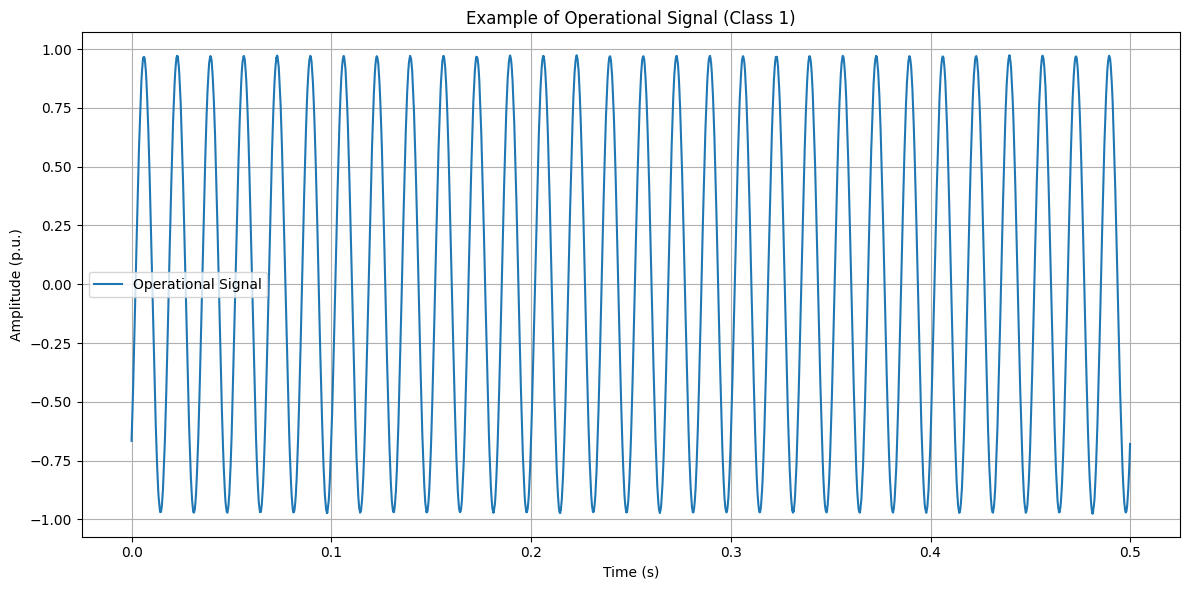

--- Generated Signal Parameters ---
Disturbance Type: Operational Signal
Sampling Frequency (Hz): 10000
Signal Duration (s): 0.5
Base Amplitude (p.u.): 0.9691
Base Frequency (Hz): 60.0061
Base Phase (rad): -0.7588
Noise Level (%): 0.61
Noise Amplitude (p.u.): 0.0061


In [6]:
# @title 1.b. Class 1 - Operational Signal Plotting

# Create an instance of the OperationalSignalGenerator
op_gen = OperationalSignalGenerator()

# Generate a single operational signal and its parameters
signal_op, params_op = op_gen.generate()

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(op_gen.time, signal_op, label='Operational Signal')
plt.title('Example of Operational Signal (Class 1)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (p.u.)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- Display Parameters ---
print("--- Generated Signal Parameters ---")
print(f"Disturbance Type: {params_op['disturbance_type']}")
print(f"Sampling Frequency (Hz): {params_op['fs']}")
print(f"Signal Duration (s): {params_op['t_signal']}")
print(f"Base Amplitude (p.u.): {params_op['base_amplitude']:.4f}")
print(f"Base Frequency (Hz): {params_op['base_frequency']:.4f}")
print(f"Base Phase (rad): {params_op['base_phase']:.4f}")
print(f"Noise Level (%): {params_op['noise_level_percent']:.2f}")
#print(f"Noise Level (dB): {params_op['noise_level_dB']:.2f}")
print(f"Noise Amplitude (p.u.): {params_op['noise_amplitude_pu']:.4f}")



In [7]:
# @title 1.c. Class 1 - Saving Operational Signals

# Ensure Block 0 (Google Drive Setup) and Block 2 (OperationalSignalGenerator) have been run.

# Define the number of signals to generate for this class
NUM_SIGNALS_CLASS1 = 200

# Class specific details
CLASS_NAME_1 = 'Operational Signal'
CLASS_LABEL_1 = 1 # Numerical label for this class
# Updated folder name: "1 Operational Signal" instead of "1/31 Operational Signal"
CLASS_FOLDER_NAME_1 = f"{CLASS_LABEL_1} {CLASS_NAME_1}"

# Construct the full path for this class's folder
CLASS_FULL_PATH_1 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_1)

# Ensure the class-specific folder exists
if not os.path.exists(CLASS_FULL_PATH_1):
    print(f"Creating class folder: {CLASS_FULL_PATH_1}")
    os.makedirs(CLASS_FULL_PATH_1)
else:
    print(f"Class folder already exists: {CLASS_FULL_PATH_1}")

# Define the HDF5 file path for this specific class
HDF5_FILE_NAME_1 = 'operational_signals.h5'
HDF5_FILE_PATH_1 = os.path.join(CLASS_FULL_PATH_1, HDF5_FILE_NAME_1)

# --- Generation and Saving Loop ---
print(f"Generating and saving {NUM_SIGNALS_CLASS1} signals for '{CLASS_NAME_1}' to {HDF5_FILE_PATH_1}...")

# Open HDF5 file in write mode ('w') to create a new file or overwrite existing
with h5py.File(HDF5_FILE_PATH_1, 'w') as f:
    # Create a dataset for signals. We'll append to it.
    # Using maxshape=(None, ...) allows for unlimited number of signals.
    # Compression is used to save space.
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    # Create a group for parameters, where each signal's parameters will be stored as attributes
    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS1):
        # Create a new generator instance for each signal to ensure independent randomization
        op_gen = OperationalSignalGenerator()
        signal, params = op_gen.generate()

        # Resize the dataset to accommodate the new signal
        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        # Store parameters as attributes of a new dataset within the 'parameters' group
        # The name of this dataset will correspond to the signal's index
        signal_params_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([])) # Empty dataset, just for attrs

        # Add the numerical class label as an attribute
        signal_params_dset.attrs['class_label'] = CLASS_LABEL_1

        # Store all other parameters as attributes
        for key, value in params.items():
            # HDF5 attributes cannot store complex types like numpy arrays or objects directly.
            # Ensure values are HDF5-compatible (e.g., numbers, strings, lists of numbers).
            # Convert lists/arrays to string if they are not simple numbers
            if isinstance(value, (np.ndarray, list)):
                signal_params_dset.attrs[key] = str(value)
            else:
                signal_params_dset.attrs[key] = value

        if (i + 1) % 50 == 0:
            print(f"  Generated {i+1}/{NUM_SIGNALS_CLASS1} signals.")

print(f"Finished generating and saving signals for '{CLASS_NAME_1}'.")
print(f"Data saved to: {HDF5_FILE_PATH_1}")



Class folder already exists: /content/drive/MyDrive/PQD_Synthetic_Dataset/1 Operational Signal
Generating and saving 200 signals for 'Operational Signal' to /content/drive/MyDrive/PQD_Synthetic_Dataset/1 Operational Signal/operational_signals.h5...
  Generated 50/200 signals.
  Generated 100/200 signals.
  Generated 150/200 signals.
  Generated 200/200 signals.
Finished generating and saving signals for 'Operational Signal'.
Data saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/1 Operational Signal/operational_signals.h5


Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/1 Operational Signal/operational_signal_stats.json

--- Statistical Summary for Operational Signal (Obtained vs. Expected) ---

Parameter: base_amplitude
  Obtained Mean: 0.9996 (Std Dev: 0.0287)
  Expected Mean: 1.0000 (Std Dev: 0.0289)
  Range: [0.95, 1.05]

Parameter: base_frequency
  Obtained Mean: 59.9996 (Std Dev: 0.0059)
  Expected Mean: 60.0000 (Std Dev: 0.0058)
  Range: [59.99, 60.01]

Parameter: base_phase
  Obtained Mean: 0.0441 (Std Dev: 1.8172)
  Expected Mean: 0.0000 (Std Dev: 1.8138)
  Range: [-3.141592653589793, 3.141592653589793]

Parameter: noise_level_percent
  Obtained Mean: 0.5080 (Std Dev: 0.2927)
  Expected Mean: 0.5000 (Std Dev: 0.2887)
  Range: [0.0, 1.0]

--- Generating Correlation Heatmap ---
Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/1 Operational Signal/operational_signal_correlation_heatmap.png


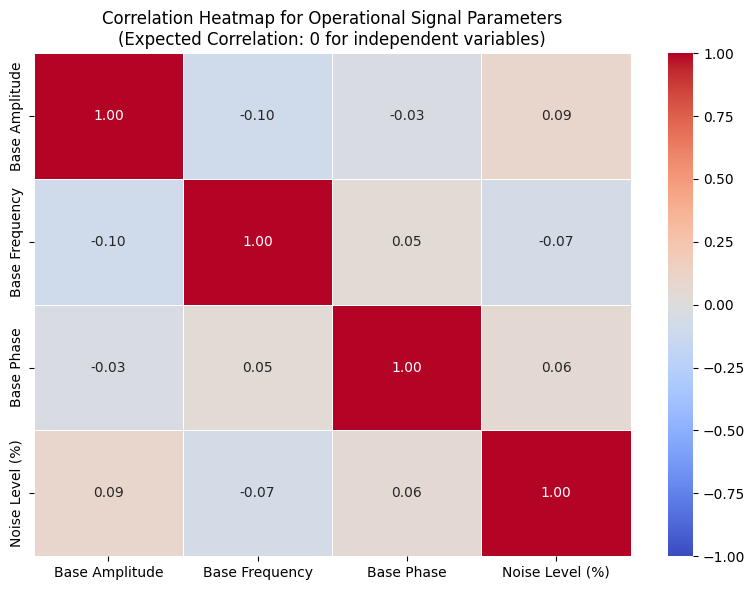

Finished collecting statistics for 'Operational Signal'.


In [8]:
# @title 1.d. Class 1 - Statistics.

# Ensure Block 0 (Google Drive Setup) and Block 4 (Saving Signals) have been run.

# Define the path for the statistics JSON file
STATS_FILE_NAME_1 = 'operational_signal_stats.json'
STATS_FILE_PATH_1 = os.path.join(CLASS_FULL_PATH_1, STATS_FILE_NAME_1)

# Define the path for the correlation heatmap image
CORRELATION_HEATMAP_FILE_NAME_1 = 'operational_signal_correlation_heatmap.png'
CORRELATION_HEATMAP_FILE_PATH_1 = os.path.join(CLASS_FULL_PATH_1, CORRELATION_HEATMAP_FILE_NAME_1)


print(f"Collecting statistics for '{CLASS_NAME_1}' and saving to {STATS_FILE_PATH_1}...")

# --- Data Collection ---
# Load parameters from the HDF5 file to ensure statistics are based on saved data
all_base_amplitudes = []
all_base_frequencies = []
all_base_phases = [] # Added base phase for correlation
all_noise_percents = []
#all_noise_dBs = [] # Still collect for JSON report, just not heatmap

with h5py.File(HDF5_FILE_PATH_1, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS1):
        signal_params_dset = params_group[f'signal_{i+1:04d}']
        params = dict(signal_params_dset.attrs) # Get all attributes as a dictionary

        all_base_amplitudes.append(params['base_amplitude'])
        all_base_frequencies.append(params['base_frequency'])
        all_base_phases.append(params['base_phase']) # Collect base phase
        all_noise_percents.append(params['noise_level_percent'])
        #all_noise_dBs.append(params['noise_level_dB'])

# --- Statistical Analysis ---
# Function to calculate expected mean and std dev for a uniform distribution U(a, b)
def calculate_expected_stats(min_val, max_val):
    expected_mean = (min_val + max_val) / 2
    expected_std_dev = math.sqrt((max_val - min_val)**2 / 12)
    return expected_mean, expected_std_dev

# Calculate expected values for base amplitude, base frequency, and noise percent
expected_A_base_mean, expected_A_base_std = calculate_expected_stats(A_NOMINAL - 0.05, A_NOMINAL + 0.05)
expected_f_base_mean, expected_f_base_std = calculate_expected_stats(F_NOMINAL - 0.01, F_NOMINAL + 0.01)
expected_phi_base_mean, expected_phi_base_std = calculate_expected_stats(-np.pi, np.pi) # For base phase
expected_noise_percent_mean, expected_noise_percent_std = calculate_expected_stats(NOISE_PERCENT_MIN, NOISE_PERCENT_MAX)


# Compile statistics into a dictionary
stats_summary = {
    "class_name": CLASS_NAME_1,
    "class_label": CLASS_LABEL_1,
    "num_signals_generated": NUM_SIGNALS_CLASS1,
    "parameters_stats": {
        "base_amplitude": {
            "obtained_min": np.min(all_base_amplitudes),
            "obtained_max": np.max(all_base_amplitudes),
            "obtained_mean": np.mean(all_base_amplitudes),
            "obtained_std_dev": np.std(all_base_amplitudes),
            "expected_mean": expected_A_base_mean,
            "expected_std_dev": expected_A_base_std,
            "range": [A_NOMINAL - 0.05, A_NOMINAL + 0.05]
        },
        "base_frequency": {
            "obtained_min": np.min(all_base_frequencies),
            "obtained_max": np.max(all_base_frequencies),
            "obtained_mean": np.mean(all_base_frequencies),
            "obtained_std_dev": np.std(all_base_frequencies),
            "expected_mean": expected_f_base_mean,
            "expected_std_dev": expected_f_base_std,
            "range": [F_NOMINAL - 0.01, F_NOMINAL + 0.01]
        },
        "base_phase": { # Added base phase stats
            "obtained_min": np.min(all_base_phases),
            "obtained_max": np.max(all_base_phases),
            "obtained_mean": np.mean(all_base_phases),
            "obtained_std_dev": np.std(all_base_phases),
            "expected_mean": expected_phi_base_mean,
            "expected_std_dev": expected_phi_base_std,
            "range": [-np.pi, np.pi]
        },
        "noise_level_percent": {
            "obtained_min": np.min(all_noise_percents),
            "obtained_max": np.max(all_noise_percents),
            "obtained_mean": np.mean(all_noise_percents),
            "obtained_std_dev": np.std(all_noise_percents),
            "expected_mean": expected_noise_percent_mean,
            "expected_std_dev": expected_noise_percent_std,
            "range": [NOISE_PERCENT_MIN, NOISE_PERCENT_MAX]
        },
        #"noise_level_dB": {
            #"obtained_min": np.min(all_noise_dBs),
            #"obtained_max": np.max(all_noise_dBs),
            #"obtained_mean": np.mean(all_noise_dBs),
            #"obtained_std_dev": np.std(all_noise_dBs)
        #}
    }
}

# --- Save Statistics to JSON ---
with open(STATS_FILE_PATH_1, 'w') as f:
    json.dump(stats_summary, f, indent=4)

print(f"Statistics saved to: {STATS_FILE_PATH_1}")

# --- Display Summary (Optional, for immediate feedback) ---
print("\n--- Statistical Summary for Operational Signal (Obtained vs. Expected) ---")
for param, stats in stats_summary["parameters_stats"].items():
    print(f"\nParameter: {param}")
    print(f"  Obtained Mean: {stats['obtained_mean']:.4f} (Std Dev: {stats['obtained_std_dev']:.4f})")
    if 'expected_mean' in stats: # Only for parameters with direct uniform distribution
        print(f"  Expected Mean: {stats['expected_mean']:.4f} (Std Dev: {stats['expected_std_dev']:.4f})")
        print(f"  Range: {stats['range']}")


# --- Correlation Heatmap ---
print("\n--- Generating Correlation Heatmap ---")

# Create a DataFrame from the collected parameter lists
# Exclude 'Noise Level (dB)' from the DataFrame for the heatmap as it's derived from Noise Level (%)
correlation_data = pd.DataFrame({
    'Base Amplitude': all_base_amplitudes,
    'Base Frequency': all_base_frequencies,
    'Base Phase': all_base_phases,
    'Noise Level (%)': all_noise_percents
})

# Calculate the correlation matrix
corr = correlation_data.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title(f'Correlation Heatmap for {CLASS_NAME_1} Parameters\n(Expected Correlation: 0 for independent variables)')
plt.tight_layout()

# Save the heatmap
plt.savefig(CORRELATION_HEATMAP_FILE_PATH_1)
print(f"Correlation heatmap saved to: {CORRELATION_HEATMAP_FILE_PATH_1}")
plt.show() # Display the plot in the notebook

print(f"Finished collecting statistics for '{CLASS_NAME_1}'.")


In [9]:
class SagGenerator(PQDBaseGenerator):
    """
    Generates a 'Sag' disturbance signal.
    Mathematical Model: V(t) = [1 - (1 - magnitude) * (u(t-t1) - u(t-t2))] * V_base(t)
    Simplified: V(t) = magnitude * V_base(t) during the interval [t1, t2].
    According to IEEE 1159, sag magnitude is the remaining voltage (e.g., 0.7 pu).
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Sag'

        # Randomize sag-specific parameters
        # Sag magnitude (remaining voltage): 0.1 to 0.9 p.u. (IEEE 1159)
        self.sag_magnitude = random.uniform(0.1, 0.9)

        # Get random timing for the sag
        self.sag_start_time, self.sag_end_time, self.sag_duration_sec, self.sag_duration_cycles = \
            self._get_random_disturbance_timing()

        # Store sag-specific parameters
        self.params['sag_magnitude'] = self.sag_magnitude
        self.params['sag_start_time'] = self.sag_start_time
        self.params['sag_end_time'] = self.sag_end_time
        self.params['sag_duration_sec'] = self.sag_duration_sec
        self.params['sag_duration_cycles'] = self.sag_duration_cycles

    def generate(self):
        """
        Generates the sag signal.
        """
        # Generate the base sinusoidal signal
        base_signal = self.generate_base_sine()

        # Create the envelope factor
        # It's 1 everywhere, except during the sag period where it's sag_magnitude
        sag_factor = np.ones_like(self.time)

        # Apply the sag magnitude during the active mask
        sag_active_mask = (self.time >= self.sag_start_time) & (self.time < self.sag_end_time)
        sag_factor[sag_active_mask] = self.sag_magnitude

        # Apply the envelope to the base signal
        signal = base_signal * sag_factor

        # Add noise to the signal
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params

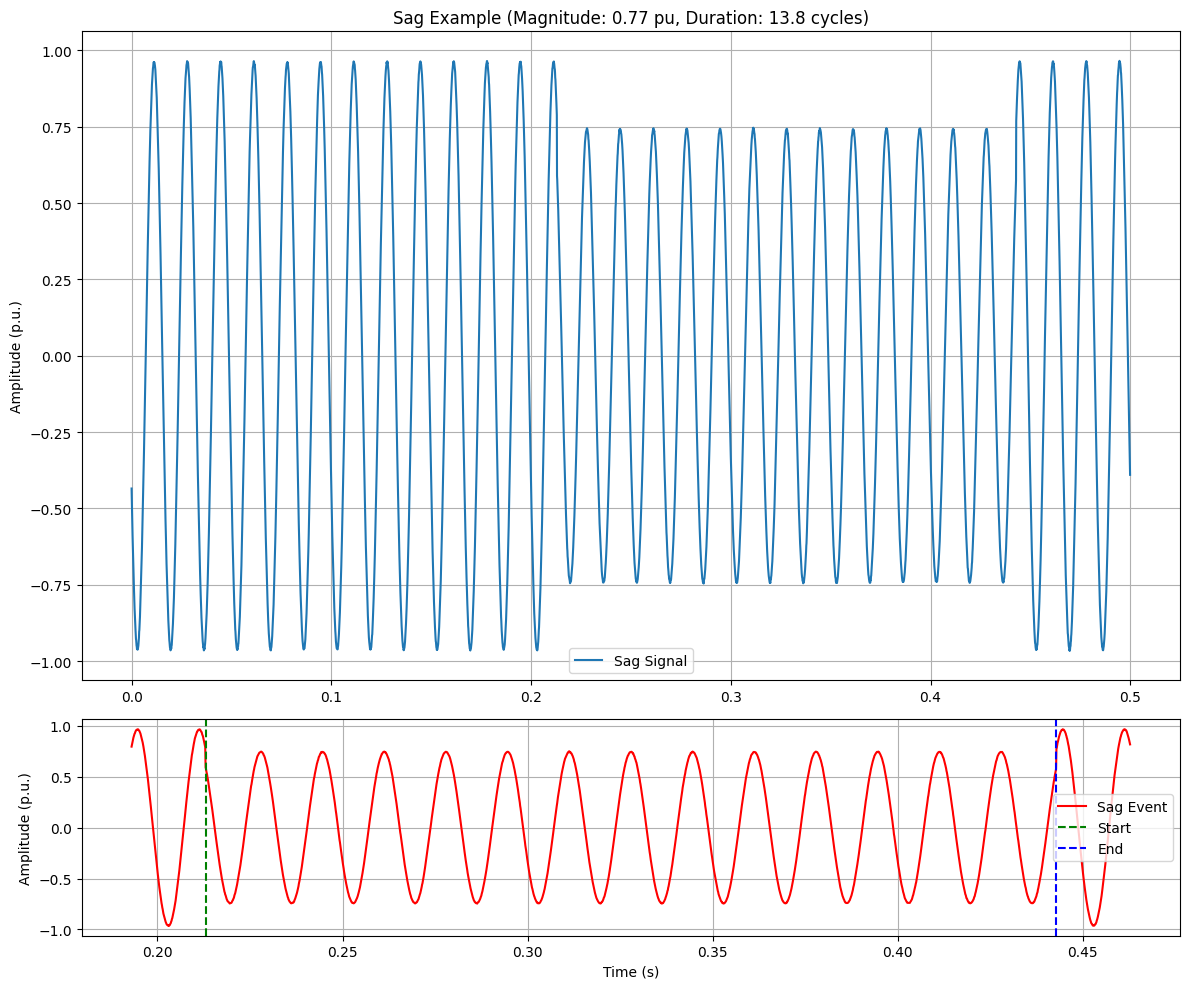

--- Sag Signal Parameters ---
• Base: 0.962 pu, 59.99 Hz, phase: -2.67 rad
• Sag: 0.772 pu, start: 0.213 s, duration: 0.230 s (13.79 cycles)
• Noise: 0.59%

Note: Parameters randomized via Monte Carlo simulation based on
IEEE 1159 typical characteristics for power system disturbances.


In [10]:
# @title 2.b. Class 2 - Sag Plotting

# Create SagGenerator instance and generate signal
sag_gen = SagGenerator()
signal_sag, params_sag = sag_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot full signal
ax1.plot(sag_gen.time, signal_sag, label='Sag Signal')
ax1.set_title(f'Sag Example (Magnitude: {params_sag["sag_magnitude"]:.2f} pu, '
              f'Duration: {params_sag["sag_duration_cycles"]:.1f} cycles)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Plot zoomed-in view around sag event
zoom_start = max(0, params_sag["sag_start_time"] - 0.02)
zoom_end = min(params_sag["t_signal"], params_sag["sag_end_time"] + 0.02)
zoom_mask = (sag_gen.time >= zoom_start) & (sag_gen.time <= zoom_end)

ax2.plot(sag_gen.time[zoom_mask], signal_sag[zoom_mask], 'r-', label='Sag Event')
ax2.axvline(params_sag["sag_start_time"], color='g', linestyle='--', label='Start')
ax2.axvline(params_sag["sag_end_time"], color='b', linestyle='--', label='End')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print parameters and Monte Carlo note
print("--- Sag Signal Parameters ---")
print(f"• Base: {params_sag['base_amplitude']:.3f} pu, "
      f"{params_sag['base_frequency']:.2f} Hz, "
      f"phase: {params_sag['base_phase']:.2f} rad")
print(f"• Sag: {params_sag['sag_magnitude']:.3f} pu, "
      f"start: {params_sag['sag_start_time']:.3f} s, "
      f"duration: {params_sag['sag_duration_sec']:.3f} s "
      f"({params_sag['sag_duration_cycles']:.2f} cycles)")
print(f"• Noise: {params_sag['noise_level_percent']:.2f}%")
      #f"({params_sag['noise_level_percent']:.1f} dB)")

print("\nNote: Parameters randomized via Monte Carlo simulation based on")
print("IEEE 1159 typical characteristics for power system disturbances.")

In [11]:
# @title 2.c Class 2 - Saving Sag Signals

# Ensure Block 0 (Google Drive Setup) and Block 6 (SagGenerator) have been run.

# Define the number of signals to generate for this class
NUM_SIGNALS_CLASS2 = 200

# Class specific details
CLASS_NAME_2 = 'Sag'
CLASS_LABEL_2 = 2 # Numerical label for this class
CLASS_FOLDER_NAME_2 = f"{CLASS_LABEL_2} {CLASS_NAME_2}"

# Construct the full path for this class's folder
CLASS_FULL_PATH_2 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_2)

# Ensure the class-specific folder exists
if not os.path.exists(CLASS_FULL_PATH_2):
    print(f"Creating class folder: {CLASS_FULL_PATH_2}")
    os.makedirs(CLASS_FULL_PATH_2)
else:
    print(f"Class folder already exists: {CLASS_FULL_PATH_2}")

# Define the HDF5 file path for this specific class
HDF5_FILE_NAME_2 = 'sag_signals.h5'
HDF5_FILE_PATH_2 = os.path.join(CLASS_FULL_PATH_2, HDF5_FILE_NAME_2)

# --- Generation and Saving Loop ---
print(f"Generating and saving {NUM_SIGNALS_CLASS2} signals for '{CLASS_NAME_2}' to {HDF5_FILE_PATH_2}...")

# Open HDF5 file in write mode ('w') to create a new file or overwrite existing
with h5py.File(HDF5_FILE_PATH_2, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS2):
        sag_gen = SagGenerator()
        signal, params = sag_gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params_dset.attrs['class_label'] = CLASS_LABEL_2

        for key, value in params.items():
            if isinstance(value, (np.ndarray, list)):
                signal_params_dset.attrs[key] = str(value)
            else:
                signal_params_dset.attrs[key] = value

        if (i + 1) % 50 == 0:
            print(f"  Generated {i+1}/{NUM_SIGNALS_CLASS2} signals.")

print(f"Finished generating and saving signals for '{CLASS_NAME_2}'.")
print(f"Data saved to: {HDF5_FILE_PATH_2}")


Class folder already exists: /content/drive/MyDrive/PQD_Synthetic_Dataset/2 Sag
Generating and saving 200 signals for 'Sag' to /content/drive/MyDrive/PQD_Synthetic_Dataset/2 Sag/sag_signals.h5...
  Generated 50/200 signals.
  Generated 100/200 signals.
  Generated 150/200 signals.
  Generated 200/200 signals.
Finished generating and saving signals for 'Sag'.
Data saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/2 Sag/sag_signals.h5


Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/2 Sag/sag_stats.json

--- Generating Correlation Heatmap for Sag Parameters ---


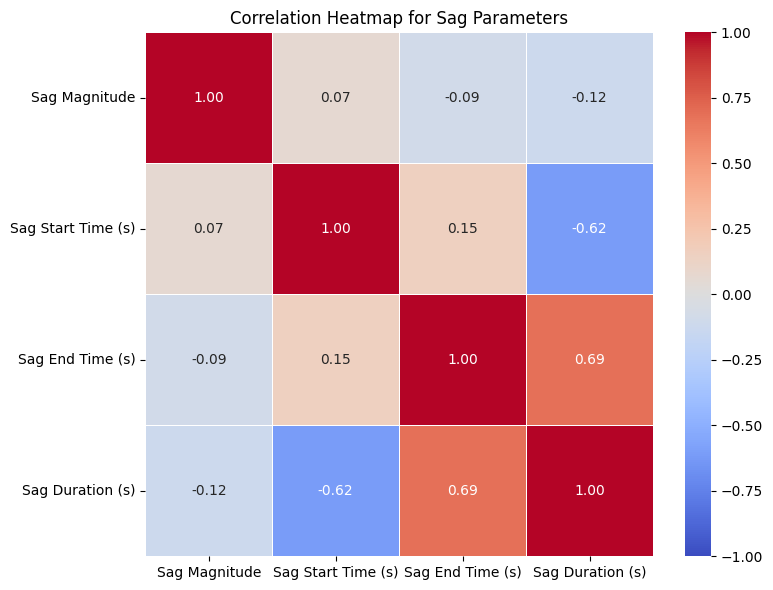

In [12]:
# @title 2.d. Class 2 - Statistics for Sag

# Ensure Block 0 (Google Drive Setup) and Block 8 (Saving Signals for Class 2) have been run.

# --- Define Paths (Fixed NameError) ---
CLASS_NAME_2 = 'Sag'
CLASS_LABEL_2 = 2
CLASS_FOLDER_NAME_2 = f"{CLASS_LABEL_2} {CLASS_NAME_2}"
CLASS_FULL_PATH_2 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_2)
HDF5_FILE_NAME_2 = 'sag_signals.h5'
HDF5_FILE_PATH_2 = os.path.join(CLASS_FULL_PATH_2, HDF5_FILE_NAME_2)

# Define the path for the statistics JSON file
STATS_FILE_NAME_2 = 'sag_stats.json'
STATS_FILE_PATH_2 = os.path.join(CLASS_FULL_PATH_2, STATS_FILE_NAME_2)

# Define the path for the correlation heatmap image
CORRELATION_HEATMAP_FILE_NAME_2 = 'sag_correlation_heatmap.png'
CORRELATION_HEATMAP_FILE_PATH_2 = os.path.join(CLASS_FULL_PATH_2, CORRELATION_HEATMAP_FILE_NAME_2)


print(f"Collecting statistics for '{CLASS_NAME_2}' and saving to {STATS_FILE_PATH_2}...")

# --- Data Collection ---
all_sag_magnitudes = []
all_sag_start_times = []
all_sag_end_times = []
all_sag_duration_secs = []
all_sag_duration_cycles = []

with h5py.File(HDF5_FILE_PATH_2, 'r') as f:
    params_group = f['parameters']
    signal_keys = [k for k in params_group.keys() if k.startswith('signal_')]
    for key in signal_keys:
        signal_params_dset = params_group[key]
        params = dict(signal_params_dset.attrs)

        all_sag_magnitudes.append(params['sag_magnitude'])
        all_sag_start_times.append(params['sag_start_time'])
        all_sag_end_times.append(params['sag_end_time'])
        all_sag_duration_secs.append(params['sag_duration_sec'])
        all_sag_duration_cycles.append(params['sag_duration_cycles'])

# --- Statistical Analysis ---
def calculate_expected_stats(min_val, max_val):
    expected_mean = (min_val + max_val) / 2
    expected_std_dev = math.sqrt((max_val - min_val)**2 / 12)
    return expected_mean, expected_std_dev

# UPDATED: Expected sag magnitude is now remaining voltage (0.1 to 0.9)
expected_sag_magnitude_mean, expected_sag_magnitude_std = calculate_expected_stats(0.1, 0.9)
expected_sag_duration_cycles_mean, expected_sag_duration_cycles_std = calculate_expected_stats(DURATION_CYCLES_MIN, DURATION_CYCLES_MAX)

# Compile statistics into a dictionary
stats_summary = {
    "class_name": CLASS_NAME_2,
    "class_label": CLASS_LABEL_2,
    "num_signals_analyzed": len(all_sag_magnitudes),
    "parameters_stats": {
        "sag_magnitude [p.u. factor]": {
            "obtained_min": np.min(all_sag_magnitudes),
            "obtained_max": np.max(all_sag_magnitudes),
            "obtained_mean": np.mean(all_sag_magnitudes),
            "obtained_std_dev": np.std(all_sag_magnitudes),
            "expected_mean": expected_sag_magnitude_mean,
            "expected_std_dev": expected_sag_magnitude_std,
            "range": [0.1, 0.9]
        },
        "sag_start_time [s]": {
            "obtained_min": np.min(all_sag_start_times),
            "obtained_max": np.max(all_sag_start_times),
            "obtained_mean": np.mean(all_sag_start_times),
            "obtained_std_dev": np.std(all_sag_start_times),
        },
        "sag_duration [cycles]": {
            "obtained_min": np.min(all_sag_duration_cycles),
            "obtained_max": np.max(all_sag_duration_cycles),
            "obtained_mean": np.mean(all_sag_duration_cycles),
            "obtained_std_dev": np.std(all_sag_duration_cycles),
            "expected_mean": expected_sag_duration_cycles_mean,
            "expected_std_dev": expected_sag_duration_cycles_std,
            "range": [DURATION_CYCLES_MIN, DURATION_CYCLES_MAX]
        }
    }
}

# --- Save Statistics to JSON ---
with open(STATS_FILE_PATH_2, 'w') as f:
    json.dump(stats_summary, f, indent=4)

print(f"Statistics saved to: {STATS_FILE_PATH_2}")

# --- Correlation Heatmap ---
print("\n--- Generating Correlation Heatmap for Sag Parameters ---")
correlation_data_sag = pd.DataFrame({
    'Sag Magnitude': all_sag_magnitudes,
    'Sag Start Time (s)': all_sag_start_times,
    'Sag End Time (s)': all_sag_end_times,
    'Sag Duration (s)': all_sag_duration_secs
})

corr_sag = correlation_data_sag.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_sag, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title(f'Correlation Heatmap for {CLASS_NAME_2} Parameters')
plt.tight_layout()
plt.savefig(CORRELATION_HEATMAP_FILE_PATH_2)
plt.show()

In [13]:
# @title 3.a. Class 3 - Swell Generator

class SwellGenerator(PQDBaseGenerator):
    """
    Generates a 'Swell' disturbance signal.
    Mathematical Model: V(t) = [1 + s * (u(t-t1) - u(t-t2))] * V_base(t)
    where s is the swell magnitude.
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Swell'

        # Randomize swell-specific parameters
        # Swell magnitude: 0.1 to 0.8 p.u. (IEEE 1159, resulting in 1.1 to 1.8 p.u. peak)
        self.swell_magnitude = random.uniform(0.1, 0.8)

        # Get random timing for the swell
        self.swell_start_time, self.swell_end_time, self.swell_duration_sec, self.swell_duration_cycles = \
            self._get_random_disturbance_timing()

        # Store swell-specific parameters
        self.params['swell_magnitude'] = 1 + self.swell_magnitude
        self.params['swell_start_time'] = self.swell_start_time
        self.params['swell_end_time'] = self.swell_end_time
        self.params['swell_duration_sec'] = self.swell_duration_sec
        self.params['swell_duration_cycles'] = self.swell_duration_cycles

    def generate(self):
        """
        Generates the swell signal.

        Returns:
            tuple: (signal_array, parameters_dict)
        """
        # Generate the base sinusoidal signal
        base_signal = self.generate_base_sine()

        # Create the swell factor (multiplicative envelope)
        # It's 1 everywhere, except during the swell period where it's (1 + swell_magnitude)
        swell_factor = np.ones_like(self.time)

        # Apply the swell factor using unit step functions
        swell_active_mask = (self.time >= self.swell_start_time) & (self.time < self.swell_end_time)
        swell_factor[swell_active_mask] = 1 + self.swell_magnitude

        # Apply the swell factor to the base signal
        signal = base_signal * swell_factor

        # Add noise to the signal
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params


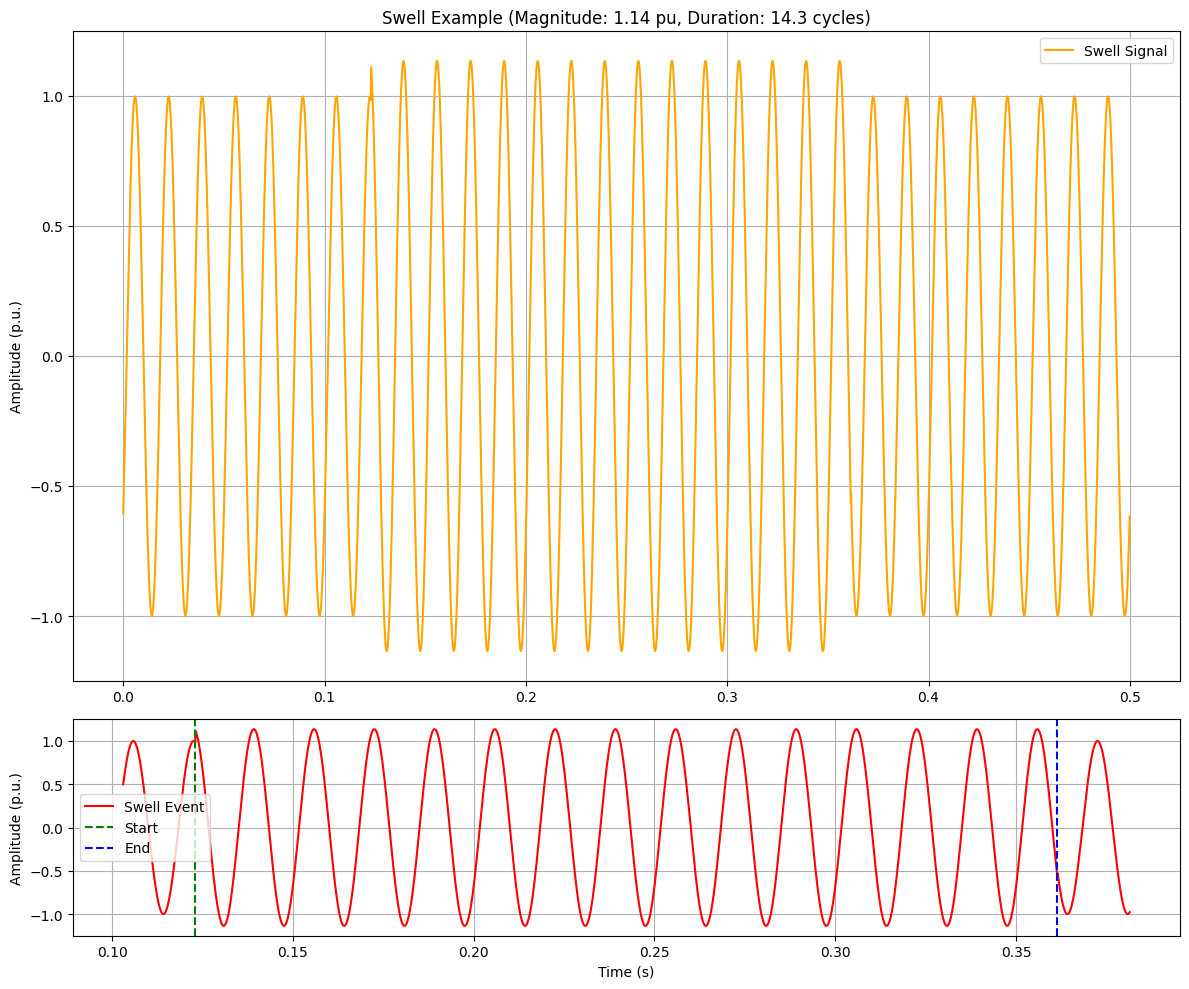

--- Swell Signal Parameters ---
• Base: 0.998 pu, 60.01 Hz, phase: -0.65 rad
• Swell: 1.137 pu, start: 0.123 s, duration: 0.238 s (14.30 cycles)
• Noise: 0.07% 

Note: Parameters randomized via Monte Carlo simulation based on
IEEE 1159 typical characteristics for power system disturbances.


In [14]:
# @title 3.b. Class 3 - Swell Plotting

# Create SwellGenerator instance and generate signal
swell_gen = SwellGenerator()
signal_swell, params_swell = swell_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot full signal
ax1.plot(swell_gen.time, signal_swell, label='Swell Signal', color='orange')
ax1.set_title(f'Swell Example (Magnitude: {params_swell["swell_magnitude"]:.2f} pu, '
              f'Duration: {params_swell["swell_duration_cycles"]:.1f} cycles)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Plot zoomed-in view around swell event
zoom_start = max(0, params_swell["swell_start_time"] - 0.02)
zoom_end = min(params_swell["t_signal"], params_swell["swell_end_time"] + 0.02)
zoom_mask = (swell_gen.time >= zoom_start) & (swell_gen.time <= zoom_end)

ax2.plot(swell_gen.time[zoom_mask], signal_swell[zoom_mask], 'r-', label='Swell Event')
ax2.axvline(params_swell["swell_start_time"], color='g', linestyle='--', label='Start')
ax2.axvline(params_swell["swell_end_time"], color='b', linestyle='--', label='End')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print parameters and Monte Carlo note
print("--- Swell Signal Parameters ---")
print(f"• Base: {params_swell['base_amplitude']:.3f} pu, "
      f"{params_swell['base_frequency']:.2f} Hz, "
      f"phase: {params_swell['base_phase']:.2f} rad")
print(f"• Swell: {params_swell['swell_magnitude']:.3f} pu, "
      f"start: {params_swell['swell_start_time']:.3f} s, "
      f"duration: {params_swell['swell_duration_sec']:.3f} s "
      f"({params_swell['swell_duration_cycles']:.2f} cycles)")
print(f"• Noise: {params_swell['noise_level_percent']:.2f}% ")
      #f"({params_swell['noise_level_dB']:.1f} dB)")

print("\nNote: Parameters randomized via Monte Carlo simulation based on")
print("IEEE 1159 typical characteristics for power system disturbances.")

In [15]:
# @title 3.c. Class 3 - Saving Swell Signals

# Ensure Block 0 (Google Drive Setup) and Block 10 (SwellGenerator) have been run.

# Define the number of signals to generate for this class
NUM_SIGNALS_CLASS3 = 200

# Class specific details
CLASS_NAME_3 = 'Swell'
CLASS_LABEL_3 = 3 # Numerical label for this class
CLASS_FOLDER_NAME_3 = f"{CLASS_LABEL_3} {CLASS_NAME_3}"

# Construct the full path for this class's folder
CLASS_FULL_PATH_3 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_3)

# Ensure the class-specific folder exists
if not os.path.exists(CLASS_FULL_PATH_3):
    print(f"Creating class folder: {CLASS_FULL_PATH_3}")
    os.makedirs(CLASS_FULL_PATH_3)
else:
    print(f"Class folder already exists: {CLASS_FULL_PATH_3}")

# Define the HDF5 file path for this specific class
HDF5_FILE_NAME_3 = 'swell_signals.h5'
HDF5_FILE_PATH_3 = os.path.join(CLASS_FULL_PATH_3, HDF5_FILE_NAME_3)

# --- Generation and Saving Loop ---
print(f"Generating and saving {NUM_SIGNALS_CLASS3} signals for '{CLASS_NAME_3}' to {HDF5_FILE_PATH_3}...")

# Open HDF5 file in write mode ('w') to create a new file or overwrite existing
with h5py.File(HDF5_FILE_PATH_3, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS3):
        swell_gen = SwellGenerator()
        signal, params = swell_gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params_dset.attrs['class_label'] = CLASS_LABEL_3

        for key, value in params.items():
            if isinstance(value, (np.ndarray, list)):
                signal_params_dset.attrs[key] = str(value)
            else:
                signal_params_dset.attrs[key] = value

        if (i + 1) % 50 == 0:
            print(f"  Generated {i+1}/{NUM_SIGNALS_CLASS3} signals.")

print(f"Finished generating and saving signals for '{CLASS_NAME_3}'.")
print(f"Data saved to: {HDF5_FILE_PATH_3}")


Class folder already exists: /content/drive/MyDrive/PQD_Synthetic_Dataset/3 Swell
Generating and saving 200 signals for 'Swell' to /content/drive/MyDrive/PQD_Synthetic_Dataset/3 Swell/swell_signals.h5...
  Generated 50/200 signals.
  Generated 100/200 signals.
  Generated 150/200 signals.
  Generated 200/200 signals.
Finished generating and saving signals for 'Swell'.
Data saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/3 Swell/swell_signals.h5


Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/3 Swell/swell_stats.json

--- Statistical Summary for Swell (Obtained vs. Expected) ---

Parameter: swell_magnitude
  Obtained Mean: 1.4290 (Std Dev: 0.2065)
  Expected Mean: 1.4500 (Std Dev: 0.2021)
  Range: [1.1, 1.8]

Parameter: swell_start_time
  Obtained Mean: 0.1212 (Std Dev: 0.0992)

Parameter: swell_end_time
  Obtained Mean: 0.3729 (Std Dev: 0.0984)

Parameter: swell_duration_sec
  Obtained Mean: 0.2517 (Std Dev: 0.1369)

Parameter: swell_duration_cycles
  Obtained Mean: 15.1041 (Std Dev: 8.2122)
  Expected Mean: 15.2500 (Std Dev: 8.5159)
  Range: [0.5, 30]

--- Generating Correlation Heatmap for Swell Parameters ---
Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/3 Swell/swell_correlation_heatmap.png


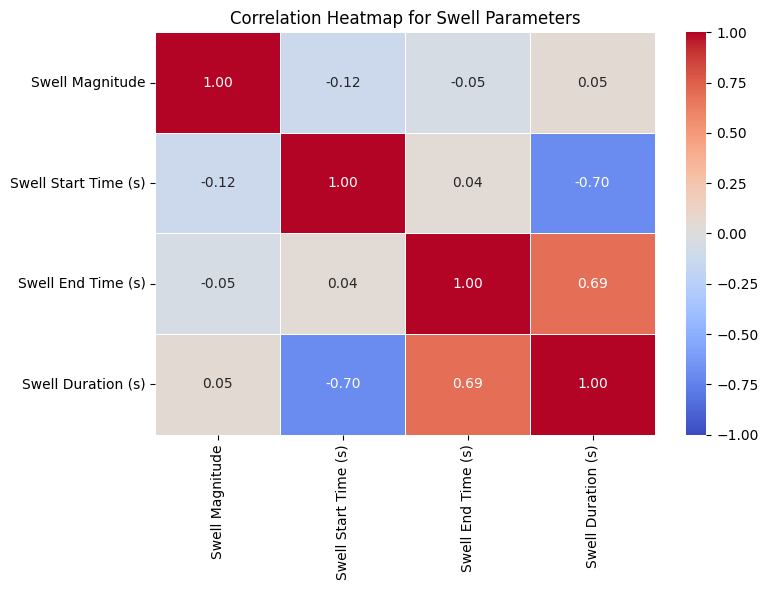

Finished collecting statistics for 'Swell'.


In [16]:
# @title 3.d. Class 3 - Swell Statistics

# Ensure Block 0 (Google Drive Setup) and Block 12 (Saving Signals for Class 3) have been run.

# Define the path for the statistics JSON file
STATS_FILE_NAME_3 = 'swell_stats.json'
STATS_FILE_PATH_3 = os.path.join(CLASS_FULL_PATH_3, STATS_FILE_NAME_3)

# Define the path for the correlation heatmap image
CORRELATION_HEATMAP_FILE_NAME_3 = 'swell_correlation_heatmap.png'
CORRELATION_HEATMAP_FILE_PATH_3 = os.path.join(CLASS_FULL_PATH_3, CORRELATION_HEATMAP_FILE_NAME_3)


print(f"Collecting statistics for '{CLASS_NAME_3}' and saving to {STATS_FILE_PATH_3}...")

# --- Data Collection ---
# Load parameters from the HDF5 file
all_swell_magnitudes = []
all_swell_start_times = []
all_swell_end_times = []
all_swell_duration_secs = []
all_swell_duration_cycles = []

with h5py.File(HDF5_FILE_PATH_3, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS3):
        signal_params_dset = params_group[f'signal_{i+1:04d}']
        params = dict(signal_params_dset.attrs)

        all_swell_magnitudes.append(params['swell_magnitude'])
        all_swell_start_times.append(params['swell_start_time'])
        all_swell_end_times.append(params['swell_end_time'])
        all_swell_duration_secs.append(params['swell_duration_sec'])
        all_swell_duration_cycles.append(params['swell_duration_cycles'])

# --- Statistical Analysis ---
# Calculate expected values for swell-specific parameters (based on their uniform ranges)
expected_swell_magnitude_mean, expected_swell_magnitude_std = calculate_expected_stats(1.1, 1.8)
expected_swell_duration_cycles_mean, expected_swell_duration_cycles_std = calculate_expected_stats(DURATION_CYCLES_MIN, DURATION_CYCLES_MAX)


# Compile statistics into a dictionary
stats_summary = {
    "class_name": CLASS_NAME_3,
    "class_label": CLASS_LABEL_3,
    "num_signals_generated": NUM_SIGNALS_CLASS3,
    "parameters_stats": {
        "swell_magnitude": {
            "obtained_min": np.min(all_swell_magnitudes),
            "obtained_max": np.max(all_swell_magnitudes),
            "obtained_mean": np.mean(all_swell_magnitudes),
            "obtained_std_dev": np.std(all_swell_magnitudes),
            "expected_mean": expected_swell_magnitude_mean,
            "expected_std_dev": expected_swell_magnitude_std,
            "range": [1.1, 1.8]
        },
        "swell_start_time": {
            "obtained_min": np.min(all_swell_start_times),
            "obtained_max": np.max(all_swell_start_times),
            "obtained_mean": np.mean(all_swell_start_times),
            "obtained_std_dev": np.std(all_swell_start_times),
        },
        "swell_end_time": {
            "obtained_min": np.min(all_swell_end_times),
            "obtained_max": np.max(all_swell_end_times),
            "obtained_mean": np.mean(all_swell_end_times),
            "obtained_std_dev": np.std(all_swell_end_times),
        },
        "swell_duration_sec": {
            "obtained_min": np.min(all_swell_duration_secs),
            "obtained_max": np.max(all_swell_duration_secs),
            "obtained_mean": np.mean(all_swell_duration_secs),
            "obtained_std_dev": np.std(all_swell_duration_secs),
        },
        "swell_duration_cycles": {
            "obtained_min": np.min(all_swell_duration_cycles),
            "obtained_max": np.max(all_swell_duration_cycles),
            "obtained_mean": np.mean(all_swell_duration_cycles),
            "obtained_std_dev": np.std(all_swell_duration_cycles),
            "expected_mean": expected_swell_duration_cycles_mean,
            "expected_std_dev": expected_swell_duration_cycles_std,
            "range": [DURATION_CYCLES_MIN, DURATION_CYCLES_MAX]
        }
    },
    "correlation_notes": { # Added notes for expected correlations
        "swell_start_time_vs_swell_duration_sec": "Expected negative correlation due to constraint that longer durations force earlier start times within the fixed signal window.",
        "swell_start_time_vs_swell_end_time": "Expected strong positive correlation as end time is start time plus duration, even with duration being randomized."
    }
}

# --- Save Statistics to JSON ---
with open(STATS_FILE_PATH_3, 'w') as f:
    json.dump(stats_summary, f, indent=4)

print(f"Statistics saved to: {STATS_FILE_PATH_3}")

# --- Display Summary (Optional, for immediate feedback) ---
print("\n--- Statistical Summary for Swell (Obtained vs. Expected) ---")
for param, stats in stats_summary["parameters_stats"].items():
    print(f"\nParameter: {param}")
    print(f"  Obtained Mean: {stats['obtained_mean']:.4f} (Std Dev: {stats['obtained_std_dev']:.4f})")
    if 'expected_mean' in stats:
        print(f"  Expected Mean: {stats['expected_mean']:.4f} (Std Dev: {stats['expected_std_dev']:.4f})")
        print(f"  Range: {stats['range']}")


# --- Correlation Heatmap ---
print("\n--- Generating Correlation Heatmap for Swell Parameters ---")

# Create a DataFrame from the collected swell-specific parameter lists
correlation_data_swell = pd.DataFrame({
    'Swell Magnitude': all_swell_magnitudes,
    'Swell Start Time (s)': all_swell_start_times,
    'Swell End Time (s)': all_swell_end_times,
    'Swell Duration (s)': all_swell_duration_secs
})

# Calculate the correlation matrix
corr_swell = correlation_data_swell.corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_swell, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0) # Set vmin/vmax
plt.title(f'Correlation Heatmap for {CLASS_NAME_3} Parameters')
plt.tight_layout()

# Save the heatmap
plt.savefig(CORRELATION_HEATMAP_FILE_PATH_3)
print(f"Correlation heatmap saved to: {CORRELATION_HEATMAP_FILE_PATH_3}")
plt.show() # Display the plot in the notebook

print(f"Finished collecting statistics for '{CLASS_NAME_3}'.")


In [17]:
# @title 4.a. Class 4 - Interruption Generator

class InterruptionGenerator(PQDBaseGenerator):
    """
    Generates an 'Interruption' disturbance signal (residual voltage < 0.1 pu).
    Mathematical Model: V(t) = [1 - i * (u(t-t1) - u(t-t2))] * V_base(t)
    where i is the interruption magnitude (depth).
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Interruption'

        # Randomize interruption-specific parameters
        # Interruption magnitude: 0.9 to 0.99 p.u. (residual voltage: 0.1 to 0.01 pu)
        self.interruption_magnitude = random.uniform(0.9, 0.99)

        # Get random timing for the interruption
        self.interruption_start_time, self.interruption_end_time, self.interruption_duration_sec, self.interruption_duration_cycles = \
            self._get_random_disturbance_timing()

        # Store interruption-specific parameters
        self.params['interruption_magnitude'] = 1-self.interruption_magnitude
        self.params['interruption_start_time'] = self.interruption_start_time
        self.params['interruption_end_time'] = self.interruption_end_time
        self.params['interruption_duration_sec'] = self.interruption_duration_sec
        self.params['interruption_duration_cycles'] = self.interruption_duration_cycles

    def generate(self):
        """
        Generates the interruption signal.

        Returns:
            tuple: (signal_array, parameters_dict)
        """
        # Generate the base sinusoidal signal
        base_signal = self.generate_base_sine()

        # Create the interruption factor (multiplicative envelope)
        interruption_factor = np.ones_like(self.time)

        # Apply the interruption factor
        interruption_active_mask = (self.time >= self.interruption_start_time) & (self.time < self.interruption_end_time)
        interruption_factor[interruption_active_mask] = 1 - self.interruption_magnitude

        # Apply the interruption factor to the base signal
        signal = base_signal * interruption_factor

        # Add noise to the signal
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params


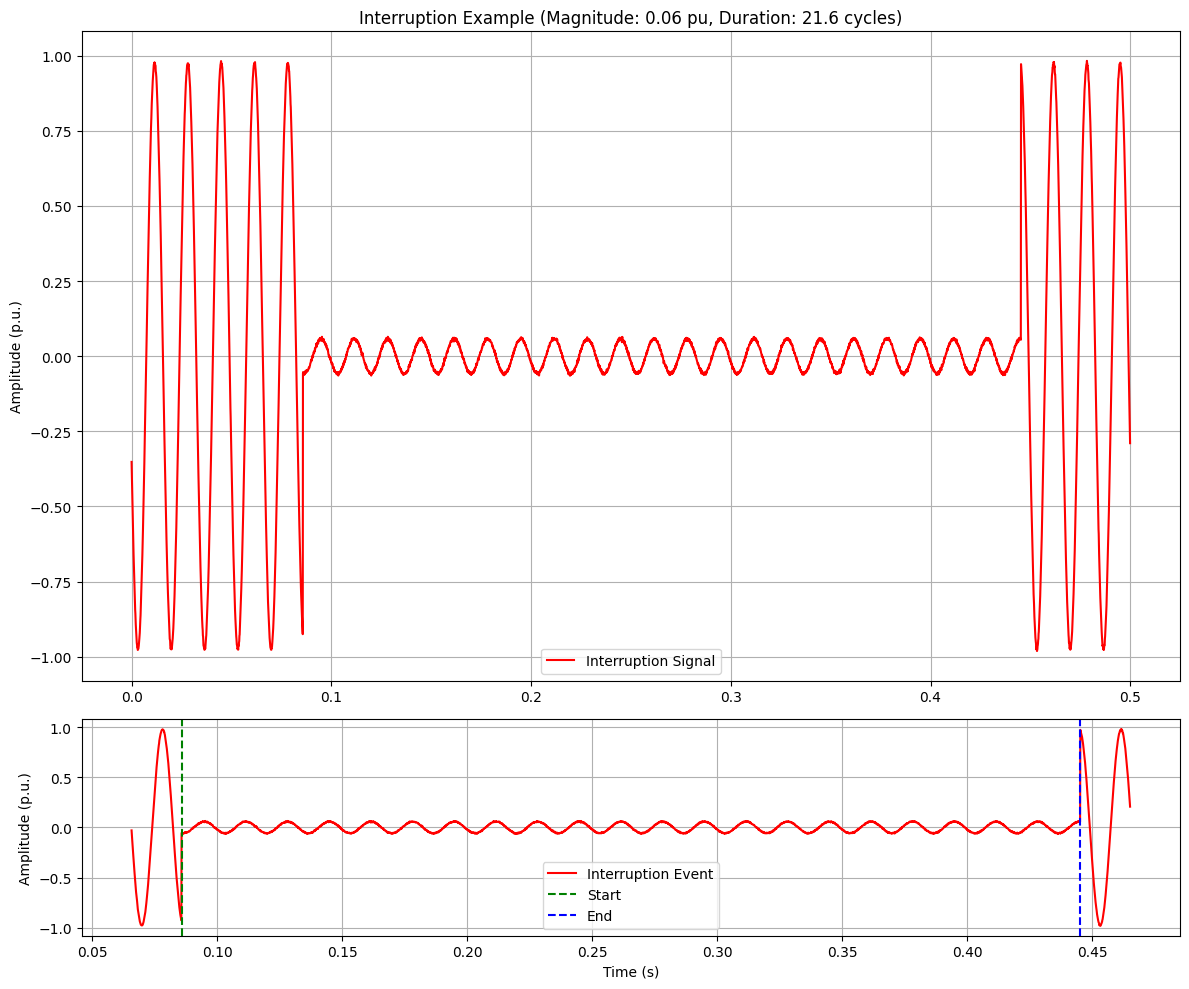

--- Interruption Signal Parameters ---
• Base: 0.976 pu, 59.99 Hz, phase: -2.78 rad
• Interruption: 0.059 pu, start: 0.086 s, duration: 0.359 s (21.57 cycles)
• Noise: 0.87% 

Note: Parameters randomized via Monte Carlo simulation based on
IEEE 1159 typical characteristics for power system disturbances.


In [18]:
# @title 4.b. Class 4 - Plotting Example for Interruption

# Create an instance of the InterruptionGenerator
interruption_gen = InterruptionGenerator()

# Generate a single interruption signal and its parameters
signal_interruption, params_interruption = interruption_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# Plot full signal
ax1.plot(interruption_gen.time, signal_interruption, label='Interruption Signal', color='red')
ax1.set_title(f'Interruption Example (Magnitude: {params_interruption["interruption_magnitude"]:.2f} pu, '
              f'Duration: {params_interruption["interruption_duration_cycles"]:.1f} cycles)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Plot zoomed-in view around interruption event
zoom_start = max(0, params_interruption["interruption_start_time"] - 0.02)
zoom_end = min(params_interruption["t_signal"], params_interruption["interruption_end_time"] + 0.02)
zoom_mask = (interruption_gen.time >= zoom_start) & (interruption_gen.time <= zoom_end)

ax2.plot(interruption_gen.time[zoom_mask], signal_interruption[zoom_mask], 'r-', label='Interruption Event')
ax2.axvline(params_interruption["interruption_start_time"], color='g', linestyle='--', label='Start')
ax2.axvline(params_interruption["interruption_end_time"], color='b', linestyle='--', label='End')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print parameters and Monte Carlo note
print("--- Interruption Signal Parameters ---")
print(f"• Base: {params_interruption['base_amplitude']:.3f} pu, "
      f"{params_interruption['base_frequency']:.2f} Hz, "
      f"phase: {params_interruption['base_phase']:.2f} rad")
print(f"• Interruption: {params_interruption['interruption_magnitude']:.3f} pu, "
      f"start: {params_interruption['interruption_start_time']:.3f} s, "
      f"duration: {params_interruption['interruption_duration_sec']:.3f} s "
      f"({params_interruption['interruption_duration_cycles']:.2f} cycles)")
print(f"• Noise: {params_interruption['noise_level_percent']:.2f}% ")
print("\nNote: Parameters randomized via Monte Carlo simulation based on")
print("IEEE 1159 typical characteristics for power system disturbances.")


In [19]:
# @title 4.c. Class 4- Saving Interruption Signals

# Ensure Block 0 (Google Drive Setup) and Block 14 (InterruptionGenerator) have been run.

# Define the number of signals to generate for this class
NUM_SIGNALS_CLASS4 = 200

# Class specific details
CLASS_NAME_4 = 'Interruption'
CLASS_LABEL_4 = 4 # Numerical label for this class
CLASS_FOLDER_NAME_4 = f"{CLASS_LABEL_4} {CLASS_NAME_4}"

# Construct the full path for this class's folder
CLASS_FULL_PATH_4 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_4)

# Ensure the class-specific folder exists
if not os.path.exists(CLASS_FULL_PATH_4):
    print(f"Creating class folder: {CLASS_FULL_PATH_4}")
    os.makedirs(CLASS_FULL_PATH_4)
else:
    print(f"Class folder already exists: {CLASS_FULL_PATH_4}")

# Define the HDF5 file path for this specific class
HDF5_FILE_NAME_4 = 'interruption_signals.h5'
HDF5_FILE_PATH_4 = os.path.join(CLASS_FULL_PATH_4, HDF5_FILE_NAME_4)

# --- Generation and Saving Loop ---
print(f"Generating and saving {NUM_SIGNALS_CLASS4} signals for '{CLASS_NAME_4}' to {HDF5_FILE_PATH_4}...")

# Open HDF5 file in write mode ('w') to create a new file or overwrite existing
with h5py.File(HDF5_FILE_PATH_4, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS4):
        interruption_gen = InterruptionGenerator()
        signal, params = interruption_gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params_dset.attrs['class_label'] = CLASS_LABEL_4

        for key, value in params.items():
            if isinstance(value, (np.ndarray, list)):
                signal_params_dset.attrs[key] = str(value)
            else:
                signal_params_dset.attrs[key] = value

        if (i + 1) % 50 == 0:
            print(f"  Generated {i+1}/{NUM_SIGNALS_CLASS4} signals.")

print(f"Finished generating and saving signals for '{CLASS_NAME_4}'.")
print(f"Data saved to: {HDF5_FILE_PATH_4}")


Class folder already exists: /content/drive/MyDrive/PQD_Synthetic_Dataset/4 Interruption
Generating and saving 200 signals for 'Interruption' to /content/drive/MyDrive/PQD_Synthetic_Dataset/4 Interruption/interruption_signals.h5...
  Generated 50/200 signals.
  Generated 100/200 signals.
  Generated 150/200 signals.
  Generated 200/200 signals.
Finished generating and saving signals for 'Interruption'.
Data saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/4 Interruption/interruption_signals.h5


Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/4 Interruption/interruption_stats.json

--- Statistical Summary for Interruption (Obtained vs. Expected) ---

Parameter: interruption_magnitude
  Obtained Mean: 0.0529 (Std Dev: 0.0256)
  Expected Mean: 0.0500 (Std Dev: 0.0289)
  Range: [0.0, 0.1]

Parameter: interruption_start_time
  Obtained Mean: 0.1164 (Std Dev: 0.0976)

Parameter: interruption_end_time
  Obtained Mean: 0.3742 (Std Dev: 0.1016)

Parameter: interruption_duration_sec
  Obtained Mean: 0.2578 (Std Dev: 0.1354)

Parameter: interruption_duration_cycles
  Obtained Mean: 15.4674 (Std Dev: 8.1234)
  Expected Mean: 15.2500 (Std Dev: 8.5159)
  Range: [0.5, 30]

--- Generating Correlation Heatmap for Interruption Parameters ---
Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/4 Interruption/interruption_correlation_heatmap.png


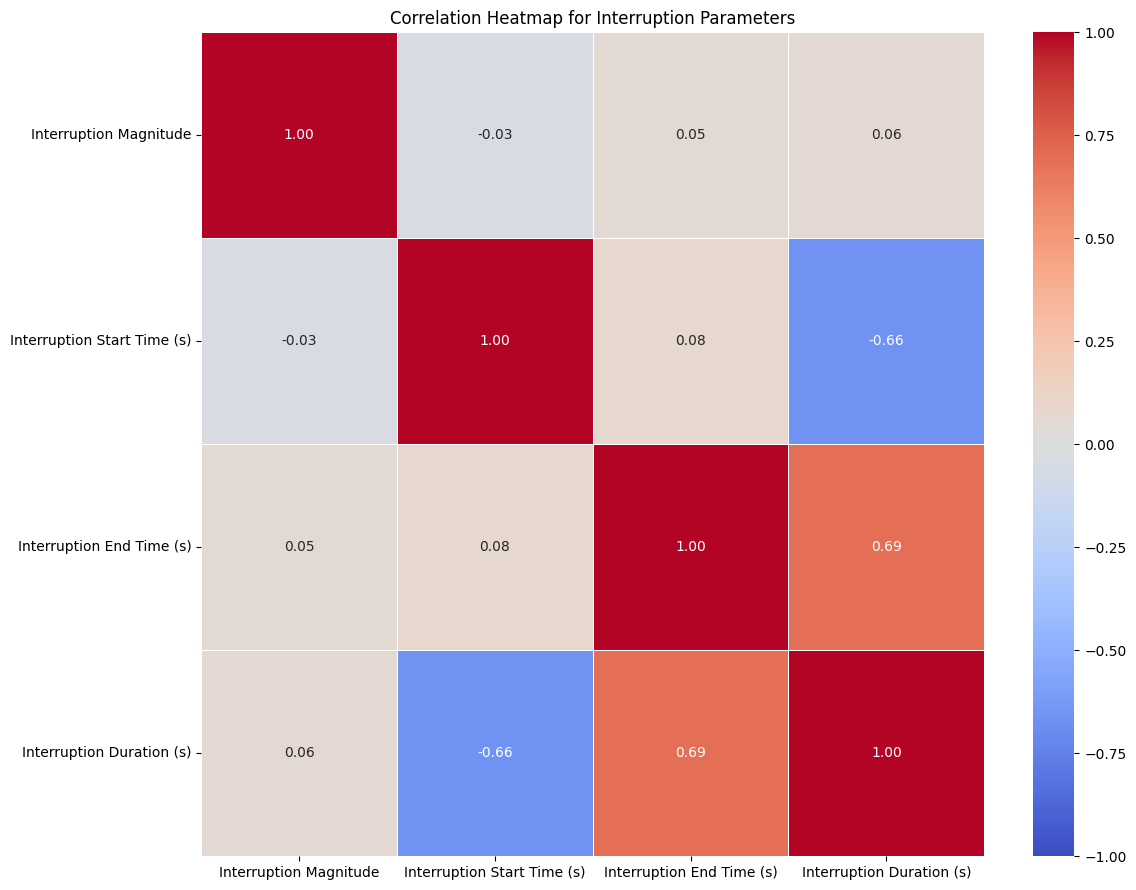

Finished collecting statistics for 'Interruption'.


In [20]:
# @title 4.d. Class 4 - Interruption Statistics

# Ensure Block 0 (Google Drive Setup) and Block 16 (Saving Signals for Class 4) have been run.

# Define the path for the statistics JSON file
STATS_FILE_NAME_4 = 'interruption_stats.json'
STATS_FILE_PATH_4 = os.path.join(CLASS_FULL_PATH_4, STATS_FILE_NAME_4)

# Define the path for the correlation heatmap image
CORRELATION_HEATMAP_FILE_NAME_4 = 'interruption_correlation_heatmap.png'
CORRELATION_HEATMAP_FILE_PATH_4 = os.path.join(CLASS_FULL_PATH_4, CORRELATION_HEATMAP_FILE_NAME_4)


print(f"Collecting statistics for '{CLASS_NAME_4}' and saving to {STATS_FILE_PATH_4}...")

# --- Data Collection ---
# Load parameters from the HDF5 file
all_interruption_magnitudes = []
all_interruption_start_times = []
all_interruption_end_times = []
all_interruption_duration_secs = []
all_interruption_duration_cycles = []

with h5py.File(HDF5_FILE_PATH_4, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS4):
        signal_params_dset = params_group[f'signal_{i+1:04d}']
        params = dict(signal_params_dset.attrs)

        all_interruption_magnitudes.append(params['interruption_magnitude'])
        all_interruption_start_times.append(params['interruption_start_time'])
        all_interruption_end_times.append(params['interruption_end_time'])
        all_interruption_duration_secs.append(params['interruption_duration_sec'])
        all_interruption_duration_cycles.append(params['interruption_duration_cycles'])

# --- Statistical Analysis ---
# Calculate expected values for interruption-specific parameters
expected_interruption_magnitude_mean, expected_interruption_magnitude_std = calculate_expected_stats(0.0, 0.1)


expected_interruption_duration_cycles_mean, expected_interruption_duration_cycles_std = calculate_expected_stats(DURATION_CYCLES_MIN, DURATION_CYCLES_MAX)


# Compile statistics into a dictionary
stats_summary = {
    "class_name": CLASS_NAME_4,
    "class_label": CLASS_LABEL_4,
    "num_signals_generated": NUM_SIGNALS_CLASS4,
    "parameters_stats": {
        "interruption_magnitude": {
            "obtained_min": np.min(all_interruption_magnitudes),
            "obtained_max": np.max(all_interruption_magnitudes),
            "obtained_mean": np.mean(all_interruption_magnitudes),
            "obtained_std_dev": np.std(all_interruption_magnitudes),
            "expected_mean": expected_interruption_magnitude_mean,
            "expected_std_dev": expected_interruption_magnitude_std,
            "range": [0.0, 0.1]
        },
        "interruption_start_time": {
            "obtained_min": np.min(all_interruption_start_times),
            "obtained_max": np.max(all_interruption_start_times),
            "obtained_mean": np.mean(all_interruption_start_times),
            "obtained_std_dev": np.std(all_interruption_start_times),
        },
        "interruption_end_time": {
            "obtained_min": np.min(all_interruption_end_times),
            "obtained_max": np.max(all_interruption_end_times),
            "obtained_mean": np.mean(all_interruption_end_times),
            "obtained_std_dev": np.std(all_interruption_end_times),
        },
        "interruption_duration_sec": {
            "obtained_min": np.min(all_interruption_duration_secs),
            "obtained_max": np.max(all_interruption_duration_secs),
            "obtained_mean": np.mean(all_interruption_duration_secs),
            "obtained_std_dev": np.std(all_interruption_duration_secs),
        },
        "interruption_duration_cycles": {
            "obtained_min": np.min(all_interruption_duration_cycles),
            "obtained_max": np.max(all_interruption_duration_cycles),
            "obtained_mean": np.mean(all_interruption_duration_cycles),
            "obtained_std_dev": np.std(all_interruption_duration_cycles),
            "expected_mean": expected_interruption_duration_cycles_mean,
            "expected_std_dev": expected_interruption_duration_cycles_std,
            "range": [DURATION_CYCLES_MIN, DURATION_CYCLES_MAX]
        }
    },
    "correlation_notes": {
        "interruption_start_time_vs_interruption_duration_sec": "Expected negative correlation due to constraint that longer durations force earlier start times within the fixed signal window.",
        "interruption_start_time_vs_interruption_end_time": "Expected strong positive correlation as end time is start time plus duration."
    }
}

# --- Save Statistics to JSON ---
with open(STATS_FILE_PATH_4, 'w') as f:
    json.dump(stats_summary, f, indent=4)

print(f"Statistics saved to: {STATS_FILE_PATH_4}")

# --- Display Summary (Optional, for immediate feedback) ---
print("\n--- Statistical Summary for Interruption (Obtained vs. Expected) ---")
for param, stats in stats_summary["parameters_stats"].items():
    print(f"\nParameter: {param}")
    print(f"  Obtained Mean: {stats['obtained_mean']:.4f} (Std Dev: {stats['obtained_std_dev']:.4f})")
    if 'expected_mean' in stats:
        print(f"  Expected Mean: {stats['expected_mean']:.4f} (Std Dev: {stats['expected_std_dev']:.4f})")
        print(f"  Range: {stats['range']}")


# --- Correlation Heatmap ---
print("\n--- Generating Correlation Heatmap for Interruption Parameters ---")

# Create DataFrame for interruption-specific parameters
correlation_data_interruption = pd.DataFrame({
    'Interruption Magnitude': all_interruption_magnitudes,
    'Interruption Start Time (s)': all_interruption_start_times,
    'Interruption End Time (s)': all_interruption_end_times,
    'Interruption Duration (s)': all_interruption_duration_secs
})

# Calculate correlation matrix
corr_interruption = correlation_data_interruption.corr()

# Plot heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr_interruption, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title(f'Correlation Heatmap for {CLASS_NAME_4} Parameters')
plt.tight_layout()

# Save heatmap
plt.savefig(CORRELATION_HEATMAP_FILE_PATH_4)
print(f"Correlation heatmap saved to: {CORRELATION_HEATMAP_FILE_PATH_4}")
plt.show()

print(f"Finished collecting statistics for '{CLASS_NAME_4}'.")


In [21]:
# @title 5.a. Class 5 - Impulsive Transient Generator

class ImpulsiveTransientGenerator(PQDBaseGenerator):
    """
    Generates an 'Impulsive Transient' disturbance signal.
    Uses double-exponential model adjusted for 10kHz sampling.
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Impulsive Transient'

        # Randomize transient parameters
        # Magnitude: 0.1-4.0 pu (IEEE 1159 Table 2)
        self.transient_magnitude = random.uniform(0.1, 4.0)

        # Polarity: positive or negative
        self.polarity = random.choice([-1, 1])

        # Start time: avoid edges (0.1-0.4s)
        self.start_time = random.uniform(0.1, 0.4)

        # Duration: 200μs-10ms (2-100 samples at 10kHz)
        self.duration = random.uniform(0.0002, 0.01)  # in seconds

        # Time constant: related to duration (τ = duration/5 for ~1% decay)
        self.tau = self.duration / 5

        # Store parameters
        self.params['transient_magnitude'] = self.transient_magnitude
        self.params['transient_polarity'] = self.polarity
        self.params['start_time'] = self.start_time
        self.params['duration'] = self.duration
        self.params['tau'] = self.tau
        self.params['fwhm'] = 2.446 * self.tau  # Full Width at Half Maximum

    def double_exponential(self, t, t0, A, tau):
        """Double exponential transient model with overflow protection"""
        time_diff = t - t0
        # Apply mask only where time_diff >= 0 and prevent very large values
        mask = (time_diff >= 0) & (time_diff < 5 * tau)  # Limit to 5 time constants
        result = np.zeros_like(t)
        result[mask] = A * (np.exp(-time_diff[mask]/tau) - np.exp(-time_diff[mask]/(tau/10)))
        return result

    def generate(self):
        """
        Generates signal with impulsive transient
        """
        base_signal = self.generate_base_sine()

        # Create transient component
        transient = self.polarity * self.double_exponential(
            self.time,
            self.start_time,
            self.transient_magnitude,
            self.tau
        )

        # Combine with base signal
        signal = base_signal + transient

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params

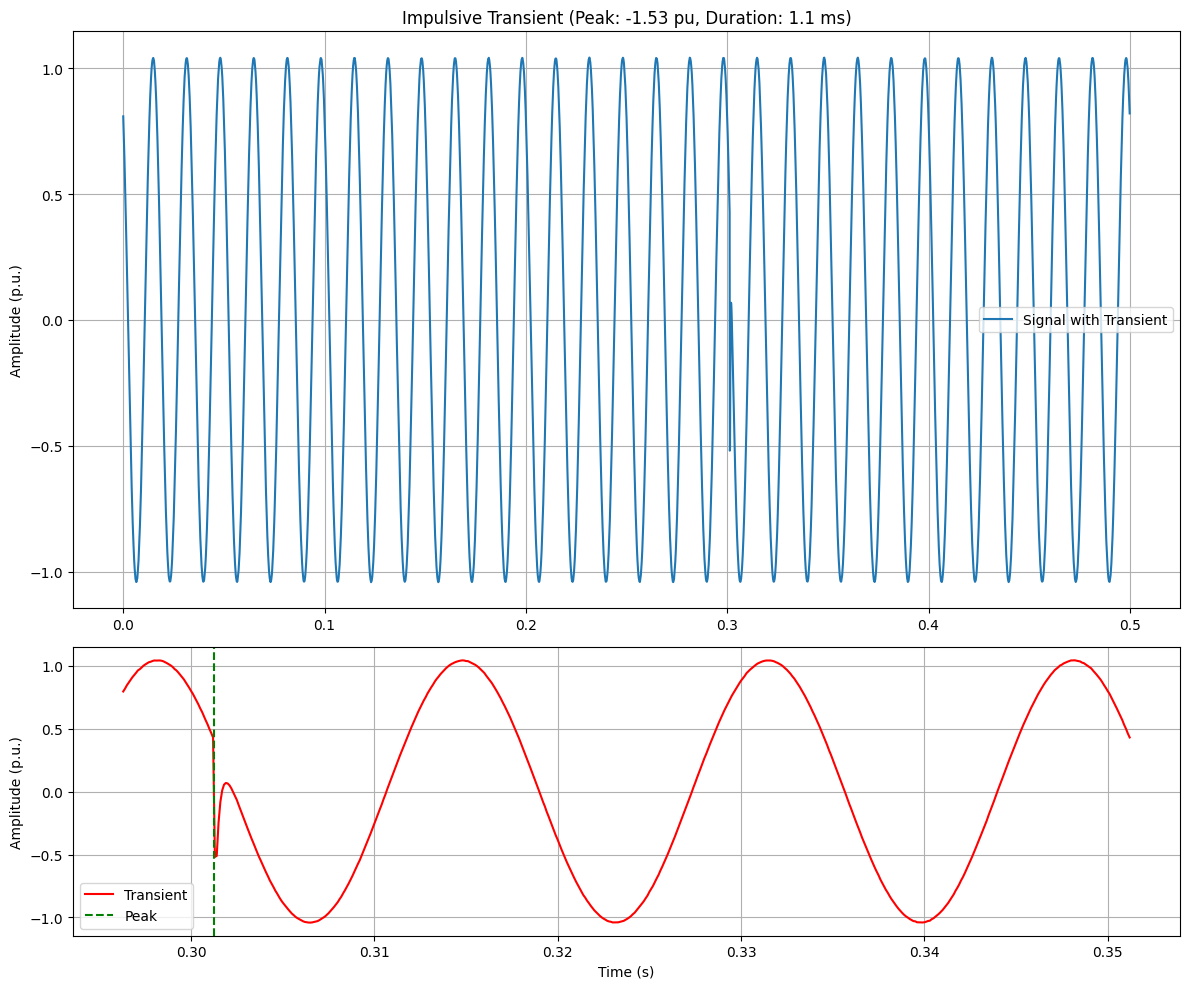

--- Impulsive Transient Parameters ---
• Peak magnitude: 1.53 pu
• Polarity: Negative
• Start time: 0.301 s
• Duration: 1.1 ms
• Time constant (τ): 0.2 ms
• FWHM: 0.6 ms
• Noise: 0.34%

Note: Parameters follow IEEE 1159 typical characteristics for
electromagnetic transients in power systems.


In [22]:
# @title 5.b. Class 5 - Impulsive Transient Plotting

# Create generator instance
transient_gen = ImpulsiveTransientGenerator()
signal_transient, params_transient = transient_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# Full signal view
ax1.plot(transient_gen.time, signal_transient, label='Signal with Transient')
ax1.set_title(f'Impulsive Transient (Peak: {params_transient["transient_magnitude"]*params_transient["transient_polarity"]:.2f} pu, '
              f'Duration: {params_transient["duration"]*1000:.1f} ms)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Zoomed transient view
zoom_start = max(0, params_transient["start_time"] - 0.005)
zoom_end = min(params_transient["t_signal"], params_transient["start_time"] + 0.05)
zoom_mask = (transient_gen.time >= zoom_start) & (transient_gen.time <= zoom_end)

ax2.plot(transient_gen.time[zoom_mask], signal_transient[zoom_mask], 'r-', label='Transient')
ax2.axvline(params_transient["start_time"], color='g', linestyle='--', label='Peak')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print parameters
print("--- Impulsive Transient Parameters ---")
print(f"• Peak magnitude: {params_transient['transient_magnitude']:.2f} pu")
print(f"• Polarity: {'Positive' if params_transient['transient_polarity'] > 0 else 'Negative'}")
print(f"• Start time: {params_transient['start_time']:.3f} s")
print(f"• Duration: {params_transient['duration']*1000:.1f} ms")
print(f"• Time constant (τ): {params_transient['tau']*1000:.1f} ms")
print(f"• FWHM: {params_transient['fwhm']*1000:.1f} ms")
print(f"• Noise: {params_transient['noise_level_percent']:.2f}%")

print("\nNote: Parameters follow IEEE 1159 typical characteristics for")
print("electromagnetic transients in power systems.")

In [23]:
# @title 5.c. Class 5 - Saving Impulsive Transient Signals

# Class details
CLASS_NAME_5 = 'Impulsive Transient'
CLASS_LABEL_5 = 5
CLASS_FOLDER_NAME_5 = f"{CLASS_LABEL_5} {CLASS_NAME_5}"
CLASS_FULL_PATH_5 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_5)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_5, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_5 = 'impulsive_transient_signals.h5'
HDF5_FILE_PATH_5 = os.path.join(CLASS_FULL_PATH_5, HDF5_FILE_NAME_5)

# Generate and save signals
NUM_SIGNALS_CLASS5 = 200

with h5py.File(HDF5_FILE_PATH_5, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS5):
        gen = ImpulsiveTransientGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_5

        for key, value in params.items():
            if isinstance(value, (list, np.ndarray)):
                signal_params.attrs[key] = str(value)
            else:
                signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS5} signals")

print(f"Saved {NUM_SIGNALS_CLASS5} signals to {HDF5_FILE_PATH_5}")

Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/5 Impulsive Transient/impulsive_transient_signals.h5


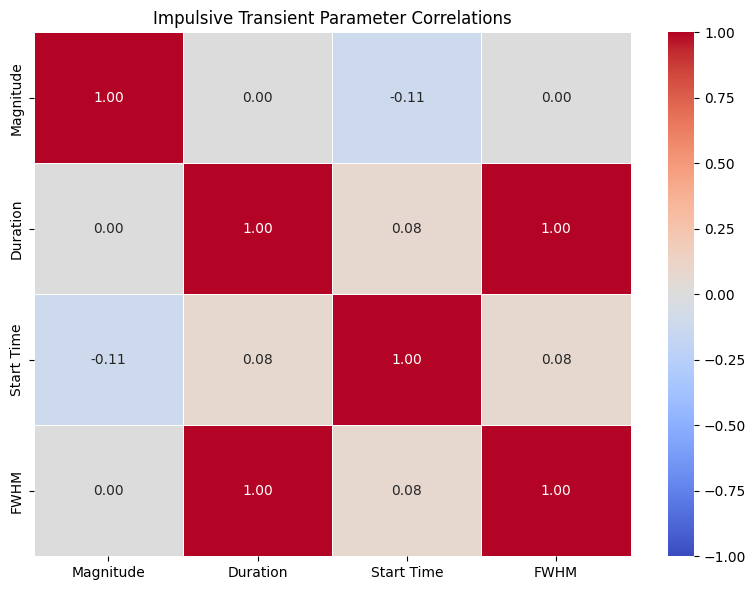

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/5 Impulsive Transient/impulsive_transient_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/5 Impulsive Transient/impulsive_transient_correlation.png


In [24]:
# @title 5.d. Class 5 - Impulsive Transient Statistics

# File paths
STATS_FILE_NAME_5 = 'impulsive_transient_stats.json'
STATS_FILE_PATH_5 = os.path.join(CLASS_FULL_PATH_5, STATS_FILE_NAME_5)

HEATMAP_FILE_NAME_5 = 'impulsive_transient_correlation.png'
HEATMAP_FILE_PATH_5 = os.path.join(CLASS_FULL_PATH_5, HEATMAP_FILE_NAME_5)

# Data collection
magnitudes = []
polarities = []
start_times = []
durations = []
taus = []
fwhms = []

with h5py.File(HDF5_FILE_PATH_5, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS5):
        ds = params_group[f'signal_{i+1:04d}']
        magnitudes.append(ds.attrs['transient_magnitude'])
        polarities.append(ds.attrs['transient_polarity'])
        start_times.append(ds.attrs['start_time'])
        durations.append(ds.attrs['duration'])
        taus.append(ds.attrs['tau'])
        fwhms.append(ds.attrs['fwhm'])

# Statistical analysis
stats = {
    "class": CLASS_NAME_5,
    "count": NUM_SIGNALS_CLASS5,
    "parameters": {
        "magnitude": {
            "min": np.min(magnitudes),
            "max": np.max(magnitudes),
            "mean": np.mean(magnitudes),
            "std": np.std(magnitudes),
            "expected_range": [0.1, 4.0]
        },
        "polarity": {
            "positive": sum(1 for p in polarities if p > 0),
            "negative": sum(1 for p in polarities if p < 0),
            "ratio": sum(1 for p in polarities if p > 0) / NUM_SIGNALS_CLASS5
        },
        "start_time": {
            "min": np.min(start_times),
            "max": np.max(start_times),
            "mean": np.mean(start_times)
        },
        "duration": {
            "min": np.min(durations),
            "max": np.max(durations),
            "mean": np.mean(durations),
            "std": np.std(durations),
            "expected_range": [0.0002, 0.01]
        },
        "fwhm": {
            "min": np.min(fwhms),
            "max": np.max(fwhms),
            "mean": np.mean(fwhms)
        }
    },
    "correlations": {}
}

# Save statistics
with open(STATS_FILE_PATH_5, 'w') as f:
    json.dump(stats, f, indent=2)

# Correlation analysis
df = pd.DataFrame({
    'Magnitude': magnitudes,
    'Duration': durations,
    'Start Time': start_times,
    'FWHM': fwhms
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('Impulsive Transient Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_5)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_5}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_5}")

In [25]:
# @title 6.a. Class 6 - Oscillatory Transient Generator

class OscillatoryTransientGenerator(PQDBaseGenerator):
    """
    Generates an 'Oscillatory Transient' disturbance signal.
    Uses damped sinusoidal model with IEEE 1159 parameters.
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Oscillatory Transient'

        # Randomize IEEE 1159 parameters
        # Frequency: 0.3-5 kHz (low-frequency transients only)
        self.frequency = random.uniform(300, 5000)

        # Magnitude: 0.1-4.0 pu
        self.magnitude = random.uniform(0.1, 4.0)

        # Decay constant: 1-50 ms
        self.decay_constant = random.uniform(0.001, 0.05)

        # Start time: avoid edges
        self.start_time = random.uniform(0.1, 0.4)

        # Duration: 0.5-3 cycles of oscillation frequency
        cycles = random.uniform(0.5, 3)
        self.duration = cycles / self.frequency

        # Store parameters
        self.params['osc_frequency'] = self.frequency
        self.params['osc_magnitude'] = self.magnitude
        self.params['osc_decay'] = self.decay_constant
        self.params['osc_start'] = self.start_time
        self.params['osc_duration'] = self.duration
        self.params['osc_cycles'] = cycles

    def generate(self):
        """
        Generates signal with oscillatory transient
        """
        base_signal = self.generate_base_sine()
        t_rel = self.time - self.start_time
        active_mask = (t_rel >= 0) & (t_rel <= self.duration)

        # Create damped sinusoidal transient
        transient = np.zeros_like(self.time)
        transient[active_mask] = (
            self.magnitude *
            np.exp(-t_rel[active_mask] / self.decay_constant) *
            np.sin(2 * np.pi * self.frequency * t_rel[active_mask])
        )

        # Combine with base signal
        signal = base_signal + transient

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params

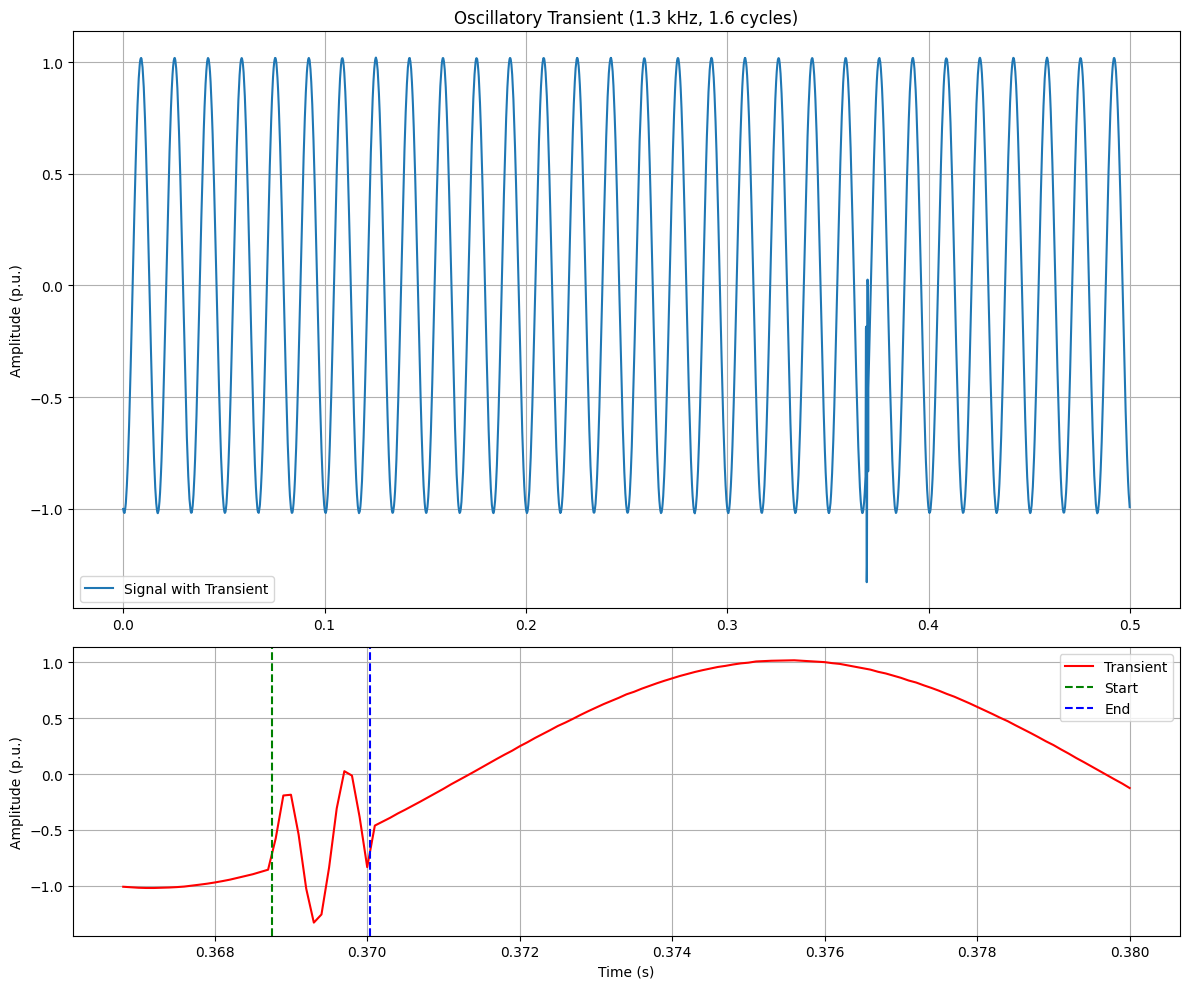

--- Oscillatory Transient Parameters ---
• Frequency: 1272 Hz (1.3 kHz)
• Magnitude: 0.67 pu
• Decay constant: 19.8 ms
• Start time: 0.369 s
• Duration: 1.3 ms
• Cycles: 1.6
• Noise: 0.30%

Note: Parameters follow IEEE 1159 typical characteristics for
oscillatory transients in power systems.


In [26]:
# @title 6.b. Class 6 - Oscillatory Transient Plotting

# Create generator instance
osc_gen = OscillatoryTransientGenerator()
signal_osc, params_osc = osc_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# Full signal view
ax1.plot(osc_gen.time, signal_osc, label='Signal with Transient')
ax1.set_title(f'Oscillatory Transient ({params_osc["osc_frequency"]/1000:.1f} kHz, '
              f'{params_osc["osc_cycles"]:.1f} cycles)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Zoomed transient view
zoom_start = max(0, params_osc["osc_start"] - 0.002)
zoom_end = min(params_osc["t_signal"], params_osc["osc_start"] + params_osc["osc_duration"] + 0.01)
zoom_mask = (osc_gen.time >= zoom_start) & (osc_gen.time <= zoom_end)

ax2.plot(osc_gen.time[zoom_mask], signal_osc[zoom_mask], 'r-', label='Transient')
ax2.axvline(params_osc["osc_start"], color='g', linestyle='--', label='Start')
ax2.axvline(params_osc["osc_start"] + params_osc["osc_duration"], color='b', linestyle='--', label='End')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

# Print parameters
print("--- Oscillatory Transient Parameters ---")
print(f"• Frequency: {params_osc['osc_frequency']:.0f} Hz ({params_osc['osc_frequency']/1000:.1f} kHz)")
print(f"• Magnitude: {params_osc['osc_magnitude']:.2f} pu")
print(f"• Decay constant: {params_osc['osc_decay']*1000:.1f} ms")
print(f"• Start time: {params_osc['osc_start']:.3f} s")
print(f"• Duration: {params_osc['osc_duration']*1000:.1f} ms")
print(f"• Cycles: {params_osc['osc_cycles']:.1f}")
print(f"• Noise: {params_osc['noise_level_percent']:.2f}%")

print("\nNote: Parameters follow IEEE 1159 typical characteristics for")
print("oscillatory transients in power systems.")

In [27]:
# @title 6.c. Class 6 -Saving Oscillatory Transient Signals

# Class details
CLASS_NAME_6 = 'Oscillatory Transient'
CLASS_LABEL_6 = 6
CLASS_FOLDER_NAME_6 = f"{CLASS_LABEL_6} {CLASS_NAME_6}"
CLASS_FULL_PATH_6 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_6)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_6, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_6 = 'oscillatory_transient_signals.h5'
HDF5_FILE_PATH_6 = os.path.join(CLASS_FULL_PATH_6, HDF5_FILE_NAME_6)

# Generate and save signals
NUM_SIGNALS_CLASS6 = 200

with h5py.File(HDF5_FILE_PATH_6, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS6):
        gen = OscillatoryTransientGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_6

        for key, value in params.items():
            if isinstance(value, (list, np.ndarray)):
                signal_params.attrs[key] = str(value)
            else:
                signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS6} signals")

print(f"Saved {NUM_SIGNALS_CLASS6} signals to {HDF5_FILE_PATH_6}")

Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/6 Oscillatory Transient/oscillatory_transient_signals.h5


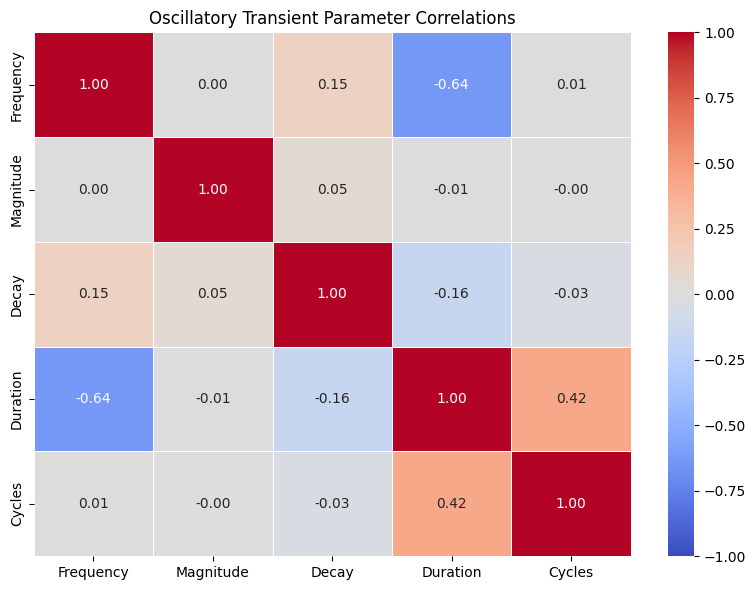

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/6 Oscillatory Transient/oscillatory_transient_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/6 Oscillatory Transient/oscillatory_transient_correlation.png


In [28]:
# @title 6.d. Class 6 - Oscillatory Transient Statistics

# File paths
STATS_FILE_NAME_6 = 'oscillatory_transient_stats.json'
STATS_FILE_PATH_6 = os.path.join(CLASS_FULL_PATH_6, STATS_FILE_NAME_6)

HEATMAP_FILE_NAME_6 = 'oscillatory_transient_correlation.png'
HEATMAP_FILE_PATH_6 = os.path.join(CLASS_FULL_PATH_6, HEATMAP_FILE_NAME_6)

# Data collection
frequencies = []
magnitudes = []
decays = []
durations = []
cycles = []

with h5py.File(HDF5_FILE_PATH_6, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS6):
        ds = params_group[f'signal_{i+1:04d}']
        frequencies.append(ds.attrs['osc_frequency'])
        magnitudes.append(ds.attrs['osc_magnitude'])
        decays.append(ds.attrs['osc_decay'])
        durations.append(ds.attrs['osc_duration'])
        cycles.append(ds.attrs['osc_cycles'])

# Statistical analysis
stats = {
    "class": CLASS_NAME_6,
    "count": NUM_SIGNALS_CLASS6,
    "parameters": {
        "frequency": {
            "min": np.min(frequencies),
            "max": np.max(frequencies),
            "mean": np.mean(frequencies),
            "std": np.std(frequencies),
            "expected_range": [300, 5000]
        },
        "magnitude": {
            "min": np.min(magnitudes),
            "max": np.max(magnitudes),
            "mean": np.mean(magnitudes),
            "std": np.std(magnitudes),
            "expected_range": [0.1, 4.0]
        },
        "decay_constant": {
            "min": np.min(decays),
            "max": np.max(decays),
            "mean": np.mean(decays),
            "std": np.std(decays),
            "expected_range": [0.001, 0.05]
        },
        "duration": {
            "min": np.min(durations),
            "max": np.max(durations),
            "mean": np.mean(durations),
            "std": np.std(durations)
        },
        "cycles": {
            "min": np.min(cycles),
            "max": np.max(cycles),
            "mean": np.mean(cycles),
            "std": np.std(cycles),
            "expected_range": [0.5, 3.0]
        }
    }
}

# Save statistics
with open(STATS_FILE_PATH_6, 'w') as f:
    json.dump(stats, f, indent=2)

# Correlation analysis
df = pd.DataFrame({
    'Frequency': frequencies,
    'Magnitude': magnitudes,
    'Decay': decays,
    'Duration': durations,
    'Cycles': cycles
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('Oscillatory Transient Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_6)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_6}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_6}")

In [29]:
# @title 7.a. Class 7 - Flicker Generator

class FlickerGenerator(PQDBaseGenerator):
    """
    Generates a 'Flicker' disturbance signal (voltage modulation).
    Mathematical Model: V(t) = [1 + λ * sin(2πf_flicker t + φ)] * V_base(t)
    Where λ is modulation depth and f_flicker is modulation frequency.
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Flicker'

        # Randomize IEEE 1159 parameters
        # Modulation frequency: 0.1-40 Hz (IEEE 1159 Table 2)
        self.f_flicker = random.uniform(0.1, 40.0)

        # Modulation depth: 0.1-7% (0.001-0.07 pu)
        self.modulation_depth = random.uniform(0.001, 0.07)

        # Modulation phase: random offset
        self.modulation_phase = random.uniform(0, 2*np.pi)

        # Store parameters
        self.params['flicker_frequency'] = self.f_flicker
        self.params['modulation_depth'] = self.modulation_depth
        self.params['modulation_phase'] = self.modulation_phase

    def generate(self):
        """
        Generates signal with voltage flicker
        """
        base_signal = self.generate_base_sine()

        # Create modulation envelope
        modulation = 1 + self.modulation_depth * np.sin(
            2 * np.pi * self.f_flicker * self.time + self.modulation_phase
        )

        # Apply modulation to base signal
        signal = base_signal * modulation

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params

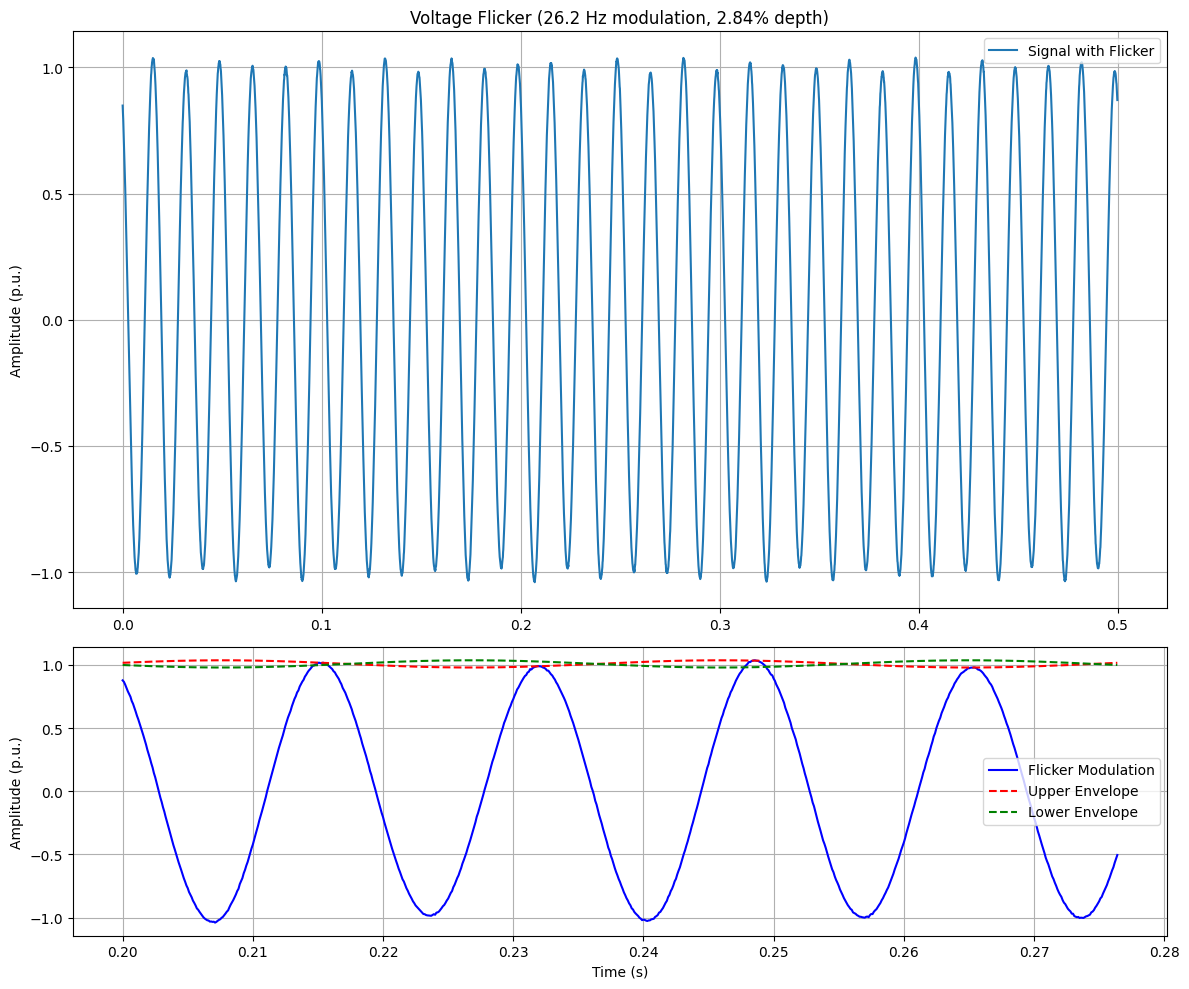

--- Flicker Parameters ---
• Modulation frequency: 26.16 Hz
• Modulation depth: 2.84%
• Base voltage: 1.007 pu
• Modulation range: 0.979 - 1.036 pu
• Noise: 0.79%

Note: Parameters follow IEEE 1159 typical characteristics for
voltage flicker in power systems (0.1-40 Hz modulation).


In [30]:
# @title 7.b. Class 7 - Flicker Plotting

# Create generator instance
flicker_gen = FlickerGenerator()
signal_flicker, params_flicker = flicker_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# Full signal view
ax1.plot(flicker_gen.time, signal_flicker, label='Signal with Flicker')
ax1.set_title(f'Voltage Flicker ({params_flicker["flicker_frequency"]:.1f} Hz modulation, '
              f'{params_flicker["modulation_depth"]*100:.2f}% depth)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Zoomed view showing modulation
zoom_start = 0.2  # Start after initial transient
zoom_end = min(0.2 + 2/params_flicker["flicker_frequency"], 0.5)  # Show 2 modulation cycles
zoom_mask = (flicker_gen.time >= zoom_start) & (flicker_gen.time <= zoom_end)

ax2.plot(flicker_gen.time[zoom_mask], signal_flicker[zoom_mask], 'b-', label='Flicker Modulation')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)

# Add envelope visualization
modulation_env = 1 + params_flicker["modulation_depth"] * np.sin(
    2 * np.pi * params_flicker["flicker_frequency"] * flicker_gen.time[zoom_mask] +
    params_flicker["modulation_phase"]
)
upper_env = modulation_env * params_flicker["base_amplitude"]
lower_env = (2 - modulation_env) * params_flicker["base_amplitude"]  # Symmetric envelope

ax2.plot(flicker_gen.time[zoom_mask], upper_env, 'r--', label='Upper Envelope')
ax2.plot(flicker_gen.time[zoom_mask], lower_env, 'g--', label='Lower Envelope')
ax2.legend()

plt.tight_layout()
plt.show()

# Print parameters
print("--- Flicker Parameters ---")
print(f"• Modulation frequency: {params_flicker['flicker_frequency']:.2f} Hz")
print(f"• Modulation depth: {params_flicker['modulation_depth']*100:.2f}%")
print(f"• Base voltage: {params_flicker['base_amplitude']:.3f} pu")
print(f"• Modulation range: {params_flicker['base_amplitude']*(1-params_flicker['modulation_depth']):.3f} - "
      f"{params_flicker['base_amplitude']*(1+params_flicker['modulation_depth']):.3f} pu")
print(f"• Noise: {params_flicker['noise_level_percent']:.2f}%")

print("\nNote: Parameters follow IEEE 1159 typical characteristics for")
print("voltage flicker in power systems (0.1-40 Hz modulation).")

In [31]:
# @title 7.c. Class 7- Saving Flicker Signals

# Class details
CLASS_NAME_7 = 'Flicker'
CLASS_LABEL_7 = 7
CLASS_FOLDER_NAME_7 = f"{CLASS_LABEL_7} {CLASS_NAME_7}"
CLASS_FULL_PATH_7 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_7)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_7, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_7 = 'flicker_signals.h5'
HDF5_FILE_PATH_7 = os.path.join(CLASS_FULL_PATH_7, HDF5_FILE_NAME_7)

# Generate and save signals
NUM_SIGNALS_CLASS7 = 200

with h5py.File(HDF5_FILE_PATH_7, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS7):
        gen = FlickerGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_7

        for key, value in params.items():
            if isinstance(value, (list, np.ndarray)):
                signal_params.attrs[key] = str(value)
            else:
                signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS7} signals")

print(f"Saved {NUM_SIGNALS_CLASS7} signals to {HDF5_FILE_PATH_7}")

Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/7 Flicker/flicker_signals.h5


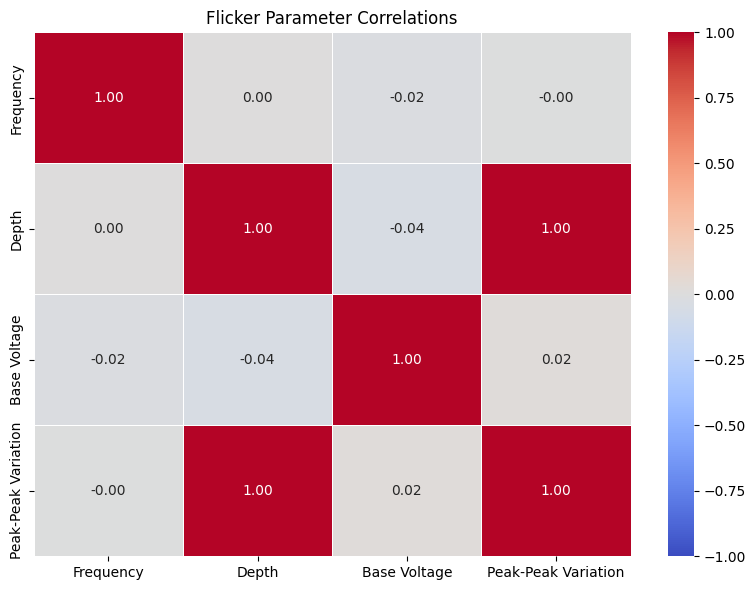

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/7 Flicker/flicker_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/7 Flicker/flicker_correlation.png


In [32]:
# @title 7.d. Class 7 - Flicker Statistics

# File paths
STATS_FILE_NAME_7 = 'flicker_stats.json'
STATS_FILE_PATH_7 = os.path.join(CLASS_FULL_PATH_7, STATS_FILE_NAME_7)

HEATMAP_FILE_NAME_7 = 'flicker_correlation.png'
HEATMAP_FILE_PATH_7 = os.path.join(CLASS_FULL_PATH_7, HEATMAP_FILE_NAME_7)

# Data collection
frequencies = []
depths = []
base_voltages = []

with h5py.File(HDF5_FILE_PATH_7, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS7):
        ds = params_group[f'signal_{i+1:04d}']
        frequencies.append(ds.attrs['flicker_frequency'])
        depths.append(ds.attrs['modulation_depth'])
        base_voltages.append(ds.attrs['base_amplitude'])

# Statistical analysis
stats = {
    "class": CLASS_NAME_7,
    "count": NUM_SIGNALS_CLASS7,
    "parameters": {
        "modulation_frequency": {
            "min": np.min(frequencies),
            "max": np.max(frequencies),
            "mean": np.mean(frequencies),
            "std": np.std(frequencies),
            "expected_range": [0.1, 40.0]
        },
        "modulation_depth": {
            "min": np.min(depths),
            "max": np.max(depths),
            "mean": np.mean(depths),
            "std": np.std(depths),
            "expected_range": [0.001, 0.07]
        },
        "base_voltage": {
            "min": np.min(base_voltages),
            "max": np.max(base_voltages),
            "mean": np.mean(base_voltages),
            "std": np.std(base_voltages),
            "expected_range": [0.95, 1.05]
        },
        "voltage_range": {
            "min": np.min([v*(1-d) for v,d in zip(base_voltages, depths)]),
            "max": np.max([v*(1+d) for v,d in zip(base_voltages, depths)]),
            "mean": np.mean([v*(1+d) - v*(1-d) for v,d in zip(base_voltages, depths)])
        }
    }
}

# Save statistics
with open(STATS_FILE_PATH_7, 'w') as f:
    json.dump(stats, f, indent=2)

# Correlation analysis
df = pd.DataFrame({
    'Frequency': frequencies,
    'Depth': depths,
    'Base Voltage': base_voltages,
    'Peak-Peak Variation': [2*v*d for v,d in zip(base_voltages, depths)]
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('Flicker Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_7)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_7}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_7}")

In [33]:
# @title 8.a. Class 8 - Notch Generator

class NotchGenerator(PQDBaseGenerator):
    """
    Generates a 'Notch' disturbance signal.
    Mathematical Model: V(t) = V_d * v_n(t) * p_m(t) + v_osc(t)
    Where V_d is the depth of the notch, v_n(t) is the notch function, and v_osc(t) is the oscillatory transient.
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Notch'

        # Randomize notch parameters
        self.residual_voltage = random.uniform(0.01, 0.1)  # Residual voltage during notch
        self.notch_width = random.uniform(0.0001, 0.0005)  # 100-500 μs
        self.notch_count = random.randint(1, 3)  # 1-3 notches per half-cycle

        # Oscillatory transient parameters
        self.osc_mag = random.uniform(0.05, 0.5)  # Oscillatory transient magnitude
        self.osc_freq = random.uniform(300, 5000)  # Oscillatory transient frequency
        self.osc_decay = random.uniform(0.0005, 0.005)  # Oscillatory transient decay

        # Generate event timing parameters
        self.event_start, self.event_end, self.event_duration_sec, self.event_duration_cycles = self._get_random_disturbance_timing()

        # Store parameters
        self.params.update({
            'residual_voltage': self.residual_voltage,
            'notch_width': self.notch_width,
            'notch_count': self.notch_count,
            'osc_mag': self.osc_mag,
            'osc_freq': self.osc_freq,
            'osc_decay': self.osc_decay,
            'event_start': self.event_start,
            'event_end': self.event_end,
            'event_duration_sec': self.event_duration_sec,
            'event_duration_cycles': self.event_duration_cycles
        })

    def generate(self):
        """
        Generates signal with notches
        """
        base_signal = self.generate_base_sine()
        signal = base_signal.copy()

        # Determine the half-cycle times within [event_start, event_end]
        half_cycle = 1 / (2 * self.f_base)
        t = self.event_start
        notch_times = []

        # Find zero crossings and determine notch times
        while t < self.event_end:
            notch_times.append(t)
            t += half_cycle

        # Apply notches
        for notch_time in notch_times[:self.notch_count]:
            idx_start = np.argmax(self.time >= notch_time)
            idx_end = np.argmax(self.time >= notch_time + self.notch_width)
            if idx_end == 0:
                idx_end = len(self.time)
            # Set the voltage during the notch to the residual voltage
            signal[idx_start:idx_end] = self.residual_voltage

            # Add oscillatory transient after the notch
            t_rel = self.time - (notch_time + self.notch_width)
            active_mask = (t_rel >= 0) & (t_rel < 5 * self.osc_decay)  # 5 time constants

            # Create transient array with proper broadcasting
            transient = np.zeros_like(self.time)
            transient[active_mask] = (
                self.osc_mag *
                np.exp(-t_rel[active_mask] / self.osc_decay) *
                np.sin(2 * np.pi * self.osc_freq * t_rel[active_mask])
            )

            signal += transient

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params


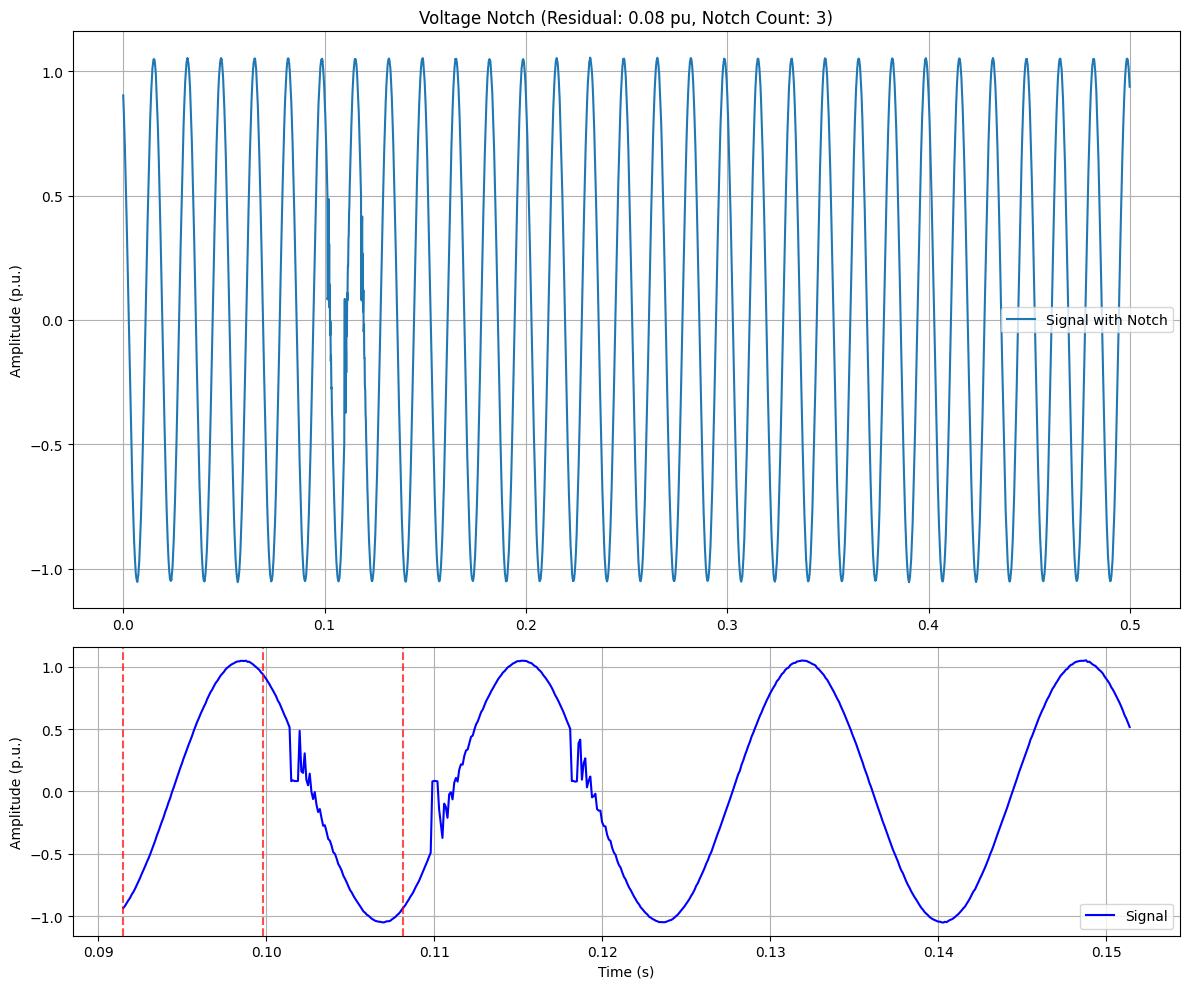

--- Notch Parameters ---
• Residual voltage: 0.08 pu
• Notch width: 0.4 ms
• Notch count: 3
• Oscillatory transient magnitude: 0.22 pu
• Oscillatory transient frequency: 3252 Hz
• Oscillatory transient decay: 0.7 ms
• Noise: 0.62%

Note: Parameters follow IEEE 1159 typical characteristics for
voltage notches in power systems.


In [34]:
# @title 8.b. Class 8 -  Notch Plotting

# Create generator instance
notch_gen = NotchGenerator()
signal_notch, params_notch = notch_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [2, 1]})

# Full signal view
ax1.plot(notch_gen.time, signal_notch, label='Signal with Notch')
ax1.set_title(f'Voltage Notch (Residual: {params_notch["residual_voltage"]:.2f} pu, '
              f'Notch Count: {params_notch["notch_count"]})')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Zoomed view showing notches
# Find first notch time to zoom in
if 'event_start' in params_notch:  # Use actual event start if available
    zoom_start = max(0, params_notch["event_start"] - 0.01)
    zoom_end = min(params_notch["t_signal"], params_notch["event_start"] + 0.05)
else:  # Fallback
    zoom_start = 0.1
    zoom_end = 0.2

zoom_mask = (notch_gen.time >= zoom_start) & (notch_gen.time <= zoom_end)

ax2.plot(notch_gen.time[zoom_mask], signal_notch[zoom_mask], 'b-', label='Signal')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (p.u.)')
ax2.grid(True)
ax2.legend()

# Add markers for notches
for i in range(min(params_notch["notch_count"], 3)):  # Show up to 3 notches
    if i < len(notch_gen.time[zoom_mask]):
        ax2.axvline(notch_gen.time[zoom_mask][0] + i * (1/(2 * params_notch["base_frequency"])),
                    color='r', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print parameters
print("--- Notch Parameters ---")
print(f"• Residual voltage: {params_notch['residual_voltage']:.2f} pu")
print(f"• Notch width: {params_notch['notch_width']*1000:.1f} ms")
print(f"• Notch count: {params_notch['notch_count']}")
print(f"• Oscillatory transient magnitude: {params_notch['osc_mag']:.2f} pu")
print(f"• Oscillatory transient frequency: {params_notch['osc_freq']:.0f} Hz")
print(f"• Oscillatory transient decay: {params_notch['osc_decay']*1000:.1f} ms")
print(f"• Noise: {params_notch['noise_level_percent']:.2f}%")

print("\nNote: Parameters follow IEEE 1159 typical characteristics for")
print("voltage notches in power systems.")

In [35]:
# @title 8.c. Class 8 - Saving Notch Signals

# Class details
CLASS_NAME_8 = 'Notch'
CLASS_LABEL_8 = 8
CLASS_FOLDER_NAME_8 = f"{CLASS_LABEL_8} {CLASS_NAME_8}"
CLASS_FULL_PATH_8 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_8)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_8, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_8 = 'notch_signals.h5'
HDF5_FILE_PATH_8 = os.path.join(CLASS_FULL_PATH_8, HDF5_FILE_NAME_8)

# Generate and save signals
NUM_SIGNALS_CLASS8 = 200

with h5py.File(HDF5_FILE_PATH_8, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS8):
        gen = NotchGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_8

        for key, value in params.items():
            if isinstance(value, (list, np.ndarray)):
                signal_params.attrs[key] = str(value)
            else:
                signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS8} signals")

print(f"Saved {NUM_SIGNALS_CLASS8} signals to {HDF5_FILE_PATH_8}")


Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/8 Notch/notch_signals.h5


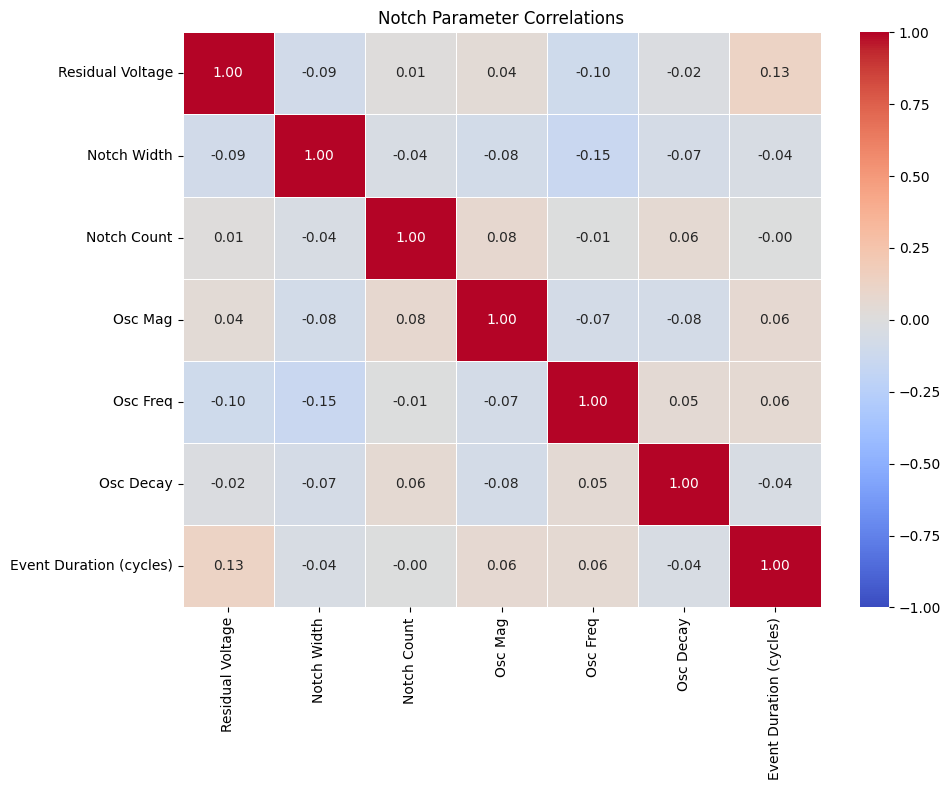

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/8 Notch/notch_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/8 Notch/notch_correlation.png


In [36]:
# @title 8.d. Class 8 - Notch Statistics

# File paths
STATS_FILE_NAME_8 = 'notch_stats.json'
STATS_FILE_PATH_8 = os.path.join(CLASS_FULL_PATH_8, STATS_FILE_NAME_8)

HEATMAP_FILE_NAME_8 = 'notch_correlation.png'
HEATMAP_FILE_PATH_8 = os.path.join(CLASS_FULL_PATH_8, HEATMAP_FILE_NAME_8)

# Data collection
residuals = []
notch_widths = []
notch_counts = []
osc_mags = []
osc_freqs = []
osc_decays = []
event_durations_cycles = []  # Primary duration measure

with h5py.File(HDF5_FILE_PATH_8, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS8):
        ds = params_group[f'signal_{i+1:04d}']
        residuals.append(float(ds.attrs['residual_voltage']))
        notch_widths.append(float(ds.attrs['notch_width']))
        notch_counts.append(int(ds.attrs['notch_count']))
        osc_mags.append(float(ds.attrs['osc_mag']))
        osc_freqs.append(float(ds.attrs['osc_freq']))
        osc_decays.append(float(ds.attrs['osc_decay']))
        event_durations_cycles.append(float(ds.attrs['event_duration_cycles']))  # Only cycles

# Statistical analysis
stats = {
    "class": CLASS_NAME_8,
    "count": NUM_SIGNALS_CLASS8,
    "parameters": {
        "residual_voltage": {
            "min": float(np.min(residuals)),
            "max": float(np.max(residuals)),
            "mean": float(np.mean(residuals)),
            "std": float(np.std(residuals)),
            "expected_range": [0.01, 0.1]
        },
        "notch_width": {
            "min": float(np.min(notch_widths)),
            "max": float(np.max(notch_widths)),
            "mean": float(np.mean(notch_widths)),
            "std": float(np.std(notch_widths)),
            "expected_range": [0.0001, 0.0005]
        },
        "notch_count": {
            "min": int(np.min(notch_counts)),
            "max": int(np.max(notch_counts)),
            "mean": float(np.mean(notch_counts)),
            "std": float(np.std(notch_counts)),
            "expected_range": [1, 3]
        },
        "osc_mag": {
            "min": float(np.min(osc_mags)),
            "max": float(np.max(osc_mags)),
            "mean": float(np.mean(osc_mags)),
            "std": float(np.std(osc_mags)),
            "expected_range": [0.05, 0.5]
        },
        "osc_freq": {
            "min": float(np.min(osc_freqs)),
            "max": float(np.max(osc_freqs)),
            "mean": float(np.mean(osc_freqs)),
            "std": float(np.std(osc_freqs)),
            "expected_range": [300, 5000]
        },
        "osc_decay": {
            "min": float(np.min(osc_decays)),
            "max": float(np.max(osc_decays)),
            "mean": float(np.mean(osc_decays)),
            "std": float(np.std(osc_decays)),
            "expected_range": [0.0005, 0.005]
        },
        "event_duration_cycles": {
            "min": float(np.min(event_durations_cycles)),
            "max": float(np.max(event_durations_cycles)),
            "mean": float(np.mean(event_durations_cycles)),
            "std": float(np.std(event_durations_cycles)),
            "expected_range": [
                float(DURATION_CYCLES_MIN),
                float(DURATION_CYCLES_MAX)
            ]
        }
    }
}

# Save statistics
with open(STATS_FILE_PATH_8, 'w') as f:
    json.dump(stats, f, indent=2)

# Correlation analysis - using only cycles for duration
df = pd.DataFrame({
    'Residual Voltage': residuals,
    'Notch Width': notch_widths,
    'Notch Count': notch_counts,
    'Osc Mag': osc_mags,
    'Osc Freq': osc_freqs,
    'Osc Decay': osc_decays,
    'Event Duration (cycles)': event_durations_cycles
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('Notch Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_8)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_8}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_8}")


In [37]:
# @title 9.a. Class 9 - Harmonics Generator

class HarmonicsGenerator(PQDBaseGenerator):
    """
    Generates a signal with harmonic distortion.
    Mathematical Model: V(t) = A1*sin(2πf1 t + φ1) + Σ [Ah*sin(2π*h*f1 t + φh)] for odd h=3 to 49
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics'

        # Randomize harmonic parameters
        self.harmonic_orders = []
        self.harmonic_amplitudes = []
        self.harmonic_phases = []

        # Select number of harmonics (3-7)
        num_harmonics = random.randint(3, 7)
        # Select odd harmonic orders (3, 5, ..., 49) without duplicates
        odd_harmonics = list(range(3, 50, 2))  # Odd orders from 3 to 49
        self.harmonic_orders = random.sample(odd_harmonics, num_harmonics)

        # Assign random amplitudes (0.1% to 20% of fundamental amplitude)
        base_amp = self.A_base
        for _ in range(num_harmonics):
            amp = random.uniform(0.001, 0.2) * base_amp #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation
            #Check IEEE 519 Standard
            self.harmonic_amplitudes.append(amp)

        # Assign random phases (0 to 2π)
        self.harmonic_phases = [random.uniform(0, 2*np.pi) for _ in range(num_harmonics)]

        # Store parameters
        self.params['harmonic_orders'] = self.harmonic_orders
        self.params['harmonic_amplitudes'] = self.harmonic_amplitudes
        self.params['harmonic_phases'] = self.harmonic_phases

        # Calculate THD (Total Harmonic Distortion) as RMS of odd harmonics / RMS of fundamental
        thd = np.sqrt(np.sum(np.array(self.harmonic_amplitudes)**2)) / base_amp
        self.params['thd'] = thd

    def generate(self):
        # Generate fundamental component
        signal = self.generate_base_sine()

        # Add harmonics
        for h, A, phi in zip(self.harmonic_orders, self.harmonic_amplitudes, self.harmonic_phases):
            harmonic_component = A * np.sin(2 * np.pi * h * self.f_base * self.time + phi)
            signal += harmonic_component

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params


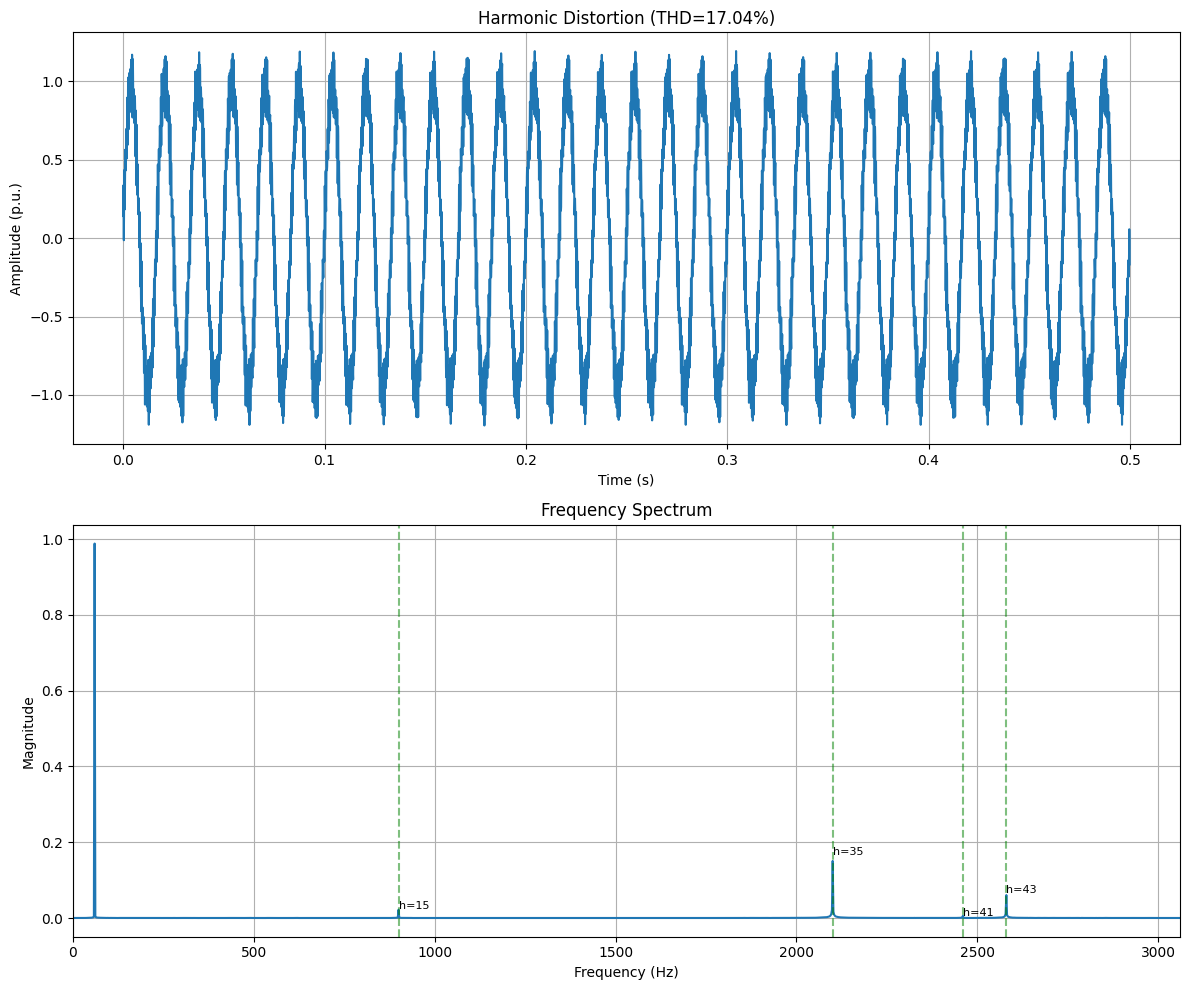

--- Harmonic Parameters ---
• Fundamental: 0.989 pu, 60 Hz
• THD: 17.04%
Harmonic components:
  h=41: 0.0062 pu, phase=4.97 rad
  h=15: 0.0219 pu, phase=0.45 rad
  h=35: 0.1545 pu, phase=0.55 rad
  h=43: 0.0631 pu, phase=5.96 rad
• Noise: 0.90%

Note: Harmonics follow IEEE 1159 and IEEE 519 standards.


In [38]:
# @title 9.b. Class 9 - Harmonics Plotting

# Create generator instance
harmonics_gen = HarmonicsGenerator()
signal_harmonics, params_harmonics = harmonics_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Time domain plot
ax1.plot(harmonics_gen.time, signal_harmonics)
ax1.set_title(f'Harmonic Distortion (THD={params_harmonics["thd"]*100:.2f}%)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)

# Frequency domain plot (FFT)
n = len(signal_harmonics)
freqs = np.fft.rfftfreq(n, d=1/FS_DEFAULT)
fft_vals = np.abs(np.fft.rfft(signal_harmonics)) / n * 2

ax2.plot(freqs, fft_vals)
ax2.set_title('Frequency Spectrum')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_xlim(0, 3060)  # Show up to 3060 Hz
ax2.grid(True)

# Highlight harmonic frequencies
for h, A in zip(params_harmonics['harmonic_orders'], params_harmonics['harmonic_amplitudes']):
    freq = h * F_NOMINAL
    ax2.axvline(freq, color='g', linestyle='--', alpha=0.5)
    ax2.text(freq, fft_vals[np.argmin(np.abs(freqs - freq))]*1.1, f'h={h}', fontsize=8)

plt.tight_layout()
plt.show()

# Print parameters
print("--- Harmonic Parameters ---")
print(f"• Fundamental: {params_harmonics['base_amplitude']:.3f} pu, {F_NOMINAL} Hz")
print(f"• THD: {params_harmonics['thd']*100:.2f}%")
print("Harmonic components:")
for h, A, phi in zip(params_harmonics['harmonic_orders'],
                     params_harmonics['harmonic_amplitudes'],
                     params_harmonics['harmonic_phases']):
    print(f"  h={h}: {A:.4f} pu, phase={phi:.2f} rad")
print(f"• Noise: {params_harmonics['noise_level_percent']:.2f}%")

print("\nNote: Harmonics follow IEEE 1159 and IEEE 519 standards.")


In [39]:
# @title 9.c. Class 9 - Saving Harmonics Signals

# Class details
CLASS_NAME_9 = 'Harmonics'
CLASS_LABEL_9 = 9
CLASS_FOLDER_NAME_9 = f"{CLASS_LABEL_9} {CLASS_NAME_9}"
CLASS_FULL_PATH_9 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_9)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_9, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_9 = 'harmonics_signals.h5'
HDF5_FILE_PATH_9 = os.path.join(CLASS_FULL_PATH_9, HDF5_FILE_NAME_9)

# Generate and save signals
NUM_SIGNALS_CLASS9 = 200

with h5py.File(HDF5_FILE_PATH_9, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS9):
        gen = HarmonicsGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_9

        # Store harmonic parameters as attributes
        for key, value in params.items():
            if key in ['harmonic_orders', 'harmonic_amplitudes', 'harmonic_phases']:
                # Store lists as JSON strings
                signal_params.attrs[key] = json.dumps(value)
            else:
                if isinstance(value, (list, np.ndarray)):
                    signal_params.attrs[key] = str(value)
                else:
                    signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS9} signals")

print(f"Saved {NUM_SIGNALS_CLASS9} signals to {HDF5_FILE_PATH_9}")


Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/9 Harmonics/harmonics_signals.h5


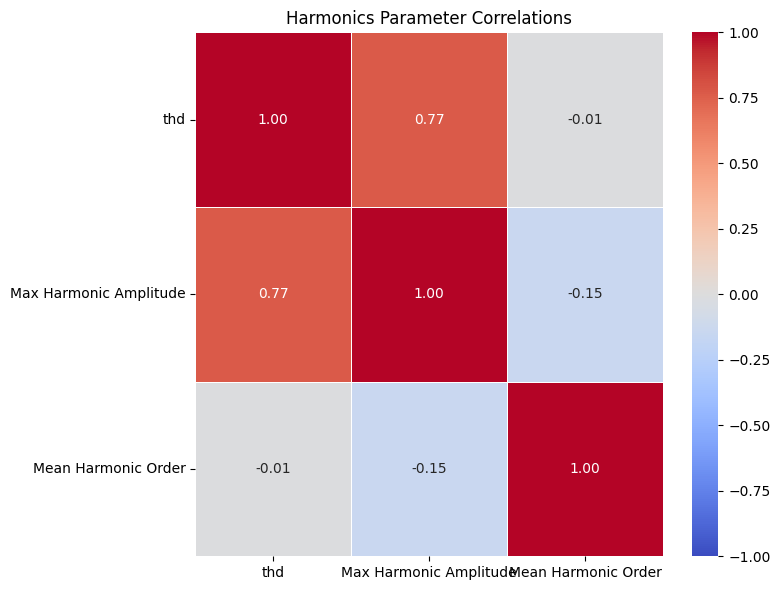

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/9 Harmonics/harmonics_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/9 Harmonics/harmonics_correlation.png


In [40]:
# @title 9.d. Class 9 - Harmonics Statistics

# File paths
STATS_FILE_NAME_9 = 'harmonics_stats.json'
STATS_FILE_PATH_9 = os.path.join(CLASS_FULL_PATH_9, STATS_FILE_NAME_9)

HEATMAP_FILE_NAME_9 = 'harmonics_correlation.png'
HEATMAP_FILE_PATH_9 = os.path.join(CLASS_FULL_PATH_9, HEATMAP_FILE_NAME_9)

# Data collection
thds = []
harmonic_orders = []  # List of lists
harmonic_amplitudes = []  # List of lists

with h5py.File(HDF5_FILE_PATH_9, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS9):
        ds = params_group[f'signal_{i+1:04d}']
        thds.append(float(ds.attrs['thd']))
        harmonic_orders.append(json.loads(ds.attrs['harmonic_orders']))
        harmonic_amplitudes.append(json.loads(ds.attrs['harmonic_amplitudes']))

# Flatten harmonic data for overall stats
all_orders = [h for orders in harmonic_orders for h in orders]
all_amplitudes = [A for amps in harmonic_amplitudes for A in amps]

# Statistical analysis
stats = {
    "class": CLASS_NAME_9,
    "count": NUM_SIGNALS_CLASS9,
    "parameters": {
        "thd": {
            "min": float(np.min(thds)),
            "max": float(np.max(thds)),
            "mean": float(np.mean(thds)),
            "std": float(np.std(thds)),
            "expected_range": [0.0, 0.2]  # 0-20%
        },
        "harmonic_order": {
            "min": int(np.min(all_orders)),
            "max": int(np.max(all_orders)),
            "mean": float(np.mean(all_orders)),
            "std": float(np.std(all_orders)),
            "expected_range": [3, 49]  # Only odd orders
        },
        "harmonic_amplitude": {
            "min": float(np.min(all_amplitudes)),
            "max": float(np.max(all_amplitudes)),
            "mean": float(np.mean(all_amplitudes)),
            "std": float(np.std(all_amplitudes)),
            "expected_range": [0.001 * A_NOMINAL, 0.2 * A_NOMINAL]  # 0.1-20% of nominal
        }
    }
}

# Save statistics
with open(STATS_FILE_PATH_9, 'w') as f:
    json.dump(stats, f, indent=2)

# Prepare data for correlation analysis
# We'll use per-signal aggregates: THD and max harmonic amplitude
max_amps = [max(amps) for amps in harmonic_amplitudes]
mean_orders = [np.mean(orders) for orders in harmonic_orders]

df = pd.DataFrame({
    'thd': thds,
    'Max Harmonic Amplitude': max_amps,
    'Mean Harmonic Order': mean_orders
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('Harmonics Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_9)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_9}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_9}")


In [41]:
# @title 10.a. Class 10 - Interharmonics Generator

class InterharmonicsGenerator(PQDBaseGenerator):
    """
    Generates a signal with interharmonic distortion.
    Mathematical Model: V(t) = A1*sin(2πf1 t + φ1) + Σ [Ai*sin(2πfi t + φi)] for non-integer fi
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Interharmonics'

        # Randomize interharmonic parameters
        self.interharmonic_frequencies = []
        self.interharmonic_amplitudes = []
        self.interharmonic_phases = []

        # Select number of interharmonics (3-7)
        num_interharmonics = random.randint(3, 7)

        # Generate random interharmonic frequencies (not integer multiples of fundamental)
        while len(self.interharmonic_frequencies) < num_interharmonics:
            freq = random.uniform(0.1 * F_NOMINAL, 50.0 * F_NOMINAL)  # Random frequency range
            if not any(np.isclose(freq, h * F_NOMINAL, atol=1e-2) for h in range(1, 50)):  # Avoid integer multiples
                self.interharmonic_frequencies.append(freq)

        # Assign random amplitudes (0.1% to 20% of fundamental amplitude)
        base_amp = self.A_base
        for _ in range(num_interharmonics):
            amp = random.uniform(0.001, 0.2) * base_amp #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation
            #Check IEEE 519 Standard
            self.interharmonic_amplitudes.append(amp)

        # Assign random phases (0 to 2π)
        self.interharmonic_phases = [random.uniform(0, 2*np.pi) for _ in range(num_interharmonics)]

        # Store parameters
        self.params['interharmonic_frequencies'] = self.interharmonic_frequencies
        self.params['interharmonic_amplitudes'] = self.interharmonic_amplitudes
        self.params['interharmonic_phases'] = self.interharmonic_phases

    def generate(self):
        # Generate fundamental component
        signal = self.generate_base_sine()

        # Add interharmonics
        for f, A, phi in zip(self.interharmonic_frequencies, self.interharmonic_amplitudes, self.interharmonic_phases):
            interharmonic_component = A * np.sin(2 * np.pi * f * self.time + phi)
            signal += interharmonic_component

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params


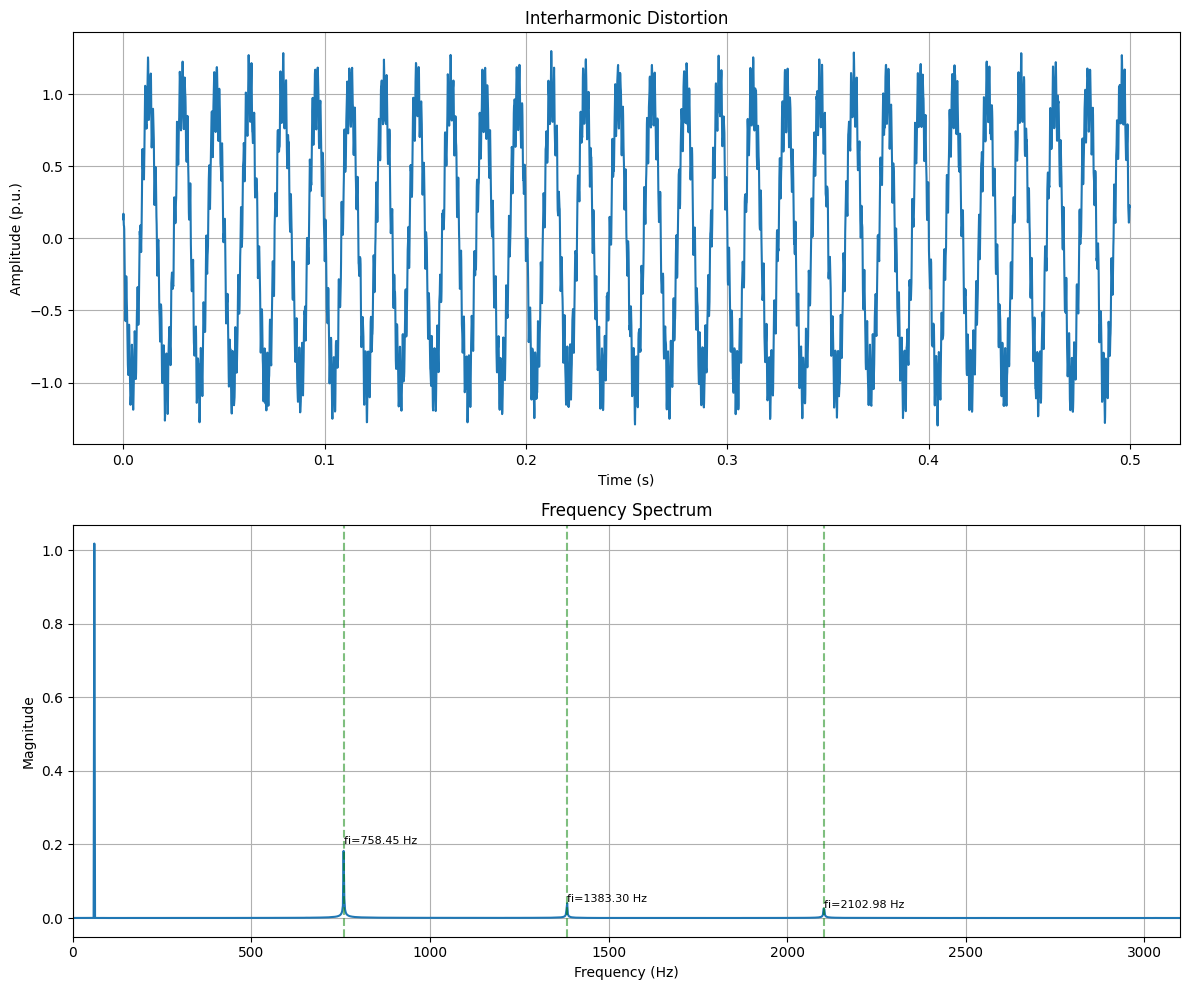

--- Interharmonic Parameters ---
Interharmonic components:
  fi=758.45 Hz: 0.1987 pu, phase=6.11 rad
  fi=1383.30 Hz: 0.0499 pu, phase=1.32 rad
  fi=2102.98 Hz: 0.0387 pu, phase=1.16 rad
• Noise: 0.44%

Note: Interharmonics follow IEEE 1159 standards.


In [42]:
# @title 10.b. Class 10 - Interharmonics Plotting

# Create generator instance
interharmonics_gen = InterharmonicsGenerator()
signal_interharmonics, params_interharmonics = interharmonics_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Time domain plot
ax1.plot(interharmonics_gen.time, signal_interharmonics)
ax1.set_title('Interharmonic Distortion')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)

# Frequency domain plot (FFT)
n = len(signal_interharmonics)
freqs = np.fft.rfftfreq(n, d=1/FS_DEFAULT)
fft_vals = np.abs(np.fft.rfft(signal_interharmonics)) / n * 2

ax2.plot(freqs, fft_vals)
ax2.set_title('Frequency Spectrum')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Magnitude')
ax2.set_xlim(0, 3100)  # Show up to 3100 Hz
ax2.grid(True)

# Highlight interharmonic frequencies
for f, A in zip(params_interharmonics['interharmonic_frequencies'], params_interharmonics['interharmonic_amplitudes']):
    ax2.axvline(f, color='g', linestyle='--', alpha=0.5)
    ax2.text(f, fft_vals[np.argmin(np.abs(freqs - f))]*1.1, f'fi={f:.2f} Hz', fontsize=8)

plt.tight_layout()
plt.show()

# Print parameters
print("--- Interharmonic Parameters ---")
print("Interharmonic components:")
for f, A, phi in zip(params_interharmonics['interharmonic_frequencies'],
                     params_interharmonics['interharmonic_amplitudes'],
                     params_interharmonics['interharmonic_phases']):
    print(f"  fi={f:.2f} Hz: {A:.4f} pu, phase={phi:.2f} rad")
print(f"• Noise: {params_interharmonics['noise_level_percent']:.2f}%")

print("\nNote: Interharmonics follow IEEE 1159 standards.")


In [43]:
# @title 10.c. Class 10 - Saving Interharmonics Signals

# Class details
CLASS_NAME_10 = 'Interharmonics'
CLASS_LABEL_10 = 10
CLASS_FOLDER_NAME_10 = f"{CLASS_LABEL_10} {CLASS_NAME_10}"
CLASS_FULL_PATH_10 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_10)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_10, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_10 = 'interharmonics_signals.h5'
HDF5_FILE_PATH_10 = os.path.join(CLASS_FULL_PATH_10, HDF5_FILE_NAME_10)

# Generate and save signals
NUM_SIGNALS_CLASS10 = 200

with h5py.File(HDF5_FILE_PATH_10, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS10):
        gen = InterharmonicsGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_10

        # Store interharmonic parameters as attributes
        for key, value in params.items():
            if key in ['interharmonic_frequencies', 'interharmonic_amplitudes', 'interharmonic_phases']:
                # Store lists as JSON strings
                signal_params.attrs[key] = json.dumps(value)
            else:
                if isinstance(value, (list, np.ndarray)):
                    signal_params.attrs[key] = str(value)
                else:
                    signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS10} signals")

print(f"Saved {NUM_SIGNALS_CLASS10} signals to {HDF5_FILE_PATH_10}")


Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/10 Interharmonics/interharmonics_signals.h5


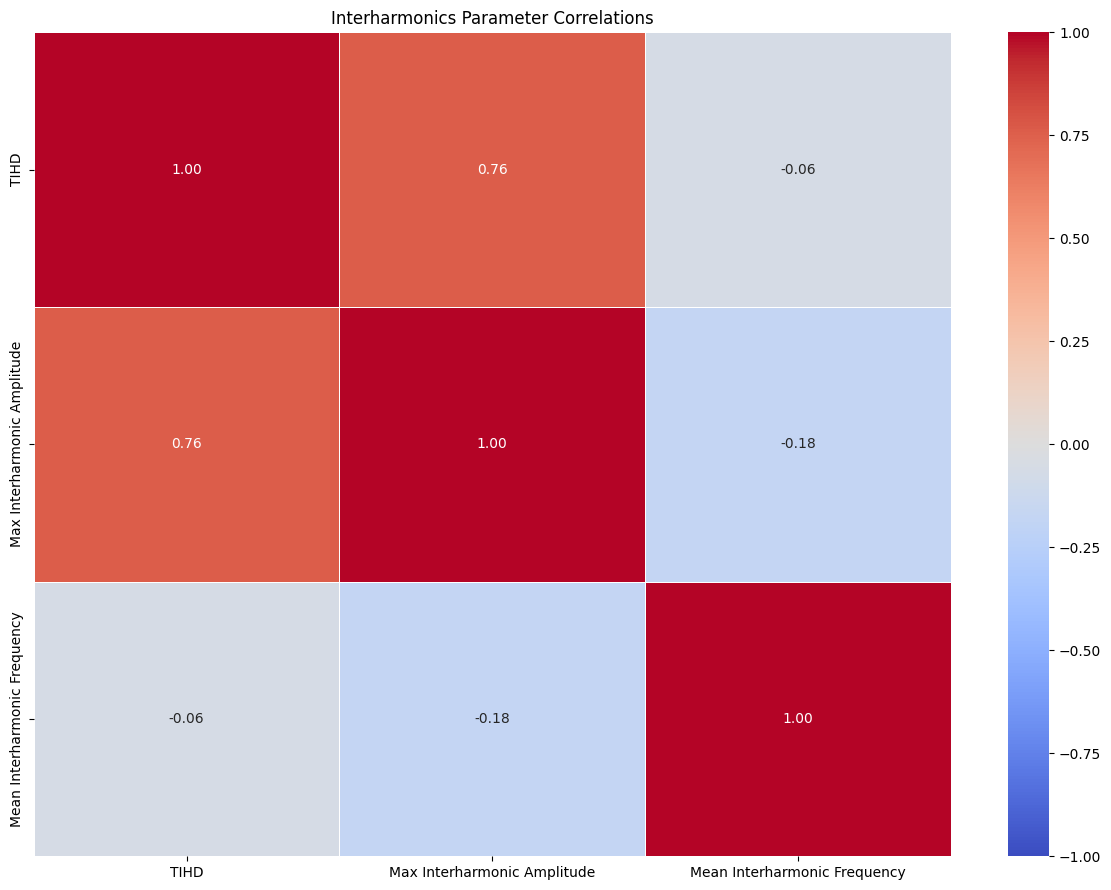

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/10 Interharmonics/interharmonics_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/10 Interharmonics/interharmonics_correlation.png


In [44]:
# @title 10.d. Class 10 - Interharmonics Statistics

# File paths
STATS_FILE_NAME_10 = 'interharmonics_stats.json'
STATS_FILE_PATH_10 = os.path.join(CLASS_FULL_PATH_10, STATS_FILE_NAME_10)

HEATMAP_FILE_NAME_10 = 'interharmonics_correlation.png'
HEATMAP_FILE_PATH_10 = os.path.join(CLASS_FULL_PATH_10, HEATMAP_FILE_NAME_10)

# Data collection
interharmonic_frequencies = []  # List of lists
interharmonic_amplitudes = []  # List of lists
ti_hds = []  # Total Interharmonic Distortion

with h5py.File(HDF5_FILE_PATH_10, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS10):
        ds = params_group[f'signal_{i+1:04d}']
        interharmonic_frequencies.append(json.loads(ds.attrs['interharmonic_frequencies']))
        interharmonic_amplitudes.append(json.loads(ds.attrs['interharmonic_amplitudes']))

        # Calculate TIHD for this signal
        base_amp = ds.attrs['base_amplitude']  # Assuming base amplitude is stored
        ti_hd = np.sqrt(np.sum(np.array(interharmonic_amplitudes[-1])**2)) / base_amp
        ti_hds.append(ti_hd)

# Flatten interharmonic data for overall stats
all_frequencies = [f for freqs in interharmonic_frequencies for f in freqs]
all_amplitudes = [A for amps in interharmonic_amplitudes for A in amps]

# Statistical analysis
stats = {
    "class": CLASS_NAME_10,
    "count": NUM_SIGNALS_CLASS10,
    "parameters": {
        "TIHD": {
            "min": float(np.min(ti_hds)),
            "max": float(np.max(ti_hds)),
            "mean": float(np.mean(ti_hds)),
            "std": float(np.std(ti_hds)),
            "expected_range": [0.0, 0.2]  # Example range for interharmonics
        },
        "interharmonic_frequency": {
            "min": float(np.min(all_frequencies)),
            "max": float(np.max(all_frequencies)),
            "mean": float(np.mean(all_frequencies)),
            "std": float(np.std(all_frequencies)),
            "expected_range": [0.1 * F_NOMINAL, 2.0 * F_NOMINAL]  # Example range
        },
        "interharmonic_amplitude": {
            "min": float(np.min(all_amplitudes)),
            "max": float(np.max(all_amplitudes)),
            "mean": float(np.mean(all_amplitudes)),
            "std": float(np.std(all_amplitudes)),
            "expected_range": [0.001 * A_NOMINAL, 0.2 * A_NOMINAL]  # 0.1-20% of nominal
        },
        "max_interharmonic_amplitude": {
            "max": float(np.max([max(amps) for amps in interharmonic_amplitudes])),
            "mean": float(np.mean([max(amps) for amps in interharmonic_amplitudes])),
        },
        "mean_interharmonic_frequency": {
            "mean": float(np.mean([np.mean(freqs) for freqs in interharmonic_frequencies])),
        }
    }
}

# Save statistics
with open(STATS_FILE_PATH_10, 'w') as f:
    json.dump(stats, f, indent=2)

# Prepare data for correlation analysis
# We'll use per-signal aggregates: TIHD and max interharmonic amplitude
max_amps = [max(amps) for amps in interharmonic_amplitudes]
mean_freqs = [np.mean(freqs) for freqs in interharmonic_frequencies]

df = pd.DataFrame({
    'TIHD': ti_hds,
    'Max Interharmonic Amplitude': max_amps,
    'Mean Interharmonic Frequency': mean_freqs,
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('Interharmonics Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_10)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_10}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_10}")


In [45]:
# @title 11.a. Class 11 - DC Offset Generator

class DCOffsetGenerator(PQDBaseGenerator):
    """
    Generates a signal with a DC offset and calculates relevant analysis parameters.
    Mathematical Model: V(t) = V_AC(t) + V_DC
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'DC Offset'

        # Randomize DC offset within IEEE 1159 typical range
        self.dc_offset = random.uniform(-0.1 * A_NOMINAL, 0.1 * A_NOMINAL)  # -10% to +10% of nominal
        self.params['dc_offset'] = self.dc_offset

    def calculate_waveform_parameters(self, signal, pure_ac):
        """
        Calculate additional waveform parameters for DC offset analysis
        """
        # Calculate RMS values
        rms_total = np.sqrt(np.mean(signal**2))
        rms_ac = np.sqrt(np.mean(pure_ac**2))

        # Calculate waveform asymmetry
        pos_half = signal[signal > 0]
        neg_half = signal[signal < 0]
        asymmetry = (np.mean(np.abs(pos_half)) - np.mean(np.abs(neg_half))) / A_NOMINAL

        # Calculate zero-crossing distortion
        zero_crossings = np.where(np.diff(np.sign(signal)))[0]
        if len(zero_crossings) > 1:
            periods = np.diff(self.time[zero_crossings])
            period_distortion = np.std(periods) / np.mean(periods)
        else:
            period_distortion = 0

        # DC/AC ratio
        dc_ac_ratio = self.dc_offset / self.params['base_amplitude']

        return {
            'rms_total': rms_total,
            'rms_ac': rms_ac,
            'asymmetry': asymmetry,
            'zero_crossing_distortion': period_distortion,
            'dc_ac_ratio': dc_ac_ratio
        }

    def generate(self):
        # Generate fundamental component
        pure_ac = self.generate_base_sine()

        # Add DC offset
        signal = pure_ac + self.dc_offset

        # Calculate waveform parameters
        waveform_params = self.calculate_waveform_parameters(signal, pure_ac)
        self.params.update(waveform_params)

        # Add noise
        signal_with_noise = self._add_noise(signal)

        return signal_with_noise, self.params


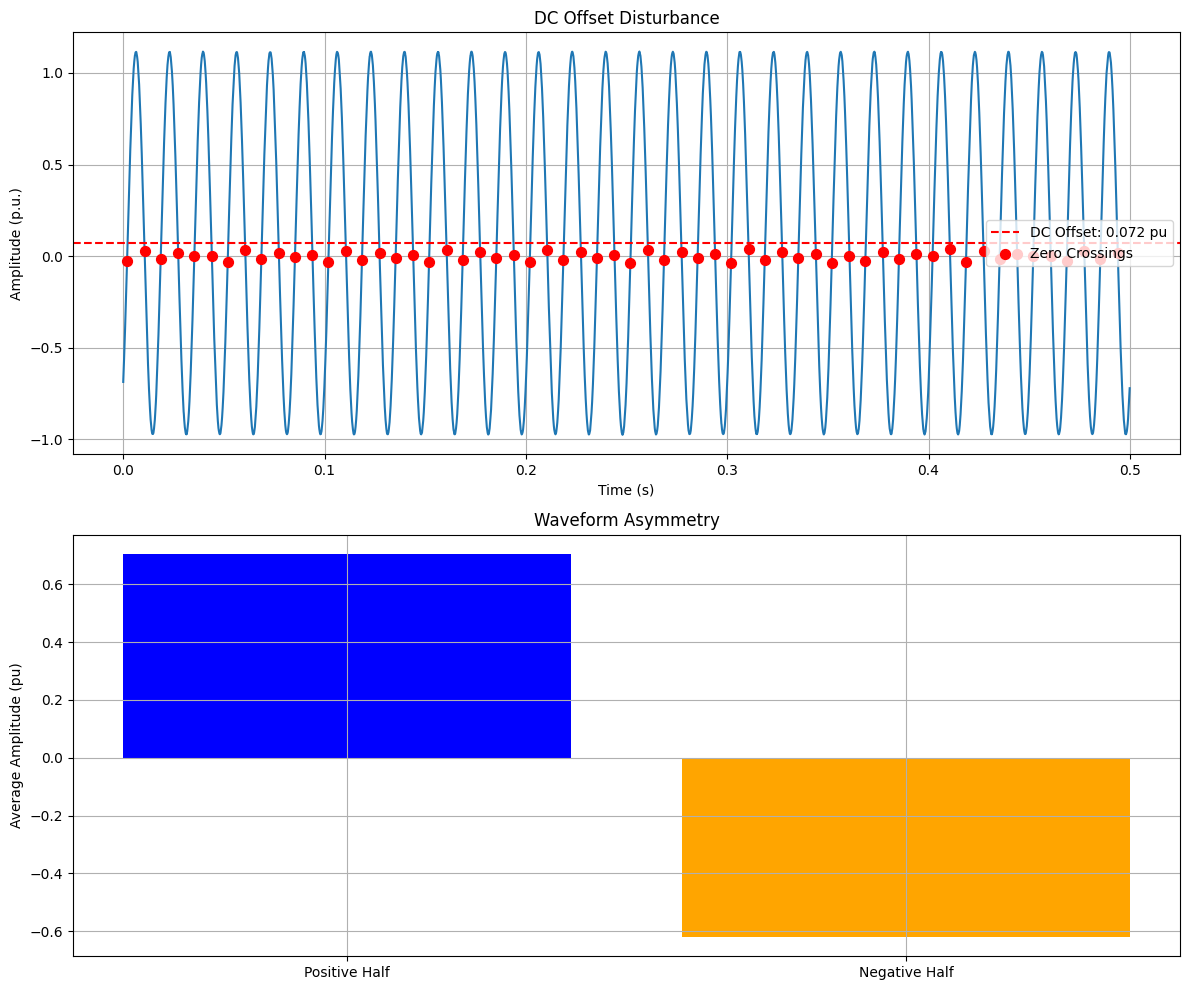


DC Offset Parameters Summary
Parameter                      | Value               
--------------------------------------------------
DC Offset                      | 0.0718 pu
DC/AC Ratio                    | 0.0688
Asymmetry                      | 8.53%
Zero-crossing Distortion       | 4.40%
RMS Total                      | 0.7409 pu
RMS AC                         | 0.7374 pu
Noise Level                    | 0.39%

Note: Parameters follow IEEE 1159 standards for DC offset disturbances.
Asymmetry = (Avg(Positive) - Avg(Negative)) / Nominal Amplitude
Zero-crossing distortion = std(periods) / mean(periods)


In [46]:
# @title 11.b. Class 11 - DC Offset Plotting
# Create generator instance
dc_offset_gen = DCOffsetGenerator()
signal_dc_offset, params_dc_offset = dc_offset_gen.generate()

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Time domain plot
ax1.plot(dc_offset_gen.time, signal_dc_offset)
ax1.axhline(params_dc_offset['dc_offset'], color='r', linestyle='--', label=f'DC Offset: {params_dc_offset["dc_offset"]:.3f} pu')
ax1.set_title(f'DC Offset Disturbance')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (p.u.)')
ax1.grid(True)
ax1.legend()

# Highlight zero-crossings
zero_crossings = np.where(np.diff(np.sign(signal_dc_offset)))[0]
if len(zero_crossings) > 0:
    ax1.scatter(dc_offset_gen.time[zero_crossings], signal_dc_offset[zero_crossings],
                c='red', s=50, zorder=5, label='Zero Crossings')
    ax1.legend()

# Asymmetry visualization
ax2.bar(['Positive Half', 'Negative Half'],
        [np.mean(signal_dc_offset[signal_dc_offset > 0]),
         np.mean(signal_dc_offset[signal_dc_offset < 0])],
        color=['blue', 'orange'])
ax2.set_title('Waveform Asymmetry')
ax2.set_ylabel('Average Amplitude (pu)')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print parameters as a formatted table
print("\n" + "="*50)
print("DC Offset Parameters Summary")
print("="*50)
print(f"{'Parameter':<30} | {'Value':<20}")
print("-"*50)
print(f"{'DC Offset':<30} | {params_dc_offset['dc_offset']:.4f} pu")
print(f"{'DC/AC Ratio':<30} | {params_dc_offset['dc_ac_ratio']:.4f}")
print(f"{'Asymmetry':<30} | {params_dc_offset['asymmetry']*100:.2f}%")
print(f"{'Zero-crossing Distortion':<30} | {params_dc_offset['zero_crossing_distortion']*100:.2f}%")
print(f"{'RMS Total':<30} | {params_dc_offset['rms_total']:.4f} pu")
print(f"{'RMS AC':<30} | {params_dc_offset['rms_ac']:.4f} pu")
print(f"{'Noise Level':<30} | {params_dc_offset['noise_level_percent']:.2f}%")
print("="*50)

# Additional note
print("\nNote: Parameters follow IEEE 1159 standards for DC offset disturbances.")
print("Asymmetry = (Avg(Positive) - Avg(Negative)) / Nominal Amplitude")
print("Zero-crossing distortion = std(periods) / mean(periods)")


In [47]:
# @title 11.c. Class 11 - Saving DC Offset Signals

# Class details
CLASS_NAME_11 = 'DC Offset'
CLASS_LABEL_11 = 11
CLASS_FOLDER_NAME_11 = f"{CLASS_LABEL_11} {CLASS_NAME_11}"
CLASS_FULL_PATH_11 = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER_NAME_11)

# Create directory if needed
os.makedirs(CLASS_FULL_PATH_11, exist_ok=True)

# HDF5 file path
HDF5_FILE_NAME_11 = 'dc_offset_signals.h5'
HDF5_FILE_PATH_11 = os.path.join(CLASS_FULL_PATH_11, HDF5_FILE_NAME_11)

# Generate and save signals
NUM_SIGNALS_CLASS11 = 200

with h5py.File(HDF5_FILE_PATH_11, 'w') as f:
    signals_dset = f.create_dataset('signals',
                                    shape=(0, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    maxshape=(None, int(T_SIGNAL_DEFAULT * FS_DEFAULT)),
                                    dtype=np.float32,
                                    compression="gzip")

    params_group = f.create_group('parameters')

    for i in range(NUM_SIGNALS_CLASS11):
        gen = DCOffsetGenerator()
        signal, params = gen.generate()

        signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
        signals_dset[-1] = signal

        signal_params = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
        signal_params.attrs['class_label'] = CLASS_LABEL_11

        # Store all parameters as attributes
        for key, value in params.items():
            if isinstance(value, (list, np.ndarray)):
                signal_params.attrs[key] = str(value)
            else:
                signal_params.attrs[key] = value

        if (i+1) % 50 == 0:
            print(f"Generated {i+1}/{NUM_SIGNALS_CLASS11} signals")

print(f"Saved {NUM_SIGNALS_CLASS11} signals to {HDF5_FILE_PATH_11}")

Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/11 DC Offset/dc_offset_signals.h5


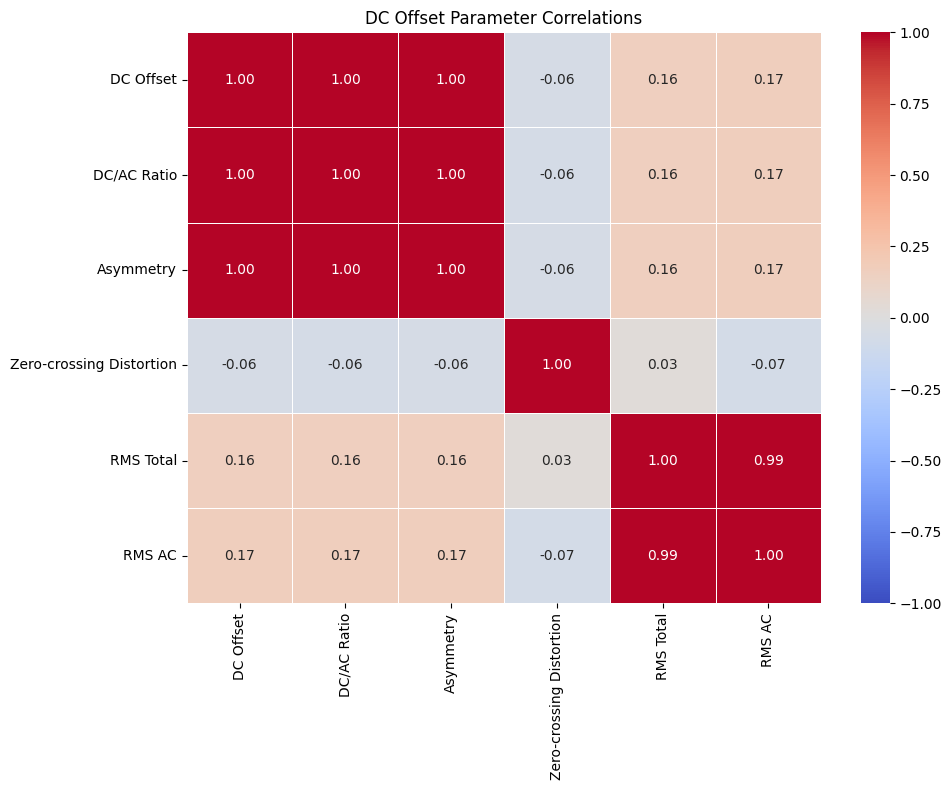

Statistics saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/11 DC Offset/dc_offset_stats.json
Heatmap saved to /content/drive/MyDrive/PQD_Synthetic_Dataset/11 DC Offset/dc_offset_correlation.png


In [48]:
# @title 11.d. Class 11 -  DC Offset Statistics

# File paths
STATS_FILE_NAME_11 = 'dc_offset_stats.json'
STATS_FILE_PATH_11 = os.path.join(CLASS_FULL_PATH_11, STATS_FILE_NAME_11)

HEATMAP_FILE_NAME_11 = 'dc_offset_correlation.png'
HEATMAP_FILE_PATH_11 = os.path.join(CLASS_FULL_PATH_11, HEATMAP_FILE_NAME_11)

# Data collection
dc_offsets = []
dc_ac_ratios = []
asymmetries = []
zero_crossing_dists = []
rms_totals = []
rms_acs = []

with h5py.File(HDF5_FILE_PATH_11, 'r') as f:
    params_group = f['parameters']
    for i in range(NUM_SIGNALS_CLASS11):
        ds = params_group[f'signal_{i+1:04d}']
        dc_offsets.append(float(ds.attrs['dc_offset']))
        dc_ac_ratios.append(float(ds.attrs['dc_ac_ratio']))
        asymmetries.append(float(ds.attrs['asymmetry']))
        zero_crossing_dists.append(float(ds.attrs['zero_crossing_distortion']))
        rms_totals.append(float(ds.attrs['rms_total']))
        rms_acs.append(float(ds.attrs['rms_ac']))

# Statistical analysis
stats = {
    "class": CLASS_NAME_11,
    "count": NUM_SIGNALS_CLASS11,
    "parameters": {
        "dc_offset": {
            "min": float(np.min(dc_offsets)),
            "max": float(np.max(dc_offsets)),
            "mean": float(np.mean(dc_offsets)),
            "std": float(np.std(dc_offsets)),
            "expected_range": [-0.1 * A_NOMINAL, 0.1 * A_NOMINAL]
        },
        "dc_ac_ratio": {
            "min": float(np.min(dc_ac_ratios)),
            "max": float(np.max(dc_ac_ratios)),
            "mean": float(np.mean(dc_ac_ratios)),
            "std": float(np.std(dc_ac_ratios)),
            "expected_range": [-0.1, 0.1]
        },
        "asymmetry": {
            "min": float(np.min(asymmetries)),
            "max": float(np.max(asymmetries)),
            "mean": float(np.mean(asymmetries)),
            "std": float(np.std(asymmetries)),
            "expected_range": [-0.1, 0.1]
        },
        "zero_crossing_distortion": {
            "min": float(np.min(zero_crossing_dists)),
            "max": float(np.max(zero_crossing_dists)),
            "mean": float(np.mean(zero_crossing_dists)),
            "std": float(np.std(zero_crossing_dists)),
            "expected_range": [0.0, 0.1]
        },
        "rms_total": {
            "min": float(np.min(rms_totals)),
            "max": float(np.max(rms_totals)),
            "mean": float(np.mean(rms_totals)),
            "std": float(np.std(rms_totals))
        },
        "rms_ac": {
            "min": float(np.min(rms_acs)),
            "max": float(np.max(rms_acs)),
            "mean": float(np.mean(rms_acs)),
            "std": float(np.std(rms_acs))
        }
    }
}

# Save statistics
with open(STATS_FILE_PATH_11, 'w') as f:
    json.dump(stats, f, indent=2)

# Prepare data for correlation analysis
df = pd.DataFrame({
    'DC Offset': dc_offsets,
    'DC/AC Ratio': dc_ac_ratios,
    'Asymmetry': asymmetries,
    'Zero-crossing Distortion': zero_crossing_dists,
    'RMS Total': rms_totals,
    'RMS AC': rms_acs
})

corr = df.corr()

# Plot and save heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
plt.title('DC Offset Parameter Correlations')
plt.tight_layout()
plt.savefig(HEATMAP_FILE_PATH_11)
plt.show()

print(f"Statistics saved to {STATS_FILE_PATH_11}")
print(f"Heatmap saved to {HEATMAP_FILE_PATH_11}")

In [76]:
# @title 12.a. Class 12 - Harmonics with Sag (M1) Generation

class HarmonicsWithSagGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Sag'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)

        # Correct definition: sag_magnitude is the remaining voltage
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        combined_signal = sag_envelope * harmonics_signal

        final_signal = self._add_noise(combined_signal)
        self.params.update({'sag_params': sag_params, 'harmonics_params': harmonics_params})

        return final_signal, self.params

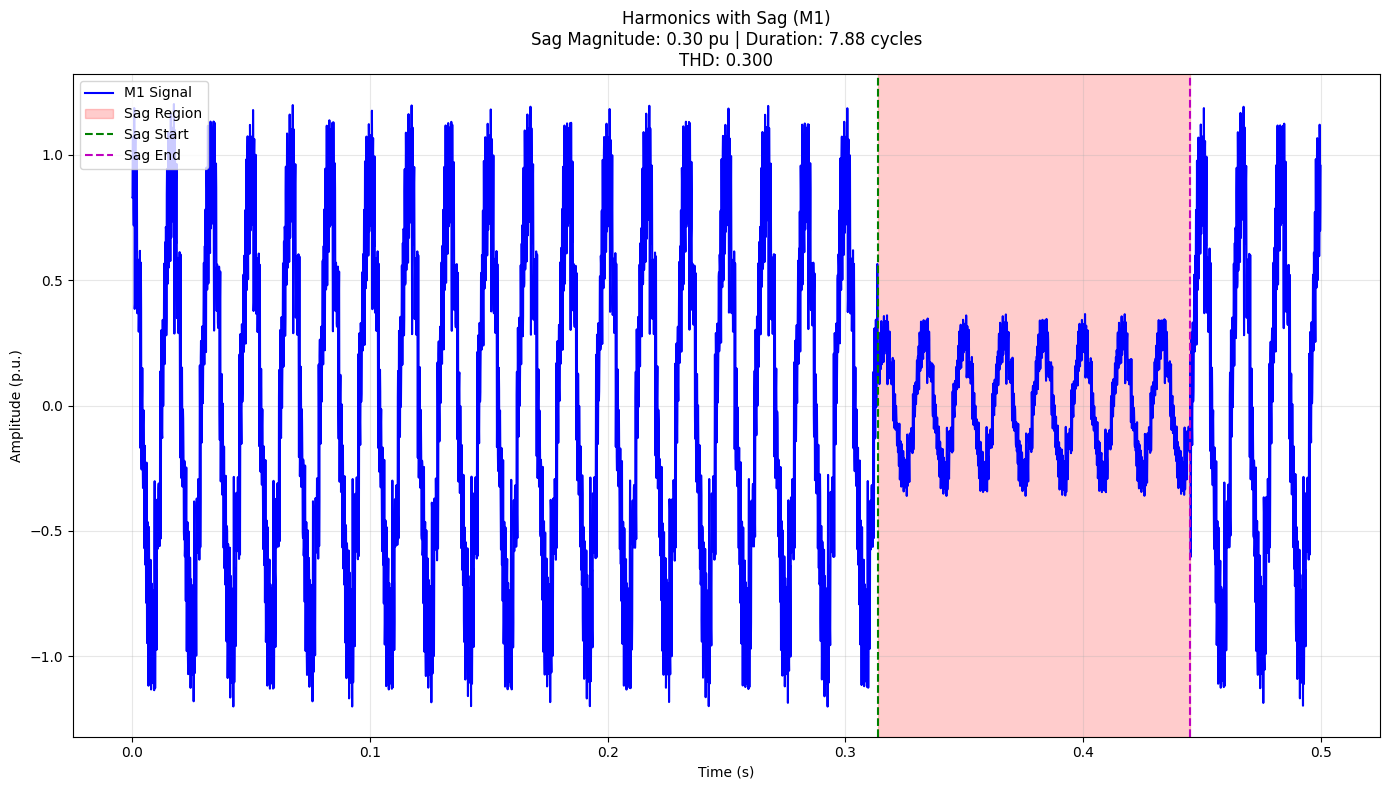

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Sag
Base Amplitude (p.u.): 0.9943
Base Frequency (Hz): 60.0013
Sag Magnitude (p.u.): 0.3037
Sag Duration (cycles): 7.88
THD: 0.2998
Noise Level (%): 0.96


In [50]:
# @title 12.b. Class 12 - Harmonics with Sag (M1) Plotting
def plot_harmonics_with_sag(signal, params):
    """Plot harmonics with sag signal with annotations"""
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M1 Signal')
    sag_params = params['sag_params']
    t1 = sag_params.get('sag_start_time', 0)
    t2 = sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    plt.axvline(t1, color='g', linestyle='--', label='Sag Start')
    plt.axvline(t2, color='m', linestyle='--', label='Sag End')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Sag (M1)\nSag Magnitude: {sag_params.get('sag_magnitude', 'N/A'):.2f} pu | Duration: {sag_params.get('sag_duration_cycles', 'N/A'):.2f} cycles\nTHD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Display Parameters ---
    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params['sag_magnitude']:.4f}")
    print(f"Sag Duration (cycles): {sag_params['sag_duration_cycles']:.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSagGenerator()
signal, params = gen.generate()
plot_harmonics_with_sag(signal, params)

In [51]:
# @title 12.c. Class 12 - Saving Harmonics with Sag (M1) Signals
def save_harmonics_with_sag_signals(num_signals=200):
    """Generate and save harmonics with sag signals with debug info"""
    CLASS_NAME = 'Harmonics with Sag (M1)'
    CLASS_LABEL = 12
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_sag_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSagGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_harmonics_with_sag_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)/harmonics_with_sag_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)/harmonics_with_sag_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)/harmonics_with_sag_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
sag_magnitude: 200 valid values
sag_duration_cycles: 200 valid values
thd: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)/harmonics_with_sag_signals_stats.json


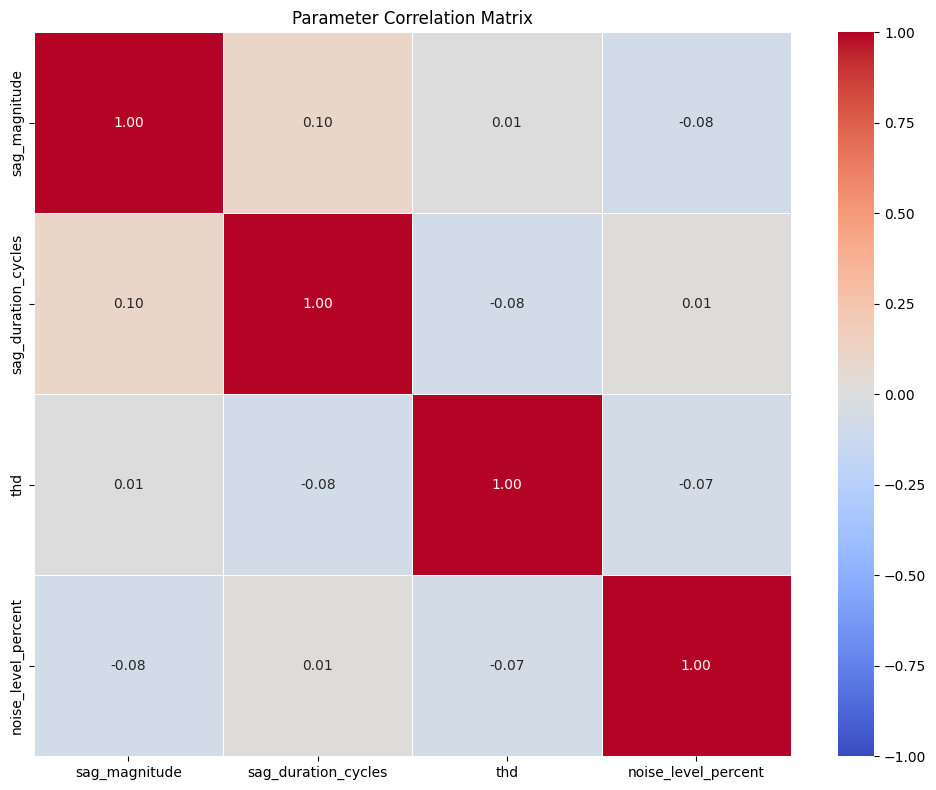

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)/harmonics_with_sag_signals_correlation.png


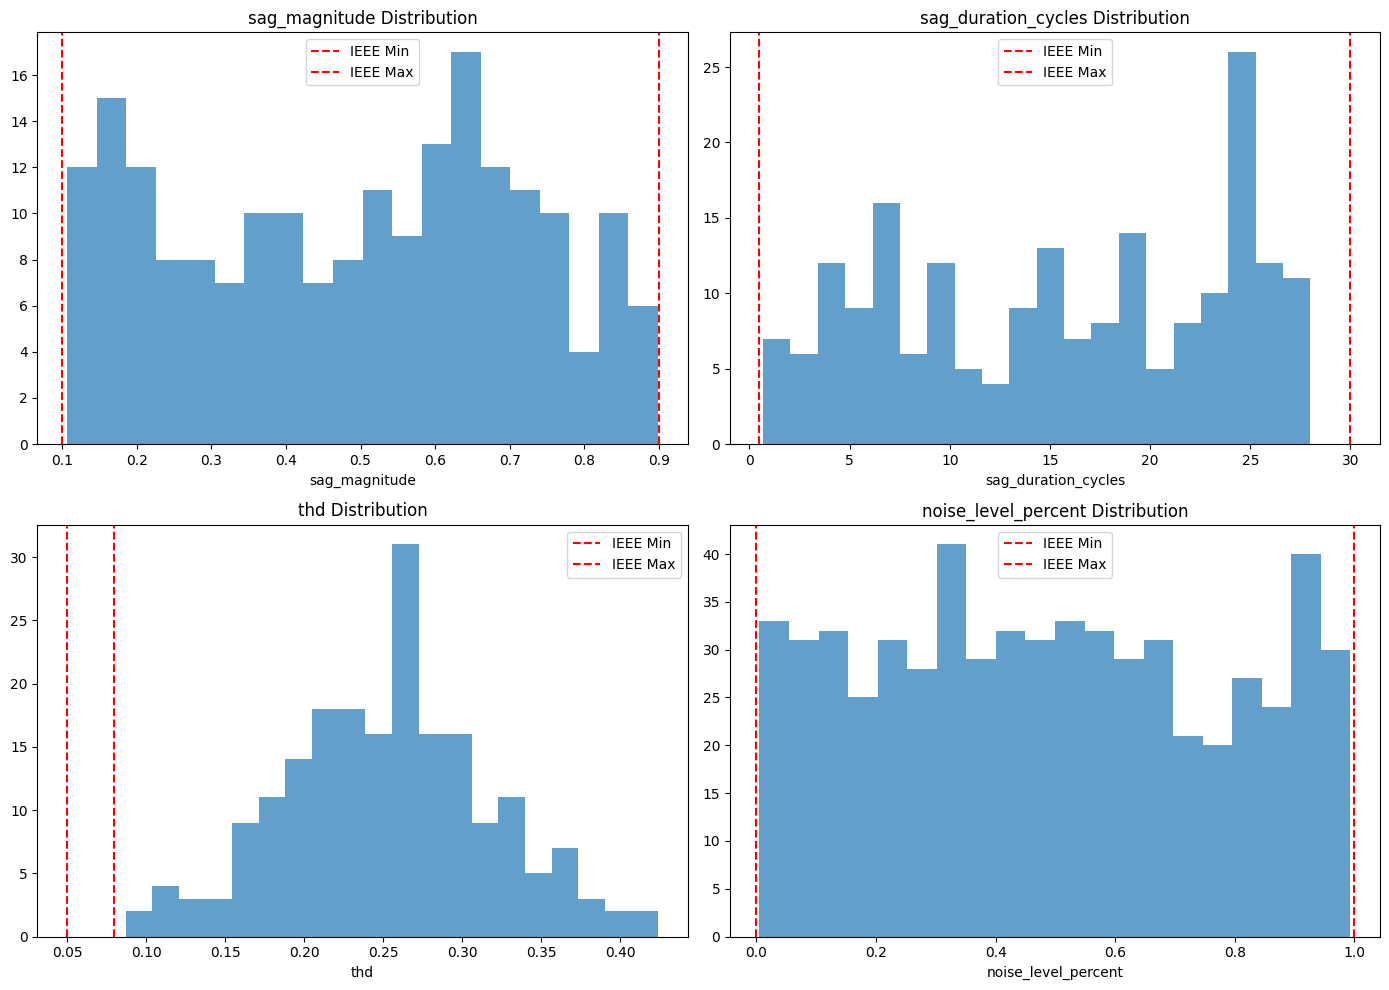

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/12 Harmonics with Sag (M1)/harmonics_with_sag_signals_distributions.png


In [52]:
# @title 12.d. Class 12 - Harmonics with Sag (M1) Statistics
def analyze_harmonics_with_sag_stats(hdf5_path):
    """Perform statistical analysis focusing on key disturbance parameters"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection - only essential parameters
    param_data = {
        'sag_magnitude': [],
        'sag_duration_cycles': [],
        'thd': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get sag parameters
                sag_params = {}
                sag_group_name = f"{signal_name}_sag_params"
                if sag_group_name in params_group:
                    sag_group = params_group[sag_group_name]
                    sag_params = dict(sag_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values for key parameters
                param_data['sag_magnitude'].append(sag_params.get('sag_magnitude', np.nan))
                param_data['sag_duration_cycles'].append(sag_params.get('sag_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'sag_magnitude': (0.1, 0.9),
        'sag_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(10, 8))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_harmonics_with_sag_stats(hdf5_path)  # Analyze the saved signals

In [53]:
# @title 13.a. Class 13 - Harmonics with Swell (M2) Generation

class HarmonicsWithSwellGenerator(PQDBaseGenerator):
    """
    Generates signals combining harmonics and swell disturbances.
    Mathematical model: V(t) = [1 + β·(u(t-t1) - u(t-t2))] × [A0 + Σ A_n·sin(2π·n·f·t + φ_n)]
    Where:
        β = Swell magnitude (0.1-0.8 pu)
        t1, t2 = Swell start/end times
        A_n = Harmonic amplitude (THD 5-8%)
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Swell'

    def generate(self):
        """Generate harmonics with swell signal"""
        # Generate base signal (clean sine wave)
        base_signal = self.generate_base_sine()

        # Generate harmonics signal with randomized amplitudes
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        # Generate swell parameters and create swell envelope
        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        swell_signal, swell_params = swell_gen.generate()

        # Create swell envelope (1 + swell_magnitude) during swell period
        t1 = swell_params['swell_start_time']
        t2 = swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = 1 + swell_params['swell_magnitude']

        # Combine disturbances (apply swell envelope to harmonics signal)
        combined_signal = swell_envelope * harmonics_signal

        # Apply peak limit to prevent excessive amplitudes
        peak = np.max(np.abs(combined_signal))
        if peak > 2.2:  # Cap at 2.2 p.u. to allow for swell + harmonics
            combined_signal = (combined_signal / peak) * 2.2

        # Add noise to the combined signal
        final_signal = self._add_noise(combined_signal)

        # Merge parameters for output
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'combined_type': 'Multiplicative (Swell × Harmonics)',
            't_signal': self.t_signal
        })

        return final_signal, self.params

# Execute the generator and plot the result
gen = HarmonicsWithSwellGenerator()
signal, params = gen.generate()

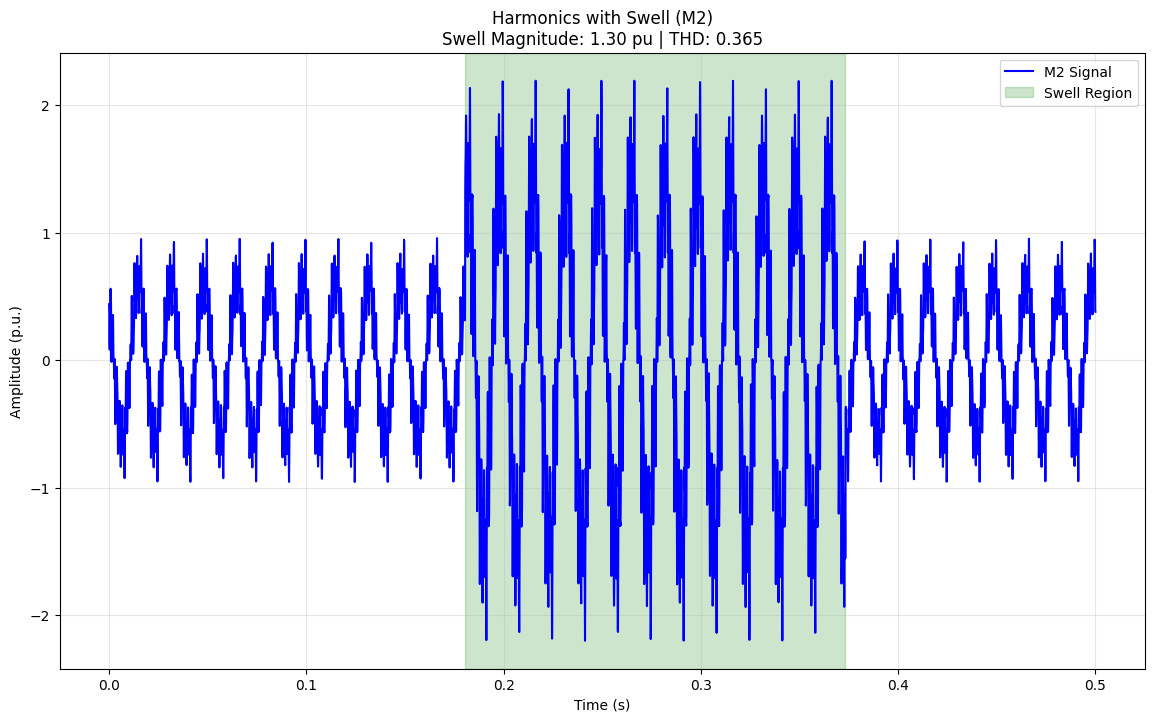

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Swell
Base Amplitude (p.u.): 0.9854
Base Frequency (Hz): 59.9919
Swell Magnitude (p.u.): 1.3032
Swell Duration (cycles): 11.57
THD: 0.3649
Noise Level (%): 0.69


In [159]:
# @title 13.b. Class 13 - Harmonics with Swell (M2) Plotting
def plot_harmonics_with_swell(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M2 Signal')
    swell_params = params['swell_params']
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Swell (M2)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Swell Duration (cycles): {swell_params.get('swell_duration_cycles', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSwellGenerator()
signal, params = gen.generate()
plot_harmonics_with_swell(signal, params)

In [55]:
# @title 13.c.Class 13 - Saving Harmonics with Swell (M2) Signals

def save_harmonics_with_swell_signals(num_signals=200):
    """Generate and save harmonics with swell signals"""
    CLASS_NAME = 'Harmonics with Swell (M2)'
    CLASS_LABEL = 13
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_swell_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSwellGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_harmonics_with_swell_signals(num_signals=200)  # Save 200 signals

Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)/harmonics_with_swell_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)/harmonics_with_swell_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)/harmonics_with_swell_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
swell_magnitude: 200 valid values
swell_duration_cycles: 200 valid values
thd: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)/harmonics_with_swell_signals_stats.json


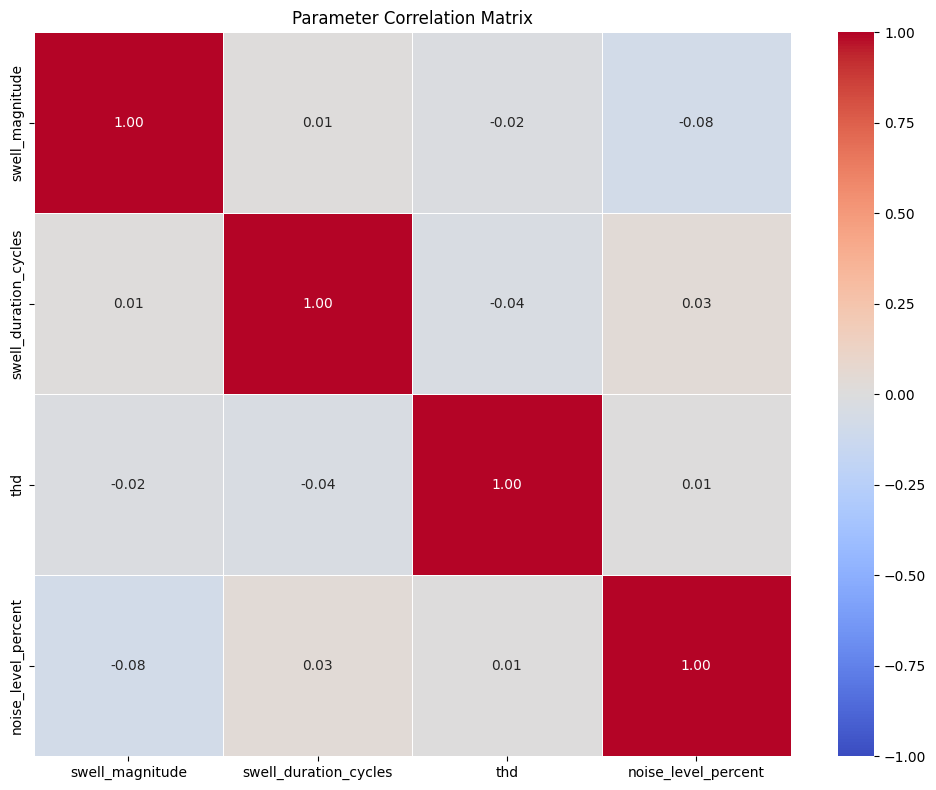

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)/harmonics_with_swell_signals_correlation.png


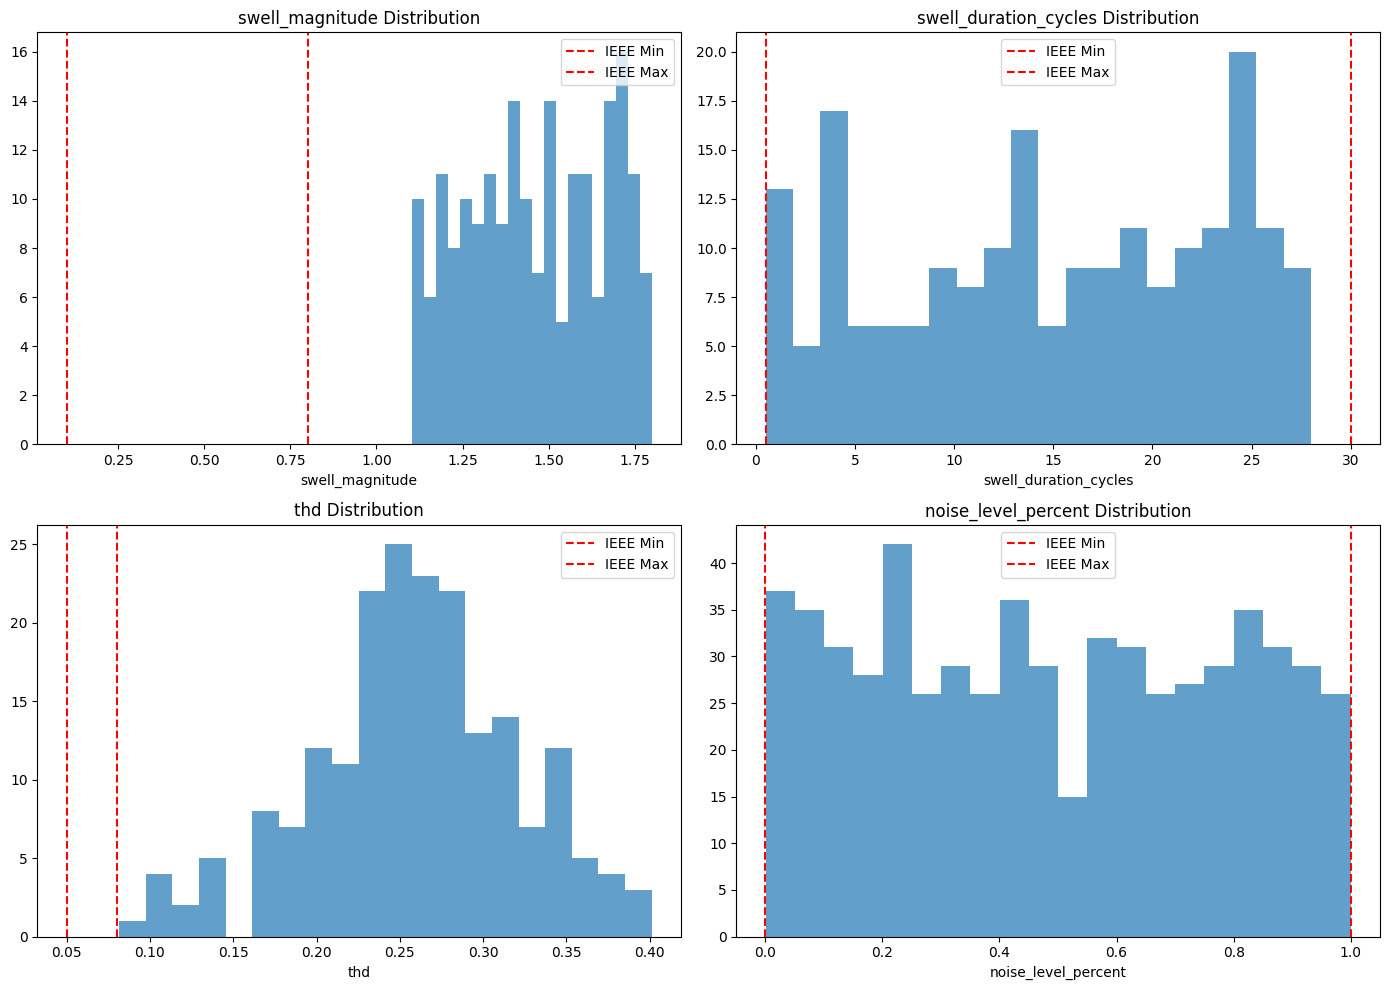

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/13 Harmonics with Swell (M2)/harmonics_with_swell_signals_distributions.png


In [56]:
# @title 13.d. Class 13 - Harmonics with Swell (M2) Statistics

def analyze_harmonics_with_swell_stats(hdf5_path):
    """Perform statistical analysis for M2 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'swell_magnitude': [],
        'swell_duration_cycles': [],
        'thd': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get swell parameters
                swell_params = {}
                swell_group_name = f"{signal_name}_swell_params"
                if swell_group_name in params_group:
                    swell_group = params_group[swell_group_name]
                    swell_params = dict(swell_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['swell_magnitude'].append(swell_params.get('swell_magnitude', np.nan))
                param_data['swell_duration_cycles'].append(swell_params.get('swell_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'swell_magnitude': (0.1, 0.8),
        'swell_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation #Check IEEE 519 Standard
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(10, 8))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_harmonics_with_swell_stats(hdf5_path)

In [77]:
# @title 14.a. Class 14 - Flicker with Sag (M3) Generation

class FlickerWithSagGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Flicker with Sag'

    def generate(self):
        base_signal = self.generate_base_sine()
        flicker_depth = random.uniform(0.001, 0.07)
        flicker_frequency = random.uniform(0.5, 25)

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        flicker_envelope = 1 + flicker_depth * np.sin(2 * np.pi * flicker_frequency * self.time)
        combined_signal = sag_envelope * flicker_envelope * base_signal

        final_signal = self._add_noise(combined_signal)
        self.params.update({'sag_params': sag_params, 'flicker_depth': flicker_depth, 'flicker_frequency': flicker_frequency})

        return final_signal, self.params

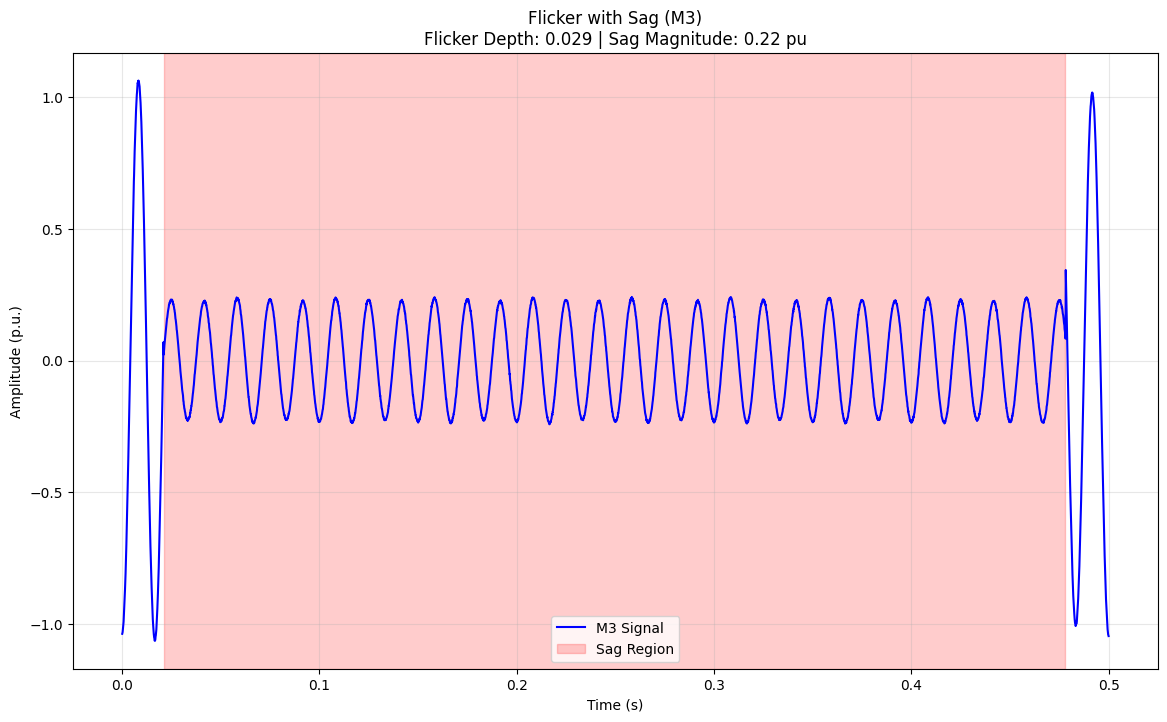

--- Generated Signal Parameters ---
Disturbance Type: Flicker with Sag
Base Amplitude (p.u.): 1.0341
Base Frequency (Hz): 59.9915
Sag Magnitude (p.u.): 0.2231
Flicker Depth: 0.0288
Flicker Frequency (Hz): 20.10
Noise Level (%): 0.60


In [160]:
# @title 14.b. Class 14 - Flicker with Sag (M3) Plotting
def plot_flicker_with_sag(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M3 Signal')
    sag_params = params['sag_params']
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    plt.title(f"Flicker with Sag (M3)\nFlicker Depth: {params.get('flicker_depth', 0):.3f} | Sag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Flicker Depth: {params.get('flicker_depth', 0):.4f}")
    print(f"Flicker Frequency (Hz): {params.get('flicker_frequency', 0):.2f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = FlickerWithSagGenerator()
signal, params = gen.generate()
plot_flicker_with_sag(signal, params)

In [59]:
# @title 14.c. Class 14 - Saving Flicker with Sag (M3) Signals

def save_flicker_with_sag_signals(num_signals=200):
    """Generate and save flicker with sag signals"""
    CLASS_NAME = 'Flicker with Sag (M3)'
    CLASS_LABEL = 14
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'flicker_with_sag_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = FlickerWithSagGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_flicker_with_sag_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)/flicker_with_sag_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)/flicker_with_sag_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)/flicker_with_sag_signals.h5
Found 400 signals in the file
Processed 1/400 signals
Processed 51/400 signals
Processed 101/400 signals
Processed 151/400 signals
Processed 201/400 signals
Processed 251/400 signals
Processed 301/400 signals
Processed 351/400 signals
DataFrame created with parameter data
sag_magnitude: 200 valid values
flicker_depth: 200 valid values
flicker_frequency: 200 valid values
noise_level_percent: 400 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)/flicker_with_sag_signals_stats.json


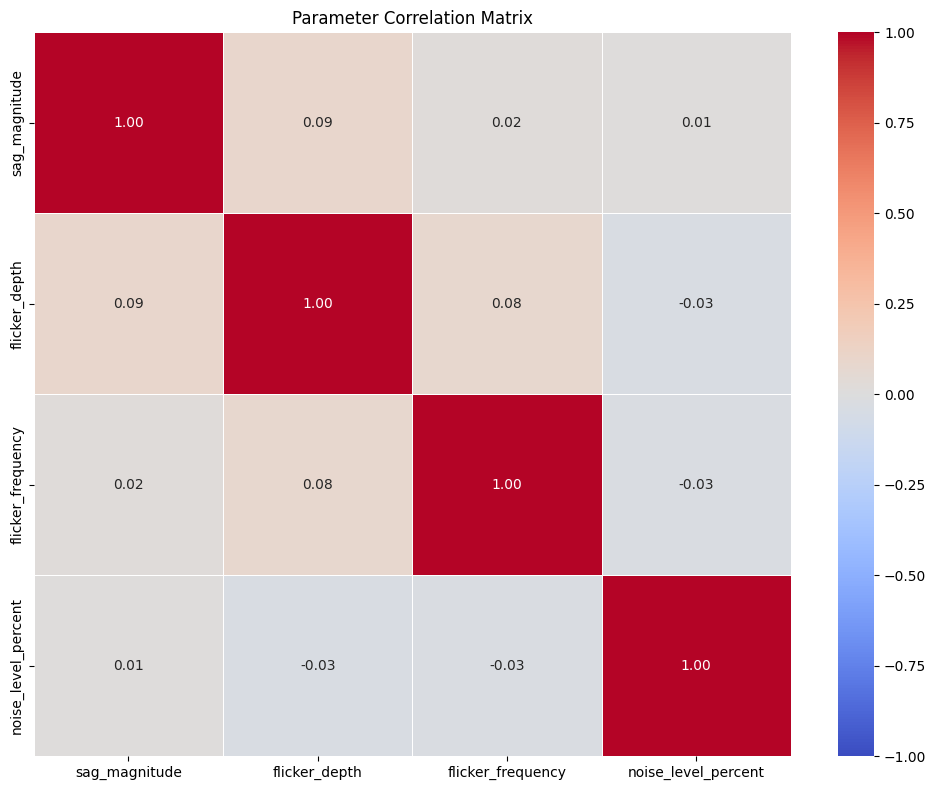

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)/flicker_with_sag_signals_correlation.png


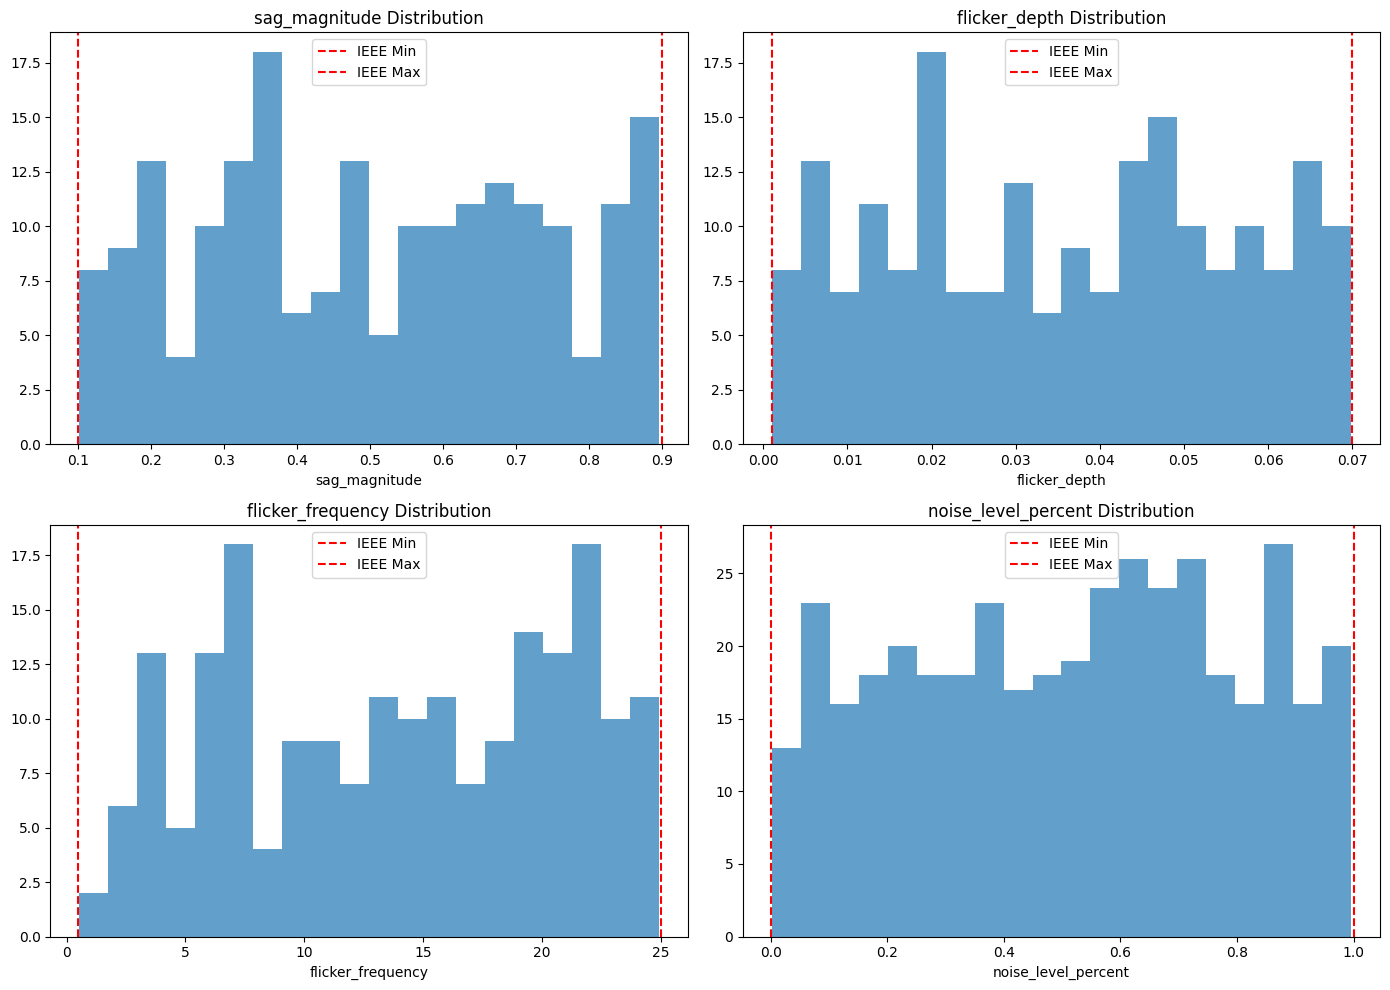

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/14 Flicker with Sag (M3)/flicker_with_sag_signals_distributions.png


In [60]:
# @title 14.d. Class 14 - Flicker with Sag (M3) Statistics

def analyze_flicker_with_sag_stats(hdf5_path):
    """Perform statistical analysis for M3 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'sag_magnitude': [],
        'flicker_depth': [],
        'flicker_frequency': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get sag parameters
                sag_params = {}
                sag_group_name = f"{signal_name}_sag_params"
                if sag_group_name in params_group:
                    sag_group = params_group[sag_group_name]
                    sag_params = dict(sag_group.attrs)

                # Collect values
                param_data['sag_magnitude'].append(sag_params.get('sag_magnitude', np.nan))
                param_data['flicker_depth'].append(param_dset.attrs.get('flicker_depth', np.nan))
                param_data['flicker_frequency'].append(param_dset.attrs.get('flicker_frequency', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'sag_magnitude': (0.1, 0.9),
        'flicker_depth': (0.001, 0.07),
        'flicker_frequency': (0.5, 25),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(10, 8))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_flicker_with_sag_stats(hdf5_path)


In [61]:
# @title 15.a. Class 15 - Flicker with Swell (M4) Generation

class FlickerWithSwellGenerator(PQDBaseGenerator):
    """
    Generates signals combining flicker and swell disturbances.
    Mathematical model:
        V(t) = [1 + β·(u(t-t1) - u(t-t2))] × [1 + m·sin(2π·f_flicker·t)] × A0·sin(2π·f·t)
    Where:
        β = Swell magnitude (0.1-0.8 pu)
        m = Flicker modulation depth (0.001-0.07)
        f_flicker = Flicker frequency (0.5-25 Hz)
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Flicker with Swell'

    def generate(self):
        """Generate flicker with swell signal"""
        # Generate base signal (clean sine wave)
        base_signal = self.generate_base_sine()

        # Generate flicker parameters
        flicker_depth = random.uniform(0.001, 0.07)  # Flicker modulation depth
        flicker_frequency = random.uniform(0.5, 25)  # Flicker frequency
        self.params['flicker_depth'] = flicker_depth
        self.params['flicker_frequency'] = flicker_frequency

        # Generate swell parameters
        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        swell_signal, swell_params = swell_gen.generate()

        # Create swell envelope (1 + β) during swell period
        t1 = swell_params['swell_start_time']
        t2 = swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = 1 + swell_params['swell_magnitude']

        # Create flicker envelope (1 + m·sin(2π·f_flicker·t))
        flicker_envelope = 1 + flicker_depth * np.sin(2 * np.pi * flicker_frequency * self.time)

        # Combine disturbances: apply flicker and swell envelopes to base signal
        combined_signal = swell_envelope * flicker_envelope * base_signal

        # Apply peak limit to prevent excessive amplitudes
        peak = np.max(np.abs(combined_signal))
        if peak > 1.1:  # Cap at 1.1 p.u. to allow for flicker + swell
            combined_signal = (combined_signal / peak) * 1.1

        # Add noise to the combined signal
        final_signal = self._add_noise(combined_signal)

        # Merge parameters for output
        self.params.update({
            'swell_params': swell_params,
            'combined_type': 'Multiplicative (Flicker × Swell)',
            't_signal': self.t_signal
        })

        return final_signal, self.params

# Execute the generator and plot the result
gen = FlickerWithSwellGenerator()
signal, params = gen.generate()


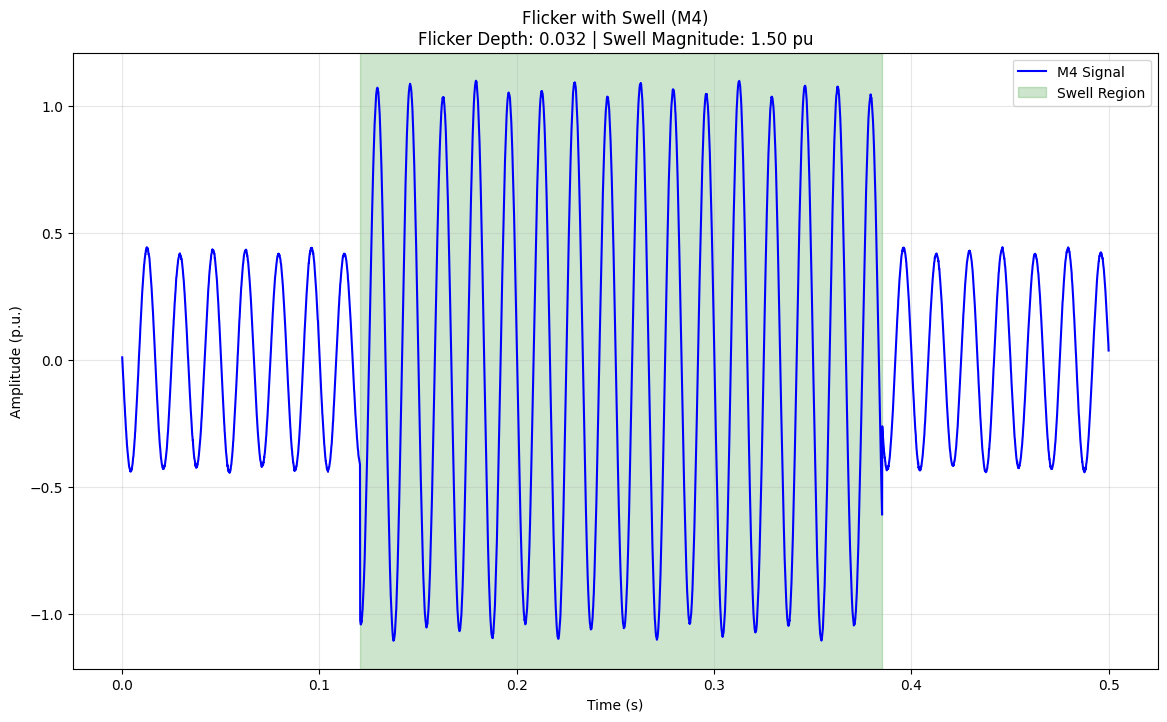

--- Generated Signal Parameters ---
Disturbance Type: Flicker with Swell
Base Amplitude (p.u.): 0.9536
Base Frequency (Hz): 59.9909
Swell Magnitude (p.u.): 1.4950
Flicker Depth: 0.0315
Flicker Frequency (Hz): 23.32
Noise Level (%): 0.75


In [161]:
# @title 15.b. Class 15 - Flicker with Swell (M4) Plotting
def plot_flicker_with_swell(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M4 Signal')
    swell_params = params['swell_params']
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    plt.title(f"Flicker with Swell (M4)\nFlicker Depth: {params.get('flicker_depth', 0):.3f} | Swell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Flicker Depth: {params.get('flicker_depth', 0):.4f}")
    print(f"Flicker Frequency (Hz): {params.get('flicker_frequency', 0):.2f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = FlickerWithSwellGenerator()
signal, params = gen.generate()
plot_flicker_with_swell(signal, params)

In [63]:
# @title 15.c. Class 15 - Saving Flicker with Swell (M4) Signals

def save_flicker_with_swell_signals(num_signals=200):
    """Generate and save flicker with swell signals"""
    CLASS_NAME = 'Flicker with Swell (M4)'
    CLASS_LABEL = 15
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'flicker_with_swell_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = FlickerWithSwellGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_flicker_with_swell_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)/flicker_with_swell_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)/flicker_with_swell_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)/flicker_with_swell_signals.h5
Found 400 signals in the file
Processed 1/400 signals
Processed 51/400 signals
Processed 101/400 signals
Processed 151/400 signals
Processed 201/400 signals
Processed 251/400 signals
Processed 301/400 signals
Processed 351/400 signals
DataFrame created with parameter data
swell_magnitude: 200 valid values
flicker_depth: 200 valid values
flicker_frequency: 200 valid values
noise_level_percent: 400 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)/flicker_with_swell_signals_stats.json


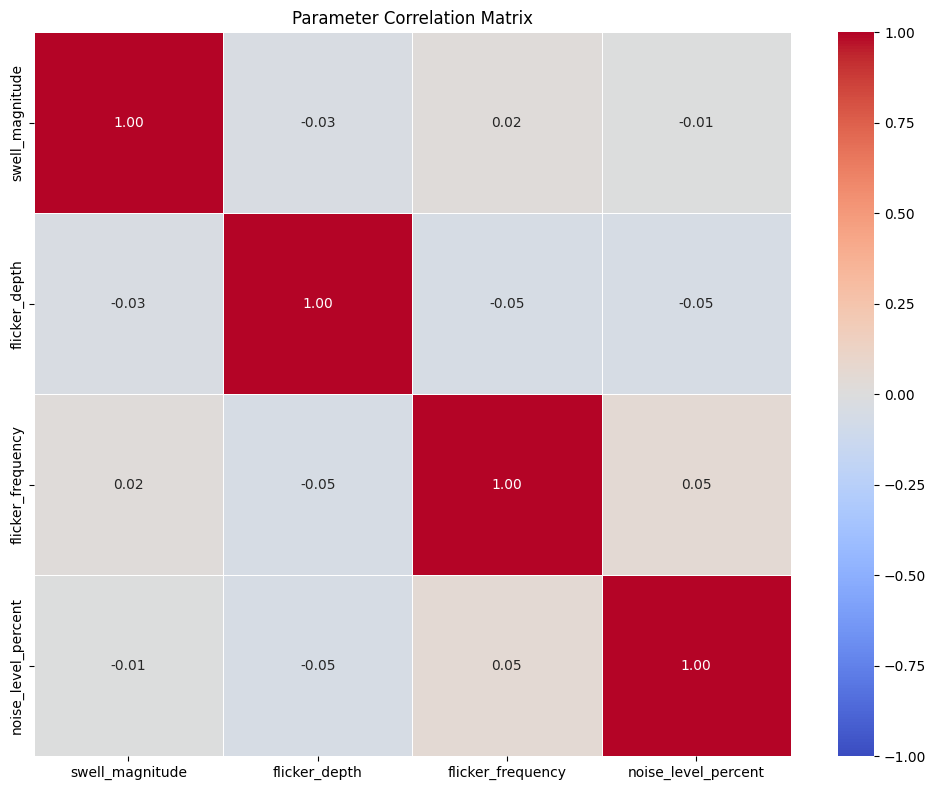

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)/flicker_with_swell_signals_correlation.png


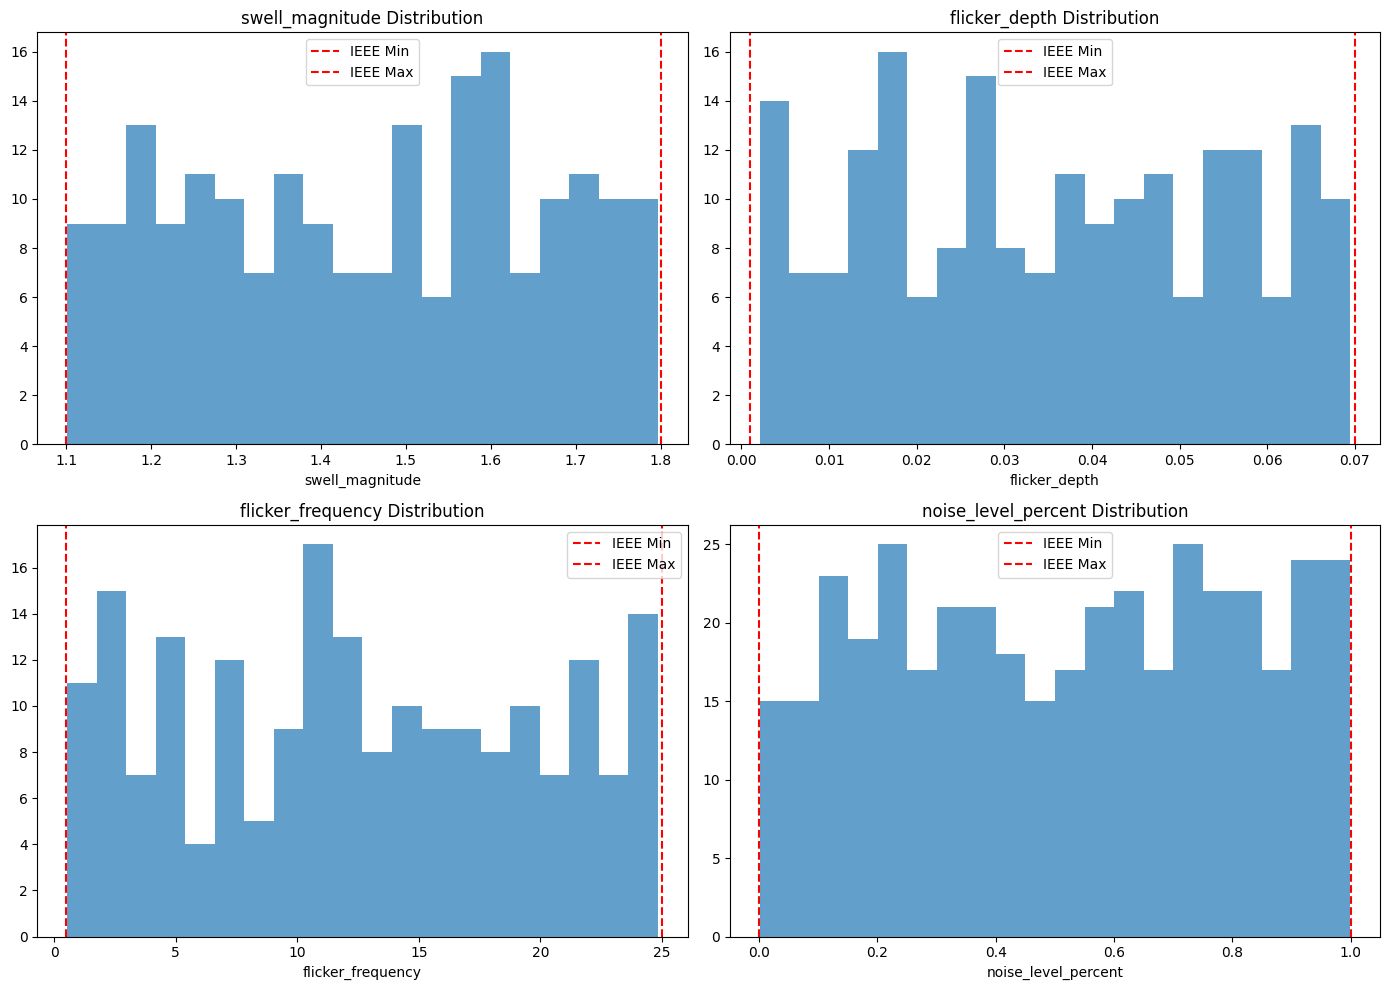

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/15 Flicker with Swell (M4)/flicker_with_swell_signals_distributions.png


In [64]:
# @title 15.d. Class 15 - Flicker with Swell (M4) Statistics

def analyze_flicker_with_swell_stats(hdf5_path):
    """Perform statistical analysis for M4 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'swell_magnitude': [],
        'flicker_depth': [],
        'flicker_frequency': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get swell parameters
                swell_params = {}
                swell_group_name = f"{signal_name}_swell_params"
                if swell_group_name in params_group:
                    swell_group = params_group[swell_group_name]
                    swell_params = dict(swell_group.attrs)

                # Collect values
                param_data['swell_magnitude'].append(swell_params.get('swell_magnitude', np.nan))
                param_data['flicker_depth'].append(param_dset.attrs.get('flicker_depth', np.nan))
                param_data['flicker_frequency'].append(param_dset.attrs.get('flicker_frequency', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'swell_magnitude': (1.1, 1.8),
        'flicker_depth': (0.001, 0.07),
        'flicker_frequency': (0.5, 25),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(10, 8))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_flicker_with_swell_stats(hdf5_path)


In [173]:
# @title 16.a. Class 16 - Sag with Oscillatory Transient (M5) Generation

class SagWithOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Sag with Oscillatory Transient'

    def generate(self):
        base_signal = self.generate_base_sine()
        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        sag_affected_signal = sag_envelope * base_signal

        transient_amp = random.uniform(0.1, 1.0)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        final_signal = self._add_noise(sag_affected_signal + transient_component)
        self.params.update({
            'sag_params': sag_params,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'transient_start_time': transient_start,
            'decay_constant': decay_constant
        })

        return final_signal, self.params

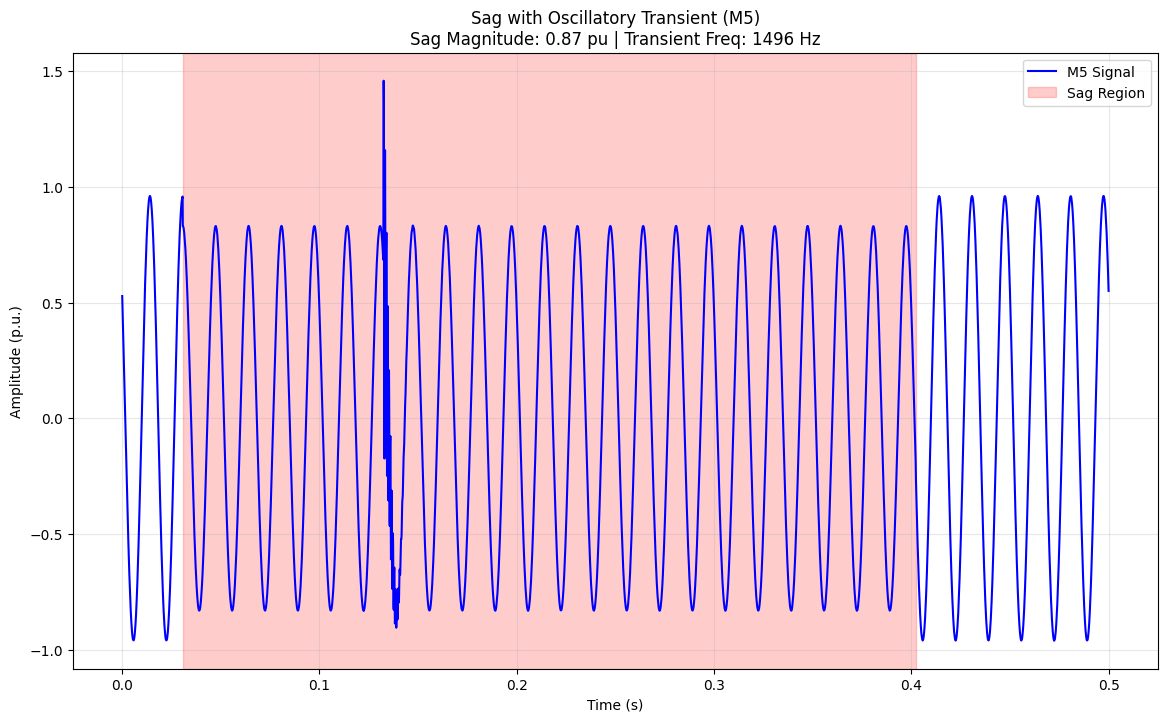

--- Generated Signal Parameters ---
Disturbance Type: Sag with Oscillatory Transient
Base Amplitude (p.u.): 0.9603
Base Frequency (Hz): 60.0023
Sag Magnitude (p.u.): 0.8653
Transient Freq (Hz): 1496.36
Transient Amp (p.u.): 0.9226
Noise Level (%): 0.18


In [162]:
# @title 16.b. Class 16 - Sag with Oscillatory Transient (M5) Plotting
def plot_sag_with_osc_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M5 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    plt.title(f"Sag with Oscillatory Transient (M5)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | Transient Freq: {params.get('transient_frequency', 0):.0f} Hz")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"Transient Amp (p.u.): {params.get('transient_amplitude', 0):.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SagWithOscillatoryTransientGenerator()
signal, params = gen.generate()
plot_sag_with_osc_transient(signal, params)

In [67]:
# @title 16.c. Class 16 - Saving Sag with Oscillatory Transient (M5) Signals

def save_sag_with_osc_transient_signals(num_signals=200):
    """Generate and save sag with oscillatory transient signals"""
    CLASS_NAME = 'Sag with Oscillatory Transient (M5)'
    CLASS_LABEL = 16
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'sag_with_osc_transient_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SagWithOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_sag_with_osc_transient_signals(num_signals=200)  # Save 200 signals

Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/16 Sag with Oscillatory Transient (M5)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/16 Sag with Oscillatory Transient (M5)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/16 Sag with Oscillatory Transient (M5)/sag_with_osc_transient_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/16 Sag with Oscillatory Transient (M5)/sag_with_osc_transient_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/31 Swell with Harmonics, Flicker, and Oscillatory Transient (M20)/swell_with_harmonics_flicker_and_transient_signals.h5


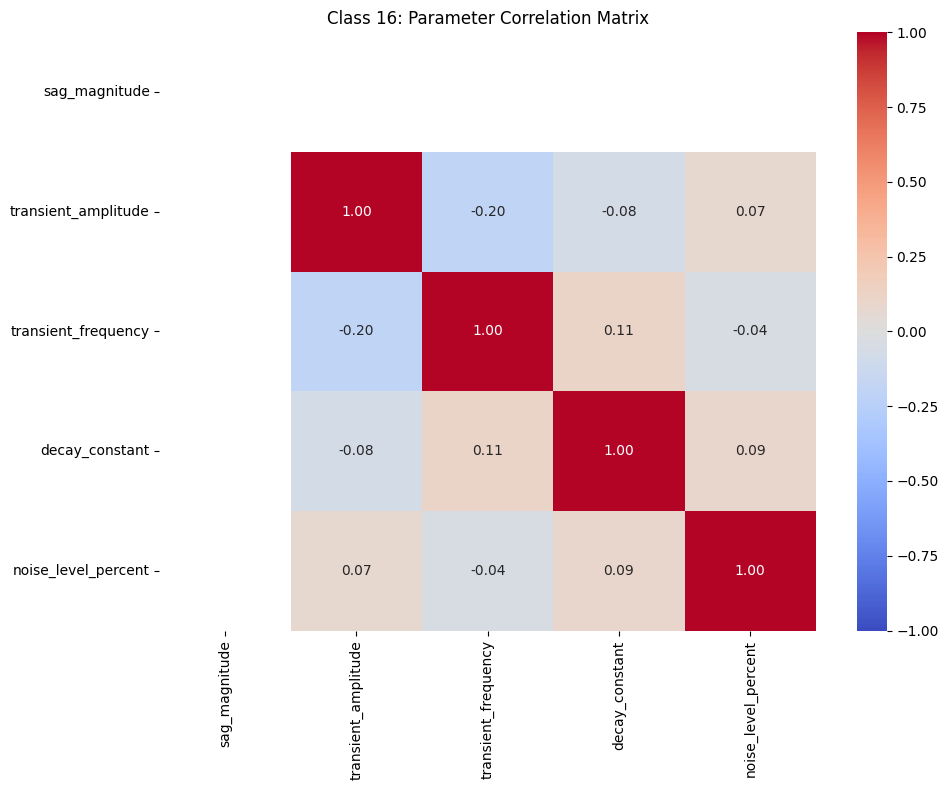

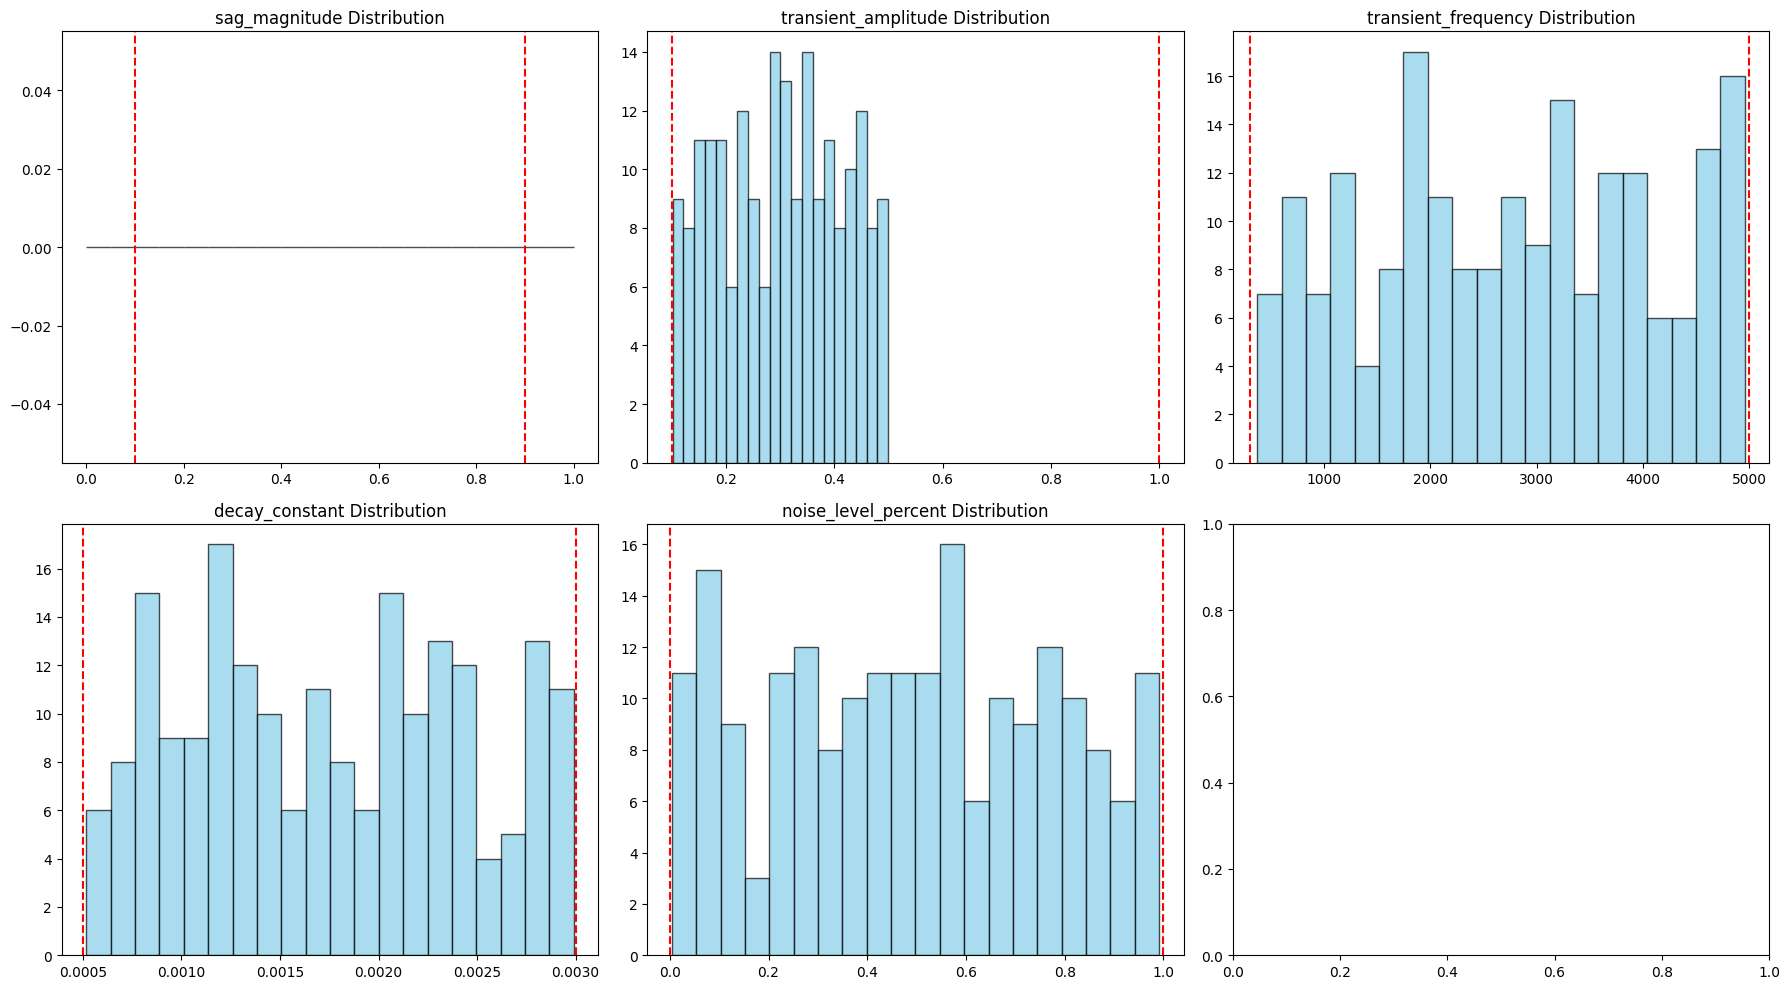

In [176]:
# @title 16.d. Class 16 - Sag with Oscillatory Transient (M5) Statistics

def analyze_sag_with_osc_transient_stats(hdf5_path):
    """Perform statistical analysis for M5 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    param_data = {
        'sag_magnitude': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': [],
        'noise_level_percent': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            signal_count = len([k for k in params_group.keys() if k.startswith('signal_')])

            for i in range(1, signal_count + 1):
                signal_name = f'signal_{i:04d}'
                if signal_name not in params_group: continue

                param_attrs = dict(params_group[signal_name].attrs)
                sag_group_name = f"{signal_name}_sag_params"
                sag_magnitude = params_group[sag_group_name].attrs.get('sag_magnitude', np.nan) if sag_group_name in params_group else np.nan

                param_data['sag_magnitude'].append(sag_magnitude)
                param_data['transient_amplitude'].append(param_attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(param_attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(param_attrs.get('decay_constant', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    stats = {}
    ieee_ranges = {
        'sag_magnitude': (0.1, 0.9),
        'transient_amplitude': (0.1, 1.0),
        'transient_frequency': (300, 5000),
        'decay_constant': (0.0005, 0.003),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        if len(valid_vals) == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1]
        }

    with open(stats_path, 'w') as f_out:
        json.dump(stats, f_out, indent=4)

    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
    plt.title("Class 16: Parameter Correlation Matrix")
    plt.tight_layout()
    plt.savefig(heatmap_path)
    plt.show()

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    for i, p in enumerate(param_data.keys()):
        ax = axs.flat[i]
        ax.hist(df[p].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        ax.set_title(f"{p} Distribution")
        if p in ieee_ranges:
            ax.axvline(ieee_ranges[p][0], color='r', linestyle='--')
            ax.axvline(ieee_ranges[p][1], color='r', linestyle='--')

    plt.tight_layout()
    plt.savefig(dist_path)
    plt.show()
    return stats

# Run the updated analysis
stats_m5 = analyze_sag_with_osc_transient_stats(hdf5_path)

In [183]:
# @title 17.a. Class 17 - Swell with Oscillatory Transient (M6) Generation

class SwellWithOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Swell with Oscillatory Transient'

    def generate(self):
        base_signal = self.generate_base_sine()
        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        _, swell_params = swell_gen.generate()

        t1, t2 = swell_params['swell_start_time'], swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = swell_params['swell_magnitude']

        swell_affected_signal = swell_envelope * base_signal

        transient_amp = random.uniform(0.1, 1.0)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        final_signal = self._add_noise(swell_affected_signal + transient_component)
        self.params.update({
            'swell_params': swell_params,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'transient_start_time': transient_start,
            'decay_constant': decay_constant
        })

        return final_signal, self.params

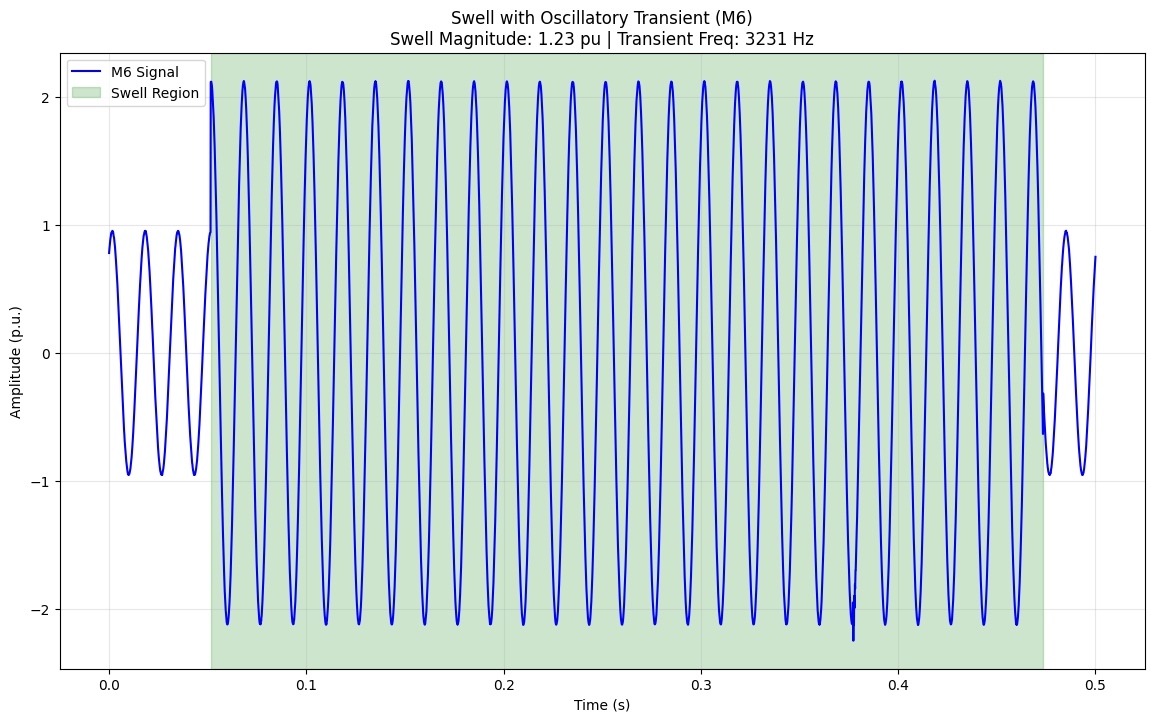

--- Generated Signal Parameters ---
Disturbance Type: Swell with Oscillatory Transient
Base Amplitude (p.u.): 0.9509
Base Frequency (Hz): 59.9933
Swell Magnitude (p.u.): 1.2292
Transient Freq (Hz): 3230.75
Transient Amp (p.u.): 0.2505
Noise Level (%): 0.83


In [163]:
# @title 17.b. Class 17 - Swell with Oscillatory Transient (M6) Plotting
def plot_swell_with_osc_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M6 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    plt.title(f"Swell with Oscillatory Transient (M6)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | Transient Freq: {params.get('transient_frequency', 0):.0f} Hz")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"Transient Amp (p.u.): {params.get('transient_amplitude', 0):.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SwellWithOscillatoryTransientGenerator()
signal, params = gen.generate()
plot_swell_with_osc_transient(signal, params)

In [71]:
# @title 17.c. Class 17 - Saving Swell with Oscillatory Transient (M6) Signals

def save_swell_with_osc_transient_signals(num_signals=200):
    """Generate and save swell with oscillatory transient signals"""
    CLASS_NAME = 'Swell with Oscillatory Transient (M6)'
    CLASS_LABEL = 17
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'swell_with_osc_transient_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SwellWithOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path  # THIS WAS MISSING - CRITICAL FIX

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_swell_with_osc_transient_signals(num_signals=200)  # Save 200 signals

Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/17 Swell with Oscillatory Transient (M6)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/17 Swell with Oscillatory Transient (M6)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/17 Swell with Oscillatory Transient (M6)/swell_with_osc_transient_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/17 Swell with Oscillatory Transient (M6)/swell_with_osc_transient_signals.h5


In [184]:
# @title 17.d. Class 17 - Swell with Oscillatory Transient (M6) Statistics

def analyze_swell_with_osc_transient_stats(hdf5_path):
    """Perform statistical analysis for M6 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'swell_magnitude': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': [],
        'noise_level_percent': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                param_attrs = dict(params_group[sig_name].attrs)
                param_data['swell_magnitude'].append(params_group[f"{sig_name}_swell_params"].attrs.get('swell_magnitude', np.nan))
                param_data['transient_amplitude'].append(param_attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(param_attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(param_attrs.get('decay_constant', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
    plt.title("Class 17: Parameter Correlation")
    plt.show()
    return df.describe()

In [73]:
# @title 18.a. Class 18 - Sag with Harmonics (M7) Generation

class SagWithHarmonicsGenerator(PQDBaseGenerator):
    """
    Generates signals combining sag and harmonics disturbances.
    Mathematical model:
        V(t) = magnitude * [A0 + Σ A_n·sin(2π·n·f·t + φ_n)]
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Sag with Harmonics'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        # FIXED: Use magnitude directly
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        combined_signal = sag_envelope * harmonics_signal

        peak = np.max(np.abs(combined_signal))
        if peak > 1.1: combined_signal = (combined_signal / peak) * 1.1

        final_signal = self._add_noise(combined_signal)
        self.params.update({'sag_params': sag_params, 'harmonics_params': harmonics_params})

        return final_signal, self.params

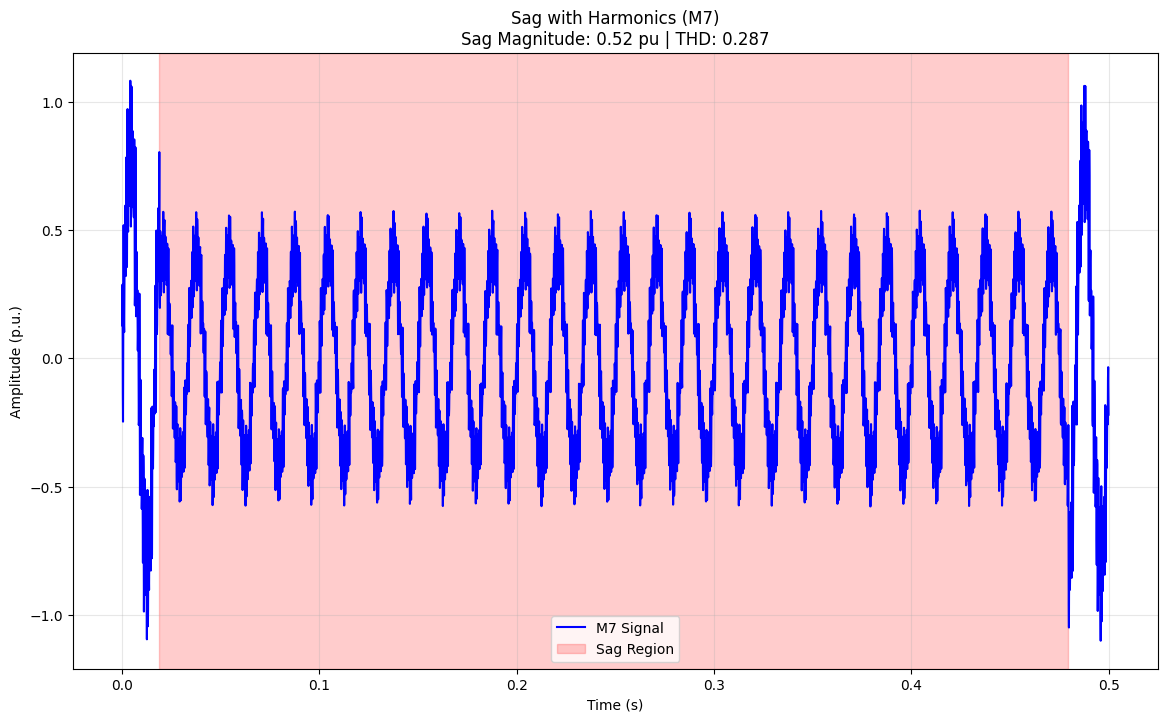

--- Generated Signal Parameters ---
Disturbance Type: Sag with Harmonics
Base Amplitude (p.u.): 1.0167
Base Frequency (Hz): 60.0015
Sag Magnitude (p.u.): 0.5206
THD: 0.2872
Noise Level (%): 0.44


In [164]:
# @title 18.b. Class 18 - Sag with Harmonics (M7) Plotting
def plot_sag_with_harmonics(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M7 Signal')
    sag_params = params['sag_params']
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Sag with Harmonics (M7)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SagWithHarmonicsGenerator()
signal, params = gen.generate()
plot_sag_with_harmonics(signal, params)

In [83]:
# @title 18.c. Class 18 - Saving Sag with Harmonics (M7) Signals

def save_sag_with_harmonics_signals(num_signals=200):
    """Generate and save sag with harmonics signals"""
    CLASS_NAME = 'Sag with Harmonics (M7)'
    CLASS_LABEL = 18
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'sag_with_harmonics_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SagWithHarmonicsGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_sag_with_harmonics_signals(num_signals=200)  # Save 200 signals

Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)/sag_with_harmonics_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)/sag_with_harmonics_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)/sag_with_harmonics_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
sag_magnitude: 200 valid values
sag_duration_cycles: 200 valid values
thd: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)/sag_with_harmonics_signals_stats.json


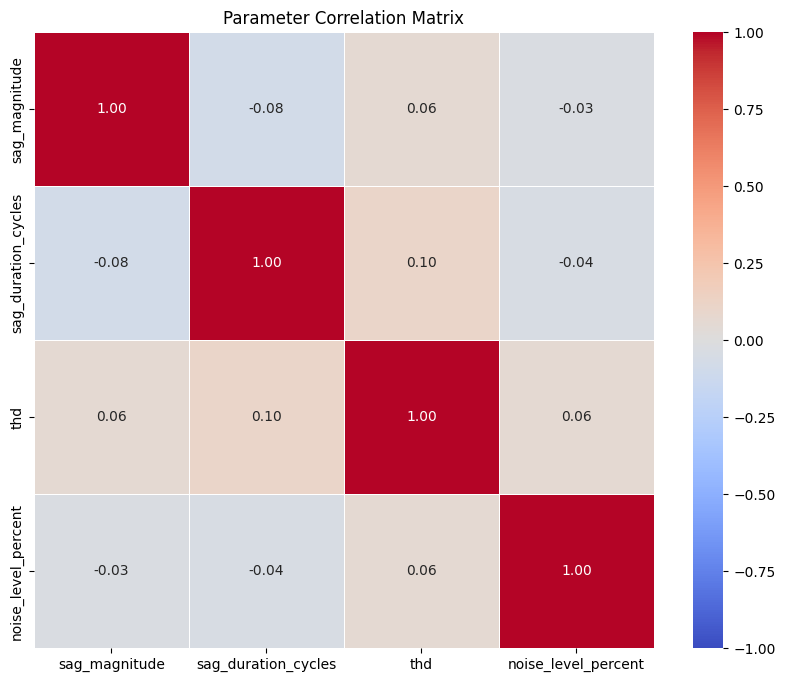

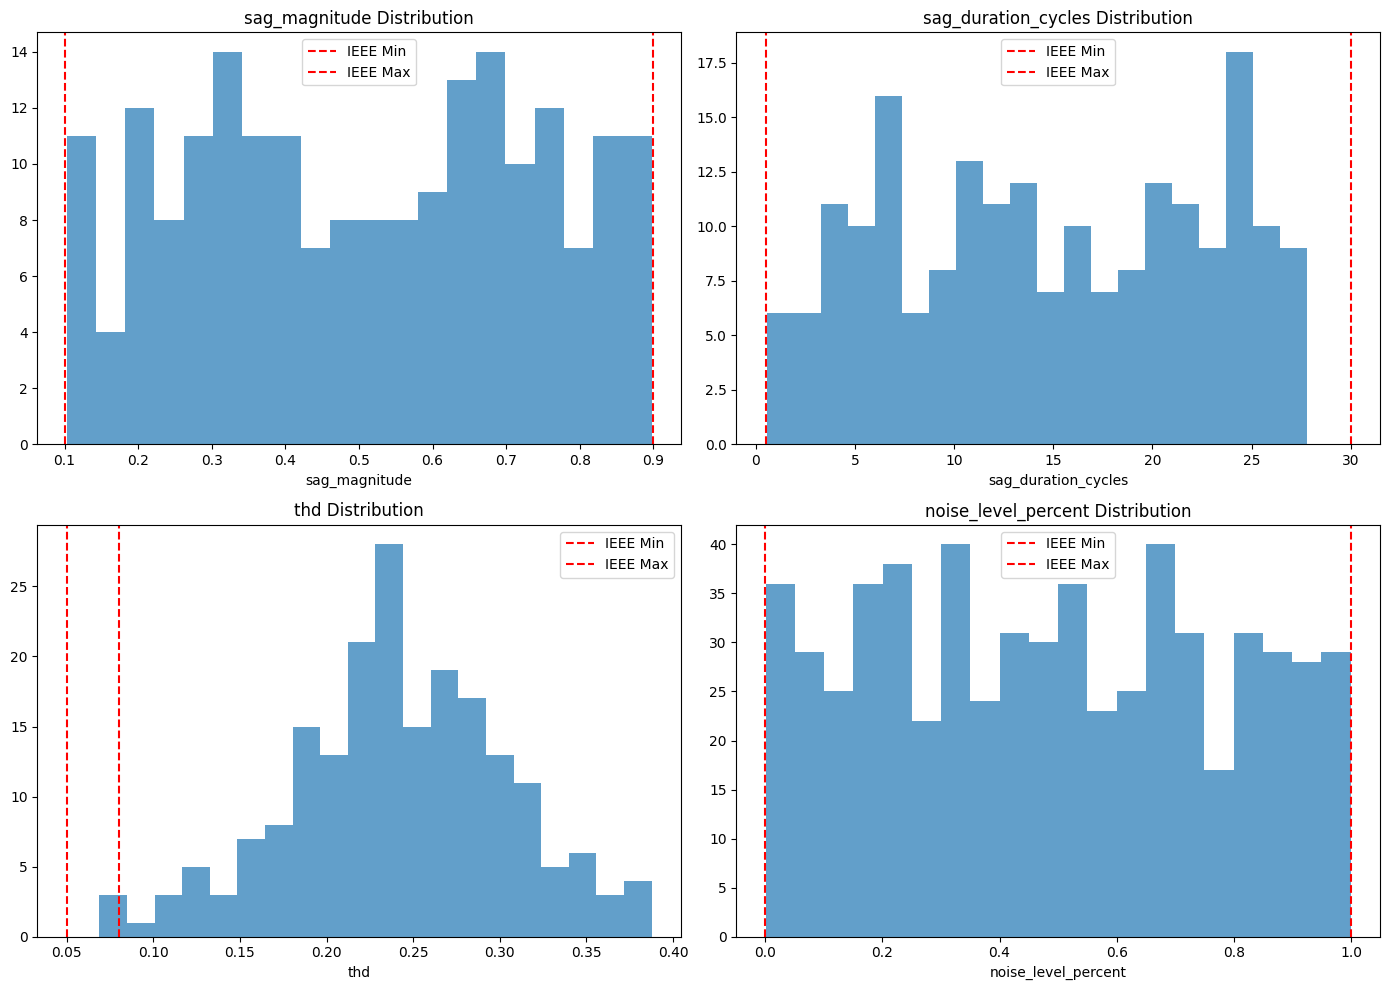

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/18 Sag with Harmonics (M7)/sag_with_harmonics_signals_distributions.png


In [84]:
# @title 18.d. Class 18 - Sag with Harmonics (M7) Statistics

def analyze_sag_with_harmonics_stats(hdf5_path):
    """Perform statistical analysis for M7 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'sag_magnitude': [],
        'sag_duration_cycles': [],
        'thd': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get sag parameters
                sag_params = {}
                sag_group_name = f"{signal_name}_sag_params"
                if sag_group_name in params_group:
                    sag_group = params_group[sag_group_name]
                    sag_params = dict(sag_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['sag_magnitude'].append(sag_params.get('sag_magnitude', np.nan))
                param_data['sag_duration_cycles'].append(sag_params.get('sag_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'sag_magnitude': (0.1, 0.9),
        'sag_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(10, 8))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots:
    try:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_sag_with_harmonics_stats(hdf5_path)

In [85]:
# @title 19.a. Class 19 - Swell with Harmonics (M8) Generation

class SwellWithHarmonicsGenerator(PQDBaseGenerator):
    """
    Generates signals combining swell and harmonics disturbances.
    Mathematical model:
        V(t) = [1 + α·(u(t-t1) - u(t-t2))] × [A0 + Σ A_n·sin(2π·n·f·t + φ_n)]
    Where:
        α = Swell magnitude (0.1-0.9 pu)
        A_n = Harmonic amplitudes (THD 5-8%)
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Swell with Harmonics'

    def generate(self):
        """Generate swell with harmonics signal"""
        # Generate base signal (clean sine wave)
        base_signal = self.generate_base_sine()

        # Generate harmonics signal
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        # Generate swell parameters
        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        swell_signal, swell_params = swell_gen.generate()

        # Create swell envelope
        t1 = swell_params['swell_start_time']
        t2 = swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = 1 + swell_params['swell_magnitude']

        # Combine disturbances: apply swell envelope to harmonics signal
        combined_signal = swell_envelope * harmonics_signal

        # Apply peak limit to prevent excessive amplitudes
        peak = np.max(np.abs(combined_signal))
        if peak > 1.1:  # Cap at 1.1 p.u.
            combined_signal = (combined_signal / peak) * 1.1

        # Add noise
        final_signal = self._add_noise(combined_signal)

        # Merge parameters
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'combined_type': 'Multiplicative (Swell × Harmonics)',
            't_signal': self.t_signal
        })

        return final_signal, self.params

# Execute the generator and plot the result
gen = SwellWithHarmonicsGenerator()
signal, params = gen.generate()


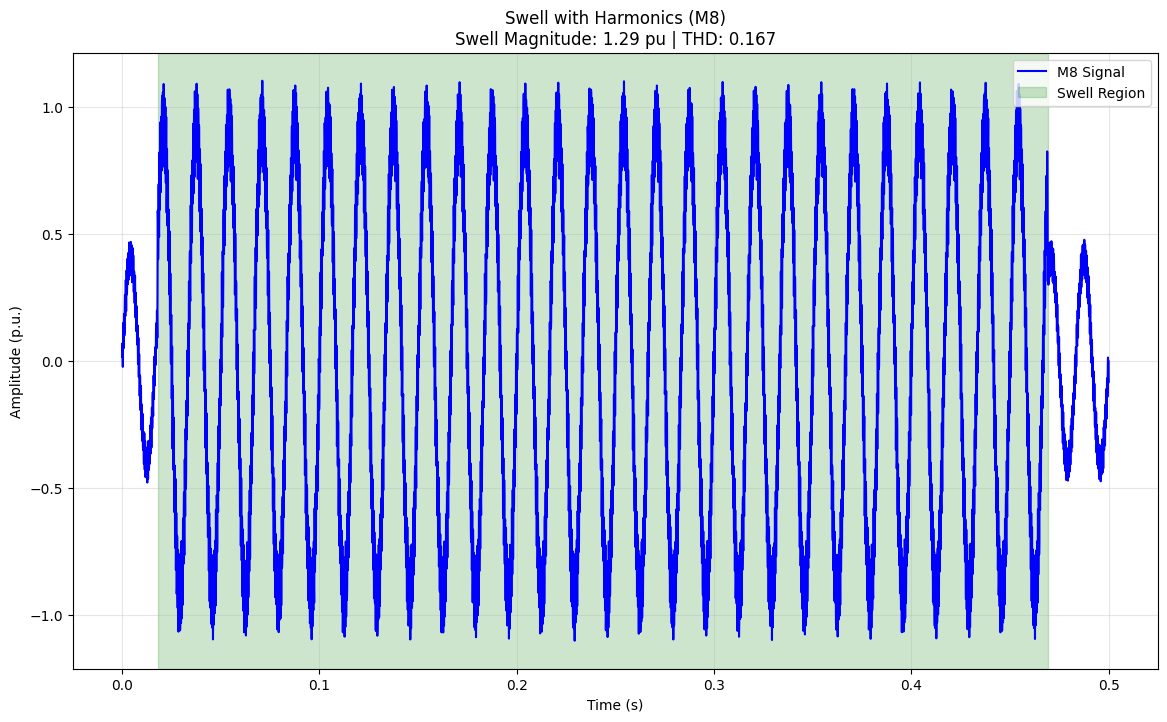

--- Generated Signal Parameters ---
Disturbance Type: Swell with Harmonics
Base Amplitude (p.u.): 1.0486
Base Frequency (Hz): 60.0053
Swell Magnitude (p.u.): 1.2886
THD: 0.1666
Noise Level (%): 0.85


In [165]:
# @title 19.b. Class 19 - Swell with Harmonics (M8) Plotting
def plot_swell_with_harmonics(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M8 Signal')
    swell_params = params['swell_params']
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Swell with Harmonics (M8)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SwellWithHarmonicsGenerator()
signal, params = gen.generate()
plot_swell_with_harmonics(signal, params)

In [87]:
# @title 19.c. Class 19 - Saving Swell with Harmonics (M8) Signals

def save_swell_with_harmonics_signals(num_signals=200):
    """Generate and save swell with harmonics signals"""
    CLASS_NAME = 'Swell with Harmonics (M8)'
    CLASS_LABEL = 19
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'swell_with_harmonics_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SwellWithHarmonicsGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_swell_with_harmonics_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)/swell_with_harmonics_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)/swell_with_harmonics_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)/swell_with_harmonics_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
swell_magnitude: 200 valid values
swell_duration_cycles: 200 valid values
thd: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)/swell_with_harmonics_signals_stats.json


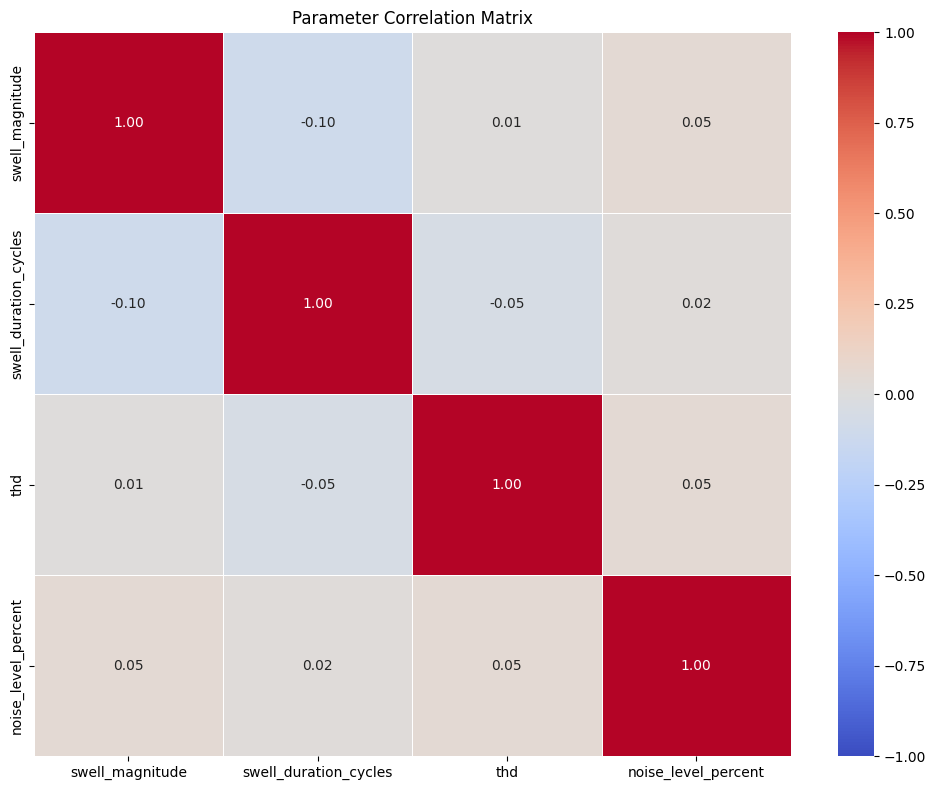

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)/swell_with_harmonics_signals_correlation.png


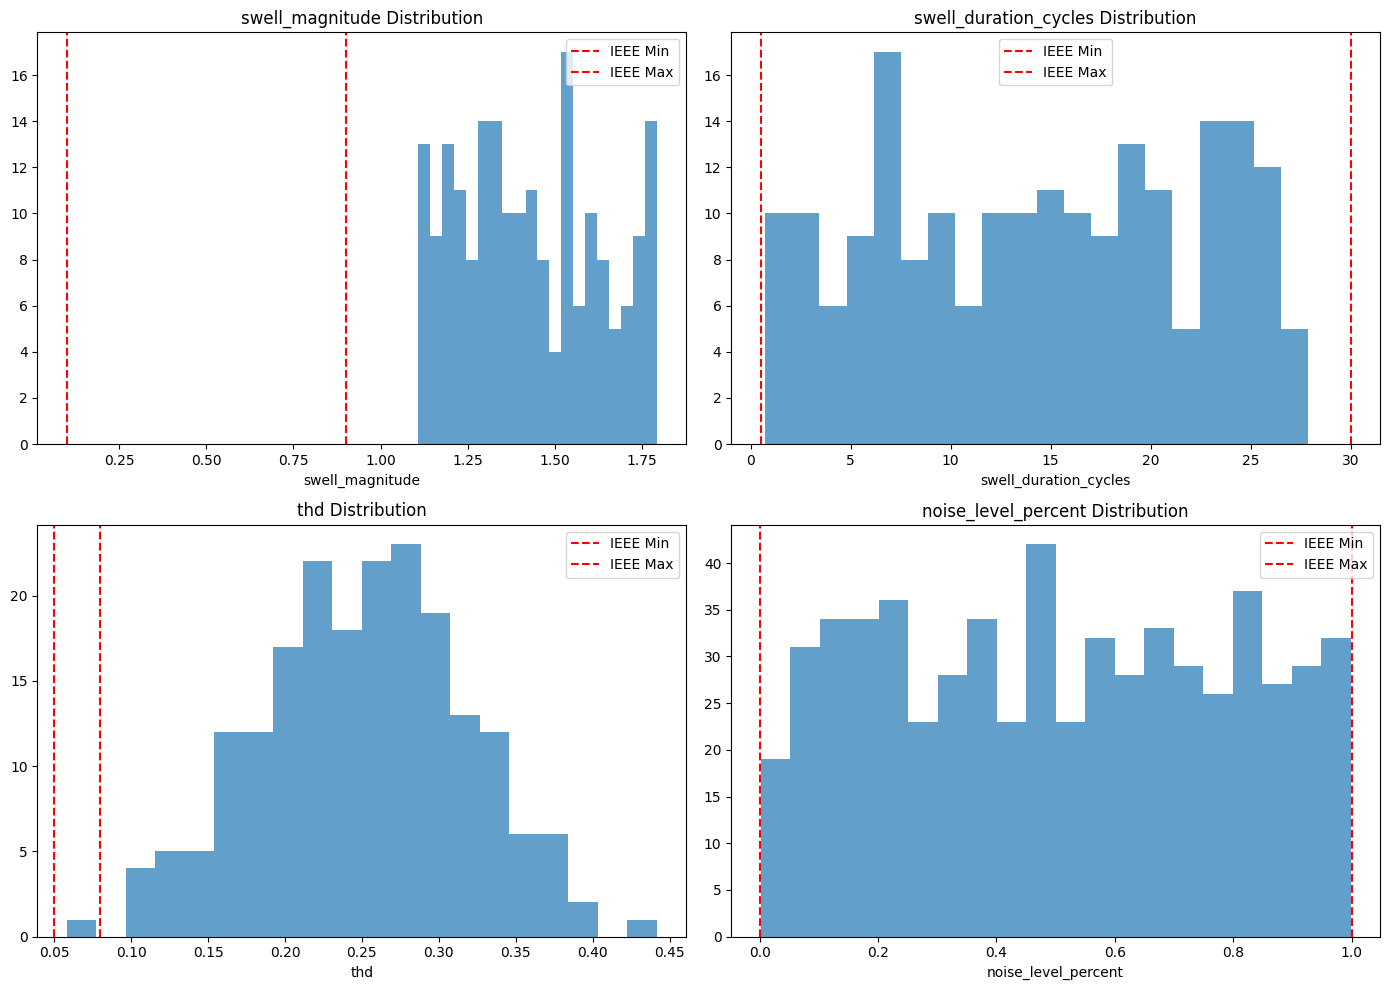

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/19 Swell with Harmonics (M8)/swell_with_harmonics_signals_distributions.png


In [88]:
# @title 19.d. Class 19 - Swell with Harmonics (M8) Statistics

def analyze_swell_with_harmonics_stats(hdf5_path):
    """Perform statistical analysis for M8 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'swell_magnitude': [],
        'swell_duration_cycles': [],
        'thd': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get swell parameters
                swell_params = {}
                swell_group_name = f"{signal_name}_swell_params"
                if swell_group_name in params_group:
                    swell_group = params_group[swell_group_name]
                    swell_params = dict(swell_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['swell_magnitude'].append(swell_params.get('swell_magnitude', np.nan))
                param_data['swell_duration_cycles'].append(swell_params.get('swell_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'swell_magnitude': (0.1, 0.9),
        'swell_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(10, 8))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 2, figsize=(14, 10))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_swell_with_harmonics_stats(hdf5_path)


In [89]:
# @title 20.a. Class 20 - Harmonics with Sag and Flicker (M9) Generation

class HarmonicsWithSagAndFlickerGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Sag and Flicker'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        flicker_depth = random.uniform(0.001, 0.07)
        flicker_frequency = random.uniform(0.5, 25)

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        flicker_envelope = 1 + flicker_depth * np.sin(2 * np.pi * flicker_frequency * self.time)
        combined_signal = sag_envelope * flicker_envelope * harmonics_signal

        final_signal = self._add_noise(combined_signal)
        self.params.update({'sag_params': sag_params, 'harmonics_params': harmonics_params, 'flicker_depth': flicker_depth, 'flicker_frequency': flicker_frequency})

        return final_signal, self.params

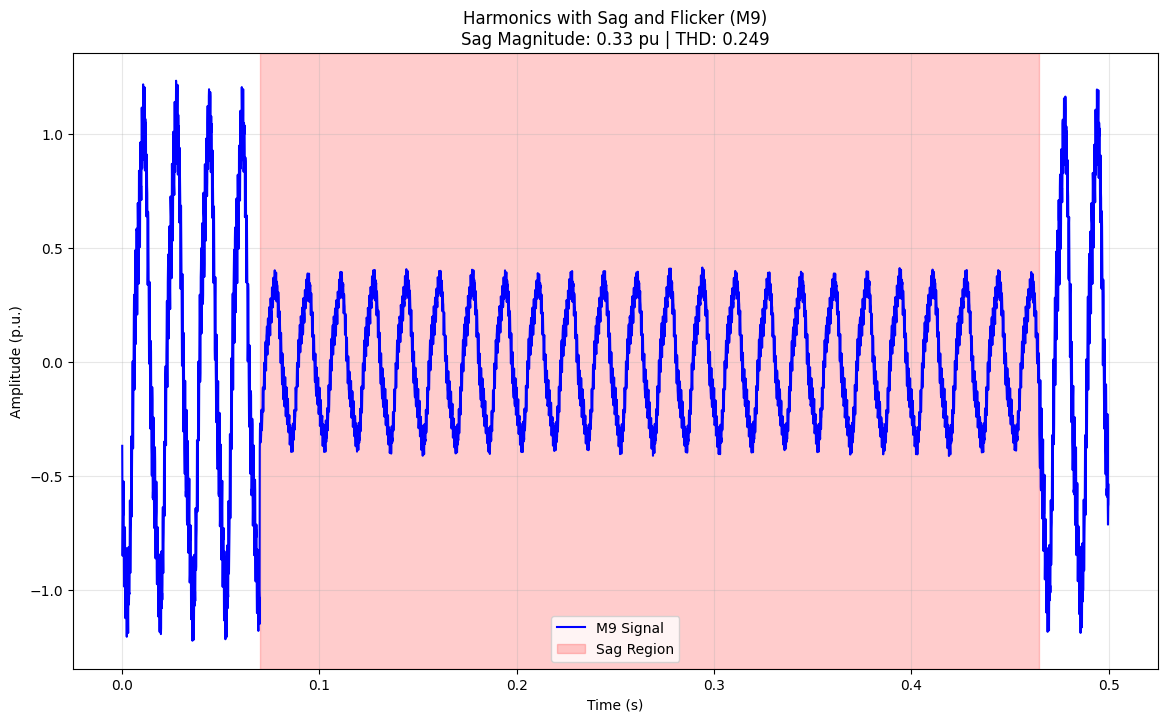

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Sag and Flicker
Base Amplitude (p.u.): 0.9646
Base Frequency (Hz): 60.0095
Sag Magnitude (p.u.): 0.3340
Flicker Depth: 0.0183
THD: 0.2495
Noise Level (%): 0.73


In [166]:
# @title 20.b. Class 20 - Harmonics with Sag and Flicker (M9) Plotting
def plot_harmonics_with_sag_and_flicker(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M9 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Sag and Flicker (M9)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Flicker Depth: {params.get('flicker_depth', 0):.4f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSagAndFlickerGenerator()
signal, params = gen.generate()
plot_harmonics_with_sag_and_flicker(signal, params)

In [91]:
# @title 20.c. Class 20 -Saving Harmonics with Sag and Flicker (M9) Signals

def save_harmonics_with_sag_and_flicker_signals(num_signals=200):
    """Generate and save harmonics with sag and flicker signals"""
    CLASS_NAME = 'Harmonics with Sag and Flicker (M9)'
    CLASS_LABEL = 20
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_sag_and_flicker_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSagAndFlickerGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_harmonics_with_sag_and_flicker_signals(num_signals=200)  # Save 200 signals

Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)/harmonics_with_sag_and_flicker_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)/harmonics_with_sag_and_flicker_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)/harmonics_with_sag_and_flicker_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
sag_magnitude: 200 valid values
sag_duration_cycles: 200 valid values
thd: 200 valid values
flicker_depth: 200 valid values
flicker_frequency: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)/harmonics_with_sag_and_flicker_signals_stats.json


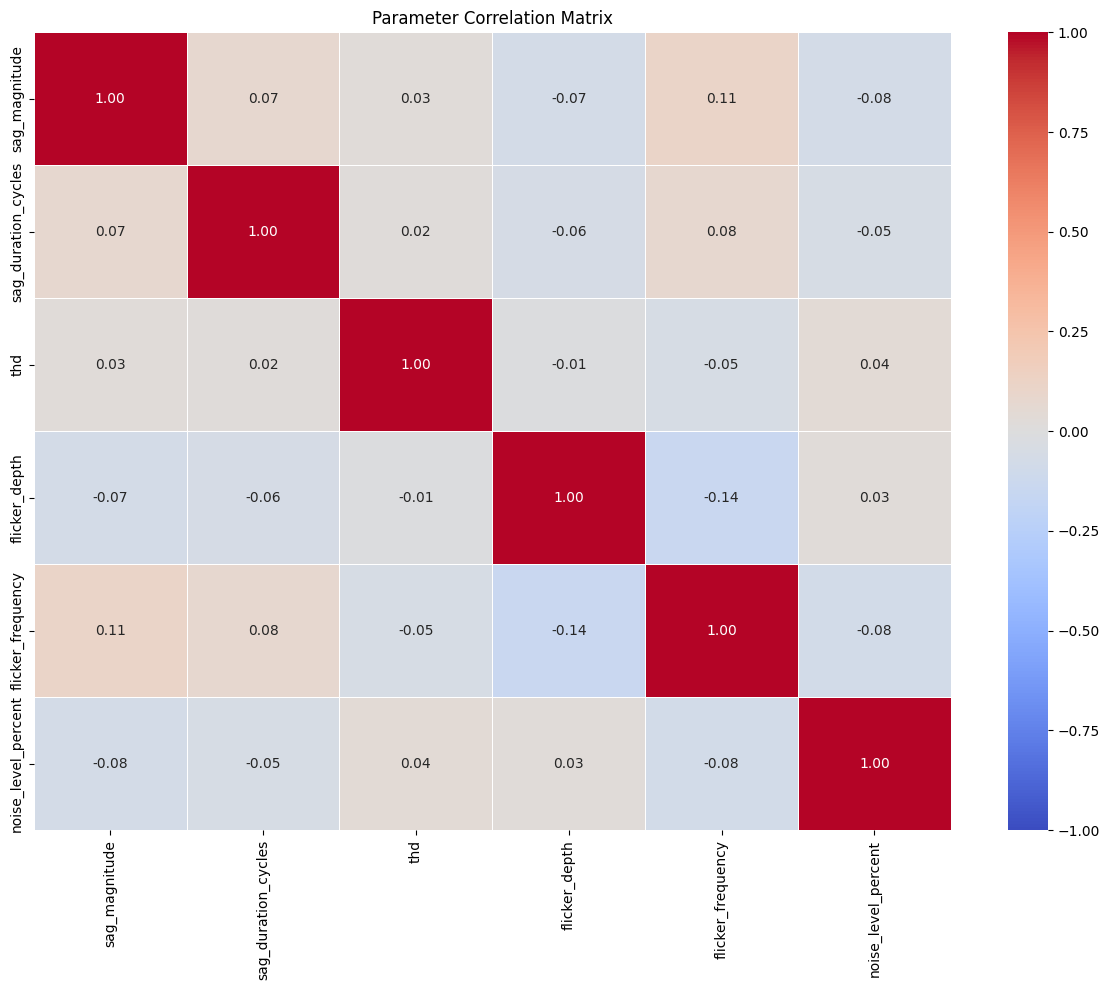

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)/harmonics_with_sag_and_flicker_signals_correlation.png


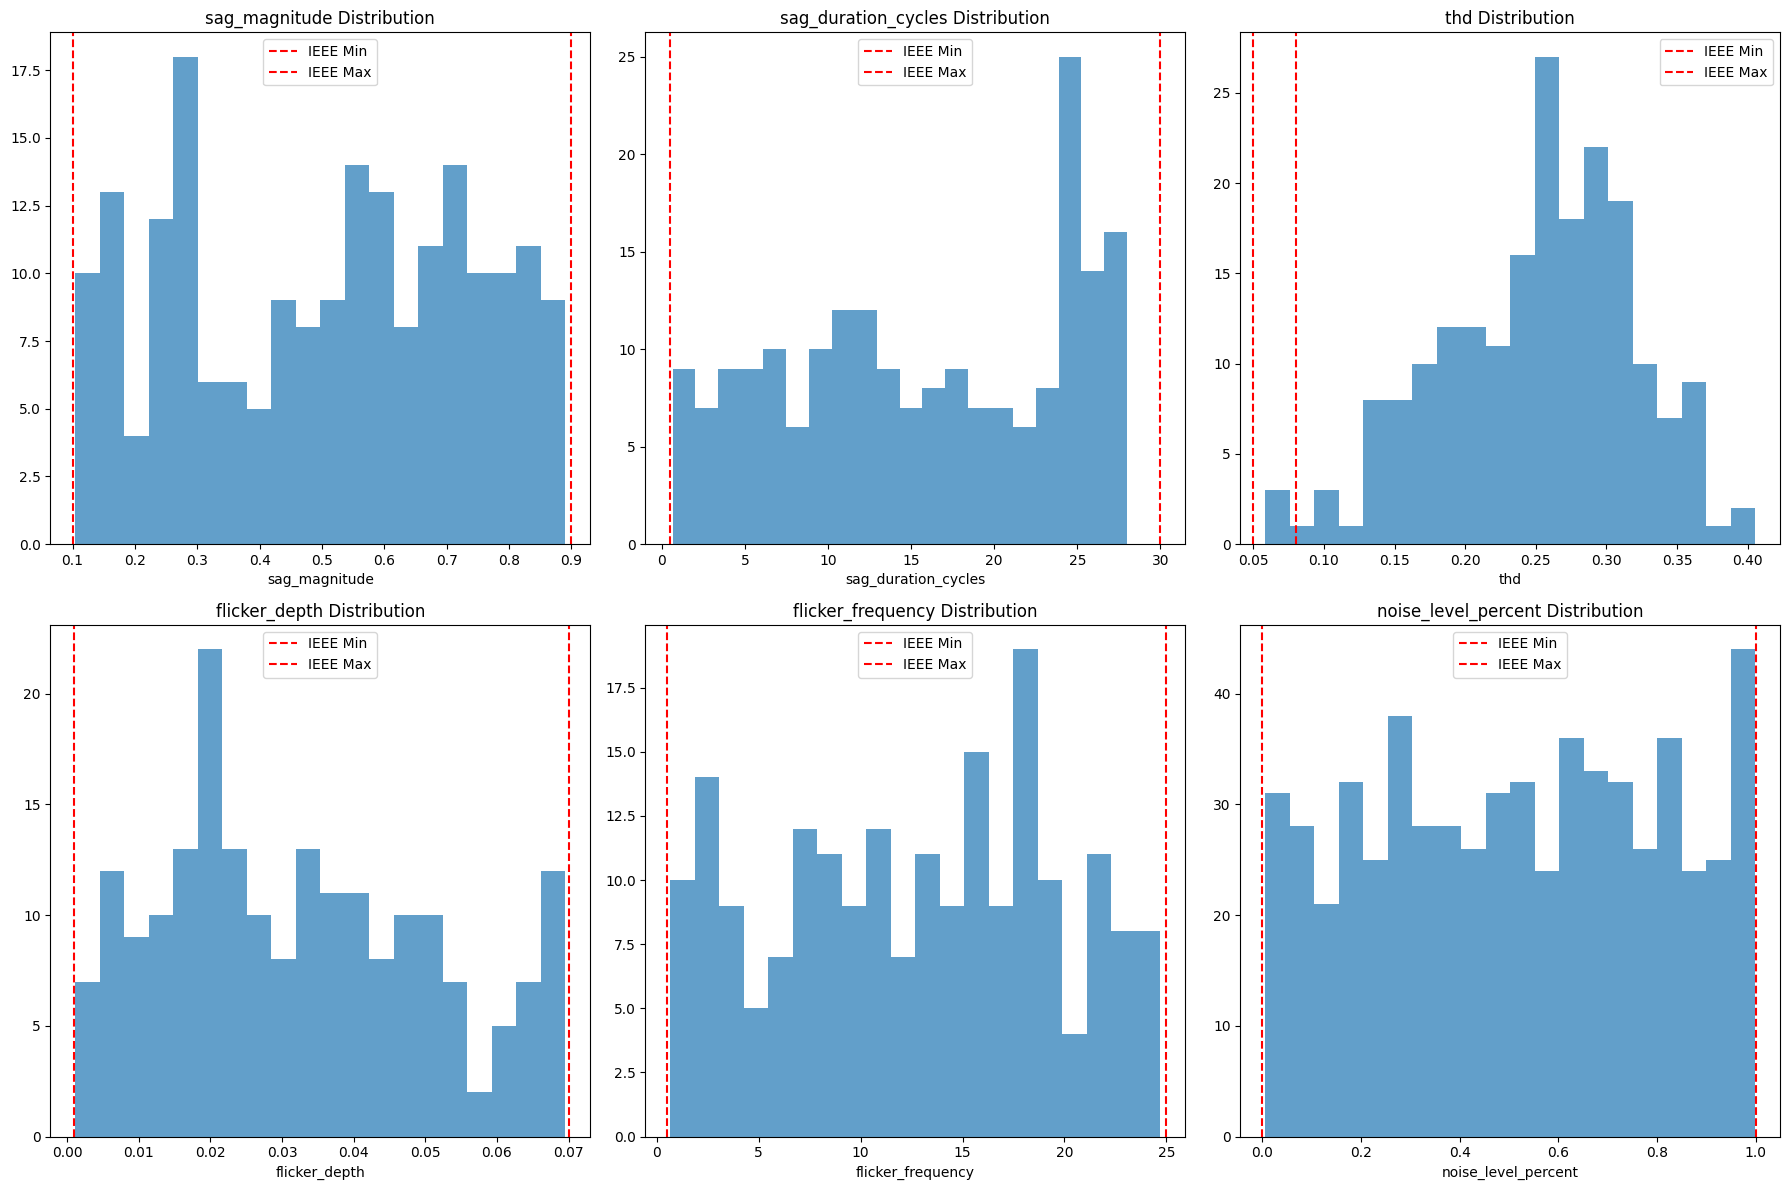

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/20 Harmonics with Sag and Flicker (M9)/harmonics_with_sag_and_flicker_signals_distributions.png


In [92]:
# @title 20.d. Class 20 - Harmonics with Sag and Flicker (M9) Statistics

def analyze_harmonics_with_sag_and_flicker_stats(hdf5_path):
    """Perform statistical analysis for M9 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'sag_magnitude': [],
        'sag_duration_cycles': [],
        'thd': [],
        'flicker_depth': [],
        'flicker_frequency': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get sag parameters
                sag_params = {}
                sag_group_name = f"{signal_name}_sag_params"
                if sag_group_name in params_group:
                    sag_group = params_group[sag_group_name]
                    sag_params = dict(sag_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['sag_magnitude'].append(sag_params.get('sag_magnitude', np.nan))
                param_data['sag_duration_cycles'].append(sag_params.get('sag_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['flicker_depth'].append(param_dset.attrs.get('flicker_depth', np.nan))
                param_data['flicker_frequency'].append(param_dset.attrs.get('flicker_frequency', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'sag_magnitude': (0.1, 0.9),
        'sag_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'flicker_depth': (0.001, 0.07),
        'flicker_frequency': (0.5, 25),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(12, 10))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_harmonics_with_sag_and_flicker_stats(hdf5_path)

In [93]:
# @title 21.a. Class 21 - Harmonics with Swell and Flicker (M10) Generation

class HarmonicsWithSwellAndFlickerGenerator(PQDBaseGenerator):
    """
    Generates signals combining harmonics, swell, and flicker disturbances.
    Mathematical model:
        V(t) = [1 + α·(u(t-t1) - u(t-t2))] × [1 + m·sin(2π·f_flicker·t)] × [A0 + Σ A_n·sin(2π·n·f·t + φ_n)]
    Where:
        α = Swell magnitude (0.1-0.9 pu)
        m = Flicker modulation depth (0.001-0.07)
        f_flicker = Flicker frequency (0.5-25 Hz)
        A_n = Harmonic amplitudes (THD 5-8%)
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Swell and Flicker'

    def generate(self):
        """Generate harmonics with swell and flicker signal"""
        # Generate base signal (clean sine wave)
        base_signal = self.generate_base_sine()

        # Generate harmonics signal
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        # Generate swell parameters
        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        swell_signal, swell_params = swell_gen.generate()

        # Generate flicker parameters
        flicker_depth = random.uniform(0.001, 0.07)  # Flicker modulation depth
        flicker_frequency = random.uniform(0.5, 25)  # Flicker frequency
        self.params['flicker_depth'] = flicker_depth
        self.params['flicker_frequency'] = flicker_frequency

        # Create swell envelope
        t1 = swell_params['swell_start_time']
        t2 = swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = 1 + swell_params['swell_magnitude']

        # Create flicker envelope
        flicker_envelope = 1 + flicker_depth * np.sin(2 * np.pi * flicker_frequency * self.time)

        # Combine disturbances: apply swell and flicker envelopes to harmonics signal
        combined_signal = swell_envelope * flicker_envelope * harmonics_signal

        # Apply peak limit to prevent excessive amplitudes
        peak = np.max(np.abs(combined_signal))
        if peak > 1.1:  # Cap at 1.1 p.u.
            combined_signal = (combined_signal / peak) * 1.1

        # Add noise
        final_signal = self._add_noise(combined_signal)

        # Merge parameters
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'combined_type': 'Multiplicative (Swell × Flicker × Harmonics)',
            't_signal': self.t_signal
        })

        return final_signal, self.params

# Execute the generator and plot the result
gen = HarmonicsWithSwellAndFlickerGenerator()
signal, params = gen.generate()


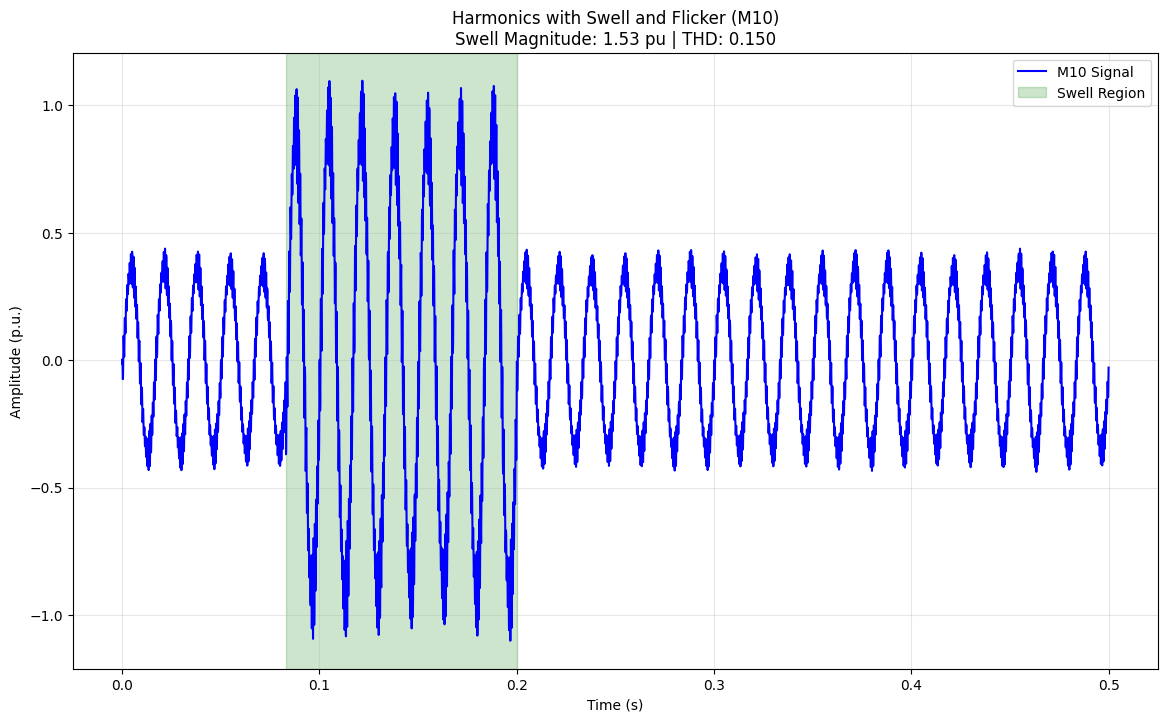

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Swell and Flicker
Base Amplitude (p.u.): 1.0210
Base Frequency (Hz): 60.0019
Swell Magnitude (p.u.): 1.5262
Flicker Depth: 0.0236
THD: 0.1501
Noise Level (%): 0.49


In [167]:
# @title 21.b. Class 21 - Harmonics with Swell and Flicker (M10) Plotting
def plot_harmonics_with_swell_and_flicker(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M10 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Swell and Flicker (M10)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Flicker Depth: {params.get('flicker_depth', 0):.4f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSwellAndFlickerGenerator()
signal, params = gen.generate()
plot_harmonics_with_swell_and_flicker(signal, params)

In [95]:
# @title 21.c. Class 21 - Saving Harmonics with Swell and Flicker (M10) Signals

def save_harmonics_with_swell_and_flicker_signals(num_signals=200):
    """Generate and save harmonics with swell and flicker signals"""
    CLASS_NAME = 'Harmonics with Swell and Flicker (M10)'
    CLASS_LABEL = 21
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_swell_and_flicker_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSwellAndFlickerGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_harmonics_with_swell_and_flicker_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)/harmonics_with_swell_and_flicker_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)/harmonics_with_swell_and_flicker_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)/harmonics_with_swell_and_flicker_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
swell_magnitude: 200 valid values
swell_duration_cycles: 200 valid values
thd: 200 valid values
flicker_depth: 200 valid values
flicker_frequency: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)/harmonics_with_swell_and_flicker_signals_stats.json


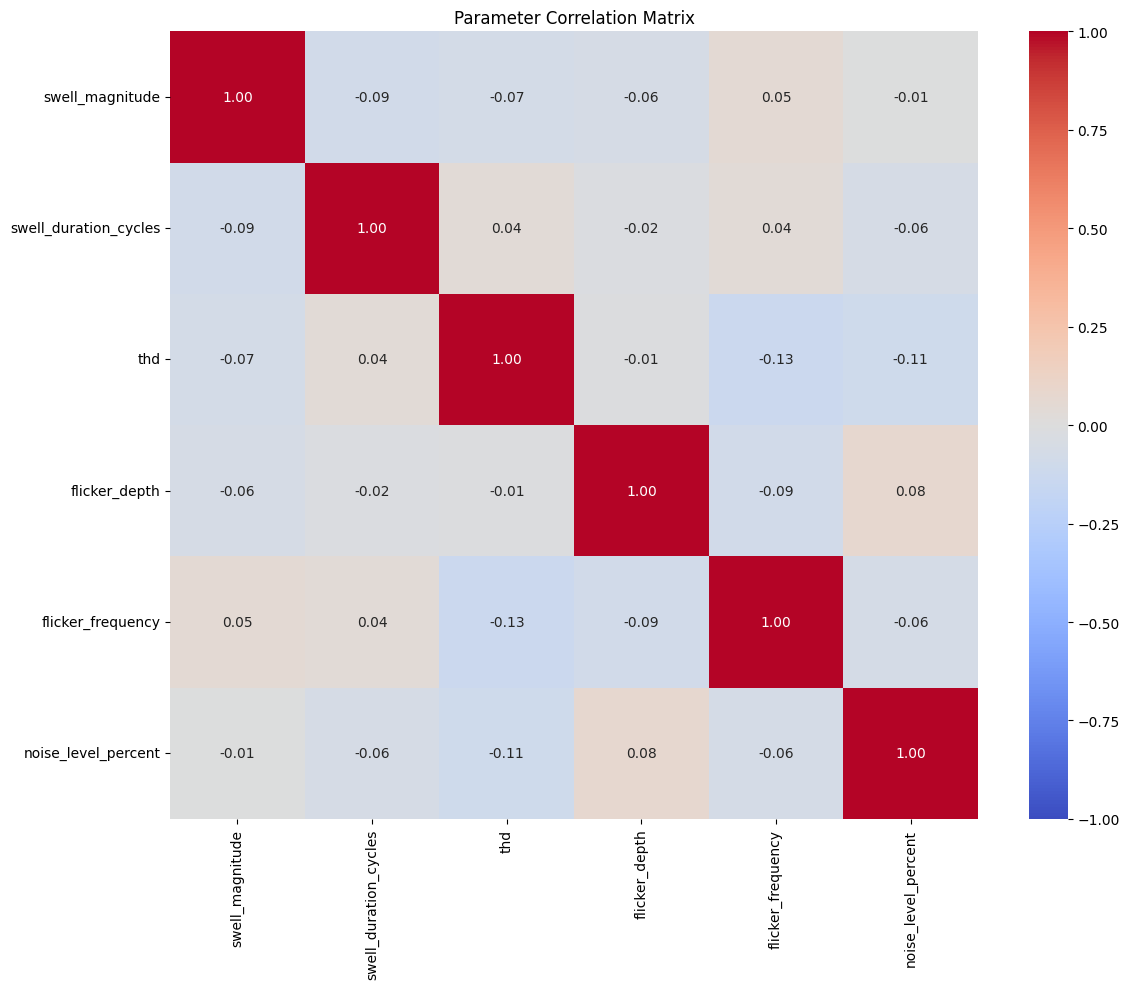

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)/harmonics_with_swell_and_flicker_signals_correlation.png


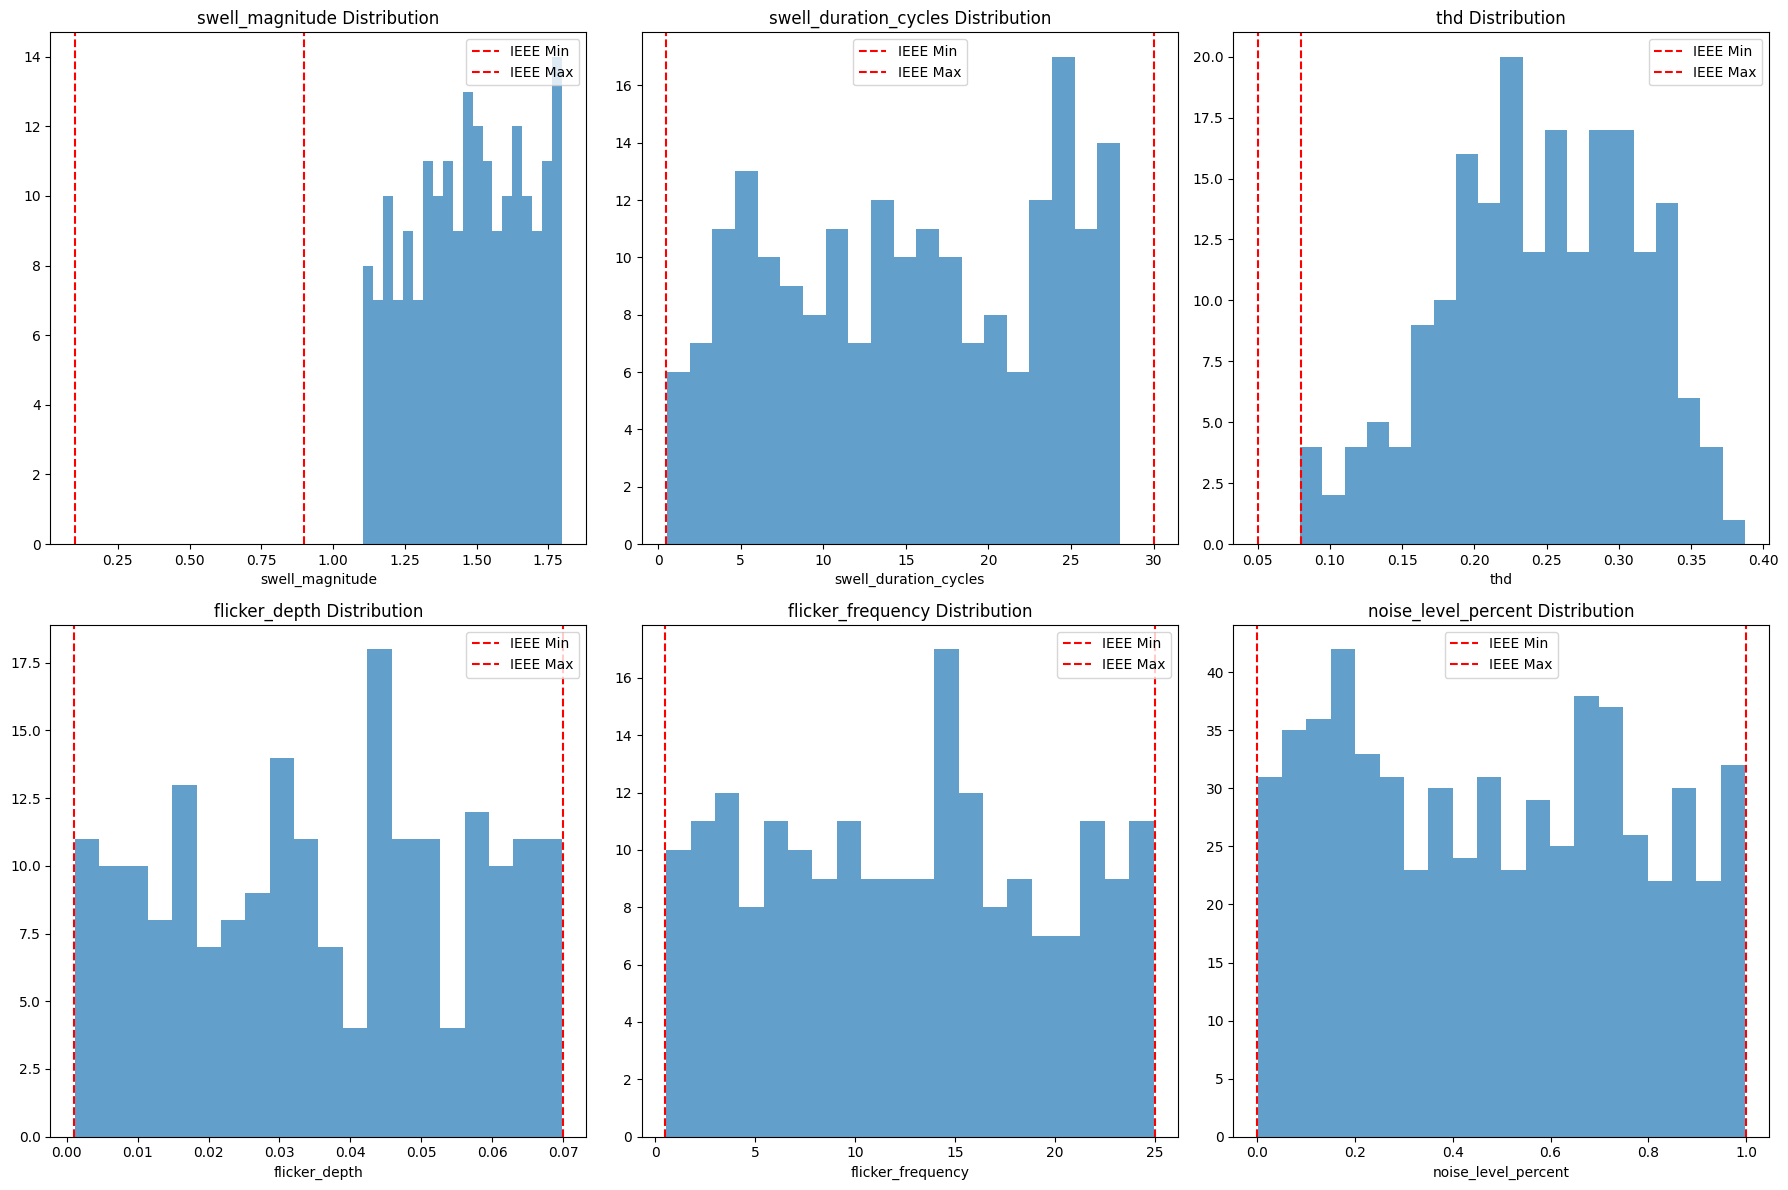

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/21 Harmonics with Swell and Flicker (M10)/harmonics_with_swell_and_flicker_signals_distributions.png


In [96]:
# @title 21.d. Class 21 - Harmonics with Swell and Flicker (M10) Statistics

def analyze_harmonics_with_swell_and_flicker_stats(hdf5_path):
    """Perform statistical analysis for M10 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'swell_magnitude': [],
        'swell_duration_cycles': [],
        'thd': [],
        'flicker_depth': [],
        'flicker_frequency': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get swell parameters
                swell_params = {}
                swell_group_name = f"{signal_name}_swell_params"
                if swell_group_name in params_group:
                    swell_group = params_group[swell_group_name]
                    swell_params = dict(swell_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['swell_magnitude'].append(swell_params.get('swell_magnitude', np.nan))
                param_data['swell_duration_cycles'].append(swell_params.get('swell_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['flicker_depth'].append(param_dset.attrs.get('flicker_depth', np.nan))
                param_data['flicker_frequency'].append(param_dset.attrs.get('flicker_frequency', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'swell_magnitude': (0.1, 0.9),
        'swell_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'flicker_depth': (0.001, 0.07),
        'flicker_frequency': (0.5, 25),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(12, 10))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_harmonics_with_swell_and_flicker_stats(hdf5_path)


In [144]:
# @title 22.a Class 22 - Sag with Harmonics and Flicker (M11) Generation

class SagWithHarmonicsAndFlickerGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Sag with Harmonics and Flicker'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        flicker_depth = random.uniform(0.001, 0.07)
        flicker_frequency = random.uniform(0.5, 25)

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)

        # Use magnitude directly as remaining voltage
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        flicker_envelope = 1 + flicker_depth * np.sin(2 * np.pi * flicker_frequency * self.time)
        combined_signal = sag_envelope * flicker_envelope * harmonics_signal

        final_signal = self._add_noise(combined_signal)
        self.params.update({'sag_params': sag_params, 'harmonics_params': harmonics_params, 'flicker_depth': flicker_depth, 'flicker_frequency': flicker_frequency})

        return final_signal, self.params

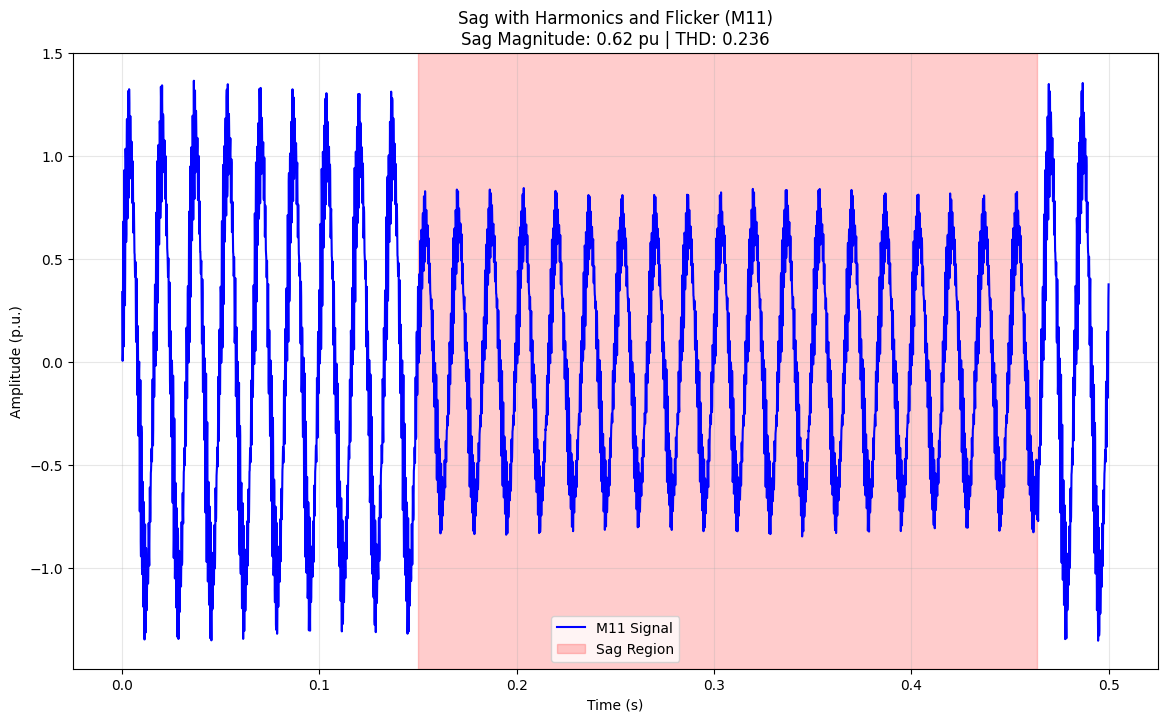

--- Generated Signal Parameters ---
Disturbance Type: Sag with Harmonics and Flicker
Base Amplitude (p.u.): 0.9604
Base Frequency (Hz): 59.9988
Sag Magnitude (p.u.): 0.6205
Flicker Depth: 0.0194
THD: 0.2359
Noise Level (%): 0.93


In [154]:
# @title 22.b. Class 22 - Sag with Harmonics and Flicker (M11) Plotting
def plot_sag_with_harmonics_and_flicker(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M11 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Sag with Harmonics and Flicker (M11)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Flicker Depth: {params.get('flicker_depth', 0):.4f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SagWithHarmonicsAndFlickerGenerator()
sig_m11, par_m11 = gen.generate()
plot_sag_with_harmonics_and_flicker(sig_m11, par_m11)

In [99]:
# @title 22.c. Class 22 - Saving Sag with Harmonics and Flicker (M11) Signals

def save_sag_with_harmonics_and_flicker_signals(num_signals=200):
    """Generate and save sag with harmonics and flicker signals"""
    CLASS_NAME = 'Sag with Harmonics and Flicker (M11)'
    CLASS_LABEL = 22
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'sag_with_harmonics_and_flicker_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SagWithHarmonicsAndFlickerGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_sag_with_harmonics_and_flicker_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)/sag_with_harmonics_and_flicker_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)/sag_with_harmonics_and_flicker_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)/sag_with_harmonics_and_flicker_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
sag_magnitude: 200 valid values
sag_duration_cycles: 200 valid values
thd: 200 valid values
flicker_depth: 200 valid values
flicker_frequency: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)/sag_with_harmonics_and_flicker_signals_stats.json


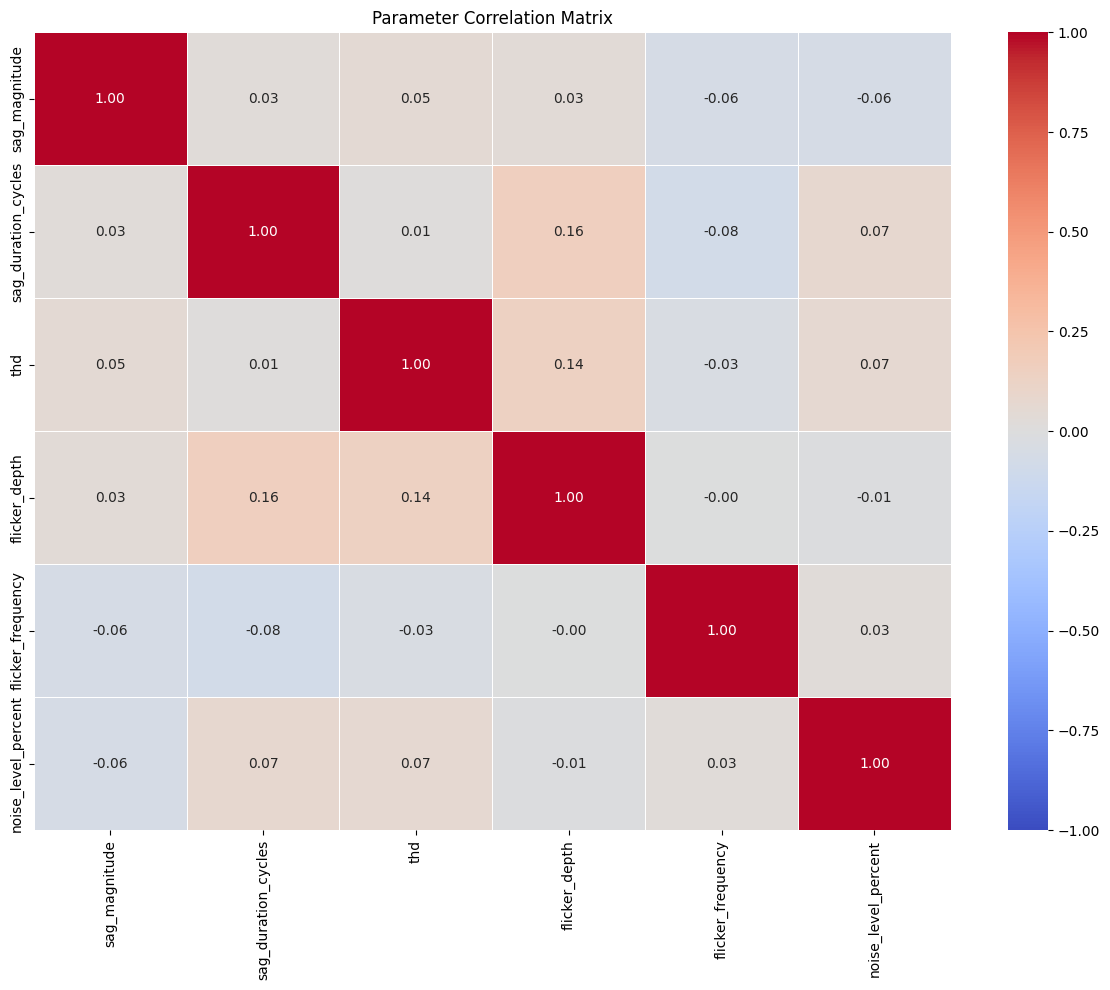

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)/sag_with_harmonics_and_flicker_signals_correlation.png


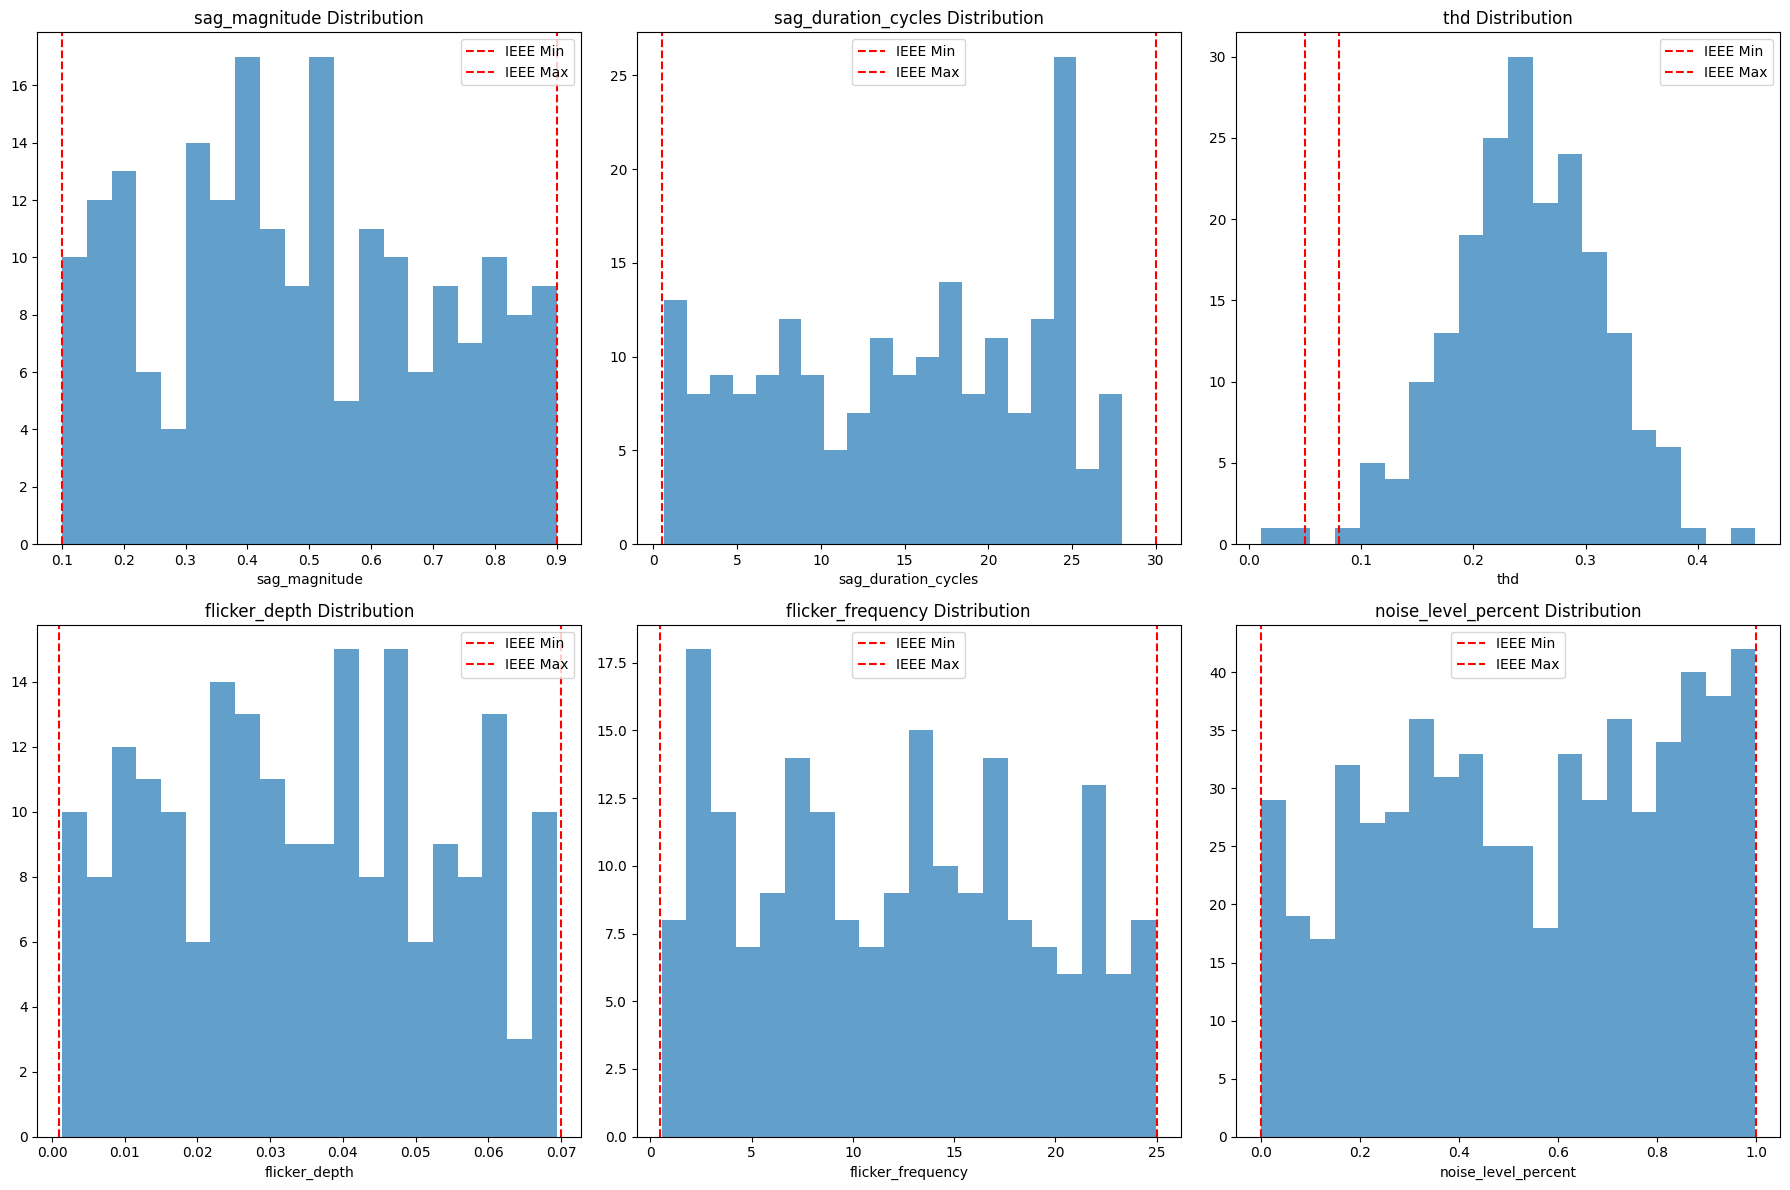

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/22 Sag with Harmonics and Flicker (M11)/sag_with_harmonics_and_flicker_signals_distributions.png


In [100]:
# @title 22.d. Class 22 - Sag with Harmonics and Flicker (M11) Statistics

def analyze_sag_with_harmonics_and_flicker_stats(hdf5_path):
    """Perform statistical analysis for M11 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'sag_magnitude': [],
        'sag_duration_cycles': [],
        'thd': [],
        'flicker_depth': [],
        'flicker_frequency': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get sag parameters
                sag_params = {}
                sag_group_name = f"{signal_name}_sag_params"
                if sag_group_name in params_group:
                    sag_group = params_group[sag_group_name]
                    sag_params = dict(sag_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['sag_magnitude'].append(sag_params.get('sag_magnitude', np.nan))
                param_data['sag_duration_cycles'].append(sag_params.get('sag_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['flicker_depth'].append(param_dset.attrs.get('flicker_depth', np.nan))
                param_data['flicker_frequency'].append(param_dset.attrs.get('flicker_frequency', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'sag_magnitude': (0.1, 0.9),
        'sag_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'flicker_depth': (0.001, 0.07),
        'flicker_frequency': (0.5, 25),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(12, 10))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_sag_with_harmonics_and_flicker_stats(hdf5_path)


In [101]:
# @title 23.a. Class 23 - Swell with Harmonics and Flicker (M12) Generation

class SwellWithHarmonicsAndFlickerGenerator(PQDBaseGenerator):
    """
    Generates signals combining swell, harmonics, and flicker disturbances.
    Mathematical model:
        V(t) = [1 + α·(u(t-t1) - u极(t-t2))] × [1 + m·sin(2π·f_flicker·t)] × [A0 + Σ A_n·sin(2π·n·f·t + φ_n)]
    Where:
        α = Swell magnitude (0.1-0.9 pu)
        m = Flicker modulation depth (0.001-0.07)
        f_flicker = Flicker frequency (0.5-25 Hz)
        A_n = Harmonic amplitudes (THD 5-8%)
    """
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Swell with Harmonics and Flicker'

    def generate(self):
        """Generate swell with harmonics and flicker signal"""
        # Generate base signal (clean sine wave)
        base_signal = self.generate_base_sine()

        # Generate harmonics signal
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        # Generate swell parameters
        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        swell_signal, swell_params = swell_gen.generate()

        # Generate flicker parameters
        flicker_depth = random.uniform(0.001, 0.07)  # Flicker modulation depth
        flicker_frequency = random.uniform(0.5, 25)  # Flicker frequency
        self.params['flicker_depth'] = flicker_depth
        self.params['flicker_frequency'] = flicker_frequency

        # Create swell envelope
        t1 = swell_params['swell_start_time']
        t2 = swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = 1 + swell_params['swell_magnitude']

        # Create flicker envelope
        flicker_envelope = 1 + flicker_depth * np.sin(2 * np.pi * flicker_frequency * self.time)

        # Combine disturbances: apply swell and flicker envelopes to harmonics signal
        combined_signal = swell_envelope * flicker_envelope * harmonics_signal

        # Apply peak limit to prevent excessive amplitudes
        peak = np.max(np.abs(combined_signal))
        if peak > 1.1:  # Cap at 1.1 p.u.
            combined_signal = (combined_signal / peak) * 1.1

        # Add noise
        final_signal = self._add_noise(combined_signal)

        # Merge parameters
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'combined_type': 'Multiplicative (Swell × Flicker × Harmonics)',
            't_signal': self.t_signal
        })

        return final_signal, self.params

# Execute the generator and plot the result
gen = SwellWithHarmonicsAndFlickerGenerator()
signal, params = gen.generate()

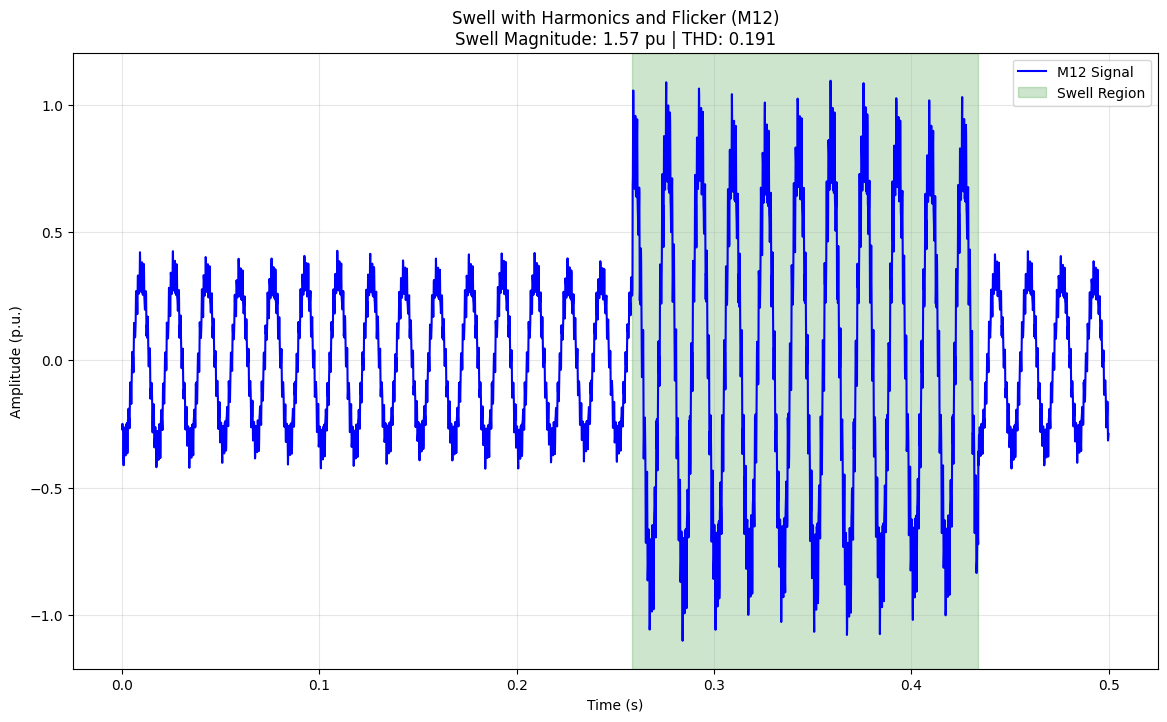

--- Generated Signal Parameters ---
Disturbance Type: Swell with Harmonics and Flicker
Base Amplitude (p.u.): 1.0274
Base Frequency (Hz): 59.9918
Swell Magnitude (p.u.): 1.5696
Flicker Depth: 0.0406
THD: 0.1907
Noise Level (%): 0.32


In [168]:
# @title 23.b. Class 23 - Swell with Harmonics and Flicker (M12) Plotting
def plot_swell_with_harmonics_and_flicker(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M12 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Swell with Harmonics and Flicker (M12)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Flicker Depth: {params.get('flicker_depth', 0):.4f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SwellWithHarmonicsAndFlickerGenerator()
signal, params = gen.generate()
plot_swell_with_harmonics_and_flicker(signal, params)

In [103]:
# @title 23.c. Class 23 - Saving Swell with Harmonics and Flicker (M12) Signals

def save_swell_with_harmonics_and_flicker_signals(num_signals=200):
    """Generate and save swell with harmonics and flicker signals"""
    CLASS_NAME = 'Swell with Harmonics and Flicker (M12)'
    CLASS_LABEL = 23
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'swell_with_harmonics_and_flicker_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SwellWithHarmonicsAndFlickerGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_swell_with_harmonics_and_flicker_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)/swell_with_harmonics_and_flicker_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)/swell_with_harmonics_and_flicker_signals.h5


🔍 Analyzing file: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)/swell_with_harmonics_and_flicker_signals.h5
Found 600 signals in the file
Processed 1/600 signals
Processed 51/600 signals
Processed 101/600 signals
Processed 151/600 signals
Processed 201/600 signals
Processed 251/600 signals
Processed 301/600 signals
Processed 351/600 signals
Processed 401/600 signals
Processed 451/600 signals
Processed 501/600 signals
Processed 551/600 signals
DataFrame created with parameter data
swell_magnitude: 200 valid values
swell_duration_cycles: 200 valid values
thd: 200 valid values
flicker_depth: 200 valid values
flicker_frequency: 200 valid values
noise_level_percent: 600 valid values
✅ Statistics saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)/swell_with_harmonics_and_flicker_signals_stats.json


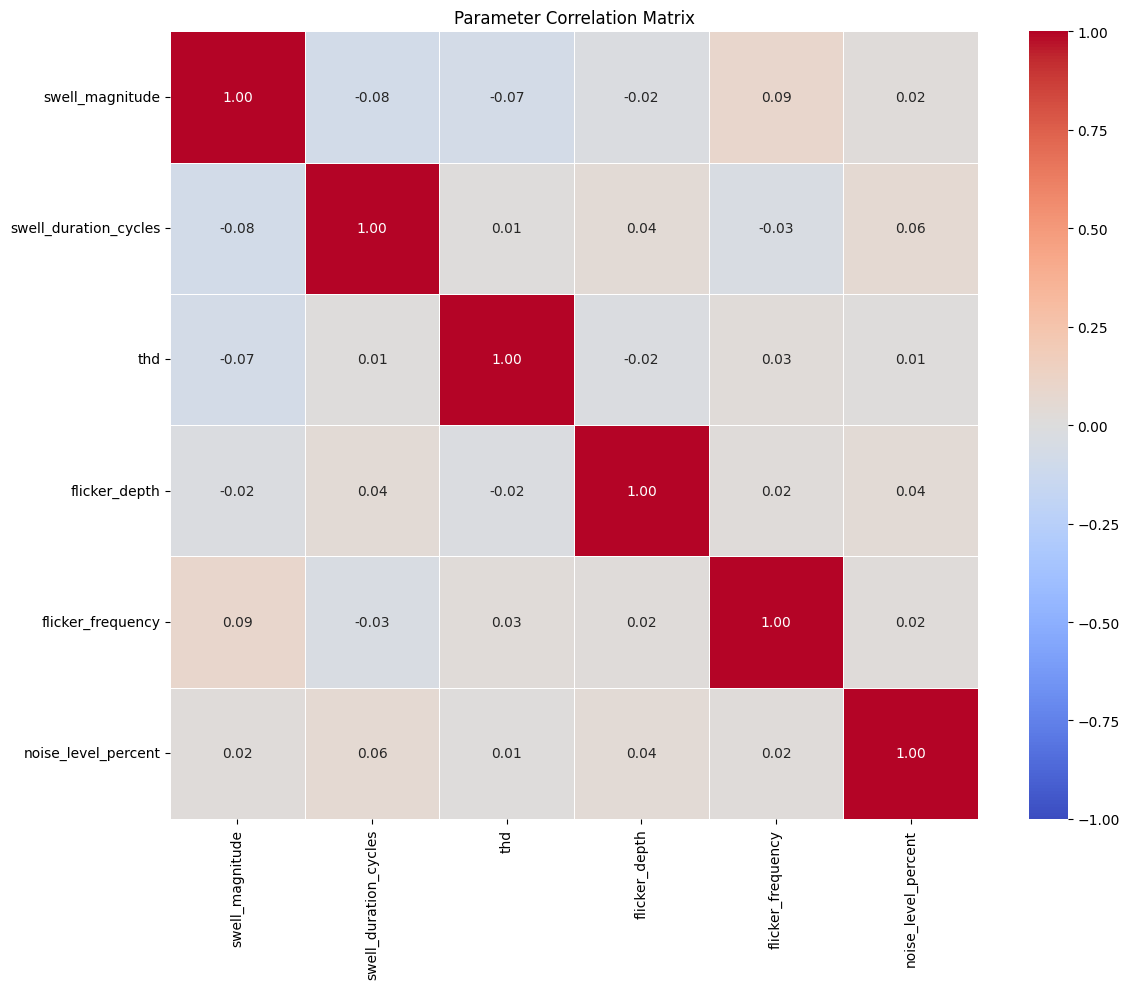

✅ Correlation heatmap saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)/swell_with_harmonics_and_flicker_signals_correlation.png


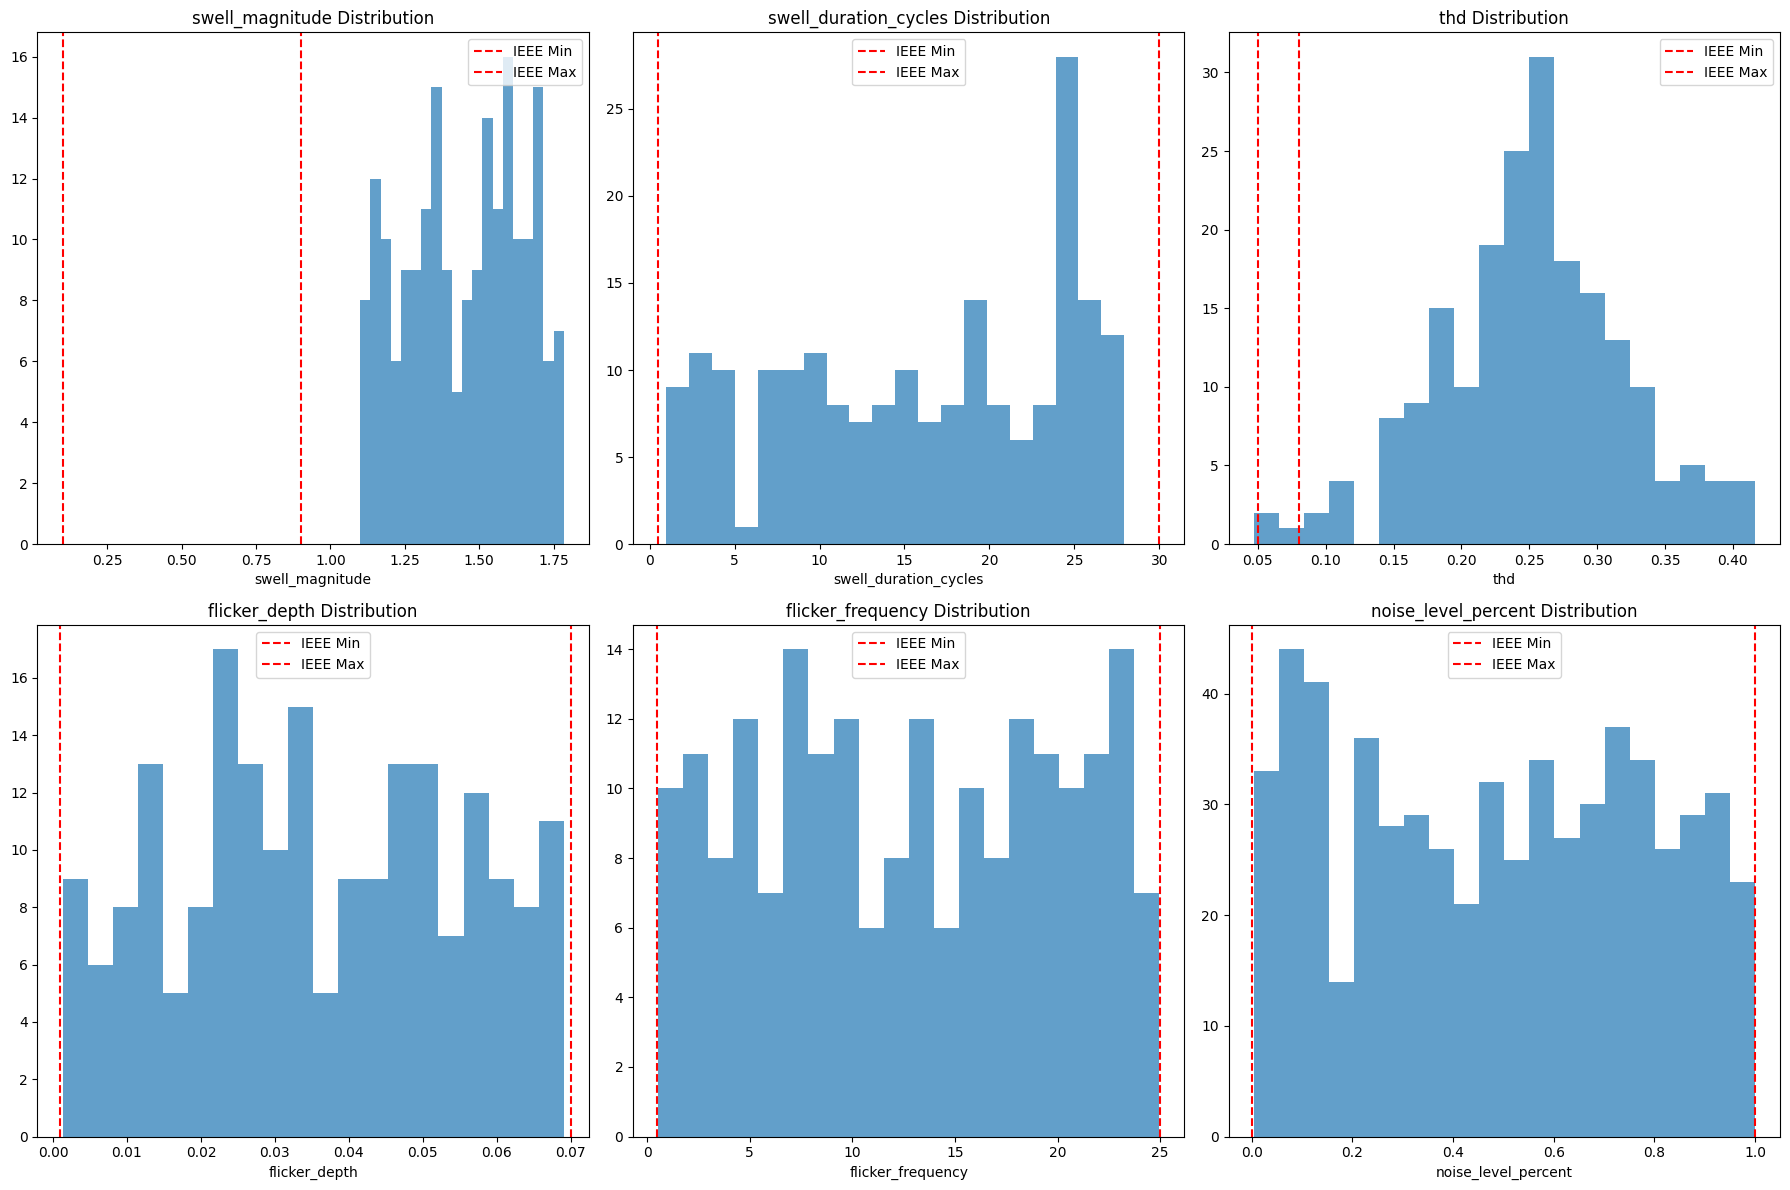

✅ Distribution plots saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/23 Swell with Harmonics and Flicker (M12)/swell_with_harmonics_and_flicker_signals_distributions.png


In [104]:
# @title 23.d. Class 23 - Swell with Harmonics and Flicker (M12) Statistics

def analyze_swell_with_harmonics_and_flicker_stats(hdf5_path):
    """Perform statistical analysis for M12 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        print("Please run saving block first")
        return None

    print(f"🔍 Analyzing file: {hdf5_path}")

    # Output paths
    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    # Data collection
    param_data = {
        'swell_magnitude': [],
        'swell_duration_cycles': [],
        'thd': [],
        'flicker_depth': [],
        'flicker_frequency': [],
        'noise_level_percent': []
    }

    try:
        # Extract parameters
        with h5py.File(hdf5_path, 'r') as f:
            if 'parameters' not in f:
                print("❌ 'parameters' group not found in HDF5 file")
                return None

            params_group = f['parameters']
            signal_count = len(params_group)
            print(f"Found {signal_count} signals in the file")

            for i, signal_name in enumerate(params_group):
                if not signal_name.startswith('signal_'):
                    continue

                param_dset = params_group[signal_name]
                param_attrs = dict(param_dset.attrs)

                # Get swell parameters
                swell_params = {}
                swell_group_name = f"{signal_name}_swell_params"
                if swell_group_name in params_group:
                    swell_group = params_group[swell_group_name]
                    swell_params = dict(swell_group.attrs)

                # Get harmonics parameters
                harmonics_params = {}
                harmonics_group_name = f"{signal_name}_harmonics_params"
                if harmonics_group_name in params_group:
                    harmonics_group = params_group[harmonics_group_name]
                    harmonics_params = dict(harmonics_group.attrs)

                # Collect values
                param_data['swell_magnitude'].append(swell_params.get('swell_magnitude', np.nan))
                param_data['swell_duration_cycles'].append(swell_params.get('swell_duration_cycles', np.nan))
                param_data['thd'].append(harmonics_params.get('thd', np.nan))
                param_data['flicker_depth'].append(param_dset.attrs.get('flicker_depth', np.nan))
                param_data['flicker_frequency'].append(param_dset.attrs.get('flicker_frequency', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))

                if i % 50 == 0:
                    print(f"Processed {i+1}/{signal_count} signals")

    except Exception as e:
        print(f"❌ Error reading HDF5 file: {str(e)}")
        return None

    # Create DataFrame
    df = pd.DataFrame(param_data)
    print("DataFrame created with parameter data")

    # Statistical analysis
    stats = {}
    ieee_ranges = {
        'swell_magnitude': (1.1, 1.8),
        'swell_duration_cycles': (0.5, 30),
        'thd': (0.05, 0.08), #This range will depend on the Electrical Tension magnitude and the Relative Impedance of the installation "Check IEEE 519 Standard
        'flicker_depth': (0.001, 0.07),
        'flicker_frequency': (0.5, 25),
        'noise_level_percent': (0, 1)
    }

    for param, values in param_data.items():
        valid_vals = np.array(values)[~np.isnan(values)]
        valid_count = len(valid_vals)
        print(f"{param}: {valid_count} valid values")

        if valid_count == 0:
            stats[param] = {'error': 'No valid values'}
            continue

        try:
            ks_stat, p_value = kstest(valid_vals, 'uniform',
                                     args=(ieee_ranges[param][0],
                                           ieee_ranges[param][1] - ieee_ranges[param][0]))
        except Exception as e:
            print(f"KS test failed for {param}: {str(e)}")
            p_value = np.nan

        stats[param] = {
            'min': float(np.min(valid_vals)),
            'max': float(np.max(valid_vals)),
            'mean': float(np.mean(valid_vals)),
            'std': float(np.std(valid_vals)),
            'ks_pvalue': float(p_value),
            'ieee_min': ieee_ranges[param][0],
            'ieee_max': ieee_ranges[param][1],
            'valid_count': valid_count
        }

    # Save statistics
    try:
        with open(stats_path, 'w') as f:
            json.dump(stats, f, indent=4)
        print(f"✅ Statistics saved to: {stats_path}")
    except Exception as e:
        print(f"❌ Error saving statistics: {str(e)}")

    # Create and display correlation heatmap
    try:
        plt.figure(figsize=(12, 10))
        if not df.empty:
            corr = df.corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1.0, vmax=1.0)
            plt.title("Parameter Correlation Matrix")
            plt.tight_layout()
            plt.savefig(heatmap_path)
            plt.show()
            print(f"✅ Correlation heatmap saved to: {heatmap_path}")
        else:
            print("❌ DataFrame is empty, cannot create heatmap.")

    except Exception as e:
        print(f"❌ Error creating heatmap: {str(e)}")

    # Create and display distribution plots
    try:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        for i, param in enumerate(param_data.keys()):
            ax = axs.flat[i]
            ax.hist(df[param].dropna(), bins=20, alpha=0.7)
            ax.axvline(ieee_ranges[param][0], color='r', linestyle='--', label='IEEE Min')
            ax.axvline(ieee_ranges[param][1], color='r', linestyle='--', label='IEEE Max')
            ax.set_title(f"{param} Distribution")
            ax.set_xlabel(param)
            ax.legend()
        plt.tight_layout()
        plt.savefig(dist_path)
        plt.show()
        print(f"✅ Distribution plots saved to: {dist_path}")

    except Exception as e:
        print(f"❌ Error creating distribution plots: {str(e)}")

    return stats

# Execute the statistics analysis
if hdf5_path:  # Only run if saving succeeded
    stats = analyze_swell_with_harmonics_and_flicker_stats(hdf5_path)


In [174]:
# @title 24.a. Class 24 - Sag with Harmonics and Oscillatory Transient (M13) Generation

class SagWithHarmonicsAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Sag with Harmonics and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        transient_amp = random.uniform(0.05, 0.2)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        combined_signal = sag_envelope * (harmonics_signal + transient_component)

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'sag_params': sag_params,
            'harmonics_params': harmonics_params,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

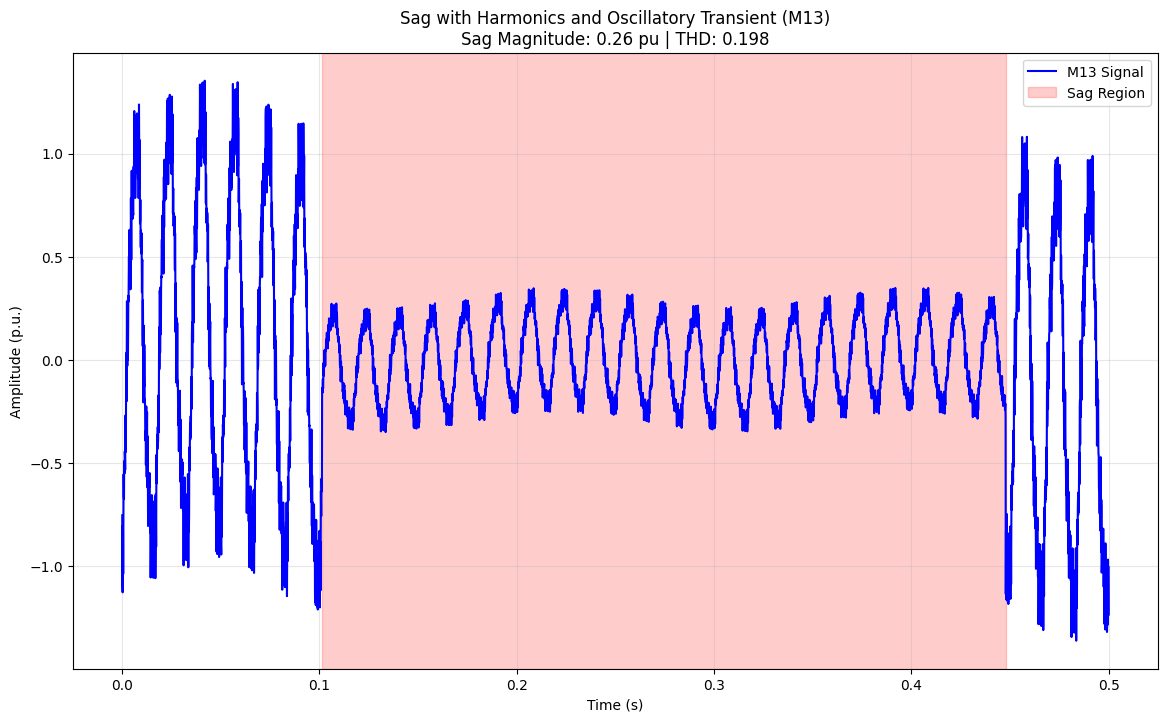

--- Generated Signal Parameters ---
Disturbance Type: Sag with Harmonics and Oscillatory Transient
Base Amplitude (p.u.): 0.9716
Base Frequency (Hz): 59.9982
Sag Magnitude (p.u.): 0.2569
Transient Freq (Hz): 5.64
THD: 0.1976
Noise Level (%): 0.09


In [155]:
# @title 24.b. Class 24 - Sag with Harmonics and Oscillatory Transient (M13) Plotting
def plot_sag_with_harmonics_and_oscillatory_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M13 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Sag with Harmonics and Oscillatory Transient (M13)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('oscillatory_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SagWithHarmonicsAndOscillatoryTransientGenerator()
sig_m13, par_m13 = gen_m13.generate()
plot_sag_with_harmonics_and_oscillatory_transient(sig_m13, par_m13)

In [107]:
# @title 24.c. Class 24 - Saving Sag with Harmonics and Oscillatory Transient (M13) Signals

def save_sag_with_harmonics_and_oscillatory_transient_signals(num_signals=200):
    """Generate and save sag with harmonics and oscillatory transient signals"""
    CLASS_NAME = 'Sag with Harmonics and Oscillatory Transient (M13)'
    CLASS_LABEL = 24
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    # Debug root path
    print(f"Dataset root path: {DATASET_FULL_PATH}")

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    print(f"Creating directory at: {CLASS_PATH}")

    # Create directory with exist_ok and verify
    os.makedirs(CLASS_PATH, exist_ok=True)
    if not os.path.exists(CLASS_PATH):
        print(f"❌ ERROR: Directory creation failed at {CLASS_PATH}")
        return None
    else:
        print(f"✅ Directory created: {CLASS_PATH}")

    hdf5_path = os.path.join(CLASS_PATH, 'sag_with_harmonics_and_oscillatory_transient_signals.h5')
    print(f"Saving to: {hdf5_path}")

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                            shape=(0, num_samples),
                                            maxshape=(None, num_samples),
                                            dtype=np.float32,
                                            compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SagWithHarmonicsAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

                if (i+1) % 50 == 0:
                    print(f"Generated {i+1}/{num_signals} signals")

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ ERROR during saving: {str(e)}")
        return None

# Execute the saving function
hdf5_path = save_sag_with_harmonics_and_oscillatory_transient_signals(num_signals=200)  # Save 200 signals


Dataset root path: /content/drive/MyDrive/PQD_Synthetic_Dataset
Creating directory at: /content/drive/MyDrive/PQD_Synthetic_Dataset/24 Sag with Harmonics and Oscillatory Transient (M13)
✅ Directory created: /content/drive/MyDrive/PQD_Synthetic_Dataset/24 Sag with Harmonics and Oscillatory Transient (M13)
Saving to: /content/drive/MyDrive/PQD_Synthetic_Dataset/24 Sag with Harmonics and Oscillatory Transient (M13)/sag_with_harmonics_and_oscillatory_transient_signals.h5
Generated 50/200 signals
Generated 100/200 signals
Generated 150/200 signals
Generated 200/200 signals
✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/24 Sag with Harmonics and Oscillatory Transient (M13)/sag_with_harmonics_and_oscillatory_transient_signals.h5


In [179]:
# @title 24.d. Class 24 - Sag with Harmonics and Oscillatory Transient (M13) Statistics

def analyze_sag_with_harmonics_and_oscillatory_transient_stats(hdf5_path):
    """Perform statistical analysis for M13 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    stats_path = hdf5_path.replace('.h5', '_stats.json')
    heatmap_path = hdf5_path.replace('.h5', '_correlation.png')
    dist_path = hdf5_path.replace('.h5', '_distributions.png')

    param_data = {
        'sag_magnitude': [],
        'thd': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': [],
        'noise_level_percent': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            signal_names = [k for k in params_group.keys() if k.startswith('signal_')]

            for sig_name in signal_names:
                param_attrs = dict(params_group[sig_name].attrs)

                # Retrieve nested params
                sag_val = params_group[f"{sig_name}_sag_params"].attrs.get('sag_magnitude', np.nan)
                thd_val = params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan)

                param_data['sag_magnitude'].append(sag_val)
                param_data['thd'].append(thd_val)
                param_data['transient_amplitude'].append(param_attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(param_attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(param_attrs.get('decay_constant', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
    plt.title("Class 24: Parameter Correlation")
    plt.show()

    return df.describe()

In [185]:
# @title 25.a. Class 25 - Swell with Harmonics and Oscillatory Transient (M14) Generation

class SwellWithHarmonicsAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Swell with Harmonics and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        _, swell_params = swell_gen.generate()

        t1, t2 = swell_params['swell_start_time'], swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = swell_params['swell_magnitude']

        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        combined_signal = (swell_envelope * harmonics_signal) + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

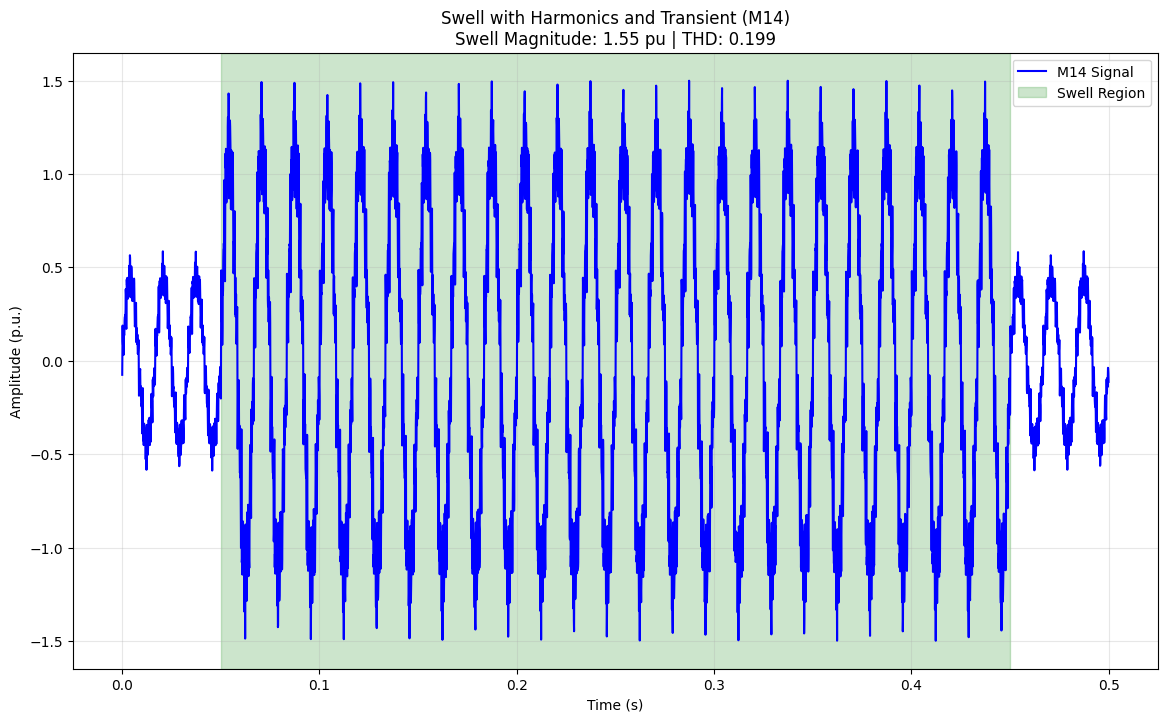

--- Generated Signal Parameters ---
Disturbance Type: Swell with Harmonics and Oscillatory Transient
Base Amplitude (p.u.): 1.0400
Base Frequency (Hz): 59.9936
Swell Magnitude (p.u.): 1.5459
Transient Freq (Hz): 1210.36
THD: 0.1989
Noise Level (%): 0.17


In [169]:
# @title 25.b. Class 25 - Swell with Harmonics and Oscillatory Transient (M14) Plotting
def plot_swell_with_harmonics_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M14 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Swell with Harmonics and Transient (M14)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SwellWithHarmonicsAndOscillatoryTransientGenerator()
signal, params = gen.generate()
plot_swell_with_harmonics_and_transient(signal, params)

In [111]:
# @title 25.c. Class 25 - Saving Swell with Harmonics and Oscillatory Transient (M14) Signals

def save_swell_with_harmonics_and_transient_signals(num_signals=200):
    """Generate and save M14 signals to HDF5 file"""
    CLASS_NAME = 'Swell with Harmonics and Oscillatory Transient (M14)'
    CLASS_LABEL = 25
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'swell_with_harmonics_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SwellWithHarmonicsAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_swell_with_harmonics_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/25 Swell with Harmonics and Oscillatory Transient (M14)/swell_with_harmonics_and_transient_signals.h5


In [186]:
# @title 25.d. Class 25 - Swell with Harmonics and Oscillatory Transient (M14) Statistics

def analyze_swell_with_harmonics_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M14 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'swell_magnitude': [],
        'thd': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': [],
        'noise_level_percent': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                param_attrs = dict(params_group[sig_name].attrs)
                param_data['swell_magnitude'].append(params_group[f"{sig_name}_swell_params"].attrs.get('swell_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['transient_amplitude'].append(param_attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(param_attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(param_attrs.get('decay_constant', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
    plt.title("Class 25: Parameter Correlation")
    plt.show()
    return df.describe()

In [175]:
# @title 26.a. Class 26 - Harmonics with Sag and Oscillatory Transient (M15) Generation

class HarmonicsWithSagAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Sag and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        combined_signal = (sag_envelope * harmonics_signal) + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'sag_params': sag_params,
            'harmonics_params': harmonics_params,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

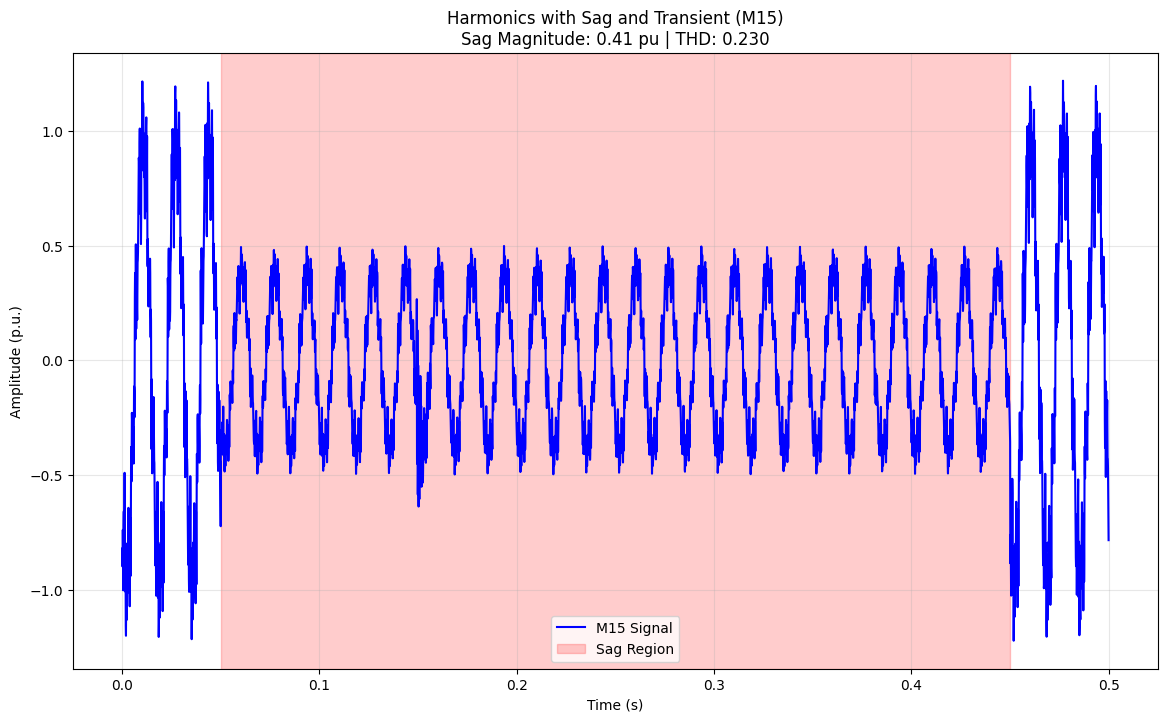

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Sag and Oscillatory Transient
Base Amplitude (p.u.): 0.9605
Base Frequency (Hz): 60.0017
Sag Magnitude (p.u.): 0.4072
Transient Freq (Hz): 2677.87
THD: 0.2296
Noise Level (%): 0.32


In [156]:
# @title 26.b Class 26 - Harmonics with Sag and Oscillatory Transient (M15) Plotting
def plot_harmonics_with_sag_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M15 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Sag and Transient (M15)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSagAndOscillatoryTransientGenerator()
sig_m15, par_m15 = gen_m15.generate()
plot_harmonics_with_sag_and_transient(sig_m15, par_m15)

In [115]:
# @title 26.c. Class 26 - Saving Harmonics with Sag and Oscillatory Transient (M15) Signals

def save_harmonics_with_sag_and_transient_signals(num_signals=200):
    """Generate and save M15 signals to HDF5 file"""
    CLASS_NAME = 'Harmonics with Sag and Oscillatory Transient (M15)'
    CLASS_LABEL = 26
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_sag_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSagAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_harmonics_with_sag_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/26 Harmonics with Sag and Oscillatory Transient (M15)/harmonics_with_sag_and_transient_signals.h5


In [180]:
# @title 26.d. Class 26 - Harmonics with Sag and Oscillatory Transient (M15) Statistics

def analyze_harmonics_with_sag_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M15 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'sag_magnitude': [],
        'thd': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': [],
        'noise_level_percent': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                param_attrs = dict(params_group[sig_name].attrs)
                param_data['sag_magnitude'].append(params_group[f"{sig_name}_sag_params"].attrs.get('sag_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['transient_amplitude'].append(param_attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(param_attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(param_attrs.get('decay_constant', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
    plt.title("Class 26: Parameter Correlation")
    plt.show()
    return df.describe()

In [187]:
# @title 27.a. Class 27 - Harmonics with Swell and Oscillatory Transient (M16) Generation

class HarmonicsWithSwellAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Swell and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        _, swell_params = swell_gen.generate()

        t1, t2 = swell_params['swell_start_time'], swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = swell_params['swell_magnitude']

        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        combined_signal = (swell_envelope * harmonics_signal) + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

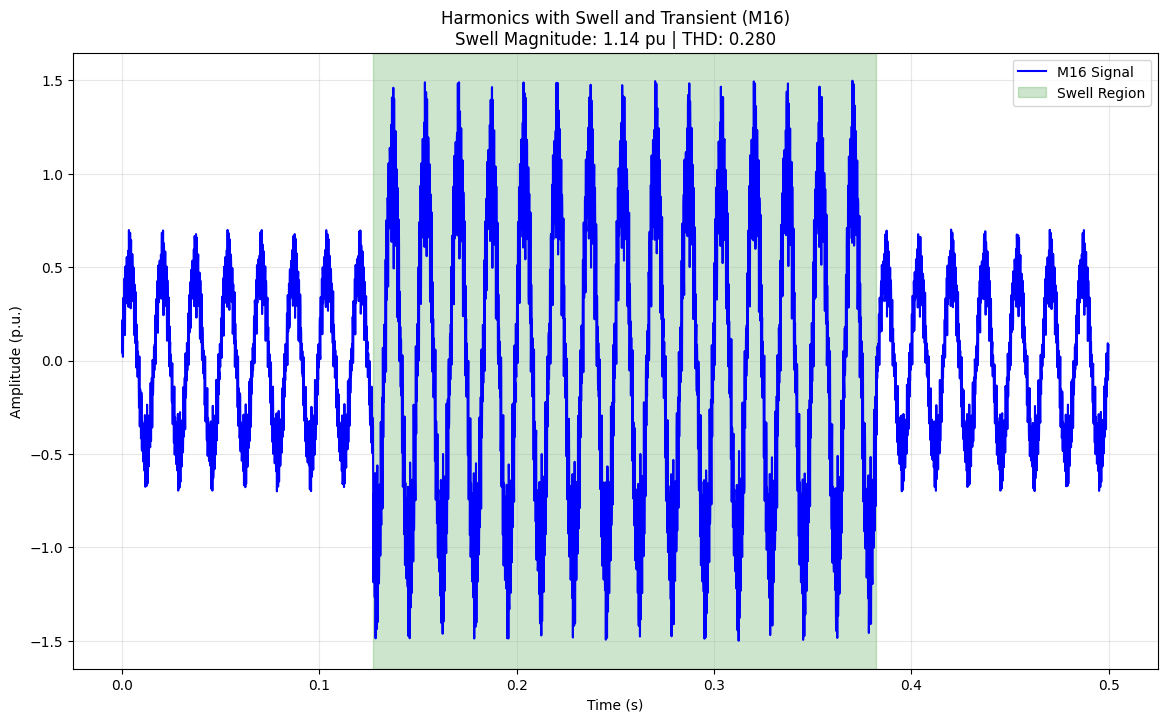

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Swell and Oscillatory Transient
Base Amplitude (p.u.): 0.9719
Base Frequency (Hz): 60.0012
Swell Magnitude (p.u.): 1.1409
Transient Freq (Hz): 3094.26
THD: 0.2796
Noise Level (%): 0.44


In [170]:
# @title 27.b. Class 27 - Harmonics with Swell and Oscillatory Transient (M16) Plotting
def plot_harmonics_with_swell_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M16 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Swell and Transient (M16)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSwellAndOscillatoryTransientGenerator()
signal, params = gen.generate()
plot_harmonics_with_swell_and_transient(signal, params)

In [119]:
# @title 27.c. Class 27 - Saving Harmonics with Swell and Oscillatory Transient (M16) Signals

def save_harmonics_with_swell_and_transient_signals(num_signals=200):
    """Generate and save M16 signals to HDF5 file"""
    CLASS_NAME = 'Harmonics with Swell and Oscillatory Transient (M16)'
    CLASS_LABEL = 27
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_swell_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSwellAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_harmonics_with_swell_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/27 Harmonics with Swell and Oscillatory Transient (M16)/harmonics_with_swell_and_transient_signals.h5


In [188]:
# @title 27.d. Class 27 - Harmonics with Swell and Oscillatory Transient (M16) Statistics

def analyze_harmonics_with_swell_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M16 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'swell_magnitude': [],
        'thd': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': [],
        'noise_level_percent': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                param_attrs = dict(params_group[sig_name].attrs)
                param_data['swell_magnitude'].append(params_group[f"{sig_name}_swell_params"].attrs.get('swell_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['transient_amplitude'].append(param_attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(param_attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(param_attrs.get('decay_constant', np.nan))
                param_data['noise_level_percent'].append(param_attrs.get('noise_level_percent', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1.0, vmax=1.0)
    plt.title("Class 27: Parameter Correlation")
    plt.show()
    return df.describe()

In [177]:
# @title 28.a. Class 28 - Harmonics with Sag, Flicker, and Oscillatory Transient (M17) Generation

class HarmonicsWithSagFlickerAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Sag, Flicker, and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        flicker_amp = random.uniform(0.1, 0.5)
        flicker_freq = random.uniform(5, 30)
        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        flicker_component = flicker_amp * np.sin(2 * np.pi * flicker_freq * self.time)
        combined_signal = (sag_envelope * harmonics_signal) + flicker_component + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'sag_params': sag_params,
            'harmonics_params': harmonics_params,
            'flicker_amplitude': flicker_amp,
            'flicker_frequency': flicker_freq,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

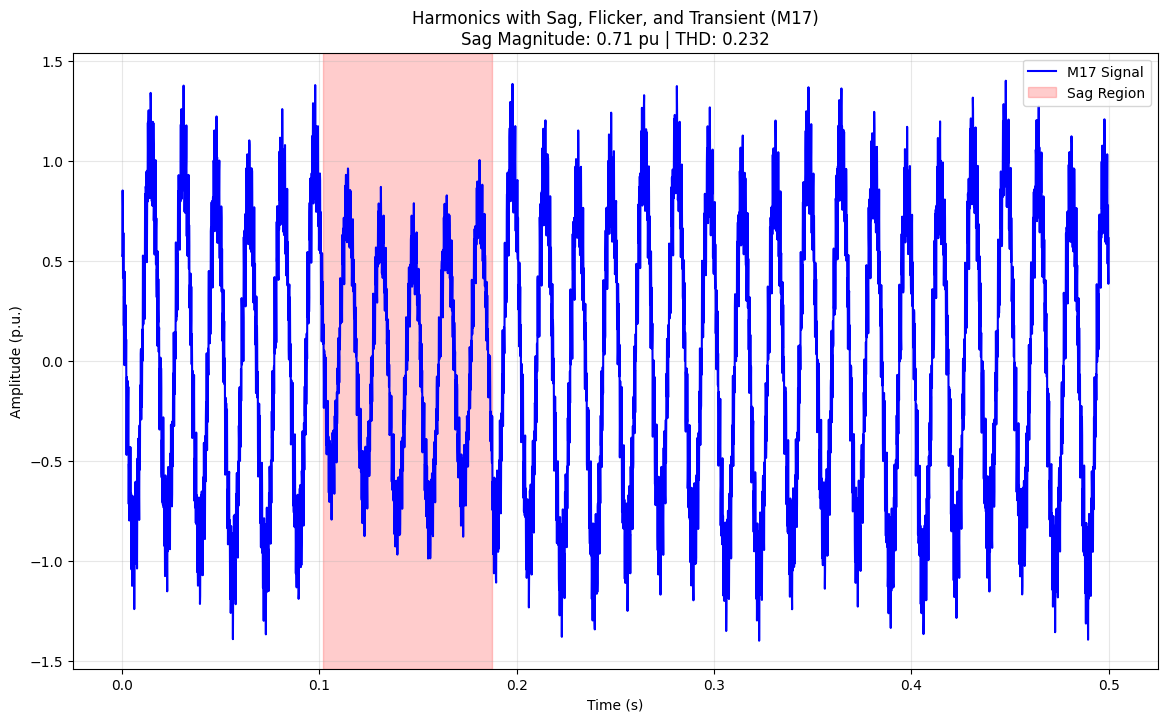

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Sag, Flicker, and Oscillatory Transient
Base Amplitude (p.u.): 0.9697
Base Frequency (Hz): 60.0051
Sag Magnitude (p.u.): 0.7114
Flicker Amp (p.u.): 0.1208
Transient Freq (Hz): 4876.60
THD: 0.2322
Noise Level (%): 0.38


In [157]:
# @title 28.b Class 28 - Harmonics with Sag, Flicker, and Oscillatory Transient (M17) Plotting
def plot_harmonics_with_sag_flicker_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M17 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Sag, Flicker, and Transient (M17)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Flicker Amp (p.u.): {params.get('flicker_amplitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSagFlickerAndOscillatoryTransientGenerator()
sig_m17, par_m17 = gen_m17.generate()
plot_harmonics_with_sag_flicker_and_transient(sig_m17, par_m17)

In [123]:
# @title 28.c. Class 28 - Saving Harmonics with Sag, Flicker, and Oscillatory Transient (M17) Signals

def save_harmonics_with_sag_flicker_and_transient_signals(num_signals=200):
    """Generate and save M17 signals to HDF5 file"""
    CLASS_NAME = 'Harmonics with Sag, Flicker, and Oscillatory Transient (M17)'
    CLASS_LABEL = 28
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_sag_flicker_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSagFlickerAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_harmonics_with_sag_flicker_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/28 Harmonics with Sag, Flicker, and Oscillatory Transient (M17)/harmonics_with_sag_flicker_and_transient_signals.h5


In [181]:
# @title 28.d. Class 28 - Harmonics with Sag, Flicker, and Oscillatory Transient (M17) Statistics

def analyze_harmonics_with_sag_flicker_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M17 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'sag_magnitude': [],
        'thd': [],
        'flicker_amplitude': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                attrs = dict(params_group[sig_name].attrs)
                param_data['sag_magnitude'].append(params_group[f"{sig_name}_sag_params"].attrs.get('sag_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['flicker_amplitude'].append(attrs.get('flicker_amplitude', np.nan))
                param_data['transient_amplitude'].append(attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(attrs.get('decay_constant', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Class 28: Parameter Correlation")
    plt.show()
    return df.describe()

In [189]:
# @title 29.a. Class 29 - Harmonics with Swell, Flicker, and Oscillatory Transient (M18) Generation

class HarmonicsWithSwellFlickerAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Harmonics with Swell, Flicker, and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        _, swell_params = swell_gen.generate()

        t1, t2 = swell_params['swell_start_time'], swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = swell_params['swell_magnitude']

        flicker_amp = random.uniform(0.1, 0.5)
        flicker_freq = random.uniform(5, 30)
        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        flicker_component = flicker_amp * np.sin(2 * np.pi * flicker_freq * self.time)
        combined_signal = (swell_envelope * harmonics_signal) + flicker_component + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'flicker_amplitude': flicker_amp,
            'flicker_frequency': flicker_freq,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

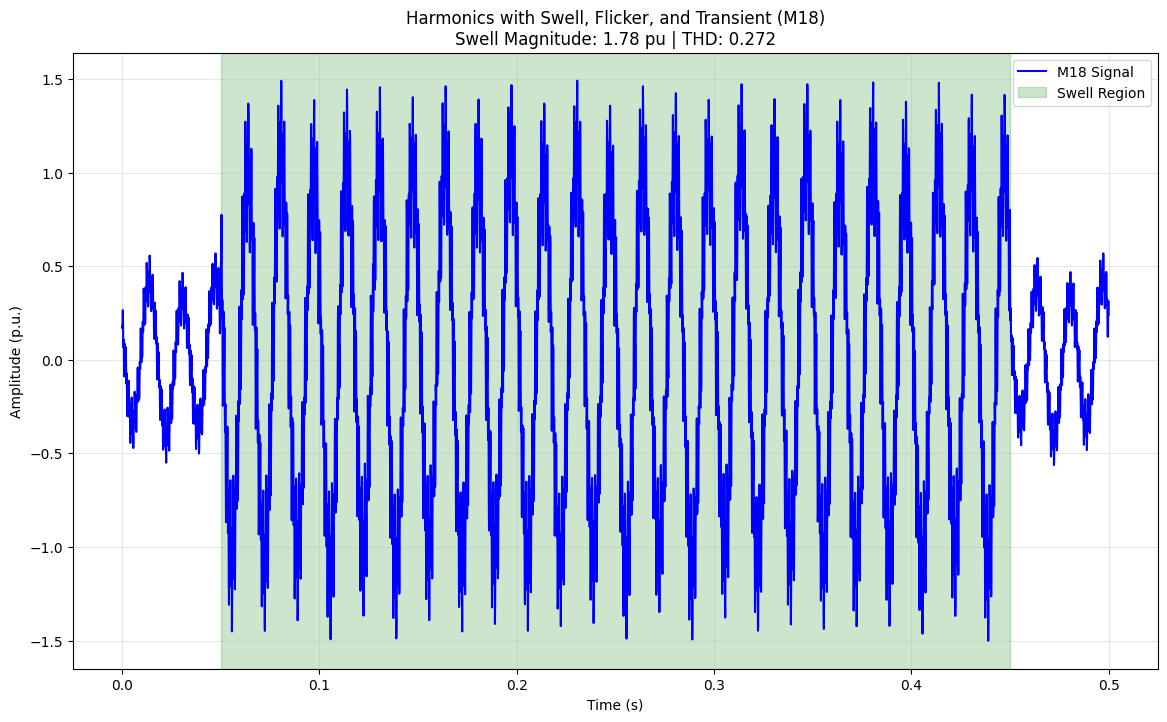

--- Generated Signal Parameters ---
Disturbance Type: Harmonics with Swell, Flicker, and Oscillatory Transient
Base Amplitude (p.u.): 1.0369
Base Frequency (Hz): 59.9901
Swell Magnitude (p.u.): 1.7810
Flicker Amp (p.u.): 0.1541
Transient Freq (Hz): 3077.25
THD: 0.2724
Noise Level (%): 0.82


In [171]:
# @title 29.b. Class 29 - Harmonics with Swell, Flicker, and Oscillatory Transient (M18) Plotting
def plot_harmonics_with_swell_flicker_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M18 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Harmonics with Swell, Flicker, and Transient (M18)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Flicker Amp (p.u.): {params.get('flicker_amplitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = HarmonicsWithSwellFlickerAndOscillatoryTransientGenerator()
signal, params = gen.generate()
plot_harmonics_with_swell_flicker_and_transient(signal, params)

In [127]:
# @title 29.c. Class 29 - Saving Harmonics with Swell, Flicker, and Oscillatory Transient (M18) Signals

def save_harmonics_with_swell_flicker_and_transient_signals(num_signals=200):
    """Generate and save M18 signals to HDF5 file"""
    CLASS_NAME = 'Harmonics with Swell, Flicker, and Oscillatory Transient (M18)'
    CLASS_LABEL = 29
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'harmonics_with_swell_flicker_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = HarmonicsWithSwellFlickerAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_harmonics_with_swell_flicker_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/29 Harmonics with Swell, Flicker, and Oscillatory Transient (M18)/harmonics_with_swell_flicker_and_transient_signals.h5


In [190]:
# @title 29.d. Class 29 - Harmonics with Swell, Flicker, and Oscillatory Transient (M18) Statistics

def analyze_harmonics_with_swell_flicker_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M18 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'swell_magnitude': [],
        'thd': [],
        'flicker_amplitude': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                attrs = dict(params_group[sig_name].attrs)
                param_data['swell_magnitude'].append(params_group[f"{sig_name}_swell_params"].attrs.get('swell_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['flicker_amplitude'].append(attrs.get('flicker_amplitude', np.nan))
                param_data['transient_amplitude'].append(attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(attrs.get('decay_constant', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Class 29: Parameter Correlation")
    plt.show()
    return df.describe()

In [178]:
# @title 30.a. Class 30 - Sag with Harmonics, Flicker, and Oscillatory Transient (M19) Generation

class SagWithHarmonicsFlickerAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Sag with Harmonics, Flicker, and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        sag_gen = SagGenerator(self.fs, self.f_nominal, self.t_signal)
        _, sag_params = sag_gen.generate()

        t1, t2 = sag_params['sag_start_time'], sag_params['sag_end_time']
        sag_envelope = np.ones_like(self.time)
        sag_region = (self.time >= t1) & (self.time <= t2)
        sag_envelope[sag_region] = sag_params['sag_magnitude']

        flicker_amp = random.uniform(0.1, 0.5)
        flicker_freq = random.uniform(5, 30)
        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        flicker_component = flicker_amp * np.sin(2 * np.pi * flicker_freq * self.time)
        combined_signal = (sag_envelope * harmonics_signal) + flicker_component + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'sag_params': sag_params,
            'harmonics_params': harmonics_params,
            'flicker_amplitude': flicker_amp,
            'flicker_frequency': flicker_freq,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

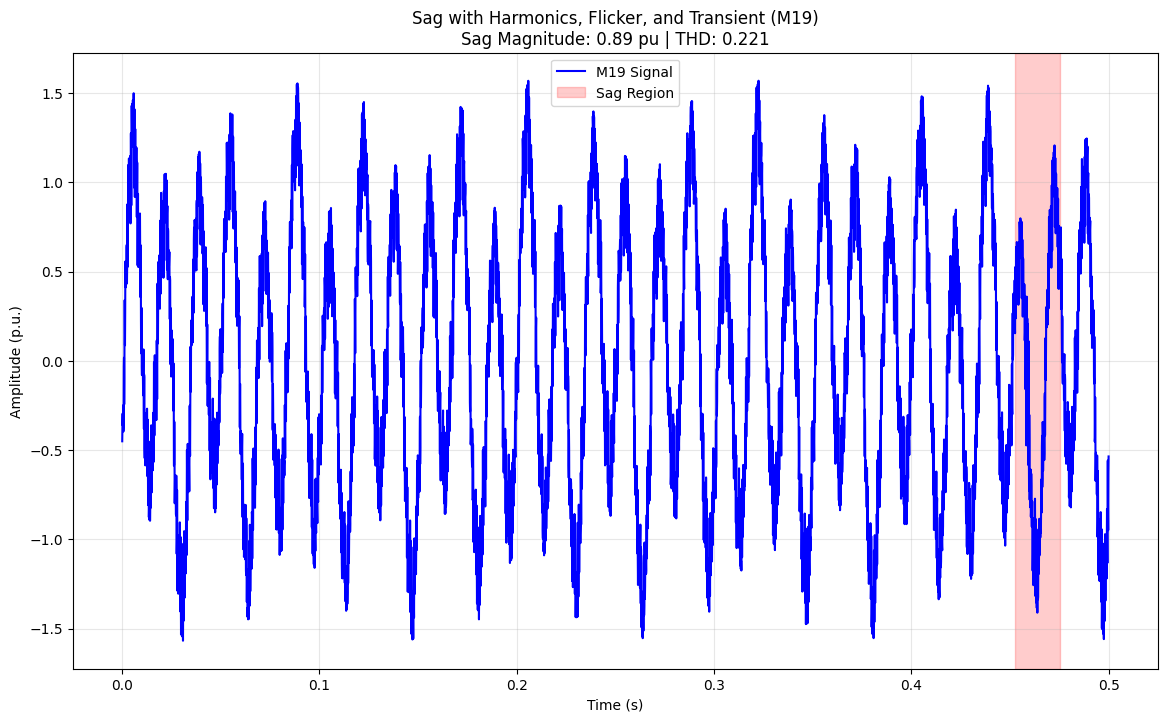

--- Generated Signal Parameters ---
Disturbance Type: Sag with Harmonics, Flicker, and Oscillatory Transient
Base Amplitude (p.u.): 0.9935
Base Frequency (Hz): 59.9961
Sag Magnitude (p.u.): 0.8881
Flicker Amp (p.u.): 0.3669
Transient Freq (Hz): 3068.63
THD: 0.2213
Noise Level (%): 0.58


In [158]:
# @title 30.b. Class 30 - Sag with Harmonics, Flicker, and Oscillatory Transient (M19) Plotting
def plot_sag_with_harmonics_flicker_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M19 Signal')
    sag_params = params.get('sag_params', {})
    t1, t2 = sag_params.get('sag_start_time', 0), sag_params.get('sag_end_time', 0)
    plt.axvspan(t1, t2, color='r', alpha=0.2, label='Sag Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Sag with Harmonics, Flicker, and Transient (M19)\nSag Magnitude: {sag_params.get('sag_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Sag Magnitude (p.u.): {sag_params.get('sag_magnitude', 0):.4f}")
    print(f"Flicker Amp (p.u.): {params.get('flicker_amplitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SagWithHarmonicsFlickerAndOscillatoryTransientGenerator()
sig_m19, par_m19 = gen_m19.generate()
plot_sag_with_harmonics_flicker_and_transient(sig_m19, par_m19)

In [131]:
# @title 30.c. Class 30- Saving Sag with Harmonics, Flicker, and Oscillatory Transient (M19) Signals

def save_sag_with_harmonics_flicker_and_transient_signals(num_signals=200):
    """Generate and save M19 signals to HDF5 file"""
    CLASS_NAME = 'Sag with Harmonics, Flicker, and Oscillatory Transient (M19)'
    CLASS_LABEL = 30
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'sag_with_harmonics_flicker_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SagWithHarmonicsFlickerAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['sag_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_sag_with_harmonics_flicker_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/30 Sag with Harmonics, Flicker, and Oscillatory Transient (M19)/sag_with_harmonics_flicker_and_transient_signals.h5


In [182]:
# @title 30.d. Class 30 - Sag with Harmonics, Flicker, and Oscillatory Transient (M19) Statistics

def analyze_sag_with_harmonics_flicker_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M19 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'sag_magnitude': [],
        'thd': [],
        'flicker_amplitude': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                attrs = dict(params_group[sig_name].attrs)
                param_data['sag_magnitude'].append(params_group[f"{sig_name}_sag_params"].attrs.get('sag_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['flicker_amplitude'].append(attrs.get('flicker_amplitude', np.nan))
                param_data['transient_amplitude'].append(attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(attrs.get('decay_constant', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Class 30: Parameter Correlation")
    plt.show()
    return df.describe()

In [191]:
# @title 31.a. Class 31 - Swell with Harmonics, Flicker, and Oscillatory Transient (M20) Generation

class SwellWithHarmonicsFlickerAndOscillatoryTransientGenerator(PQDBaseGenerator):
    def __init__(self, fs=FS_DEFAULT, f_nominal=F_NOMINAL, t_signal=T_SIGNAL_DEFAULT):
        super().__init__(fs, f_nominal, t_signal)
        self.params['disturbance_type'] = 'Swell with Harmonics, Flicker, and Oscillatory Transient'

    def generate(self):
        harmonics_gen = HarmonicsGenerator(self.fs, self.f_nominal, self.t_signal)
        harmonics_signal, harmonics_params = harmonics_gen.generate()

        swell_gen = SwellGenerator(self.fs, self.f_nominal, self.t_signal)
        _, swell_params = swell_gen.generate()

        t1, t2 = swell_params['swell_start_time'], swell_params['swell_end_time']
        swell_envelope = np.ones_like(self.time)
        swell_region = (self.time >= t1) & (self.time <= t2)
        swell_envelope[swell_region] = swell_params['swell_magnitude']

        flicker_amp = random.uniform(0.1, 0.5)
        flicker_freq = random.uniform(5, 30)
        transient_amp = random.uniform(0.1, 0.5)
        transient_freq = random.uniform(300, 5000)
        decay_constant = random.uniform(0.0005, 0.003)
        transient_start = random.uniform(t1 + 0.001, t2 - 0.001)

        transient_time = self.time - transient_start
        transient_component = np.zeros_like(self.time)
        mask = transient_time >= 0
        transient_component[mask] = transient_amp * np.exp(-transient_time[mask]/decay_constant) * np.sin(2 * np.pi * transient_freq * transient_time[mask])

        flicker_component = flicker_amp * np.sin(2 * np.pi * flicker_freq * self.time)
        combined_signal = (swell_envelope * harmonics_signal) + flicker_component + transient_component

        final_signal = self._add_noise(combined_signal)
        self.params.update({
            'swell_params': swell_params,
            'harmonics_params': harmonics_params,
            'flicker_amplitude': flicker_amp,
            'flicker_frequency': flicker_freq,
            'transient_amplitude': transient_amp,
            'transient_frequency': transient_freq,
            'decay_constant': decay_constant,
            'transient_start_time': transient_start
        })

        return final_signal, self.params

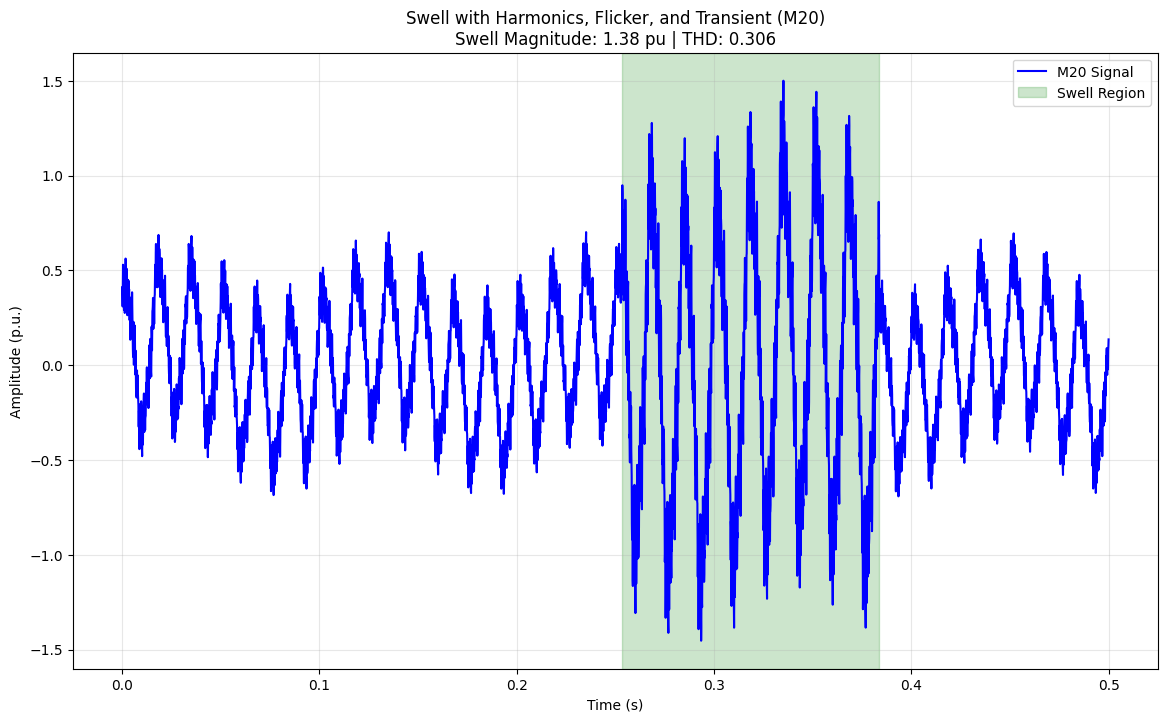

--- Generated Signal Parameters ---
Disturbance Type: Swell with Harmonics, Flicker, and Oscillatory Transient
Base Amplitude (p.u.): 1.0166
Base Frequency (Hz): 59.9988
Swell Magnitude (p.u.): 1.3755
Flicker Amp (p.u.): 0.3643
Transient Freq (Hz): 4005.98
THD: 0.3062
Noise Level (%): 0.05


In [172]:
# @title 31.b. Class 31 - Swell with Harmonics, Flicker, and Oscillatory Transient (M20) Plotting
def plot_swell_with_harmonics_flicker_and_transient(signal, params):
    fig = plt.figure(figsize=(14, 8), dpi=100)
    t = np.linspace(0, params['t_signal'], len(signal))
    plt.plot(t, signal, 'b-', linewidth=1.5, label='M20 Signal')
    swell_params = params.get('swell_params', {})
    t1, t2 = swell_params.get('swell_start_time', 0), swell_params.get('swell_end_time', 0)
    plt.axvspan(t1, t2, color='g', alpha=0.2, label='Swell Region')
    thd = params['harmonics_params'].get('thd', np.nan)
    plt.title(f"Swell with Harmonics, Flicker, and Transient (M20)\nSwell Magnitude: {swell_params.get('swell_magnitude', 0):.2f} pu | THD: {thd:.3f}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude (p.u.)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print("--- Generated Signal Parameters ---")
    print(f"Disturbance Type: {params['disturbance_type']}")
    print(f"Base Amplitude (p.u.): {params['base_amplitude']:.4f}")
    print(f"Base Frequency (Hz): {params['base_frequency']:.4f}")
    print(f"Swell Magnitude (p.u.): {swell_params.get('swell_magnitude', 0):.4f}")
    print(f"Flicker Amp (p.u.): {params.get('flicker_amplitude', 0):.4f}")
    print(f"Transient Freq (Hz): {params.get('transient_frequency', 0):.2f}")
    print(f"THD: {thd:.4f}")
    print(f"Noise Level (%): {params['noise_level_percent']:.2f}")

gen = SwellWithHarmonicsFlickerAndOscillatoryTransientGenerator()
signal, params = gen.generate()
plot_swell_with_harmonics_flicker_and_transient(signal, params)

In [135]:
# @title 31.c. Class 31 - Saving Swell with Harmonics, Flicker, and Oscillatory Transient (M20) Signals

def save_swell_with_harmonics_flicker_and_transient_signals(num_signals=200):
    """Generate and save M20 signals to HDF5 file"""
    CLASS_NAME = 'Swell with Harmonics, Flicker, and Oscillatory Transient (M20)'
    CLASS_LABEL = 31
    CLASS_FOLDER = f"{CLASS_LABEL} {CLASS_NAME}"

    CLASS_PATH = os.path.join(DATASET_FULL_PATH, CLASS_FOLDER)
    os.makedirs(CLASS_PATH, exist_ok=True)

    hdf5_path = os.path.join(CLASS_PATH, 'swell_with_harmonics_flicker_and_transient_signals.h5')

    try:
        with h5py.File(hdf5_path, 'w') as f:
            # Signals dataset
            num_samples = int(T_SIGNAL_DEFAULT * FS_DEFAULT)
            signals_dset = f.create_dataset('signals',
                                          shape=(0, num_samples),
                                          maxshape=(None, num_samples),
                                          dtype=np.float32,
                                          compression="gzip")

            # Parameters group
            params_group = f.create_group('parameters')

            for i in range(num_signals):
                gen = SwellWithHarmonicsFlickerAndOscillatoryTransientGenerator()
                signal, params = gen.generate()

                # Store signal
                signals_dset.resize(signals_dset.shape[0] + 1, axis=0)
                signals_dset[-1] = signal

                # Store parameters
                param_dset = params_group.create_dataset(f'signal_{i+1:04d}', data=np.array([]))
                param_dset.attrs['class_label'] = CLASS_LABEL
                param_dset.attrs['disturbance_type'] = CLASS_NAME

                # Store all parameters
                for key, value in params.items():
                    if key in ['swell_params', 'harmonics_params']:
                        subgroup = params_group.create_group(f'{param_dset.name}_{key}')
                        for subkey, subvalue in value.items():
                            subgroup.attrs[subkey] = subvalue
                    else:
                        param_dset.attrs[key] = value

            # Metadata
            f.attrs.update({
                'num_signals': num_signals,
                'sample_rate': FS_DEFAULT,
                'signal_duration': T_SIGNAL_DEFAULT,
                'nominal_frequency': F_NOMINAL,
                'dataset_version': '1.0'
            })

        print(f"✅ Saved {num_signals} signals to {hdf5_path}")
        return hdf5_path

    except Exception as e:
        print(f"❌ Error during saving: {str(e)}")
        return None

# Execute saving
hdf5_path = save_swell_with_harmonics_flicker_and_transient_signals(num_signals=200)


✅ Saved 200 signals to /content/drive/MyDrive/PQD_Synthetic_Dataset/31 Swell with Harmonics, Flicker, and Oscillatory Transient (M20)/swell_with_harmonics_flicker_and_transient_signals.h5


In [192]:
# @title 31.d. Class 31 - Swell with Harmonics, Flicker, and Oscillatory Transient (M20) Statistics

def analyze_swell_with_harmonics_flicker_and_transient_stats(hdf5_path):
    """Perform statistical analysis for M20 signals"""
    if not os.path.exists(hdf5_path):
        print(f"❌ File not found: {hdf5_path}")
        return None

    param_data = {
        'swell_magnitude': [],
        'thd': [],
        'flicker_amplitude': [],
        'transient_amplitude': [],
        'transient_frequency': [],
        'decay_constant': []
    }

    try:
        with h5py.File(hdf5_path, 'r') as f:
            params_group = f['parameters']
            for sig_name in [k for k in params_group.keys() if k.startswith('signal_')]:
                attrs = dict(params_group[sig_name].attrs)
                param_data['swell_magnitude'].append(params_group[f"{sig_name}_swell_params"].attrs.get('swell_magnitude', np.nan))
                param_data['thd'].append(params_group[f"{sig_name}_harmonics_params"].attrs.get('thd', np.nan))
                param_data['flicker_amplitude'].append(attrs.get('flicker_amplitude', np.nan))
                param_data['transient_amplitude'].append(attrs.get('transient_amplitude', np.nan))
                param_data['transient_frequency'].append(attrs.get('transient_frequency', np.nan))
                param_data['decay_constant'].append(attrs.get('decay_constant', np.nan))
    except Exception as e:
        print(f"❌ Error: {str(e)}")
        return None

    df = pd.DataFrame(param_data)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Class 31: Parameter Correlation")
    plt.show()
    return df.describe()

In [137]:
# @title Block 3: Saving all 31 classes for ML
import os, h5py, json

manager = PQDMultiManager()
database_path = os.path.join(DATASET_FULL_PATH, 'PQD_Unified_Dataset.h5')

with h5py.File(database_path, 'w') as hf_db:
    for class_id in range(31):
        print(f"Generating Class {class_id}...")

        # Generate the signals and metadata list
        signals, metadata_list = manager.generate_class(class_id, count=1000)

        # Save to HDF5 Group
        group = hf_db.create_group(f'Class_{class_id}')
        group.create_dataset('signals', data=signals, compression="gzip")

        # Save metadata as a single JSON string attribute
        group.attrs['metadata'] = json.dumps(metadata_list)

print(f"Success! Unified database created at: {database_path}")

Generating Class 0...
Generating Class 1...
Generating Class 2...
Generating Class 3...
Generating Class 4...
Generating Class 5...
Generating Class 6...
Generating Class 7...
Generating Class 8...
Generating Class 9...
Generating Class 10...
Generating Class 11...
Generating Class 12...
Generating Class 13...
Generating Class 14...
Generating Class 15...
Generating Class 16...
Generating Class 17...
Generating Class 18...
Generating Class 19...
Generating Class 20...
Generating Class 21...
Generating Class 22...
Generating Class 23...
Generating Class 24...
Generating Class 25...
Generating Class 26...
Generating Class 27...
Generating Class 28...
Generating Class 29...
Generating Class 30...
Success! Unified database created at: /content/drive/MyDrive/PQD_Synthetic_Dataset/PQD_Unified_Dataset.h5


In [138]:
# @title Block 4: Pandas Dataset Analysis
import pandas as pd

summary = []
with h5py.File(database_path, 'r') as hf:
    for class_key in hf.keys():
        group = hf[class_key]
        metadata = json.loads(group.attrs['metadata'])

        summary.append({
            'Class': class_key,
            'Label': metadata[0]['disturbance_type'],
            'Samples': group['signals'].shape[0],
            'Avg_Noise (%)': np.mean([m['noise_level_percent'] for m in metadata])
        })

df = pd.DataFrame(summary)
print(df.to_string(index=False))

   Class                                                    Label  Samples  Avg_Noise (%)
 Class_0                                       Operational Signal     1000       0.496819
 Class_1                                                      Sag     1000       0.507211
Class_10                                                DC Offset     1000       0.499123
Class_11                                       Harmonics with Sag     1000       0.489940
Class_12                                     Harmonics with Swell     1000       0.513315
Class_13                                         Flicker with Sag     1000       0.500630
Class_14                                       Flicker with Swell     1000       0.489786
Class_15                           Sag with Oscillatory Transient     1000       0.506437
Class_16                         Swell with Oscillatory Transient     1000       0.493387
Class_17                                       Sag with Harmonics     1000       0.508978
Class_18  

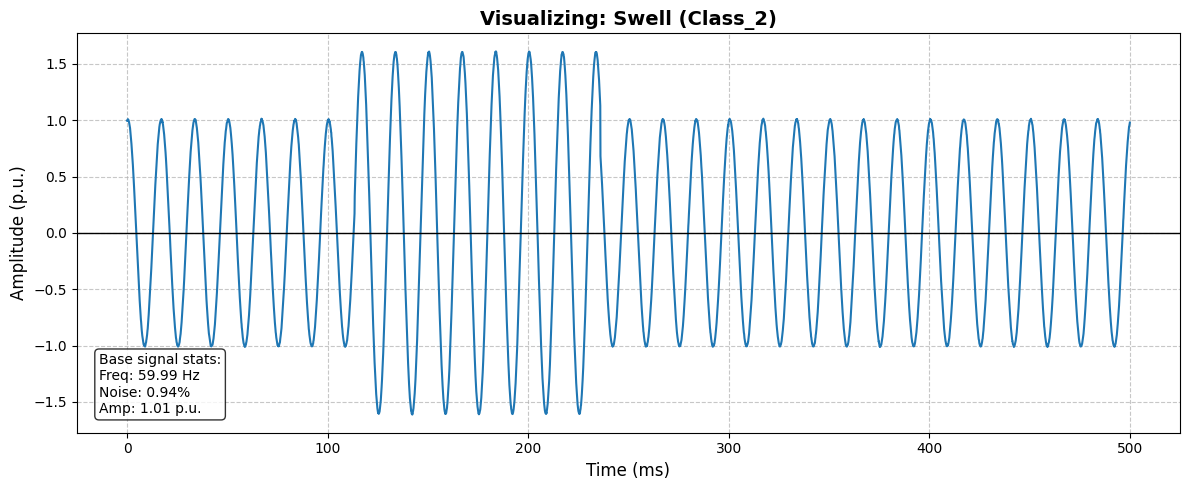

--- Metadata for Signal 91 in Class_2 ---
fs: 10000
f_nominal: 60
t_signal: 0.5
base_amplitude: 1.0062569828977803
base_frequency: 59.99176194002127
base_phase: 1.4069872471767164
disturbance_type: Swell
noise_level_percent: 0.9406865870156966
swell_magnitude: 1.5939784988243568
swell_start_time: 0.1134380228081176
swell_end_time: 0.2359981121323449
swell_duration_sec: 0.1225600893242273
swell_duration_cycles: 7.3536053594536375
noise_amplitude_pu: 0.009406865870156966
snr_db: 48.61636287893381


In [139]:
# @title Block 5:🔍 PQD Signal Explorer with Plotting

# --- CONFIGURATION ---
# Set to None for a random class, or set to a number (0-30) for a specific class
target_class_id = None

# Path to your database
database_path = os.path.join(DATASET_FULL_PATH, 'PQD_Unified_Dataset.h5')

# --- VISUALIZATION LOGIC ---
with h5py.File(database_path, 'r') as hf:
    # 1. Select the class
    if target_class_id is None:
        class_key = random.choice(list(hf.keys()))
    else:
        class_key = f'Class_{target_class_id}'

    group = hf[class_key]
    signals = group['signals']
    metadata_list = json.loads(group.attrs['metadata'])

    # 2. Pick a random signal within that class
    idx = random.randint(0, len(signals) - 1)
    signal = signals[idx]
    meta = metadata_list[idx]

    # 3. Prepare Time Axis (in milliseconds for better readability)
    fs = meta['fs']
    t_signal = meta['t_signal']
    time = np.linspace(0, t_signal * 1000, len(signal)) # Convert to ms

    # 4. Plotting
    plt.figure(figsize=(12, 5))
    plt.plot(time, signal, color='#1f77b4', linewidth=1.5, label='Synthetic Signal')

    # Visual cues for disturbances
    plt.title(f"Visualizing: {meta['disturbance_type']} ({class_key})", fontsize=14, fontweight='bold')
    plt.xlabel("Time (ms)", fontsize=12)
    plt.ylabel("Amplitude (p.u.)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.axhline(0, color='black', linewidth=1)

    # Display key parameters on the plot
    info_text = (f"Base signal stats:\n"
                 f"Freq: {meta['base_frequency']:.2f} Hz\n"
                 f"Noise: {meta.get('noise_level_percent', 0):.2f}%\n"
                 f"Amp: {meta.get('base_amplitude', 1.0):.2f} p.u.")
    plt.annotate(info_text, xy=(0.02, 0.05), xycoords='axes fraction',
                 bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

    # 5. Print full metadata for debugging
    print(f"--- Metadata for Signal {idx} in {class_key} ---")
    for key, value in meta.items():
        print(f"{key}: {value}")

In [140]:
# @title [ANALYSIS] Block 1: Master Configuration & Setup

# --- General Configuration ---
DATASET_PATH = "/content/drive/MyDrive/PQD_Synthetic_Dataset"
NUM_SAMPLES_PER_CLASS = 200
RANDOM_STATE = 42
F_NOMINAL = 60.0

# --- Master Class Definitions ---
FULL_CLASS_ORDER = [
    'Operational Signal', 'Sag', 'Swell', 'Interruption', 'Impulsive Transient',
    'Oscillatory Transient', 'Flicker', 'Notch', 'Harmonics', 'Interharmonics', 'DC Offset',
    'Harmonics with Sag (M1)', 'Harmonics with Swell (M2)', 'Flicker with Sag (M3)',
    'Flicker with Swell (M4)', 'Sag with Oscillatory Transient (M5)',
    'Swell with Oscillatory Transient (M6)', 'Sag with Harmonics (M7)',
    'Swell with Harmonics (M8)', 'Harmonics with Sag and Flicker (M9)',
    'Harmonics with Swell and Flicker (M10)', 'Sag with Harmonics and Flicker (M11)',
    'Swell with Harmonics and Flicker (M12)',
    'Sag with Harmonics and Oscillatory Transient (M13)',
    'Swell with Harmonics and Oscillatory Transient (M14)',
    'Harmonics with Sag and Oscillatory Transient (M15)',
    'Harmonics with Swell and Oscillatory Transient (M16)',
    'Harmonics with Sag, Flicker, and Oscillatory Transient (M17)',
    'Harmonics with Swell, Flicker, and Oscillatory Transient (M18)',
    'Sag with Harmonics, Flicker, and Oscillatory Transient (M19)',
    'Swell with Harmonics, Flicker, and Oscillatory Transient (M20)'
]

# --- Master Color and Marker Definitions ---
distinct_colors = list(mcolors.TABLEAU_COLORS.values()) + ['#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#ff9896', '#9467bd', '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5', '#aec7e8', '#ffbb78', '#98df8a', '#d62728']
CLASS_COLORS = {class_name: color for class_name, color in zip(FULL_CLASS_ORDER, distinct_colors)}
INDIVIDUAL_CLASSES_SET = set(FULL_CLASS_ORDER[:11])
CLASS_MARKERS = {name: 'o' if name in INDIVIDUAL_CLASSES_SET else 's' for name in FULL_CLASS_ORDER}

# --- Master Class-to-File Mapping ---
CLASS_INFO = {
    1: {'name': 'Operational Signal', 'file': 'operational_signals.h5'},
    2: {'name': 'Sag', 'file': 'sag_signals.h5'},
    3: {'name': 'Swell', 'file': 'swell_signals.h5'},
    4: {'name': 'Interruption', 'file': 'interruption_signals.h5'},
    5: {'name': 'Impulsive Transient', 'file': 'impulsive_transient_signals.h5'},
    6: {'name': 'Oscillatory Transient', 'file': 'oscillatory_transient_signals.h5'},
    7: {'name': 'Flicker', 'file': 'flicker_signals.h5'},
    8: {'name': 'Notch', 'file': 'notch_signals.h5'},
    9: {'name': 'Harmonics', 'file': 'harmonics_signals.h5'},
    10: {'name': 'Interharmonics', 'file': 'interharmonics_signals.h5'},
    11: {'name': 'DC Offset', 'file': 'dc_offset_signals.h5'},
    12: {'name': 'Harmonics with Sag (M1)', 'file': 'harmonics_with_sag_signals.h5'},
    13: {'name': 'Harmonics with Swell (M2)', 'file': 'harmonics_with_swell_signals.h5'},
    14: {'name': 'Flicker with Sag (M3)', 'file': 'flicker_with_sag_signals.h5'},
    15: {'name': 'Flicker with Swell (M4)', 'file': 'flicker_with_swell_signals.h5'},
    16: {'name': 'Sag with Oscillatory Transient (M5)', 'file': 'sag_with_osc_transient_signals.h5'},
    17: {'name': 'Swell with Oscillatory Transient (M6)', 'file': 'swell_with_osc_transient_signals.h5'},
    18: {'name': 'Sag with Harmonics (M7)', 'file': 'sag_with_harmonics_signals.h5'},
    19: {'name': 'Swell with Harmonics (M8)', 'file': 'swell_with_harmonics_signals.h5'},
    20: {'name': 'Harmonics with Sag and Flicker (M9)', 'file': 'harmonics_with_sag_and_flicker_signals.h5'},
    21: {'name': 'Harmonics with Swell and Flicker (M10)', 'file': 'harmonics_with_swell_and_flicker_signals.h5'},
    22: {'name': 'Sag with Harmonics and Flicker (M11)', 'file': 'sag_with_harmonics_and_flicker_signals.h5'},
    23: {'name': 'Swell with Harmonics and Flicker (M12)', 'file': 'swell_with_harmonics_and_flicker_signals.h5'},
    24: {'name': 'Sag with Harmonics and Oscillatory Transient (M13)', 'file': 'sag_with_harmonics_and_oscillatory_transient_signals.h5'},
    25: {'name': 'Swell with Harmonics and Oscillatory Transient (M14)', 'file': 'swell_with_harmonics_and_transient_signals.h5'},
    26: {'name': 'Harmonics with Sag and Oscillatory Transient (M15)', 'file': 'harmonics_with_sag_and_transient_signals.h5'},
    27: {'name': 'Harmonics with Swell and Oscillatory Transient (M16)', 'file': 'harmonics_with_swell_and_transient_signals.h5'},
    28: {'name': 'Harmonics with Sag, Flicker, and Oscillatory Transient (M17)', 'file': 'harmonics_with_sag_flicker_and_transient_signals.h5'},
    29: {'name': 'Harmonics with Swell, Flicker, and Oscillatory Transient (M18)', 'file': 'harmonics_with_swell_flicker_and_transient_signals.h5'},
    30: {'name': 'Sag with Harmonics, Flicker, and Oscillatory Transient (M19)', 'file': 'sag_with_harmonics_flicker_and_transient_signals.h5'},
    31: {'name': 'Swell with Harmonics, Flicker, and Oscillatory Transient (M20)', 'file': 'swell_with_harmonics_flicker_and_transient_signals.h5'}
}

print("✅ Master configuration loaded successfully!")

✅ Master configuration loaded successfully!


In [141]:
# @title [ANALYSIS] Block 2: Master Functions

def load_existing_signals(dataset_path, class_info_map, max_samples_per_class=200):
    """
    Loads signals and all associated parameters from HDF5 files,
    handling nested parameters cleanly.
    """
    # ... (This function is correct and does not need changes) ...
    all_params = []
    class_labels = []
    for class_label, class_data in class_info_map.items():
        class_folder = f"{class_label} {class_data['name']}"
        hdf5_path = os.path.join(dataset_path, class_folder, class_data['file'])
        if not os.path.exists(hdf5_path):
            print(f"⚠️  File not found: {hdf5_path}")
            continue
        try:
            with h5py.File(hdf5_path, 'r') as f:
                if 'parameters' not in f: continue
                params_group, signal_names = f['parameters'], [n for n in f['parameters'] if n.startswith('signal_')]
                num_signals = min(len(signal_names), max_samples_per_class)
                print(f"📁 Loading {num_signals} signals from {class_data['name']}")
                for i in range(num_signals):
                    param_key = f'signal_{i+1:04d}'
                    if param_key in params_group:
                        signal_params = dict(params_group[param_key].attrs)
                        for nested_key in ['sag_params', 'swell_params', 'harmonics_params']:
                            if f"{param_key}_{nested_key}" in params_group:
                                signal_params.update(dict(params_group[f"{param_key}_{nested_key}"].attrs))
                        all_params.append(signal_params)
                        class_labels.append(class_data['name'])
        except Exception as e:
            print(f"❌ Error loading {hdf5_path}: {str(e)}")
    return all_params, class_labels

def unify_data(df):
    """
    Takes the raw DataFrame and robustly unifies it into the standard analysis columns.
    This version includes the final fix for attribute errors.
    """
    print("\nUnifying raw data for consistent analysis...")
    df_unified = df.copy()

    def get_mean_from_json_list(value_str):
        if not isinstance(value_str, str): return np.nan
        try:
            value_list = json.loads(value_str)
            return np.mean(value_list) if value_list else np.nan
        except (json.JSONDecodeError, TypeError):
            return np.nan

    # --- Create intermediate columns with robust alias handling ---
    # **FINAL FIX**: This logic now safely handles cases where a column might not exist in the dataframe.

    # For Oscillatory Transient
    osc_mag = df_unified.get('osc_magnitude')
    transient_amp = df_unified.get('transient_amplitude')
    if osc_mag is not None and transient_amp is not None:
        df_unified['oscillatory_transient_mag'] = osc_mag.fillna(transient_amp)
    else:
        df_unified['oscillatory_transient_mag'] = osc_mag if osc_mag is not None else transient_amp

    # For Flicker
    mod_depth = df_unified.get('modulation_depth')
    flicker_depth = df_unified.get('flicker_depth')
    if mod_depth is not None and flicker_depth is not None:
        df_unified['unified_flicker_mag'] = mod_depth.fillna(flicker_depth)
    else:
        df_unified['unified_flicker_mag'] = mod_depth if mod_depth is not None else flicker_depth

    # For other complex parameters
    if 'harmonic_phases' in df_unified.columns: df_unified['harmonic_phase_proxy'] = df_unified['harmonic_phases'].apply(get_mean_from_json_list)
    if 'interharmonic_frequencies' in df_unified.columns: df_unified['interharmonic_freq_proxy'] = df_unified['interharmonic_frequencies'].apply(get_mean_from_json_list)
    if 'interharmonic_amplitudes' in df_unified.columns: df_unified['interharmonic_mag_proxy'] = df_unified['interharmonic_amplitudes'].apply(lambda s: max(json.loads(s)) if isinstance(s, str) and s != '[]' else np.nan)

    # --- Unify Magnitude ---
    magnitude_cols = ['sag_magnitude', 'swell_magnitude', 'interruption_magnitude', 'transient_magnitude', 'oscillatory_transient_mag', 'thd', 'unified_flicker_mag', 'interharmonic_mag_proxy', 'dc_offset', 'residual_voltage']
    df_unified['disturbance_magnitude'] = df_unified[[c for c in magnitude_cols if c in df_unified.columns]].bfill(axis=1).iloc[:, 0]

    # --- Unify Duration ---
    df_unified['transient_dur_cycles'] = df_unified.get('duration_sec', 0) * df_unified.get('base_frequency', F_NOMINAL)
    full_dur_cycles = df_unified.get('t_signal', 0.5) * df_unified.get('base_frequency', F_NOMINAL)
    df_unified['flicker_dur'] = np.where(df_unified.get('unified_flicker_mag', pd.Series()).notna(), full_dur_cycles, np.nan)
    df_unified['thd_dur'] = np.where(df_unified.get('thd', pd.Series()).notna(), full_dur_cycles, np.nan)
    duration_cols = ['sag_duration_cycles', 'swell_duration_cycles', 'interruption_duration_cycles', 'osc_cycles', 'transient_dur_cycles', 'flicker_dur', 'thd_dur', 'interharmonic_freq_proxy', 'base_phase', 'event_duration_cycles']
    df_unified['disturbance_duration'] = df_unified[[c for c in duration_cols if c in df_unified.columns]].bfill(axis=1).iloc[:, 0]

    df_unified.loc[df_unified['class'] == 'Operational Signal', ['disturbance_magnitude', 'disturbance_duration']] = 0

    # --- Select Final Columns and Clean Up ---
    final_cols = ['class', 'base_amplitude', 'base_frequency', 'base_phase', 'noise_level_percent', 'disturbance_magnitude', 'disturbance_duration']
    final_df = df_unified[[col for col in final_cols if col in df_unified.columns]].copy()

    null_rows = final_df[final_df.isnull().any(axis=1)]
    if not null_rows.empty:
        print("\n⚠️  The following classes have rows with missing data that will be dropped:")
        print(null_rows['class'].value_counts())

    final_df.dropna(inplace=True)
    return final_df

def run_correlation_analysis(df, path, title, filename):
    """Generates a correlation matrix for the given unified dataframe."""
    required_cols = ['base_amplitude', 'base_frequency', 'base_phase', 'noise_level_percent', 'disturbance_magnitude', 'disturbance_duration']
    corr = df[required_cols].corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", annot_kws={"size": 12})
    plt.title(title, fontsize=18)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(path, filename), dpi=300)
    plt.show()

def run_separability_analysis(df, path, title_prefix, filename_prefix, class_order, class_colors, class_markers):
    """Analyzes class separability using t-SNE."""
    features = ['base_amplitude', 'base_frequency', 'base_phase', 'noise_level_percent', 'disturbance_magnitude', 'disturbance_duration']
    X = df[features].fillna(0)
    y = df['class']
    X_scaled = StandardScaler().fit_transform(X)

    print("Running 3D t-SNE...")
    tsne_3d = TSNE(n_components=3, perplexity=30, random_state=RANDOM_STATE, n_iter=1000)
    X_tsne_3d = tsne_3d.fit_transform(X_scaled)

    fig_3d = plt.figure(figsize=(16, 12))
    ax_3d = fig_3d.add_subplot(111, projection='3d')
    for class_name in class_order:
        if class_name in y.unique():
            mask = (y == class_name)
            ax_3d.scatter(X_tsne_3d[mask, 0], X_tsne_3d[mask, 1], X_tsne_3d[mask, 2],
                          color=class_colors.get(class_name), marker=class_markers.get(class_name),
                          alpha=0.7, s=60, label=class_name)
    ax_3d.set_title(f'3D t-SNE of {title_prefix}', fontsize=18)
    legend1 = ax_3d.legend(title="Classes", loc='center left', bbox_to_anchor=(1.1, 0.5), fontsize=10)
    ax_3d.add_artist(legend1)
    if len(set(class_markers.values())) > 1: # Only add marker legend if there's more than one
        legend_elements = [Line2D([0], [0], marker='o', color='gray', label='Individual', linestyle='None', markersize=10),
                           Line2D([0], [0], marker='s', color='gray', label='Mixed', linestyle='None', markersize=10)]
        ax_3d.legend(handles=legend_elements, title="Group", loc='lower left', bbox_to_anchor=(1.1, 0.04))
    plt.savefig(os.path.join(path, f'{filename_prefix}_separability_3D.png'), dpi=300)
    plt.show()

    score = silhouette_score(X_scaled, pd.factorize(y)[0])
    print(f"Silhouette Score: {score:.3f} (Higher indicates better separation)")

--- Starting Global Analysis ---
📁 Loading 200 signals from Operational Signal
📁 Loading 200 signals from Sag
📁 Loading 200 signals from Swell
📁 Loading 200 signals from Interruption
📁 Loading 200 signals from Impulsive Transient
📁 Loading 200 signals from Oscillatory Transient
📁 Loading 200 signals from Flicker
📁 Loading 200 signals from Notch
📁 Loading 200 signals from Harmonics
📁 Loading 200 signals from Interharmonics
📁 Loading 200 signals from DC Offset
📁 Loading 200 signals from Harmonics with Sag (M1)
📁 Loading 200 signals from Harmonics with Swell (M2)
📁 Loading 200 signals from Flicker with Sag (M3)
📁 Loading 200 signals from Flicker with Swell (M4)
📁 Loading 200 signals from Sag with Oscillatory Transient (M5)
📁 Loading 200 signals from Swell with Oscillatory Transient (M6)
📁 Loading 200 signals from Sag with Harmonics (M7)
📁 Loading 200 signals from Swell with Harmonics (M8)
📁 Loading 200 signals from Harmonics with Sag and Flicker (M9)
📁 Loading 200 signals from Harmonics w

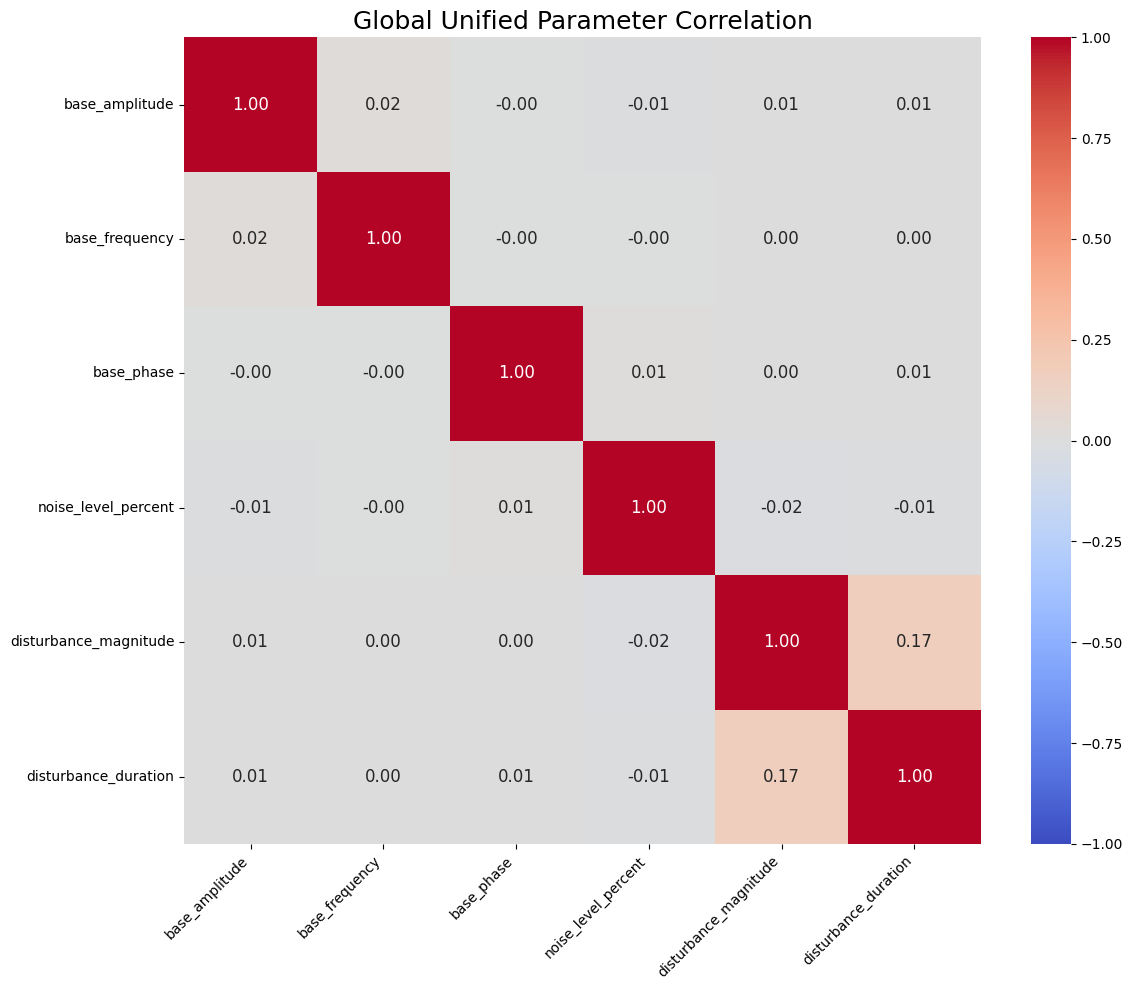

Running 3D t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


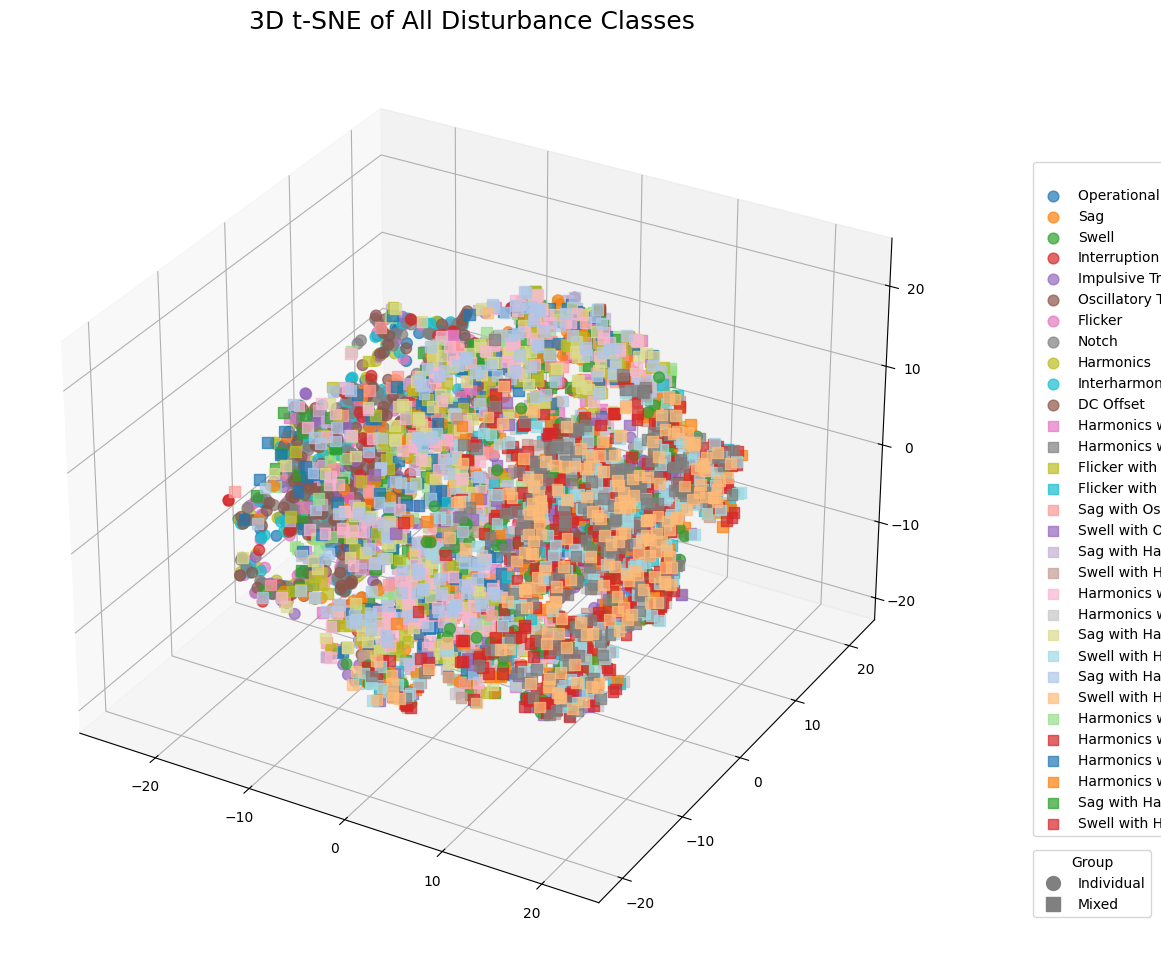

Silhouette Score: -0.036 (Higher indicates better separation)

🚀 Global analysis complete! Results saved to: /content/drive/MyDrive/PQD_Synthetic_Dataset/Global_Results


In [142]:
# @title Run GLOBAL Analysis (All Classes)

# 1. Define configuration for this specific analysis
ANALYSIS_TYPE = "Global"
OUTPUT_PATH = os.path.join(DATASET_PATH, "Global_Results")
CLASS_INFO_TO_LOAD = CLASS_INFO
CLASS_ORDER_FOR_PLOTS = FULL_CLASS_ORDER

# 2. Load and Unify Data
print(f"--- Starting {ANALYSIS_TYPE} Analysis ---")
raw_params, labels = load_existing_signals(DATASET_PATH, CLASS_INFO_TO_LOAD, NUM_SAMPLES_PER_CLASS)
raw_df = pd.DataFrame(raw_params)
raw_df['class'] = labels
unified_df = unify_data(raw_df)

# 3. Run Analyses
if not unified_df.empty:
    print(f"\n✅ Data unified. Proceeding with analysis on {len(unified_df)} samples.")
    run_correlation_analysis(unified_df, OUTPUT_PATH,
                             'Global Unified Parameter Correlation', 'GLOBAL_correlation.png')
    run_separability_analysis(unified_df, OUTPUT_PATH, 'All Disturbance Classes',
                              'GLOBAL', CLASS_ORDER_FOR_PLOTS, CLASS_COLORS, CLASS_MARKERS)
    print(f"\n🚀 {ANALYSIS_TYPE} analysis complete! Results saved to: {OUTPUT_PATH}")
else:
    print("\n❌ ANALYSIS HALTED: No data available after unification.")

--- Starting Individual Analysis ---
📁 Loading 200 signals from Operational Signal
📁 Loading 200 signals from Sag
📁 Loading 200 signals from Swell
📁 Loading 200 signals from Interruption
📁 Loading 200 signals from Impulsive Transient
📁 Loading 200 signals from Oscillatory Transient
📁 Loading 200 signals from Flicker
📁 Loading 200 signals from Notch
📁 Loading 200 signals from Harmonics
📁 Loading 200 signals from Interharmonics
📁 Loading 200 signals from DC Offset

Unifying raw data for consistent analysis...

✅ Data unified. Proceeding with analysis on 2200 samples.


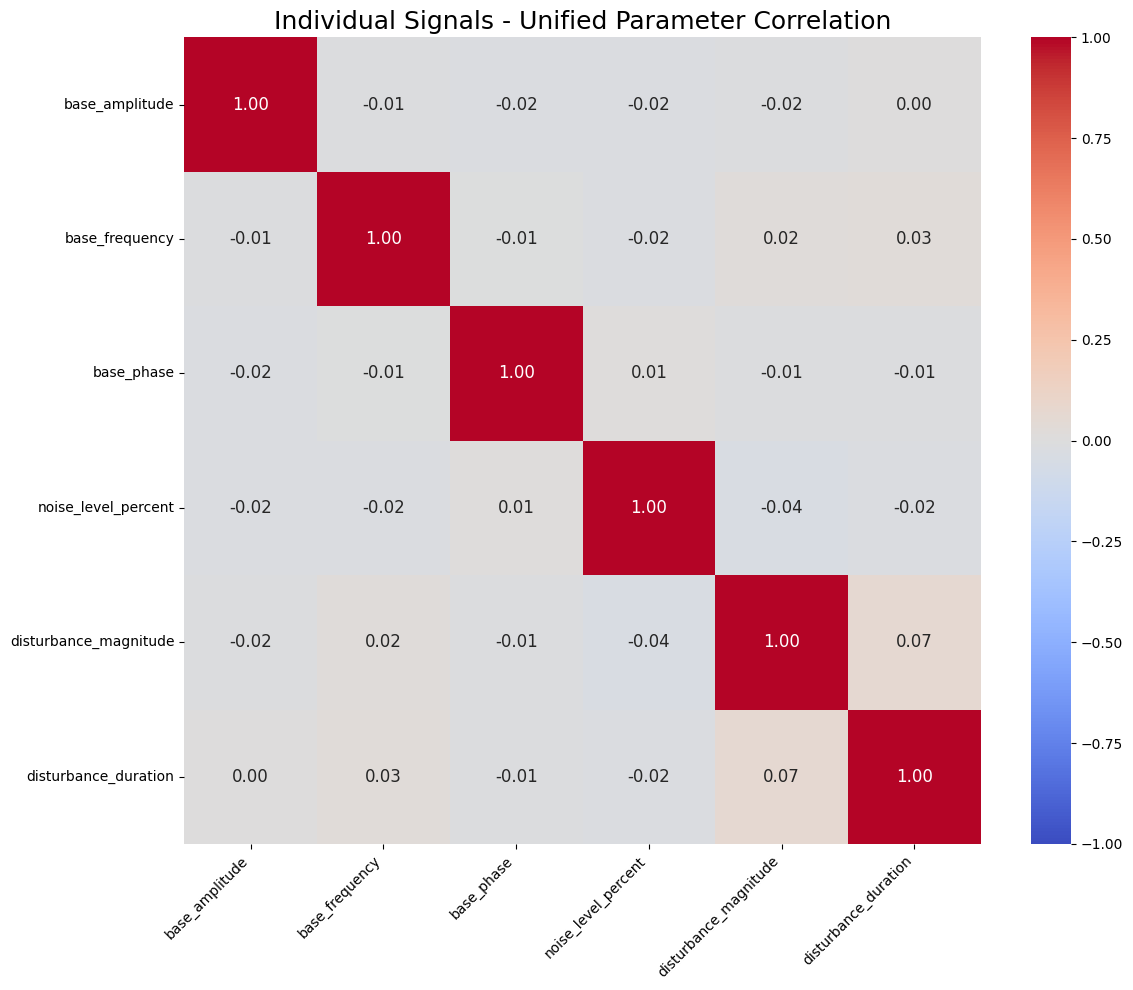

Running 3D t-SNE...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


KeyboardInterrupt: 

In [143]:
# @title Run INDIVIDUAL Analysis (Classes 1-11)

# 1. Define configuration for this specific analysis
ANALYSIS_TYPE = "Individual"
OUTPUT_PATH = os.path.join(DATASET_PATH, "Individual_Results")
os.makedirs(OUTPUT_PATH, exist_ok=True)
CLASS_INFO_TO_LOAD = {k: v for k, v in CLASS_INFO.items() if k <= 11}
CLASS_ORDER_FOR_PLOTS = [c for c in FULL_CLASS_ORDER if c in INDIVIDUAL_CLASSES_SET]

# 2. Load and Unify Data
print(f"--- Starting {ANALYSIS_TYPE} Analysis ---")
raw_params, labels = load_existing_signals(DATASET_PATH, CLASS_INFO_TO_LOAD, NUM_SAMPLES_PER_CLASS)
raw_df = pd.DataFrame(raw_params)
raw_df['class'] = labels
unified_df = unify_data(raw_df)

# 3. Run Analyses
if not unified_df.empty:
    print(f"\n✅ Data unified. Proceeding with analysis on {len(unified_df)} samples.")
    run_correlation_analysis(unified_df, OUTPUT_PATH,
                             'Individual Signals - Unified Parameter Correlation', 'INDIVIDUAL_correlation.png')
    run_separability_analysis(unified_df, OUTPUT_PATH, 'Individual Disturbance Classes',
                              'INDIVIDUAL', CLASS_ORDER_FOR_PLOTS, CLASS_COLORS, CLASS_MARKERS)
    print(f"\n🚀 {ANALYSIS_TYPE} analysis complete! Results saved to: {OUTPUT_PATH}")
else:
    print("\n❌ ANALYSIS HALTED: No data available after unification.")

In [ ]:
# @title Run MIXED Analysis (Classes 12-31)

# 1. Define configuration for this specific analysis
ANALYSIS_TYPE = "Mixed"
OUTPUT_PATH = os.path.join(DATASET_PATH, "Mixed_Results")
os.makedirs(OUTPUT_PATH, exist_ok=True)
CLASS_INFO_TO_LOAD = {k: v for k, v in CLASS_INFO.items() if k >= 12}
CLASS_ORDER_FOR_PLOTS = [c for c in FULL_CLASS_ORDER if c not in INDIVIDUAL_CLASSES_SET]

# 2. Load and Unify Data
print(f"--- Starting {ANALYSIS_TYPE} Analysis ---")
raw_params, labels = load_existing_signals(DATASET_PATH, CLASS_INFO_TO_LOAD, NUM_SAMPLES_PER_CLASS)
raw_df = pd.DataFrame(raw_params)
raw_df['class'] = labels
unified_df = unify_data(raw_df)

# 3. Run Analyses
if not unified_df.empty:
    print(f"\n✅ Data unified. Proceeding with analysis on {len(unified_df)} samples.")
    run_correlation_analysis(unified_df, OUTPUT_PATH,
                             'Mixed Signals - Unified Parameter Correlation', 'MIXED_correlation.png')
    run_separability_analysis(unified_df, OUTPUT_PATH, 'Mixed Disturbance Classes',
                              'MIXED', CLASS_ORDER_FOR_PLOTS, CLASS_COLORS, CLASS_MARKERS)
    print(f"\n🚀 {ANALYSIS_TYPE} analysis complete! Results saved to: {OUTPUT_PATH}")
else:
    print("\n❌ ANALYSIS HALTED: No data available after unification.")